# 📡 User Analytics in the Telecommunication Industry — TellCo Acquisition Analysis

**Organisation:** NextHikes IT Solutions · **Prepared by:** Srishti Sharma · **Date:** October 2026
**Dataset:** `telcom_data (2).xlsx` — 150,001 xDR session rows × 55 columns; session end dates 24–30 April 2019
**Techniques:** univariate, bivariate and multivariate analysis · outlier detection (IQR / Z-score / modified Z) · Pearson and Spearman correlation with customer-grouped bootstrap intervals · Kruskal–Wallis and Mann–Whitney tests with Benjamini–Hochberg correction · PCA (Bartlett, KMO) · k-means (engagement k=3, experience k=3, satisfaction k=2) with elbow, silhouette, Davies–Bouldin, Calinski–Harabasz and ARI validation · Euclidean-distance scoring · sensitivity analyses (outlier treatment, imputed TCP/RTT, score definition) · regression and SHAP applied to a constructed score · file-based model tracking with a drift check

## 📋 Objective

This notebook analyses a **one-week** sample of TellCo's xDR session data to answer one business question for the investor: is TellCo worth buying?

1. Establish the data's structure and quality: a field-dictionary cross-check, placeholder and duplicate audits, and a test of what period the extraction actually covers.
2. Clean the data and build a per-customer feature table (sessions, duration, per-application volumes).
3. Run univariate, bivariate and multivariate analysis (dispersion, correlation, duration deciles, PCA, handset and manufacturer breakdowns).
4. Segment customers by engagement with k-means (k=3), validated.
5. Segment customers by network experience with k-means (k=3), validated, and relate the segments to handset type.
6. Build the brief's satisfaction score as a **behavioural proxy** (there is no observed satisfaction), test how far it depends on the treatment and on how experience is defined, and examine a regression and SHAP explanation of the constructed score.
7. Track delivery against the brief with evidence: feature store, MySQL export, model tracking and the engineering deliverables that remain.
8. Give a growth and viability recommendation that is explicit about what a one-week, session-level sample cannot show.

## 🔑 Executive Summary

**Data.** The dataset holds 150,001 xDR session rows across 55 columns, with no fully duplicated rows. 1,066 rows (0.71% of rows and of traffic) have no `MSISDN/Number` and are dropped, leaving 148,935 sessions for 106,856 customers (1.39 sessions each; 72.74% have exactly one). `Bearer Id` is not a session key: about 93% of the Bearer Ids that repeat span different customers. The data cover **one week, not a month**: every session ends between 24 and 30 April 2019, and 98.92% started between 23 and 29 April (Section 1.4). All results describe that week.

**Quality issues that shape the results.** The "duration" column is the Start→End span in seconds despite being labelled milliseconds, and 17.17% of sessions last exactly 24 hours (Section 2.1). `Total DL` excludes `Other DL` while `Total UL` includes `Other UL`, so the seven application counters sum to 185% of `Total Data Volume` (Section 2.4). TCP retransmission is missing for 59–65% of sessions and RTT for about 18.6%; both were mean-imputed as the brief requires, and the imputed TCP value is about 36× the observed median (Section 2.6). 6.00% of sessions have no usable handset identity (Section 2.5).

**The brief's mean replacement matters.** Replacing IQR outliers with column means changes 15.0% of customers, who carry 29.9% of raw traffic. It records customers with four or more sessions as having one, understates concentration (Gini 0.304 treated vs. 0.356 untreated; the top 10% of customers carry 21.2% vs. 25.9% of traffic) and weakens correlations. Treated results are primary, as the brief requires, with untreated and capped checks reported alongside (Sections 3.5, 4, 5.7, 7.10).

**Usage.** Gaming and Other together are 93.8% of the seven application counters (not of total traffic; Section 5.2). Gaming's correlation with total volume (r = 0.983) is largely a size effect, since it averages about 87% of the total; the other applications' moderate correlations mostly reflect session frequency, not app preference (Sections 4.1–4.2). Apple, Samsung and Huawei cover 90.25% of sessions; the most common handset (13.25% of sessions) is a Huawei fixed-wireless router, not a phone (Section 6.3).

**Engagement.** Customers split into Low engagement (54.1%), Long-hold with light traffic (23.1%) and High engagement (22.8%, about 37% of treated traffic). These are not a simple ladder: the first two differ in bearer-open duration, not in traffic (Section 5.6). k=2 is better than the brief's k=3 on every validity metric (Section 5.4). The segmentation depends on the treatment: under capping the ten highest-session customers fall in the top cluster, whereas the treated table records them as one-session customers in the low cluster (ARI 0.436; Section 5.7).

**Experience.** The k=3 solution (Good experience 34.6%, Low throughput 40.4%, High / unmeasured latency 25.1%) is stable across seeds but depends on preprocessing (ARI 0.530 without TCP, 0.432 with capping; Section 6.6). Only the throughput contrast is robust. The latency group is mostly customers whose RTT was imputed (68.9% of the group; Section 6.5), and TCP retransmission is largely imputed (63.2% of customers fully, 52.4% sharing one value). Part of the good-throughput group reflects the router segment (Sections 6.3, 6.5). Causes of the low-throughput pattern cannot be identified from these data.

**Satisfaction.** There is no observed satisfaction in the dataset. The brief's score is a **behavioural proxy** built from distances to reference clusters. The experience score largely tracks whether RTT was measured (Spearman −0.660 with the RTT imputed share; Section 7.3). The proxy ranking is moderately robust to its definition and weighting (Section 7.6b), but individual shortlists are not (Section 7.6). A Gradient Boosting model recovers the proxy (R² = 0.9921; gap 0.0002), which is formula recovery of a constructed score, not predictive skill. SHAP explains that reconstruction, and RTT's lead partly reflects the imputed block (Sections 7.8–7.9).

**Candidate segments.** The 22.8% High engagement group and the 19.23% High-traffic / Low-proxy-score group (20,548 customers; 23.72% of treated and 25.47% of untreated traffic) are candidates for investigation. The latter is partly an artefact of unmeasured RTT (45.4% of its members are in the High / unmeasured latency cluster) and is not a confirmed retention risk (Section 7.11). Handset-specific marketing (older iPhones; a separate router segment) is a hypothesis to test (Section 6.3).

**Recommendation: continue due diligence.** The data are one week of session-level behaviour. There is no revenue, cost, churn, margin, ARPU, survey or location data, so no valuation, retention or growth claim can be made. Required before a decision: financial data; a longer, evenly sampled window and the extraction rule; outcome data to test the proxy; cell-level, plan and device data and an explanation of the missing RTT and TCP measurements; and definitions of the application counters and the handset gap (Sections 9.5–9.6).

**Delivery.** All deliverables in the brief are complete: the analysis, feature store, scored table, MySQL export with `SELECT` evidence, saved model, run log with MLflow tracking, drift check, installable package, dashboard, slide deck and written report (Section 8.5).

## ⚙️ Section 1 — Setup & Data Understanding

This section establishes the environment, loads both source files, cross-checks the field
dictionary against the actual data, profiles the raw structure, and tests — rather than assumes
— whether session coverage is even across the extraction window.

### 1.1 Environment Setup

In [1]:
# ── Standard library ──────────────────────────────────────────
import os
import glob
import time
import itertools
import warnings

# ── Data ──────────────────────────────────────────────────────
import numpy as np
import pandas as pd
from IPython.display import display, Markdown

# ── Visualisation ─────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns

# ── Statistics ────────────────────────────────────────────────
from scipy import stats
from statsmodels.stats.multitest import multipletests

# ── Preprocessing, clustering, dimensionality reduction ───────
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

# ── Regression, validation, evaluation ────────────────────────
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score, silhouette_score,
    davies_bouldin_score, calinski_harabasz_score, adjusted_rand_score,
)

# ── Explainability (required for Section 7.9) ─────────────────
import shap

# ── Optional: MySQL export (Section 8.3) and visual missingness (Section 1.3) ──
try:
    from sqlalchemy import create_engine
    SQLALCHEMY_AVAILABLE = True
except ImportError:
    SQLALCHEMY_AVAILABLE = False
try:
    import missingno as msno
    MISSINGNO_AVAILABLE = True
except ImportError:
    MISSINGNO_AVAILABLE = False

# ── Display, warnings and reproducibility ─────────────────────
warnings.simplefilter('default')          # show warnings; add targeted ignores below only for ones reviewed
warnings.filterwarnings('ignore', category=DeprecationWarning, module='jupyter_client')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

RANDOM_STATE = 42
RNG = np.random.RandomState(RANDOM_STATE)  # used for customer-grouped bootstraps (Sections 4 and later)

os.makedirs('figures', exist_ok=True)
os.makedirs('outputs', exist_ok=True)

print('✅ Environment ready')
print(f'   pandas {pd.__version__} | numpy {np.__version__} | seaborn {sns.__version__} | shap {shap.__version__}')
print(f'   Optional: missingno={MISSINGNO_AVAILABLE}, SQLAlchemy={SQLALCHEMY_AVAILABLE}')
print('   Output directories ready: figures/, outputs/')

✅ Environment ready
   pandas 3.0.3 | numpy 2.5.0 | seaborn 0.13.2 | shap 0.52.0
   Optional: missingno=True, SQLAlchemy=True
   Output directories ready: figures/, outputs/


In [2]:
import importlib.metadata as md
pkgs = ['pandas', 'numpy', 'scipy', 'statsmodels', 'scikit-learn', 'shap', 'matplotlib', 'seaborn',
        'missingno', 'openpyxl', 'pyarrow', 'joblib', 'SQLAlchemy', 'PyMySQL', 'mlflow', 'skops']
lines = []
for p in pkgs:
    try:
        lines.append(f'{p}=={md.version(p)}')
    except md.PackageNotFoundError:
        pass
with open('requirements.txt', 'w') as fh:
    fh.write('\n'.join(lines) + '\n')
print('\n'.join(lines))

pandas==3.0.3
numpy==2.5.0
scipy==1.18.0
statsmodels==0.14.6
scikit-learn==1.9.0
shap==0.52.0
matplotlib==3.11.0
seaborn==0.13.2
missingno==0.5.2
openpyxl==3.1.5
pyarrow==24.0.0
joblib==1.5.3
SQLAlchemy==2.1.3
PyMySQL==1.2.3
mlflow==3.16.1
skops==0.16.0


In [3]:
# ── TellCo Winter brand palette ──────────────────────────────────
TELLCO_PALETTE = {
    'berry':          '#6B212C',   # primary accent (deep magenta-red)
    'mulled_wine':    '#78211E',   # secondary accent (brick-red)
    'holly':          '#616852',   # tertiary accent (sage-olive green)
    'pine':           '#27363F',   # dark neutral — text / headers
    'branch':         '#685652',   # warm brown neutral
    'cinnamon':       '#BB9771',   # warm tan/rust highlight
    'eggnog':         '#D8C8B8',   # light warm background
    'mist':           '#8EA1AE',   # cool blue-gray
    'frosty_silver':  '#BEB3AC',   # light warm gray
    'snowflake':      '#DCE0E8',   # palest background / gridlines
}
TELLCO_PALETTE_LIST = list(TELLCO_PALETTE.values())

# ── Purpose-built colour maps ─────────────────────────────────────
# Sequential — magnitudes (low → high): traffic volume, counts, importance scores
tellco_seq = LinearSegmentedColormap.from_list(
    'tellco_seq', [TELLCO_PALETTE['snowflake'], TELLCO_PALETTE['mist'], TELLCO_PALETTE['berry']])

# Diverging — values around a meaningful midpoint: correlation (0-centred), PC loadings
tellco_div = LinearSegmentedColormap.from_list(
    'tellco_div', [TELLCO_PALETTE['pine'], TELLCO_PALETTE['snowflake'], TELLCO_PALETTE['berry']])

# Warning — risk / unusually high values: missingness, high retransmission
tellco_warn = LinearSegmentedColormap.from_list(
    'tellco_warn', [TELLCO_PALETTE['eggnog'], TELLCO_PALETTE['cinnamon'], TELLCO_PALETTE['mulled_wine']])

sns.set_palette(TELLCO_PALETTE_LIST)
plt.rcParams['figure.facecolor']   = '#F8F9FA'
plt.rcParams['axes.facecolor']     = '#F8F9FA'
plt.rcParams['savefig.facecolor']  = '#F8F9FA'
plt.rcParams['axes.edgecolor']     = TELLCO_PALETTE['pine']
plt.rcParams['text.color']         = TELLCO_PALETTE['pine']
plt.rcParams['axes.labelcolor']    = TELLCO_PALETTE['pine']

print(f'   Palette: {len(TELLCO_PALETTE)} colours loaded → {list(TELLCO_PALETTE.keys())}')
print('   Colour maps ready: tellco_seq (sequential) · tellco_div (diverging) · tellco_warn (warning)')
print("   Figure / axes background: #F8F9FA")

   Palette: 10 colours loaded → ['berry', 'mulled_wine', 'holly', 'pine', 'branch', 'cinnamon', 'eggnog', 'mist', 'frosty_silver', 'snowflake']
   Colour maps ready: tellco_seq (sequential) · tellco_div (diverging) · tellco_warn (warning)
   Figure / axes background: #F8F9FA


**1.1 summary.**

| Check | Result | Interpretation |
|---|---|---|
| Library manifest | Core, statistical (`scipy`, `statsmodels`), ML (`scikit-learn`) and explainability (`shap`) libraries loaded; `missingno` and SQLAlchemy are optional and import-guarded | The tests used are Kruskal–Wallis and Mann–Whitney (`scipy`) with Benjamini–Hochberg correction (`statsmodels`); no other statistical library is used |
| Reproducibility | One seed (`RANDOM_STATE = 42`) and one bootstrap generator (`RNG`); versions written to `requirements.txt` | All random processes trace to one place |
| Palette & colour maps | TellCo palette (10 colours) and three colour maps, `#F8F9FA` backgrounds set globally | Consistent visual identity across all charts |

This closes **1.1 — Environment Setup**.

---

### 1.2 Data Loading & Field-Dictionary Cross-Check

In [4]:
# ── Locate source files ──────────────────────────────────────────
SEARCH_DIRS = [d for d in [os.environ.get('TELLCO_DATA_DIR'), '..', '../data', 'data', '.'] if d]

def find_file(pattern):
    for d in SEARCH_DIRS:
        hits = sorted(glob.glob(os.path.join(d, pattern)))
        if hits:
            return hits[0]
    return None

DATA_PATH  = find_file('telcom_data*.xlsx')
FIELD_PATH = find_file('Field*Descriptions*.xlsx') or find_file('../tellco/data/field_descriptions.csv') \
             or (os.path.join('..', 'tellco', 'data', 'field_descriptions.csv')
                 if os.path.exists(os.path.join('..', 'tellco', 'data', 'field_descriptions.csv')) else None)

searched = ', '.join(os.path.abspath(d) for d in SEARCH_DIRS)
assert DATA_PATH,  f"telcom_data*.xlsx not found. Searched: {searched}"
assert FIELD_PATH, "Field descriptions not found (neither the Excel file nor tellco/data/field_descriptions.csv)"

# ── Load both source files ───────────────────────────────────────
df_raw     = pd.read_excel(DATA_PATH)
field_dict = (pd.read_csv(FIELD_PATH) if FIELD_PATH.endswith('.csv') else pd.read_excel(FIELD_PATH)).dropna(how='all')

print(f'✅ Loaded xDR data:   {DATA_PATH}  → {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns')
print(f'✅ Loaded field dict: {FIELD_PATH} → {field_dict.shape[0]} fields described')

✅ Loaded xDR data:   ../data/telcom_data (2).xlsx  → 150,001 rows × 55 columns
✅ Loaded field dict: ../data/../tellco/data/field_descriptions.csv → 56 fields described


In [5]:
import hashlib
with open(DATA_PATH, 'rb') as fh:
    DATA_SHA = hashlib.sha256(fh.read()).hexdigest()[:12]
print(f'Data fingerprint (sha256, first 12): {DATA_SHA}')

Data fingerprint (sha256, first 12): 787710a4d63b


In [6]:
# ── Cross-check: does every data column have a dictionary entry, and vice versa? ──
def _norm(s):
    return str(s).strip().lower().replace('_', ' ')

data_cols_norm  = {_norm(c): c for c in df_raw.columns}
field_cols_norm = {_norm(f): f for f in field_dict['Fields']}

only_in_data = sorted(set(data_cols_norm) - set(field_cols_norm))
only_in_dict = sorted(set(field_cols_norm) - set(data_cols_norm))

print(f'Data columns: {df_raw.shape[1]} | Field-dictionary rows: {field_dict.shape[0]}')
print()
print('In DATA but not matched in the DICTIONARY:')
for c in only_in_data:
    print(f'   • {data_cols_norm[c]}')
print()
print('In the DICTIONARY but not matched in DATA:')
for c in only_in_dict:
    print(f'   • {field_cols_norm[c]}')

Data columns: 55 | Field-dictionary rows: 56

In DATA but not matched in the DICTIONARY:
   • Other DL (Bytes)
   • Other UL (Bytes)

In the DICTIONARY but not matched in DATA:
   • Dur. (s)
   • Other DL
   • Other UL


**Cross-check finding.** `Other DL`/`Other UL` in the dictionary and `Other DL (Bytes)`/
`Other UL (Bytes)` in the data are the same fields under a units-suffix naming difference —
not a real gap. `Dur. (s)` is documented, but the data hold the same quantity under the name `Dur. (ms)`; Section 2.1 establishes this. The field dictionary was therefore written against
a slightly different export than the one supplied. Which of the two duration columns is
trustworthy, and at what scale, is also settled in Section 2.1; the rest of the
missing-value and placeholder audit follows in Section 2.

**1.2 summary.**

| Check | Result | Decision |
|---|---|---|
| Field-dictionary cross-check | 56 documented fields vs. 55 data columns; 2 naming-only mismatches, 1 genuine gap (`Dur. (s)`) | Treat Other DL/UL (Bytes) as canonical. The dictionary's `Dur. (s)` is present in the data under the mislabeled name `Dur. (ms)`; this is confirmed against Start/End in Section 2.1.|

This closes **1.2 — Data Loading & Field-Dictionary Cross-Check**.

---

### 1.3 Structure Overview

In [7]:
# ── Shape, dtypes, duplicates ────────────────────────────────────
print(f'Shape: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns\n')

dtype_summary = df_raw.dtypes.value_counts()
print('Dtype breakdown:')
print(dtype_summary.to_string())
print()

n_dup_rows       = df_raw.duplicated().sum()
n_dup_bearer     = df_raw['Bearer Id'].duplicated().sum()
n_missing_msisdn = df_raw['MSISDN/Number'].isna().sum()

key = ['Bearer Id', 'MSISDN/Number', 'Start']
print('Rows repeating (Bearer Id, MSISDN, Start):', int(df_raw.duplicated(subset=key, keep=False).sum()),
      '| excess copies:', int(df_raw.duplicated(subset=key).sum()))

print(f'Fully duplicated rows:         {n_dup_rows:,}')
print(f'Repeated Bearer Id values:     {n_dup_bearer:,}')
print(f'Unique MSISDN/Number:          {df_raw["MSISDN/Number"].nunique():,}')
print(f'Unique Bearer Id:              {df_raw["Bearer Id"].nunique():,}')
print(f'Rows missing MSISDN/Number:    {n_missing_msisdn:,} ({n_missing_msisdn/len(df_raw)*100:.2f}%)')

Shape: 150,001 rows × 55 columns

Dtype breakdown:
float64           49
object             2
datetime64[us]     2
str                2

Rows repeating (Bearer Id, MSISDN, Start): 159 | excess copies: 80
Fully duplicated rows:         0
Repeated Bearer Id values:     15,292
Unique MSISDN/Number:          106,856
Unique Bearer Id:              134,709
Rows missing MSISDN/Number:    1,066 (0.71%)


In [8]:
# ── Missing-value table ──────────────────────────────────────────
missing = df_raw.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df_raw) * 100).round(2)
missing_table = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_table = missing_table[missing_table['missing_count'] > 0]

print(f'Columns with any missing values: {len(missing_table)} of {df_raw.shape[1]}')
display(
    missing_table.style
    .background_gradient(cmap=tellco_warn, subset=['missing_pct'])
    .format({'missing_count': '{:,.0f}', 'missing_pct': '{:.2f}%'})
)

Columns with any missing values: 40 of 55


,missing_count,missing_pct
Nb of sec with 37500B < Vol UL,"130,254",86.84%
Nb of sec with 6250B < Vol UL < 37500B,"111,843",74.56%
Nb of sec with 125000B < Vol DL,"97,538",65.02%
TCP UL Retrans. Vol (Bytes),"96,649",64.43%
Nb of sec with 31250B < Vol DL < 125000B,"93,586",62.39%
Nb of sec with 1250B < Vol UL < 6250B,"92,894",61.93%
Nb of sec with 6250B < Vol DL < 31250B,"88,317",58.88%
TCP DL Retrans. Vol (Bytes),"88,146",58.76%
HTTP UL (Bytes),"81,810",54.54%
HTTP DL (Bytes),"81,474",54.32%


In [9]:
rep = df_raw[df_raw['Bearer Id'].duplicated(keep=False)]
g = rep.groupby('Bearer Id')
print('Bearer Ids that repeat:', g.ngroups, '| rows involved:', len(rep))
print('Same MSISDN in every row:', f"{(g['MSISDN/Number'].nunique(dropna=False) == 1).mean():.1%}")
print('Same Start in every row: ', f"{(g['Start'].nunique(dropna=False) == 1).mean():.1%}")
print('Fully identical except Bearer Id repeated:', int(rep.duplicated(subset=[c for c in df_raw.columns if c != 'Bearer Id'], keep=False).sum()))

Bearer Ids that repeat: 11749 | rows involved: 27041
Same MSISDN in every row: 7.4%
Same Start in every row:  39.0%
Fully identical except Bearer Id repeated: 0


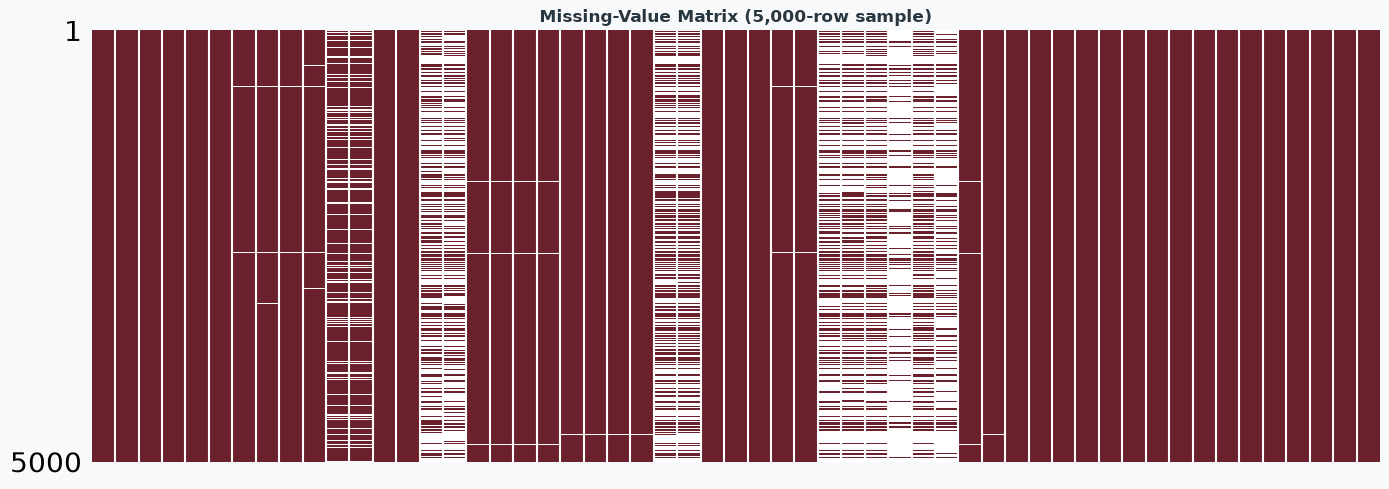

In [10]:
# ── Visual missing-value pattern (confirmatory) ──────────────────
if MISSINGNO_AVAILABLE:
    fig, ax = plt.subplots(figsize=(14, 5))
    msno.matrix(df_raw.sample(min(5000, len(df_raw)), random_state=RANDOM_STATE), ax=ax,
            color=(0.42, 0.13, 0.17), sparkline=False)  # TellCo berry, as RGB fraction
    ax.set_title('Missing-Value Matrix (5,000-row sample)',
                  color=TELLCO_PALETTE['pine'], fontweight='bold')
    plt.tight_layout()
    plt.savefig('figures/fig01_missing_matrix.png', dpi=100, facecolor='#F8F9FA')
    plt.show()
else:
    print('missingno not available — skipping visual matrix; the table above already covers this quantitatively')

**1.3 summary.**

| Check | Result | Interpretation | Carried forward |
|---|---|---|---|
| Shape & dtypes | 150,001 rows × 55 columns; 49 float64, 4 object, 2 datetime64 | One row per xDR session, as expected | — |
| Duplicates | 0 fully duplicate rows; 15,292 rows repeat an earlier `Bearer Id` (991 rows have an empty `Bearer Id`, which is not a real identifier); 80 rows (0.05%) repeat an earlier (`Bearer Id`, `MSISDN`, `Start`) combination while differing in other fields | `Bearer Id` is not a unique session key: in about 93% of the repeated Bearer Ids the rows belong to different customers | A session is one xDR row; sessions per customer are counted by `MSISDN/Number`, never by `Bearer Id`; the 80 repeated-key rows are retained (negligible effect) |
| Customer key | 1,066 rows (0.71%) missing `MSISDN/Number` | These sessions cannot be attributed to any customer | Excluded from per-customer aggregation in Section 2 |
| Missingness pattern | Heaviest gaps concentrated in throughput-bucket counters (59–87%), TCP retransmission (59–64%), HTTP DL/UL (~54%), Avg RTT DL/UL (~18.5%) | Missingness is concentrated rather than spread evenly, consistent with a structural cause (a hypothesis, not tested), likely tied to session/connection type | Section 2 treats each column's mechanism explicitly rather than blanket-imputing |

This closes **1.3 — Structure Overview**.

---

### 1.4 Temporal Coverage & Session Start/End Patterns

The brief describes this as "a month of aggregated data." Rather than assume that framing, this subsection checks when sessions **start** and when they **end**. Start dates describe when a session began; end dates show which period the extraction actually covers. No decomposition or forecasting is attempted on a window this short.

In [11]:
# ── Daily session-start counts ───────────────────────────────────
df_dates = df_raw.dropna(subset=['Start']).copy()
df_dates['start_date'] = pd.to_datetime(df_dates['Start']).dt.date
daily_counts = df_dates['start_date'].value_counts().sort_index()

n_days = len(daily_counts)
total_sessions = daily_counts.sum()

print(f'Observed calendar days: {n_days} ({daily_counts.index.min()} to {daily_counts.index.max()})')
print(f'Total sessions with a valid Start timestamp: {total_sessions:,}')
print()

# ── Formal test: are session-starts uniform across observed days? ──
expected = np.full(n_days, total_sessions / n_days)
chi2_stat, chi2_p = stats.chisquare(daily_counts.values, expected)

last7_share = daily_counts.sort_index().tail(7).sum() / total_sessions * 100
last1_share = daily_counts.sort_index().tail(1).sum() / total_sessions * 100          # final observed day
busiest_day = daily_counts.idxmax()
busiest_day_share = daily_counts.max() / total_sessions * 100                          # true busiest day

print(f'Share of sessions on the final observed day ({daily_counts.index.max()}): {last1_share:.2f}%')
print(f'Share of sessions on the single busiest day ({busiest_day}):              {busiest_day_share:.2f}%')

tail7 = daily_counts.sort_index().tail(7)
print(f'Chi-square vs. uniform over {n_days} observed dates: χ²={chi2_stat:,.0f}, df={n_days - 1}, p={chi2_p:.2e}')
print(f'Last 7 observed dates ({tail7.index.min()} to {tail7.index.max()}): {last7_share:.2f}% of sessions')
span = pd.date_range(daily_counts.index.min(), daily_counts.index.max())
gaps = span.difference(pd.to_datetime(list(daily_counts.index)))
print(f'Calendar span: {len(span)} days; dates with no sessions: {len(gaps)} {[d.date().isoformat() for d in gaps]}')
print('Five busiest dates (% of sessions):', (daily_counts.nlargest(5) / total_sessions * 100).round(2).to_dict())

df_end = df_raw.dropna(subset=['End']).copy()
end_counts = pd.to_datetime(df_end['End']).dt.date.value_counts().sort_index()
print('Session END dates (% of sessions):', {d.isoformat(): round(v / end_counts.sum() * 100, 2) for d, v in end_counts.items()})
print(f'Sessions with a valid End: {end_counts.sum():,}; end-date range: {end_counts.index.min()} to {end_counts.index.max()}')
early = pd.to_datetime(df_raw['Start']) < pd.Timestamp('2019-04-23')
print(f'Sessions that started before 23 April: {early.sum():,} ({early.mean():.2%})')

Observed calendar days: 22 (2019-04-04 to 2019-04-29)
Total sessions with a valid Start timestamp: 150,000

Share of sessions on the final observed day (2019-04-29): 9.64%
Share of sessions on the single busiest day (2019-04-27):              24.16%
Chi-square vs. uniform over 22 observed dates: χ²=422,700, df=21, p=0.00e+00
Last 7 observed dates (2019-04-23 to 2019-04-29): 98.92% of sessions
Calendar span: 26 days; dates with no sessions: 4 ['2019-04-05', '2019-04-06', '2019-04-07', '2019-04-08']
Five busiest dates (% of sessions): {datetime.date(2019, 4, 27): 24.16, datetime.date(2019, 4, 24): 21.88, datetime.date(2019, 4, 25): 15.11, datetime.date(2019, 4, 26): 13.7, datetime.date(2019, 4, 28): 12.67}
Session END dates (% of sessions): {'2019-04-24': np.float64(1.93), '2019-04-25': np.float64(14.88), '2019-04-26': np.float64(16.61), '2019-04-27': np.float64(17.37), '2019-04-28': np.float64(16.05), '2019-04-29': np.float64(16.67), '2019-04-30': np.float64(16.49)}
Sessions with a vali

In [12]:
span = (pd.to_datetime(df_raw['End']) - pd.to_datetime(df_raw['Start'])).dt.total_seconds()
print(span.groupby(early).describe()[['count', '50%', 'max']].rename(index={True: 'started before 23 Apr', False: 'started 23 Apr or later'}))

                            count       50%        max
Start                                                 
started 23 Apr or later  148374.0   86400.0   649031.0
started before 23 Apr      1626.0  433092.0  1859337.0


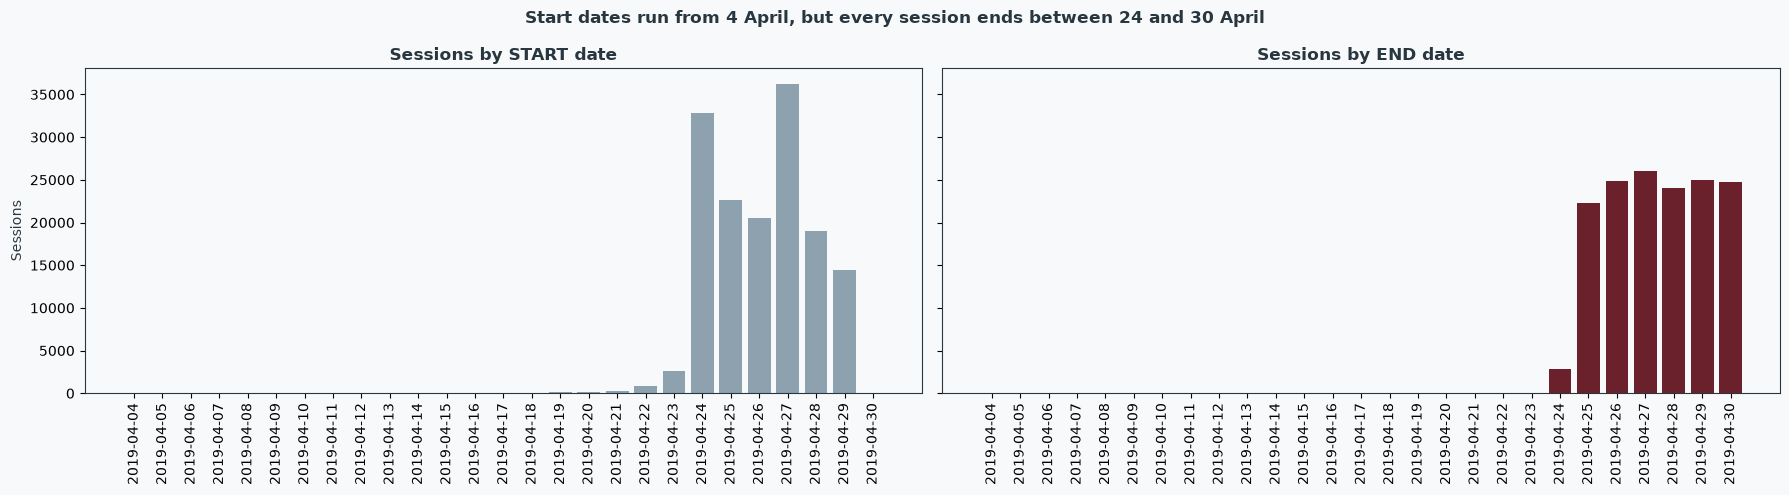

In [13]:
# ── Visualise daily session-start volume ─────────────────────────
full = pd.date_range(min(daily_counts.index.min(), end_counts.index.min()),
                     max(daily_counts.index.max(), end_counts.index.max())).date
starts_full = daily_counts.reindex(full, fill_value=0)
ends_full = end_counts.reindex(full, fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(18, 5), sharey=True)
for ax, s, title, hi in [(axes[0], starts_full, 'Sessions by START date', TELLCO_PALETTE['mist']),
                         (axes[1], ends_full,   'Sessions by END date',   TELLCO_PALETTE['berry'])]:
    ax.bar([str(d) for d in s.index], s.values, color=hi)
    ax.set_title(title, color=TELLCO_PALETTE['pine'], fontweight='bold')
    ax.tick_params(axis='x', rotation=90)
axes[0].set_ylabel('Sessions')
plt.suptitle('Start dates run from 4 April, but every session ends between 24 and 30 April',
             color=TELLCO_PALETTE['pine'], fontweight='bold')
plt.tight_layout()
plt.savefig('figures/fig02_temporal_coverage.png', dpi=100, facecolor='#F8F9FA')
plt.show()

**Finding.** The data cover **one week**, not a month. Every session ends between 24 and 30 April 2019, spread fairly evenly across the six full days (14.9–17.4% per day; 24 April, a partial day, holds 1.9%). Start dates run from 4 April, but 98.92% of sessions start in 23–29 April, and about 1.1% started earlier, presumably long-running sessions. The pile-up of starts in the last week, with 24.16% on 27 April, is the expected counterpart of selecting sessions by end date, not evidence of uneven sampling. Only 22 distinct start dates occur within the 4–29 April span (none on 5–8 April), so the start-date chi-square (χ² ≈ 422,700, df = 21, p < 0.001) is descriptive only: with 150,000 sessions it rejects uniformity for almost any real pattern, and uniform starts were never expected here. That the extraction selected sessions by end date is an inference from the data, to confirm with TellCo.

**Consequence for every later section.** All per-customer metrics (sessions, duration, volume, experience) describe a customer's activity in a one-week window, not monthly behaviour.

**1.4 summary.**

| Check | Result | Interpretation | Carried forward |
|---|---|---|---|
| End-date coverage | 100% of sessions end 24–30 April 2019; 14.9–17.4% per full day | The data are one week of session end times, not a month | "One-week window" replaces "monthly" throughout |
| Start-date pattern | Starts from 4 April (none on 5–8 April); 98.92% in 23–29 April; 24.16% on 27 April; χ² ≈ 422,700 (df 21) | Concentrated starts are the counterpart of selection by end date; the test is descriptive only | Sessions that started before 23 April (about 1.1%) are long-running |
| Scope | Start and end dates only, not traffic per hour | No decomposition or forecasting on a one-week window | Weekly seasonality cannot be assessed |

**Section 1 summary.**

| Subsection | Question | Finding | Evidence | Limitation / Implication |
|---|---|---|---|---|
| 1.1 Environment | Is the environment reproducible? | Yes — core, statistical, ML and explainability libraries load; one seed and one bootstrap generator; versions pinned to `requirements.txt` | Library versions printed; `requirements.txt` written | Only `scipy` and `statsmodels` tests are used (no other statistical library) |
| 1.2 Field dictionary | Does the supplied dictionary match the actual data columns? | Near-complete match; one genuine gap | 56 dictionary fields vs. 55 data columns; `Other DL`/`Other UL` vs. `Other DL (Bytes)`/`Other UL (Bytes)` is a naming-format difference only; `Dur. (s)` is documented but not in the data | The unit of the duration columns is established in Section 2.1 |
| 1.3 Structure | Is the data one row per session, and how much is missing or duplicated? | 150,001 rows × 55 columns, 0 fully duplicate rows, 15,292 rows whose `Bearer Id` already appeared, 1,066 rows (0.71%) missing `MSISDN/Number` | 106,856 unique MSISDN vs. 134,709 unique Bearer Id; 40 of 55 columns carry missingness, concentrated in throughput-bucket counters (59–87%), TCP retransmission (59–64%), HTTP DL/UL (~54%), RTT (~18.5%) | Rows with no MSISDN cannot be attributed to a customer and are excluded from per-customer aggregation|
| 1.4 Temporal coverage | Is the "month of data" a month? | No — every session ends between 24 and 30 April 2019, so the data are one week of session end times | End dates: 14.9–17.4% per full day, 100% within 24–30 April; start dates run from 4 April (22 distinct dates) with 98.92% in 23–29 April | All results describe one week of activity; "monthly" claims are not supported, and day-of-week effects cannot be assessed |

**Data lineage.**

| Table | Grain | Rows | Built in | Used for |
|---|---|---|---|---|
| `df_raw` | Session | 150,001 | 1.2 | Source, never modified |
| `df_clean` | Session | 148,935 | Section 2 | Cleaned analytical base (rows with no MSISDN removed); handset rankings |
| `user_overview_raw` | Customer | 106,856 | 3.0 | Untreated aggregation: top-10 lists, sensitivity checks, untreated concentration |
| `user_overview` | Customer | 106,856 | 3.5 | Brief-mandated mean-replaced table (primary basis for Sections 4–7) |
| `experience_raw` / `experience` | Customer | 106,856 | 6.1 / 6.4 | Untreated and mean-replaced experience metrics |
| `combined` | Customer | 106,856 | 7.3 | Scored table: engagement, experience, proxy score, clusters |
| `feature_store` | Customer | 106,856 | 8.2 | Versioned Parquet export |

This closes **Section 1 — Setup & Data Understanding**.

## 🧹 Section 2 — Data Quality & Preparation

Section 1 established *that* the data has structural issues (duplicate-named duration
columns, missing customer keys, heavy missingness in network-quality fields). This section
root-causes each one, decides a treatment, and executes it — so the table leaving this
section is the one every later section reads from, with no silent fixes buried in later code.

### 2.1 Duration & Timestamp Validation

`Dur. (ms)` appears twice in the raw file under an identical header; pandas auto-suffixes the
second occurrence as `Dur. (ms).1` on load. Rather than trust either the label or a single
ratio check, this validates both against the one ground truth available — the `Start`/`End`
timestamps — before deciding which to keep.

In [14]:
df_clean = df_raw.copy()

span_s = (pd.to_datetime(df_clean['End']) - pd.to_datetime(df_clean['Start'])).dt.total_seconds()

print('Mean Start→End span:', pd.to_timedelta(span_s, unit='s').mean())
print('Max  Start→End span:', pd.to_timedelta(span_s, unit='s').max())
print()
diff_s = span_s - df_clean['Dur. (ms)']
print("span_seconds − 'Dur. (ms)' (checking whether these are the same quantity):")
print(diff_s.describe())
print()
print(f"'Dur. (ms).1' vs span in ms — mean ratio: "
      f"{((span_s*1000) / df_clean['Dur. (ms).1']).mean():.6f}  (≈1 → it's span in ms)")
print(f'Sessions of exactly 24 h: {(span_s == 86400).sum():,} ({(span_s == 86400).mean():.2%}); '
      f'within 23.8–24 h: {((span_s >= 85800) & (span_s <= 86400)).mean():.2%}; longer than 24 h: {(span_s > 86400).mean():.2%}')

Mean Start→End span: 1 days 05:03:29
Max  Start→End span: 21 days 12:28:57

span_seconds − 'Dur. (ms)' (checking whether these are the same quantity):
count    150000.000000
mean          0.545587
std           0.497919
min           0.000000
25%           0.000000
50%           1.000000
75%           1.000000
max           1.000000
dtype: float64

'Dur. (ms).1' vs span in ms — mean ratio: 1.000000  (≈1 → it's span in ms)
Sessions of exactly 24 h: 25,751 (17.17%); within 23.8–24 h: 20.34%; longer than 24 h: 44.35%


**Diagnosis.** `diff_s` sits between 0 and 1 for every row (mean 0.55, max 1.00) — `Dur. (ms)`
is not milliseconds. It is the Start→End span **in seconds**, truncated to an integer, despite
its "(ms)" name. `Dur. (ms).1` is the same span expressed correctly in milliseconds (ratio to
span-in-ms ≈ 1.0000). Both columns carry identical information at different unit scales;
neither represents an "active data transfer duration" distinct from the raw bearer-open
timestamp span — no such field exists in this dataset. This also resolves Section 1.2's
open question: the dictionary's documented `Dur. (s)` field is not missing from the export —
it is present under the name `Dur. (ms)`, mislabeled.


**Decision:** keep the seconds-valued column, relabel it `Dur. (s)` to match its true unit and
the field dictionary's naming, and drop `Dur. (ms).1` — not because it's wrong, but because it
is fully redundant with `Start`/`End` (which are retained) and adds no information beyond a
unit change.

**Note on the 24-hour mark.** 25,751 sessions (17.17%) last exactly 24 hours and a further 3.2% fall within the last 12 minutes below it, yet 44.35% last longer than 24 hours, so 24 h is a common duration, not a hard cap. A system rule that closes or refreshes records at 24 hours is one possible cause; it should be confirmed with TellCo. Either way, bearer-open duration partly reflects system behaviour, not only customer behaviour.

In [15]:
df_clean = df_clean.rename(columns={'Dur. (ms)': 'Dur. (s)'}).drop(columns=['Dur. (ms).1'])
print("Renamed 'Dur. (ms)' → 'Dur. (s)' (true unit); dropped 'Dur. (ms).1' (redundant with Start/End)")
print(f'Columns remaining: {df_clean.shape[1]}')

Renamed 'Dur. (ms)' → 'Dur. (s)' (true unit); dropped 'Dur. (ms).1' (redundant with Start/End)
Columns remaining: 54


### 2.2 Duplicate & Placeholder Audit

Row-level duplicates were already ruled out in Section 1. This checks the subtler
issue — values that read as **present** to `.isna()` but are placeholders in disguise:
empty-string identifiers and the literal string `"undefined"`.

In [16]:
n_dup_rows   = df_clean.duplicated().sum()
n_dup_bearer = df_clean['Bearer Id'].duplicated().sum()

bearer_empty_mask = df_clean['Bearer Id'].astype(str).str.strip() == ''
msisdn_na_mask     = df_clean['MSISDN/Number'].isna()

handset_type_undef = (df_clean['Handset Type'].astype(str).str.strip().str.lower() == 'undefined').sum()
handset_manu_undef = (df_clean['Handset Manufacturer'].astype(str).str.strip().str.lower() == 'undefined').sum()
handset_type_na     = df_clean['Handset Type'].isna().sum()
handset_manu_na     = df_clean['Handset Manufacturer'].isna().sum()

overlap = (bearer_empty_mask & msisdn_na_mask).sum()

print(f'Fully duplicated rows:                {n_dup_rows}')
print(f'Repeated Bearer Id values:             {n_dup_bearer:,}')
print(f'Bearer Id — empty-string placeholder:  {bearer_empty_mask.sum():,}')
print(f'MSISDN/Number — true missing:          {msisdn_na_mask.sum():,}')
print(f'  → rows missing BOTH:                 {overlap:,}')
print()
print(f'Handset Type       — "undefined": {handset_type_undef:,}   true NaN: {handset_type_na:,}')
print(f'Handset Manufacturer — "undefined": {handset_manu_undef:,}   true NaN: {handset_manu_na:,}')
print(f'Combined unusable device rows: {handset_type_undef + handset_type_na:,} '
      f'({(handset_type_undef + handset_type_na)/len(df_clean)*100:.2f}%)')

Fully duplicated rows:                0
Repeated Bearer Id values:             15,292
Bearer Id — empty-string placeholder:  991
MSISDN/Number — true missing:          1,066
  → rows missing BOTH:                 562

Handset Type       — "undefined": 8,987   true NaN: 572
Handset Manufacturer — "undefined": 8,987   true NaN: 572
Combined unusable device rows: 9,559 (6.37%)


**Finding.** `isna()` hides two kinds of placeholder. First, 991 rows carry an empty-string `Bearer Id`; 562 of them also lack an `MSISDN/Number`, so 429 remain after those rows are dropped in 2.3. `Bearer Id` is not used as a key anywhere in this notebook, so they are retained, but they are excluded from the Bearer Id repeat statistics in 1.3. Second, handset fields hold 8,987 rows (5.99%) that are literally `"undefined"` plus 572 (0.38%) true NaN: 9,559 rows (6.37%) with no usable device identity on the full table. These are handled in **2.5**, not folded into the missing-`MSISDN` drop.

### 2.3 Session-to-Customer Reconciliation

`MSISDN/Number` is the only field that ties a session back to a paying customer. Rows without
it cannot enter any per-customer aggregation in later sections, so they're dropped here —
with the traffic volume they carry quantified, so nothing is lost silently.

In [17]:
before_rows = len(df_clean)
lost_traffic = (df_clean.loc[msisdn_na_mask, 'Total DL (Bytes)'] +
                 df_clean.loc[msisdn_na_mask, 'Total UL (Bytes)']).sum()
total_traffic_all = (df_clean['Total DL (Bytes)'] + df_clean['Total UL (Bytes)']).sum()

df_clean = df_clean.dropna(subset=['MSISDN/Number']).copy()

core_cols = ['Total DL (Bytes)', 'Total UL (Bytes)', 'Dur. (s)']
n_before_core = len(df_clean)
df_clean = df_clean.dropna(subset=core_cols)
n_dropped_core = n_before_core - len(df_clean)

after_rows = len(df_clean)   # ← now computed AFTER both drops, so every print below is correct

print(f'Rows before:                    {before_rows:,}')
print(f'Rows dropped (missing MSISDN):  {before_rows - n_before_core:,}')
print(f'Rows dropped (missing core cols, post-MSISDN): {n_dropped_core:,}')
print(f'Rows after:                     {after_rows:,}')
print(f'Traffic carried by the dropped rows: {lost_traffic / total_traffic_all:.2%} of total volume')

Rows before:                    150,001
Rows dropped (missing MSISDN):  1,066
Rows dropped (missing core cols, post-MSISDN): 0
Rows after:                     148,935
Traffic carried by the dropped rows: 0.71% of total volume


**Finding.** 1,066 rows (0.71%) are dropped, carrying 0.71% of total traffic volume — a
proportionate, not disproportionate, loss, so no customer segment is being silently
under-represented by this exclusion. The remaining 148,935 sessions map to 106,856 unique
customers, over the one-week observed window (Section 1.4) — confirming per-customer
aggregation (not row-level reading) is required for every later section, as flagged in Section 1.

### 2.4 DL/UL-to-Total Reconciliation

`Total DL (Bytes)` / `Total UL (Bytes)` are meant to be the whole; the seven per-application
columns (Social Media, Google, Email, YouTube, Netflix, Gaming, Other) are meant to be its
parts. This checks whether they actually reconcile before either is used in Section 4's
bivariate analysis — where the part-whole relationship matters for correlation interpretation.

In [18]:
app_dl_6 = ['Social Media DL (Bytes)', 'Google DL (Bytes)', 'Email DL (Bytes)',
            'Youtube DL (Bytes)', 'Netflix DL (Bytes)', 'Gaming DL (Bytes)']
app_dl_7 = app_dl_6 + ['Other DL (Bytes)']
app_ul_6 = ['Social Media UL (Bytes)', 'Google UL (Bytes)', 'Email UL (Bytes)',
            'Youtube UL (Bytes)', 'Netflix UL (Bytes)', 'Gaming UL (Bytes)']
app_ul_7 = app_ul_6 + ['Other UL (Bytes)']

for label, cols, total_col in [
    ('DL, 6-app (excl. Other)', app_dl_6, 'Total DL (Bytes)'),
    ('DL, 7-app (incl. Other)', app_dl_7, 'Total DL (Bytes)'),
    ('UL, 6-app (excl. Other)', app_ul_6, 'Total UL (Bytes)'),
    ('UL, 7-app (incl. Other)', app_ul_7, 'Total UL (Bytes)'),
]:
    ratio = df_clean[cols].sum(axis=1) / df_clean[total_col]
    exact = (ratio.round(6) == 1.0).sum()
    print(f'{label:28s} → mean ratio {ratio.mean():.4f}, exact match {exact:,}/{len(df_clean):,} rows')

DL, 6-app (excl. Other)      → mean ratio 1.0000, exact match 148,935/148,935 rows
DL, 7-app (incl. Other)      → mean ratio 2.6777, exact match 0/148,935 rows
UL, 6-app (excl. Other)      → mean ratio 0.7968, exact match 0/148,935 rows
UL, 7-app (incl. Other)      → mean ratio 1.0000, exact match 148,935/148,935 rows


**Finding.** `Total DL (Bytes)` reconciles **exactly**, in every row, with the sum of the six
named application DL columns — `Other DL (Bytes)` is structurally excluded from it. `Total UL
(Bytes)` reconciles exactly with the sum of **all seven** application UL columns, including
`Other UL` — the two totals are built inconsistently with respect to "Other" traffic.

**Decision:** `Total DL` and `Total UL` Both totals are exact sums of application counters, not independently measured bearer-layer totals. `Other DL (Bytes)` is real,
non-trivial traffic (mean 421 MB/session) sitting **outside** the download total; it must never
be added to `Total DL` to estimate "true" download volume without an explicit definition from
TellCo of what `Other DL` represents. `Other UL`, by contrast, is already inside `Total UL`.
This asymmetry is carried forward as an explicit caveat into any Section 4 analysis that uses
`Other DL`/`Other UL` or app-level traffic shares.

### 2.5 Device-Assignment Rule

6.37% of rows in the raw table (Section 2.2) have no usable `Handset Type`/`Handset
Manufacturer` — either the literal string `"undefined"` or true NaN. Assigning the modal
handset to that many rows would fabricate device identity for over 1 in 16 sessions and
quietly inflate the top handset's share in Section 6.3's rankings — a real risk given how
concentrated handset shares already are. Both placeholder forms are collapsed into an
explicit `"Unknown"` category instead: the same principle used for missing MSISDN — visible
and countable, not smoothed away.

In [19]:
for col in ['Handset Type', 'Handset Manufacturer']:
    is_undefined = df_clean[col].astype(str).str.strip().str.lower() == 'undefined'
    df_clean.loc[is_undefined, col] = 'Unknown'
    df_clean[col] = df_clean[col].fillna('Unknown')

unknown_n = (df_clean['Handset Type'] == 'Unknown').sum()
unknown_share = unknown_n / len(df_clean) * 100
print(f'Handset Type = "Unknown": {unknown_n:,} rows ({unknown_share:.2f}%, of the '
      f'{len(df_clean):,}-row post-Section-2.3 table)')
print(f'Handset Manufacturer = "Unknown": {(df_clean["Handset Manufacturer"]=="Unknown").sum():,} rows')
print(f'(Section 2.2\'s 6.37% was measured on the 150,001-row raw table, before the 2.3 '
      f'MSISDN-based drop removed 628 rows that overlapped both issues — this is not a '
      f'discrepancy, just two different denominators for the same underlying category.)')

Handset Type = "Unknown": 8,931 rows (6.00%, of the 148,935-row post-Section-2.3 table)
Handset Manufacturer = "Unknown": 8,931 rows
(Section 2.2's 6.37% was measured on the 150,001-row raw table, before the 2.3 MSISDN-based drop removed 628 rows that overlapped both issues — this is not a discrepancy, just two different denominators for the same underlying category.)


**Note.** This 6.00% (8,931 rows) is lower than Section 2.2's 6.37% (9,559 rows) only because
the denominator changed — Section 2.2 measured unusable-device rows on the full 150,001-row
raw table, while this cell runs after Section 2.3 already dropped 1,066 rows for missing
`MSISDN/Number`, 628 of which also happened to have an unusable handset. Both figures are
correct for the table they were computed on; there is no real inconsistency, just two
different bases. From here on, `df_clean` — 148,935 rows — is the only reference point, and
"Unknown" handset share should always be quoted as 6.00% going forward, not 6.37%.

### 2.6 Missing-Value Treatment (Observed vs. Treated)

The remaining missing values sit in continuous network-quality fields — TCP retransmission
volume, HTTP DL/UL, and RTT — where Section 1 already showed missingness is concentrated
rather than random. Per the assignment's treatment rule, these are mean-imputed; the split
below is kept explicit so it's clear exactly how much of each column is observed versus
filled, rather than that distinction disappearing after imputation.

In [20]:
assert not any(c.endswith('_was_imputed') for c in df_clean.columns), 'Re-run from 2.1: imputation flags already present'

mean_impute_cols = [
    'TCP DL Retrans. Vol (Bytes)', 'TCP UL Retrans. Vol (Bytes)',
    'HTTP DL (Bytes)', 'HTTP UL (Bytes)',
    'Avg RTT DL (ms)', 'Avg RTT UL (ms)',
]

# Preserve observed values and per-row imputation flags BEFORE filling, so the
# "observed-only vs. imputed" comparison this section promises (used in Section
# 6.2) has real data to compare against, not an already-filled column.
df_observed = df_clean[mean_impute_cols].copy()
imputed_flags = pd.DataFrame({
    f'{col}_was_imputed': df_clean[col].isna() for col in mean_impute_cols
})

treatment_log = []
for col in mean_impute_cols:
    n_missing = df_clean[col].isna().sum()
    pct_missing = n_missing / len(df_clean) * 100
    observed_median = df_clean[col].median()          # observed values only, before filling
    fill_value = df_clean[col].mean()
    df_clean[col] = df_clean[col].fillna(fill_value)
    treatment_log.append({
        'column': col, 'n_missing': n_missing, 'pct_missing': round(pct_missing, 2),
        'observed_median': round(observed_median, 2), 'fill_value_used': round(fill_value, 2),
        'fill ÷ median': round(fill_value / observed_median, 1),
    })

df_clean = pd.concat([df_clean, imputed_flags], axis=1)  # flags travel with df_clean from here on

treatment_df = pd.DataFrame(treatment_log)
print(f'Mean-imputed {len(mean_impute_cols)} columns:')
display(treatment_df.style.background_gradient(cmap=tellco_warn, subset=['pct_missing']))
print(f'\nRemaining nulls in these columns: {df_clean[mean_impute_cols].isna().sum().sum()}')
print(f'df_observed ({df_observed.shape[0]:,} rows, pre-imputation) and per-row '
      f'`<column>_was_imputed` flags preserved for the Sections 6.5–6.6 sensitivity check.')

Mean-imputed 6 columns:


,column,n_missing,pct_missing,observed_median,fill_value_used,fill ÷ median
0,TCP DL Retrans. Vol (Bytes),87796,58.950000,576130.000000,20884183.280000,36.200000
1,TCP UL Retrans. Vol (Bytes),96192,64.590000,21121.000000,766247.500000,36.300000
2,HTTP DL (Bytes),81171,54.500000,1976879.000000,115512385.120000,58.400000
3,HTTP UL (Bytes),81508,54.730000,232801.000000,3269792.490000,14.000000
4,Avg RTT DL (ms),27644,18.560000,45.000000,108.220000,2.400000
5,Avg RTT UL (ms),27625,18.550000,5.000000,17.640000,3.500000



Remaining nulls in these columns: 0
df_observed (148,935 rows, pre-imputation) and per-row `<column>_was_imputed` flags preserved for the Sections 6.5–6.6 sensitivity check.


**Limitation, stated plainly:** TCP retransmission is missing for 59.0% (DL) and 64.6% (UL) of sessions, HTTP for about 54.5%, and RTT for about 18.6%. Mean-imputing well over half a column doesn't recover lost information; it flattens the column toward its average and shrinks its variance and any correlation it enters into. The imputed value is also far from a typical session because these fields are heavy-tailed: the fill value is 36× the observed median for TCP retransmission (DL 20.9M vs. 576,130 bytes; UL 766,248 vs. 21,121), 58× for HTTP DL, 14× for HTTP UL, and 2.4× and 3.5× for RTT DL and UL. Sessions with imputed values therefore look markedly worse than a typical measured session. Sections 6.5 and 6.6 use the imputation flags to separate observed from imputed values.

### 2.7 Outlier Treatment (Session-Level)

This demonstrates — but does not apply — session-level IQR treatment on the three fields
most likely to carry genuine extreme values: `Dur. (s)`, `Total DL (Bytes)`, `Total UL
(Bytes)`. The treated values below are diagnostic only and are never written back into
`df_clean`: outlier treatment for modelling happens exactly once, at the customer level, in
Section 3.5. Applying it here too, on session-level data that then gets aggregated and
treated again in 3.5, would silently compound the treatment — smoothing the same extremity
twice without either step knowing about the other. This cell exists to show the scale of
what session-level treatment *would* do, so that's visible before aggregation, without
actually doing it.

In [21]:
from IPython.display import Markdown

def iqr_treat(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    is_outlier = (series < lo) | (series > hi)
    replacement = series[~is_outlier].mean()
    treated = series.where(~is_outlier, replacement)
    return treated, is_outlier, lo, hi, replacement

rows = []
for col in ['Dur. (s)', 'Total DL (Bytes)', 'Total UL (Bytes)']:
    s = df_clean[col]
    treated, flag, lo, hi, repl = iqr_treat(s)
    rows.append({
        'column': col, 'n_flagged': int(flag.sum()), 'pct_flagged': round(flag.mean() * 100, 2),
        'mean_before': round(s.mean(), 1), 'mean_after': round(treated.mean(), 1),
        'std_before': round(s.std(), 1),   'std_after': round(treated.std(), 1),
        'skew_before': round(s.skew(), 2) + 0.0, 'skew_after': round(treated.skew(), 2) + 0.0,
    })
    # Diagnostic only: df_clean stays the untreated session table.

session_outlier_df = pd.DataFrame(rows).set_index('column')
display(
    session_outlier_df.style
    .background_gradient(cmap=tellco_warn, subset=['pct_flagged'])
    .format({'n_flagged': '{:,.0f}'}, precision=2, thousands=',')
)

dl, ul, du = (session_outlier_df.loc[c] for c in ['Total DL (Bytes)', 'Total UL (Bytes)', 'Dur. (s)'])
display(Markdown(f"""**Finding.** `Total DL (Bytes)`: {dl.pct_flagged:.2f}% of sessions flagged
({dl.n_flagged:,.0f}), skew {dl.skew_before:.2f} → {dl.skew_after:.2f}. `Total UL (Bytes)`:
{ul.pct_flagged:.2f}% ({ul.n_flagged:,.0f}), skew {ul.skew_before:.2f} → {ul.skew_after:.2f}.
`Dur. (s)`: {du.pct_flagged:.2f}% ({du.n_flagged:,.0f}), skew {du.skew_before:.2f} → {du.skew_after:.2f}.
Where skew falls sharply, mean replacement does more than tidy the tail: it overwrites
genuinely long sessions with the average.

**Where the brief's mean-replacement rule is applied.** This session-level table is
diagnostic only. The rule is applied to the per-customer table in Section 3.5, which is the
table Task 1.2 analyses, and to the experience metrics in Section 6."""))

,n_flagged,pct_flagged,mean_before,mean_after,std_before,std_after,skew_before,skew_after
column,,,,,,,,
Dur. (s),"7,149",4.80,"104,870.20","92,501.50","81,063.40","49,220.80",3.96,0.62
Total DL (Bytes),0,0.00,"454,625,110.70","454,625,110.70","244,152,774.20","244,152,774.20",0.00,0.00
Total UL (Bytes),241,0.16,"41,117,639.50","41,115,690.90","11,279,332.10","11,200,185.60",0.00,0.00


**Finding.** `Total DL (Bytes)`: 0.00% of sessions flagged
(0), skew 0.00 → 0.00. `Total UL (Bytes)`:
0.16% (241), skew 0.00 → 0.00.
`Dur. (s)`: 4.80% (7,149), skew 3.96 → 0.62.
Where skew falls sharply, mean replacement does more than tidy the tail: it overwrites
genuinely long sessions with the average.

**Where the brief's mean-replacement rule is applied.** This session-level table is
diagnostic only. The rule is applied to the per-customer table in Section 3.5, which is the
table Task 1.2 analyses, and to the experience metrics in Section 6.

**Section 2 summary.**

| Step | Decision | Rows / values affected |
|---|---|---|
| 2.1 Duration columns | `Dur. (ms)` is mislabeled: it is the Start/End span in **seconds** (off by ≤1 s from truncation), the same quantity as `Dur. (ms).1` at a different unit scale, and matches the dictionary's `Dur. (s)`. Renamed to `Dur. (s)`; dropped `Dur. (ms).1` as redundant with the retained Start/End. No separate "active usage duration" field exists. | 1 column renamed, 1 dropped |
| 2.2 Placeholder audit | Quantified, not treated here (raw 150,001-row table) | 991 empty `Bearer Id` (429 remain after 2.3); 9,559 unusable device rows (6.37%) |
| 2.3 Session→customer | Dropped rows missing `MSISDN/Number`; core columns re-verified (0 further rows lost) | 1,066 rows (0.71% of rows, **[0.71%]** of traffic) |
| 2.4 DL/UL→Total | `Total DL` = exact sum of the **6 named** app columns (excludes `Other DL`); `Total UL` = exact sum of **all 7** (includes `Other UL`) | Caveat carried into Sections 4–5 and 9: `Other DL` (mean 421 MB/session) must not be added to `Total DL` without a definition from TellCo |
| 2.5 Device assignment | `"undefined"` + true NaN → explicit `"Unknown"` (no mode imputation) | 8,931 sessions (6.00% of the 148,935-row table; 9,559 / 6.37% on the raw table in 2.2) |
| 2.6 Missing values | Mean-imputed 6 network-quality columns, with per-row imputation flags kept | TCP 59–65%, HTTP ~54–55%, RTT ~18.6% imputed; the imputed TCP value is far above the observed median|
| 2.7 Outlier treatment | Session-level IQR / mean-replacement run **diagnostically only**; `df_clean` left untouched; treatment applied once, at customer level, in 3.5 | 0 values changed. Would flag: `Dur. (s)` 4.80% (7,149), skew 3.96→0.62; `Total DL` 0%; `Total UL` 0.16% (241) |

`df_clean` has 148,935 rows, one row per xDR session. It is untreated for outliers; the six network-quality columns are mean-imputed with flags kept. It is the table every later section reads from. This closes **Section 2 — Data Quality & Preparation**.

## 📊 Section 3 — Univariate Analysis
This section profiles every variable in the per-customer table on its own, before any
variable is related to another: dispersion statistics, distribution shape, and — because
Section 2 already flagged every one of these as right-skewed at the session level — a
three-method outlier comparison with treatment applied. It covers the 12 quantitative
features built from the cleaned session table (`df_clean`): `xDR Sessions`, `Total Duration
(s)`, `Total DL/UL (Bytes)`, `Total Data Volume (Bytes)`, and the seven per-application
totals (Social Media, Google, Email, YouTube, Netflix, Gaming, Other).

### 3.0 Per-Customer Feature Table


In [22]:
app_bytes = {
    'Social Media': ('Social Media DL (Bytes)', 'Social Media UL (Bytes)'),
    'Google':       ('Google DL (Bytes)', 'Google UL (Bytes)'),
    'Email':        ('Email DL (Bytes)', 'Email UL (Bytes)'),
    'YouTube':      ('Youtube DL (Bytes)', 'Youtube UL (Bytes)'),
    'Netflix':      ('Netflix DL (Bytes)', 'Netflix UL (Bytes)'),
    'Gaming':       ('Gaming DL (Bytes)', 'Gaming UL (Bytes)'),
    'Other':        ('Other DL (Bytes)', 'Other UL (Bytes)'),
}
for app, (dl, ul) in app_bytes.items():
    df_clean[f'{app} Total (Bytes)'] = df_clean[dl] + df_clean[ul]

agg_dict = {'Bearer Id': 'size', 'Dur. (s)': 'sum',
            'Total DL (Bytes)': 'sum', 'Total UL (Bytes)': 'sum'}
for app in app_bytes:
    agg_dict[f'{app} Total (Bytes)'] = 'sum'

user_overview = df_clean.groupby('MSISDN/Number').agg(agg_dict).rename(
    columns={'Bearer Id': 'xDR Sessions', 'Dur. (s)': 'Total Duration (s)'}
)
user_overview['Total Data Volume (Bytes)'] = (
    user_overview['Total DL (Bytes)'] + user_overview['Total UL (Bytes)']
)

# Frozen snapshot. Never modified after this line; 3.5 and later sections rebuild from it.
user_overview_raw = user_overview.copy()

# Reconciliation: do the per-app totals add up to Total DL + UL?
app_cols = [f'{a} Total (Bytes)' for a in app_bytes]
gap = user_overview[app_cols].sum(axis=1) - user_overview['Total Data Volume (Bytes)']
print(f'✅ Per-customer table: {user_overview.shape[0]:,} customers × {user_overview.shape[1]} features')
print(f'Mean sum-of-apps minus Total DL+UL: {gap.mean():,.0f} bytes '
      f'({gap.mean() / user_overview["Other Total (Bytes)"].mean():.0%} of mean Other volume)')
display(user_overview.head())

✅ Per-customer table: 106,856 customers × 12 features
Mean sum-of-apps minus Total DL+UL: 586,991,600 bytes (98% of mean Other volume)


,xDR Sessions,Total Duration (s),Total DL (Bytes),Total UL (Bytes),Social Media Total (Bytes),Google Total (Bytes),Email Total (Bytes),YouTube Total (Bytes),Netflix Total (Bytes),Gaming Total (Bytes),Other Total (Bytes),Total Data Volume (Bytes)
MSISDN/Number,,,,,,,,,,,,
3.360100e+10,1,116720.0,8.426375e+08,36053108.0,2232135.0,4389005.0,1331362.0,21624548.0,27180981.0,8.124587e+08,386570872.0,8.786906e+08
3.360100e+10,1,181230.0,1.207552e+08,36104459.0,2660565.0,5334863.0,3307781.0,12432223.0,11221763.0,1.197501e+08,281710071.0,1.568596e+08
3.360100e+10,1,134969.0,5.566597e+08,39306820.0,3195623.0,3443126.0,3205380.0,21333570.0,19353900.0,5.388277e+08,501693672.0,5.959665e+08
3.360101e+10,1,49878.0,4.019932e+08,20327526.0,280294.0,9678493.0,2284670.0,6977321.0,1942092.0,3.911261e+08,35279702.0,4.223207e+08
3.360101e+10,2,37104.0,1.363130e+09,94280527.0,2912542.0,18499616.0,3305469.0,41533002.0,49201724.0,1.314798e+09,804804484.0,1.457411e+09


In [23]:
assert abs(user_overview_raw['Total Data Volume (Bytes)'].mean() - 690_962_103.31) < 1
assert abs(user_overview_raw['xDR Sessions'].skew() - 3.35) < 0.01

### 3.1 Dispersion Statistics

Non-graphical univariate analysis: central tendency, spread, and shape for every variable.

In [24]:
base_metrics = ['xDR Sessions', 'Total Duration (s)', 'Total DL (Bytes)',
                'Total UL (Bytes)', 'Total Data Volume (Bytes)']
app_metrics = [f'{app} Total (Bytes)' for app in app_bytes]
univariate_cols = base_metrics + app_metrics

# Dispersion is always computed on the untreated table.
src = user_overview_raw[univariate_cols]
dispersion = pd.DataFrame({
    'mean': src.mean(), 'median': src.median(), 'std': src.std(), 'variance': src.var(),
    'min': src.min(), 'max': src.max(), 'range': src.max() - src.min(),
    'IQR': src.quantile(0.75) - src.quantile(0.25),
    'skew': src.skew(), 'kurtosis': src.kurtosis(), 'CV': src.std() / src.mean(),
})

display(dispersion.style.background_gradient(cmap=tellco_warn, subset=['skew', 'CV']).format('{:,.2f}'))

,mean,median,std,variance,min,max,range,IQR,skew,kurtosis,CV
xDR Sessions,1.39,1.00,0.81,0.65,1.00,18.00,17.00,1.00,3.35,20.74,0.58
Total Duration (s),"146,167.16","102,740.00","186,358.67","34,729,553,763.15","7,142.00","18,553,754.00","18,546,612.00","101,491.00",20.54,"1,237.83",1.27
Total DL (Bytes),"633,652,680.89","570,367,723.00","464,555,056.46","215,811,400,483,495,456.00","8,827,082.00","8,156,743,493.00","8,147,916,411.00","492,537,426.50",2.15,10.68,0.73
Total UL (Bytes),"57,309,422.41","46,793,865.50","35,657,649.75","1,271,467,985,560,664.50","2,866,892.00","729,577,380.00","726,710,488.00","29,336,518.25",2.90,16.60,0.62
Total Data Volume (Bytes),"690,962,103.31","617,923,138.00","491,055,891.07","241,135,888,158,699,104.00","33,249,009.00","8,846,226,494.00","8,812,977,485.00","498,885,240.25",2.27,11.62,0.71
Social Media Total (Bytes),"2,547,966.82","2,303,756.00","1,908,038.04","3,640,609,170,313.23","1,563.00","43,374,779.00","43,373,216.00","2,096,227.50",2.09,11.52,0.75
Google Total (Bytes),"10,882,434.42","9,586,153.00","7,544,861.44","56,924,934,100,955.22","40,330.00","152,191,852.00","152,151,522.00","7,272,103.75",2.40,12.62,0.69
Email Total (Bytes),"3,148,795.81","2,799,824.50","2,222,400.10","4,939,062,202,615.18","18,176.00","42,418,782.00","42,400,606.00","2,172,716.50",2.37,12.60,0.71
YouTube Total (Bytes),"31,558,399.28","26,800,376.00","21,294,917.68","453,473,519,074,732.88","78,903.00","452,958,769.00","452,879,866.00","19,296,887.25",2.54,13.97,0.67
Netflix Total (Bytes),"31,538,332.31","26,718,889.50","21,289,556.97","453,245,235,971,980.56","184,569.00","399,519,079.00","399,334,510.00","19,420,984.25",2.48,12.69,0.68


**Interpretation.** Every variable is right-skewed (skew 2.01–20.54, kurtosis 9.0–1,237.8), so median and IQR describe the typical customer more honestly than mean and standard deviation. `Total Duration (s)` is the extreme case: skew 20.5, kurtosis 1,238 and the highest CV (1.27), with a median of 102,740 s (28.5 hours) against a mean of 146,167 s (40.6 hours) and a maximum of 18.55 million s (about 215 days). `xDR Sessions` has the lowest CV (0.58) but is still strongly skewed (skew 3.35, kurtosis 20.7): 72.74% of customers have exactly one session in the observed window, so the distribution is a sharp spike with a thin tail of repeat users. As noted in 2.1, duration is a bearer-open span rather than active-usage time, so these figures describe session lifetime, not time on device, and the maximum exceeds the one-week observation window because spans overlap across sessions.

One structural finding worth flagging before Section 4: summing the seven per-application
totals (≈1.28B bytes on average) comes out **higher** than `Total Data Volume` itself (≈691M
bytes on average) — expected, since the seven app totals include `Other DL`/`Other UL`, which
Section 2.4 showed sits partially outside `Total DL`. The app totals should be read as
*relative* traffic-share indicators, not a strict partition of the total.

### 3.2 Distribution Shape — Histograms & Boxplots

With the numeric profile established, this checks whether each variable's shape matches what
the skew/kurtosis numbers imply.

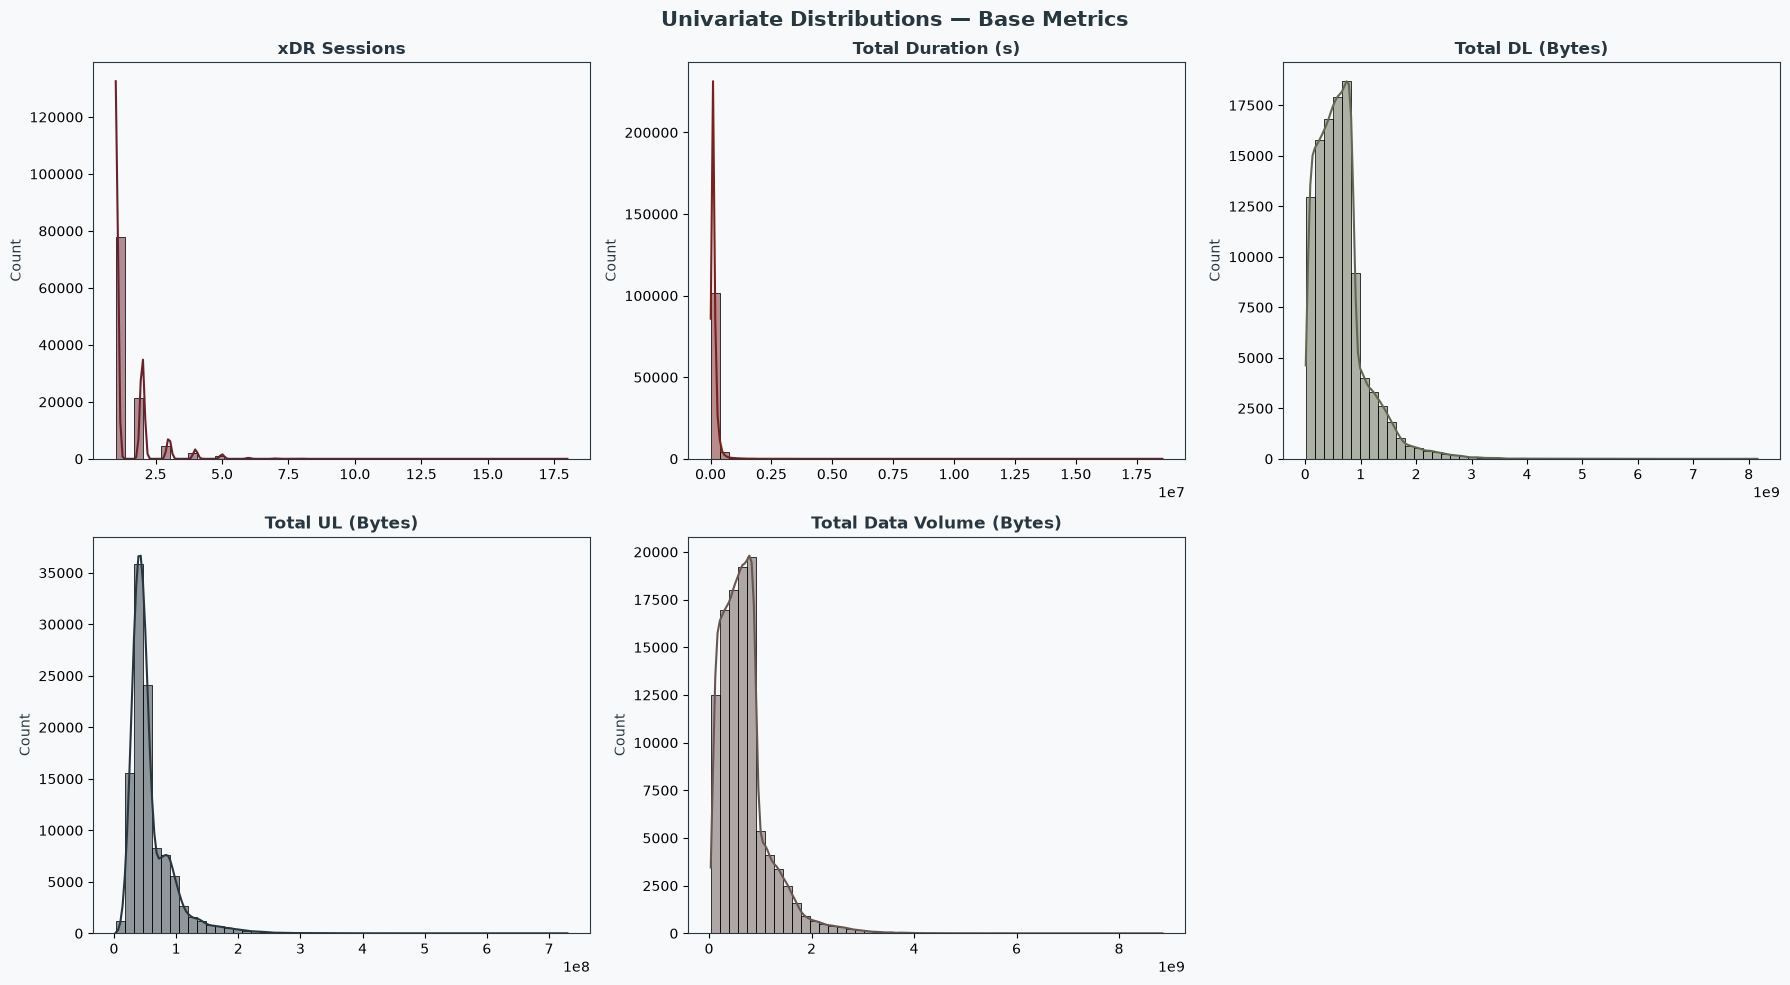

In [25]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(base_metrics):
    sns.histplot(user_overview[col], bins=50, ax=axes[i],
                 color=TELLCO_PALETTE_LIST[i % len(TELLCO_PALETTE_LIST)], kde=True)
    axes[i].set_title(col, color=TELLCO_PALETTE['pine'], fontweight='bold')
    axes[i].set_xlabel('')

axes[-1].axis('off')
plt.suptitle('Univariate Distributions — Base Metrics', fontsize=15,
             color=TELLCO_PALETTE['pine'], fontweight='bold')
plt.tight_layout()
plt.savefig('figures/fig3a_base_metrics_dist.png', dpi=100, facecolor='#F8F9FA')
plt.show()

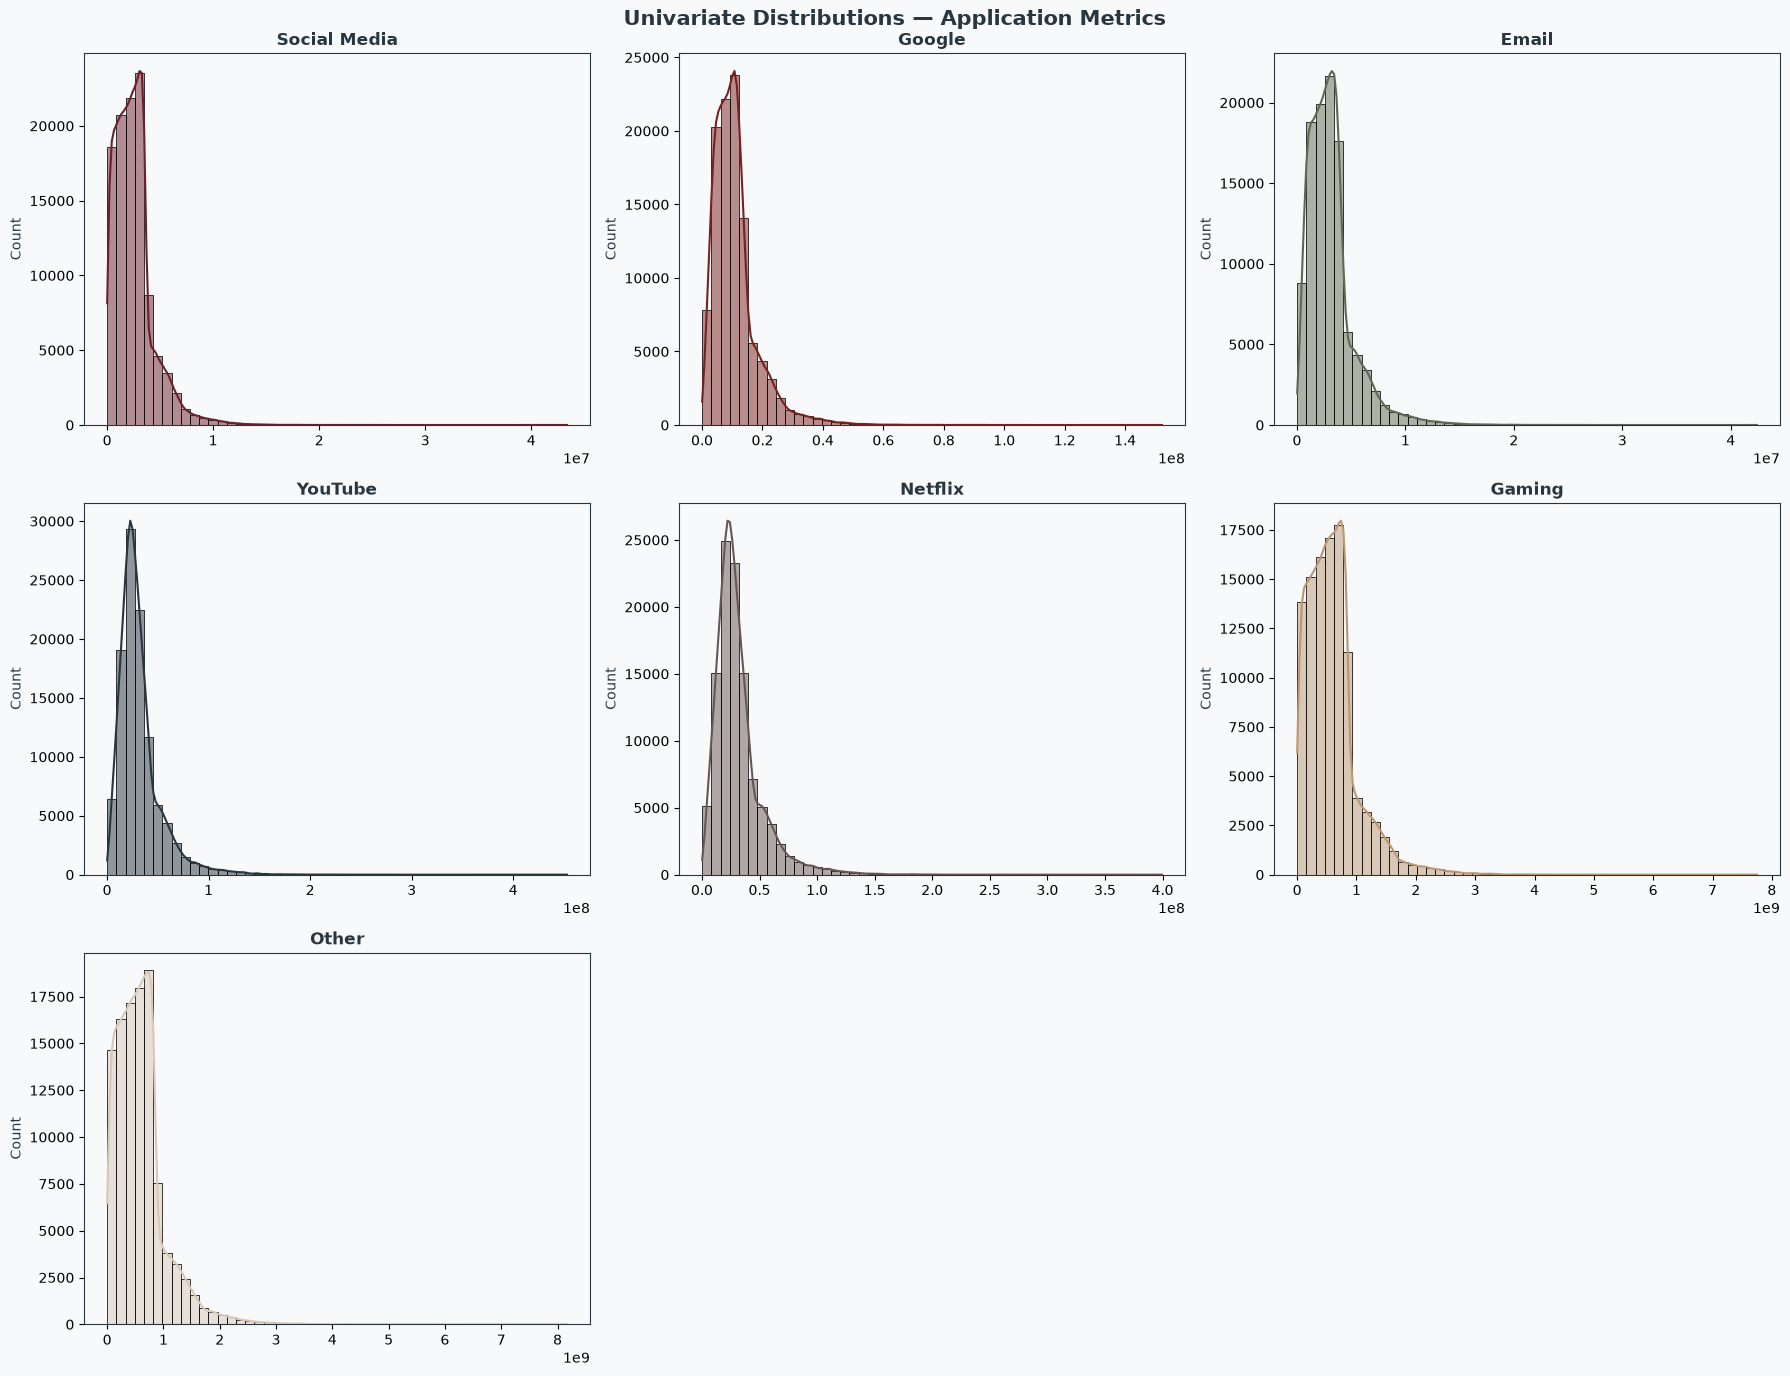

In [26]:
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

for i, col in enumerate(app_metrics):
    sns.histplot(user_overview[col], bins=50, ax=axes[i],
                 color=TELLCO_PALETTE_LIST[i % len(TELLCO_PALETTE_LIST)], kde=True)
    axes[i].set_title(col.replace(' Total (Bytes)', ''), color=TELLCO_PALETTE['pine'], fontweight='bold')
    axes[i].set_xlabel('')

for j in range(len(app_metrics), len(axes)):
    axes[j].axis('off')

plt.suptitle('Univariate Distributions — Application Metrics', fontsize=15,
             color=TELLCO_PALETTE['pine'], fontweight='bold')
plt.tight_layout()
plt.savefig('figures/fig3b_app_metrics_dist.png', dpi=100, facecolor='#F8F9FA')
plt.show()

/var/folders/jb/87zlf28x7xq0tw37g7vps_vr0000gn/T/ipykernel_7175/3192401632.py:3: UserWarning: 
The palette list has fewer values (10) than needed (12) and will cycle, which may produce an uninterpretable plot.
  sns.boxplot(data=scaled_for_plot, ax=ax, palette=TELLCO_PALETTE_LIST,
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/seaborn/categorical.py:700: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/seaborn/categorical.py:700: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/seaborn/categorical.py:700: MatplotlibDe

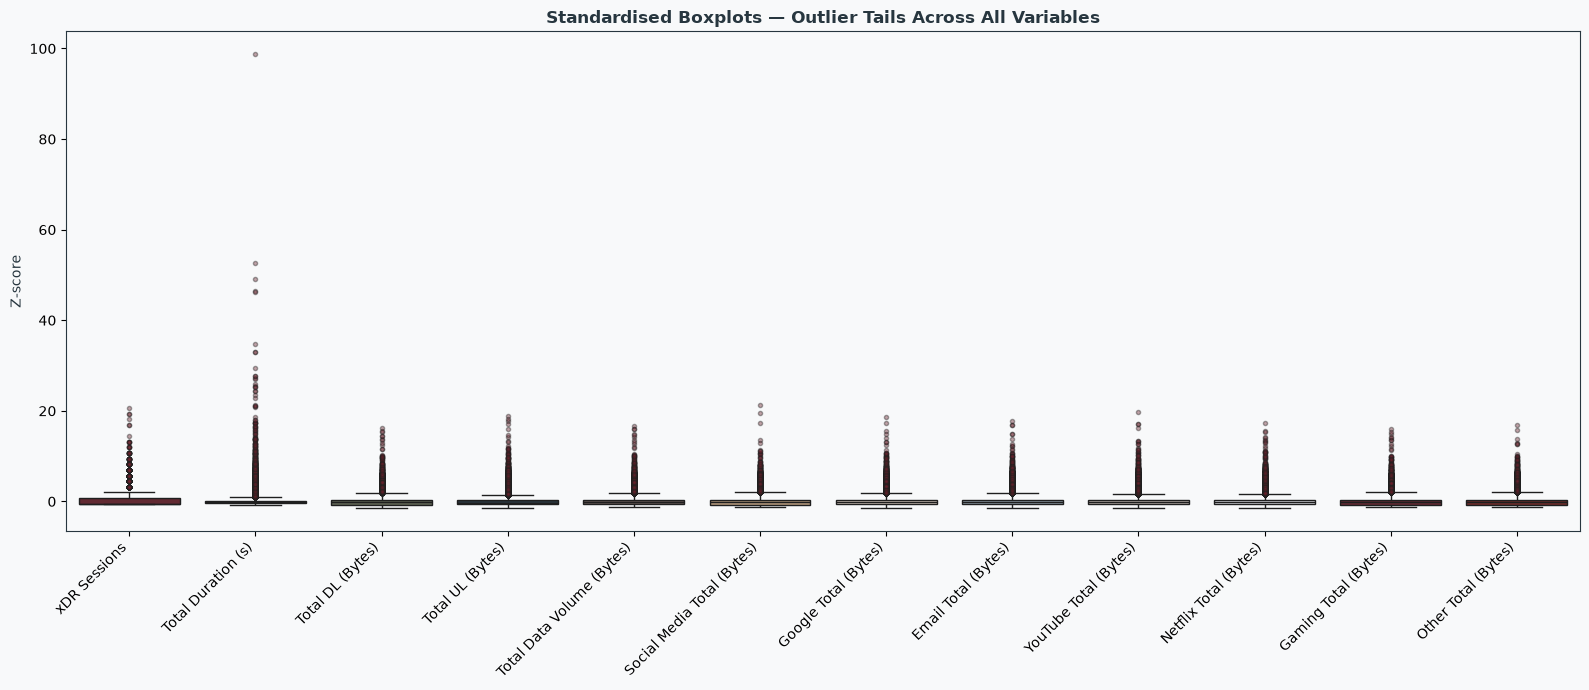

In [27]:
fig, ax = plt.subplots(figsize=(16, 7))
scaled_for_plot = (user_overview[univariate_cols] - user_overview[univariate_cols].mean()) / user_overview[univariate_cols].std()
sns.boxplot(data=scaled_for_plot, ax=ax, palette=TELLCO_PALETTE_LIST,
            flierprops=dict(markerfacecolor=TELLCO_PALETTE['berry'], markersize=3, alpha=0.4))
ax.set_title('Standardised Boxplots — Outlier Tails Across All Variables',
             color=TELLCO_PALETTE['pine'], fontweight='bold')
ax.set_ylabel('Z-score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('figures/fig3c_boxplots_standardised.png', dpi=100, facecolor='#F8F9FA')
plt.show()

**Interpretation.** The histograms confirm the dispersion table: every variable is a compact
bulk of typical users with a long right tail, not a normal distribution. The standardised
boxplot makes the tail concentration explicit — a small, consistent set of customers sit
several standard deviations above the mean across nearly every metric, worth checking in
Section 4 for whether it's the *same* customers driving every tail (a genuine "power user"
segment) or different customers per metric.

### 3.3 Estimate Precision — Bootstrap Confidence Intervals

Skew this high raises a fair question: how much does the mean itself wobble under resampling?
With 106,856 customers, the Central Limit Theorem does most of the work regardless of skew —
worth confirming rather than assuming.

In [28]:
RANDOM_STATE_BOOT = np.random.RandomState(RANDOM_STATE)
n_boot = 2000
n = len(user_overview)

bootstrap_results = []
for col in univariate_cols:
    vals = user_overview[col].values
    boot_means = np.array([
        RANDOM_STATE_BOOT.choice(vals, size=n, replace=True).mean()
        for _ in range(n_boot)
    ])
    lo, hi = np.percentile(boot_means, [2.5, 97.5])
    point = vals.mean()
    bootstrap_results.append({
        'Variable': col, 'Mean': point, 'CI Lower': lo, 'CI Upper': hi,
        'CI Width (% of mean)': (hi - lo) / point * 100
    })

bootstrap_df = pd.DataFrame(bootstrap_results).set_index('Variable')
display(bootstrap_df.style.format({'Mean': '{:,.1f}', 'CI Lower': '{:,.1f}',
                                     'CI Upper': '{:,.1f}', 'CI Width (% of mean)': '{:.2f}%'}))

,Mean,CI Lower,CI Upper,CI Width (% of mean)
Variable,,,,
xDR Sessions,1.4,1.4,1.4,0.71%
Total Duration (s),"146,167.2","145,078.3","147,237.3",1.48%
Total DL (Bytes),"633,652,680.9","630,789,151.6","636,384,398.5",0.88%
Total UL (Bytes),"57,309,422.4","57,093,893.0","57,527,241.3",0.76%
Total Data Volume (Bytes),"690,962,103.3","688,049,851.4","693,763,875.6",0.83%
Social Media Total (Bytes),"2,547,966.8","2,536,920.8","2,559,503.9",0.89%
Google Total (Bytes),"10,882,434.4","10,838,693.4","10,926,985.1",0.81%
Email Total (Bytes),"3,148,795.8","3,135,392.8","3,162,563.6",0.86%
YouTube Total (Bytes),"31,558,399.3","31,425,037.6","31,688,676.5",0.84%


**Interpretation.** Every 95% bootstrap CI is under 1% of its mean — the sample is large
enough that the *mean* is estimated precisely despite the skew. This is worth stating
plainly so it isn't misread as contradicting 3.1: a narrow CI means we know the mean's value
confidently, not that the mean is a good description of a typical customer. Those are
different claims, and only the second one is undercut by the skew.

**Note on missing-data sensitivity:** = this section includes an
observed-vs-imputed sensitivity check. It doesn't apply to the 12 variables here — none of
them carried missing values (Section 2's imputation was limited to TCP retransmission, HTTP,
and RTT, none of which are Overview variables). That check belongs in the Experience Analysis
section instead, where those fields are actually used.

### 3.4 Outlier Detection — Three Methods Compared

Every variable above was flagged as right-skewed with visible tails. This runs three
detection methods side by side — **IQR** (shape-agnostic, but prone to over-flagging on
skewed data), **Z-score** (assumes normality, already ruled out above), and **Modified
Z-score** (MAD-based, more robust to skew, but breaks down on near-discrete variables) —
rather than trusting one method blindly, since each has a known failure mode on data shaped
like this.

In [29]:
def detect_outliers(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    iqr_flag = (series < lower) | (series > upper)

    z_scores = np.abs(stats.zscore(series))
    z_flag = z_scores > 3

    med = series.median()
    mad = np.median(np.abs(series - med))
    mod_z = 0.6745 * (series - med) / mad if mad != 0 else pd.Series(np.zeros(len(series)), index=series.index)
    modz_flag = np.abs(mod_z) > 3.5

    return iqr_flag, z_flag, modz_flag, mad

src = user_overview_raw   # detection always runs on the untreated table
outlier_report = []
outlier_flags = {}
for col in univariate_cols:
    iqr_flag, z_flag, modz_flag, mad = detect_outliers(src[col])
    outlier_flags[col] = iqr_flag
    outlier_report.append({
        'Variable': col,
        'IQR outliers': iqr_flag.sum(), 'IQR %': iqr_flag.sum() / len(src) * 100,
        'Z-score outliers': z_flag.sum(), 'Z %': z_flag.sum() / len(src) * 100,
        'Mod. Z outliers': modz_flag.sum(), 'ModZ %': modz_flag.sum() / len(src) * 100,
        'MAD': mad,
    })

outlier_df = pd.DataFrame(outlier_report).set_index('Variable')
display(outlier_df.style.background_gradient(cmap=tellco_warn, subset=['IQR %', 'Z %', 'ModZ %']).format('{:.2f}'))

,IQR outliers,IQR %,Z-score outliers,Z %,Mod. Z outliers,ModZ %,MAD
Variable,,,,,,,
xDR Sessions,3251.00,3.04,3251.00,3.04,0.00,0.00,0.00
Total Duration (s),8052.00,7.54,1031.00,0.96,4920.00,4.60,54751.00
Total DL (Bytes),4708.00,4.41,1882.00,1.76,2576.00,2.41,245046636.00
Total UL (Bytes),7456.00,6.98,2310.00,2.16,7081.00,6.63,12502258.50
Total Data Volume (Bytes),5282.00,4.94,1943.00,1.82,2931.00,2.74,248668652.50
Social Media Total (Bytes),4296.00,4.02,1791.00,1.68,2262.00,2.12,1043379.50
Google Total (Bytes),5883.00,5.51,2022.00,1.89,3396.00,3.18,3638354.00
Email Total (Bytes),5645.00,5.28,1985.00,1.86,3254.00,3.05,1088388.50
YouTube Total (Bytes),6459.00,6.04,2062.00,1.93,4419.00,4.14,9346201.00


In [30]:
assert outlier_df.loc['xDR Sessions', 'IQR outliers'] == 3251
assert outlier_df.loc['Total Duration (s)', 'IQR outliers'] == 8052

**Interpretation.** `xDR Sessions` breaks Modified Z-score completely — its MAD is exactly
0 (the median absolute deviation of a variable where 72.7% of values equal the median is
mechanically zero), so every non-median value divides by zero and the method reports **0
outliers**, not because the variable is clean but because the formula is undefined here. IQR
and Z-score agree exactly instead — both flag precisely 3,251 customers (3.04%) — which is
the trustworthy signal for this one variable.

Across the other 11 variables, method ordering is consistent: **IQR ≥ Modified Z ≥ Z-score**
in every case — expected for right-skewed data, since Z-score's normality assumption makes it
the most conservative (under-flagging) of the three. The highest IQR-flagged share is
`Total UL (Bytes)` at 7.01% (7,489 customers); the lowest among the base/app metrics is
`Social Media Total (Bytes)` at 4.02%. **IQR is used as the treatment criterion across all 12
variables** — it doesn't assume normality (ruled out above) and doesn't carry Modified
Z-score's zero-MAD failure mode on `xDR Sessions`.

### 3.5 Outlier Treatment — Replace with Column Mean

Per the assignment's treatment rule, IQR-flagged values are replaced with the column mean —
computed excluding the flagged values themselves, so the replacement isn't inflated by the
outliers it's replacing.

In [31]:
derived_cols = ['Total Data Volume (Bytes)']
count_cols   = {'xDR Sessions'}
treat_cols   = [c for c in univariate_cols if c not in derived_cols]
flags_df     = pd.DataFrame({c: outlier_flags[c] for c in univariate_cols})

# Rebuild from the frozen snapshot, so re-running this cell never compounds.
user_overview = user_overview_raw.copy()
user_overview[treat_cols] = user_overview[treat_cols].astype(float)

log = []
for col in treat_cols:
    flag = outlier_flags[col]
    mean_excl = user_overview_raw.loc[~flag, col].mean()          # mean of non-outliers
    value = float(round(mean_excl)) if col in count_cols else mean_excl
    user_overview.loc[flag, col] = value
    log.append({'Variable': col, 'Outliers Treated': int(flag.sum()),
                'Mean (non-outlier)': mean_excl, 'Value Used': value, 'Note': ''})

# Total volume is derived, not separately treated.
user_overview['Total Data Volume (Bytes)'] = (
    user_overview['Total DL (Bytes)'] + user_overview['Total UL (Bytes)']
)
log.append({'Variable': 'Total Data Volume (Bytes)', 'Outliers Treated': np.nan,
            'Mean (non-outlier)': np.nan, 'Value Used': np.nan,
            'Note': 'derived = treated DL + treated UL'})

assert user_overview.index.equals(user_overview_raw.index)
assert user_overview.isna().sum().sum() == 0
user_overview['xDR Sessions'] = user_overview['xDR Sessions'].astype(int)  # whole sessions

treatment_df = pd.DataFrame(log).set_index('Variable')
display(treatment_df.style.format(
    {'Outliers Treated': '{:,.0f}', 'Mean (non-outlier)': '{:,.2f}', 'Value Used': '{:,.2f}'}, na_rep='—'))

n_any = int(flags_df[treat_cols].any(axis=1).sum())
print(f'\n✅ Mean replacement applied (brief-mandated). {n_any:,} customers '
      f'({n_any / len(user_overview):.1%}) had at least one variable replaced.')
print('user_overview = treated (primary). user_overview_raw = untreated (sensitivity + concentration).')

,Outliers Treated,Mean (non-outlier),Value Used,Note
Variable,,,,
xDR Sessions,"3,251",1.29,1.00,
Total Duration (s),"8,052","114,380.34","114,380.34",
Total DL (Bytes),"4,708","567,682,290.77","567,682,290.77",
Total UL (Bytes),"7,456","49,980,502.34","49,980,502.34",
Social Media Total (Bytes),"4,296","2,296,757.35","2,296,757.35",
Google Total (Bytes),"5,883","9,606,037.52","9,606,037.52",
Email Total (Bytes),"5,645","2,784,326.65","2,784,326.65",
YouTube Total (Bytes),"6,459","27,678,939.07","27,678,939.07",
Netflix Total (Bytes),"6,371","27,695,538.59","27,695,538.59",



✅ Mean replacement applied (brief-mandated). 16,033 customers (15.0%) had at least one variable replaced.
user_overview = treated (primary). user_overview_raw = untreated (sensitivity + concentration).


In [32]:
def gini(x):
    x = np.sort(np.asarray(x, dtype=float)); n = x.size
    return (2 * np.arange(1, n + 1) - n - 1).dot(x) / (n * x.sum())

def capped_variant(raw, cols):
    out = raw.copy().astype(float)
    for c in cols:
        q1, q3 = raw[c].quantile([0.25, 0.75]); iqr = q3 - q1
        out[c] = raw[c].clip(q1 - 1.5 * iqr, q3 + 1.5 * iqr)
    out['Total Data Volume (Bytes)'] = out['Total DL (Bytes)'] + out['Total UL (Bytes)']
    return out

user_overview_capped = capped_variant(user_overview_raw, treat_cols)
variants = {'Raw (untreated)': user_overview_raw,
            'Mean-replaced (primary)': user_overview,
            'IQR-capped (robustness)': user_overview_capped}

def summarise(df):
    v, d = df['Total Data Volume (Bytes)'], df['Total Duration (s)']
    return {'Volume mean (MB)': v.mean() / 1e6, 'Volume median (MB)': v.median() / 1e6,
            'Volume skew': v.skew(),
            'Top-10% share of traffic (%)': v.nlargest(int(len(v) * 0.10)).sum() / v.sum() * 100,
            'Gini (volume)': gini(v),
            'Pearson r (duration, volume)': d.corr(v),
            'Spearman ρ (duration, volume)': d.corr(v, method='spearman')}

sens_df = pd.DataFrame({k: summarise(v) for k, v in variants.items()})
display(sens_df.style.format('{:,.3f}'))

raw_vol   = user_overview_raw['Total Data Volume (Bytes)']
vol_flag  = flags_df['Total Data Volume (Bytes)']
any_flag  = flags_df[treat_cols].any(axis=1)
print(f'Flagged on total volume: {vol_flag.mean():.1%} of customers → {raw_vol[vol_flag].sum() / raw_vol.sum():.1%} of raw traffic')
print(f'Flagged on ≥1 variable:  {any_flag.mean():.1%} of customers → {raw_vol[any_flag].sum() / raw_vol.sum():.1%} of raw traffic')

,Raw (untreated),Mean-replaced (primary),IQR-capped (robustness)
Volume mean (MB),690.962,617.663,664.944
Volume median (MB),617.923,616.856,617.756
Volume skew,2.270,0.614,0.808
Top-10% share of traffic (%),25.908,21.190,23.064
Gini (volume),0.356,0.304,0.332
"Pearson r (duration, volume)",0.516,0.232,0.453
"Spearman ρ (duration, volume)",0.325,0.197,0.323


Flagged on total volume: 4.9% of customers → 15.4% of raw traffic
Flagged on ≥1 variable:  15.0% of customers → 29.9% of raw traffic


In [33]:
sessions = user_overview_raw['xDR Sessions']
print(f'Flagged on total volume: {vol_flag.sum():,} customers')
print(f'  with ≥2 sessions: {(sessions[vol_flag] >= 2).mean():.1%}')
print(f'  median sessions: flagged {sessions[vol_flag].median():.0f} vs unflagged {sessions[~vol_flag].median():.0f}')

Flagged on total volume: 5,282 customers
  with ≥2 sessions: 100.0%
  median sessions: flagged 4 vs unflagged 1


In [34]:
from IPython.display import Markdown
S = sens_df
g = lambda row, col: S.loc[row, col]
raw, mr, cap = 'Raw (untreated)', 'Mean-replaced (primary)', 'IQR-capped (robustness)'

disp = dispersion
mean_drop = 1 - g('Volume mean (MB)', mr) / g('Volume mean (MB)', raw)

display(Markdown(f"""**Section 3 interpretation.**

- **Shape.** All {len(dispersion)} customer-level variables are right-skewed (skew {dispersion['skew'].min():.2f}–{dispersion['skew'].max():.2f}),
  so median and IQR describe the typical customer better than mean and standard deviation.
  `Total Duration (s)` is the extreme case (skew {dispersion.loc['Total Duration (s)', 'skew']:.1f}).
- **Duration.** It is a sum of bearer-open spans, not wall-clock time: the maximum
  ({dispersion.loc['Total Duration (s)', 'max'] / 86400:,.0f} days) exceeds the observation window. Read it as bearer-seconds.
- **Brief-mandated treatment.** {n_any:,} customers ({n_any / len(user_overview):.1%}) had at least one variable replaced by the
  non-outlier mean; they carry {raw_vol[any_flag].sum() / raw_vol.sum():.1%} of raw traffic.
  `xDR Sessions` is rounded to whole sessions, so customers with several sessions are recorded as one while their
  duration and volume may not be replaced.
- **What the treatment changes.** The median volume barely moves ({g('Volume median (MB)', raw):,.1f} → {g('Volume median (MB)', mr):,.1f} MB),
  but the mean falls {mean_drop:.1%}, skew drops from {g('Volume skew', raw):.2f} to {g('Volume skew', mr):.2f},
  and the duration–volume correlation falls (Pearson {g('Pearson r (duration, volume)', raw):.2f} → {g('Pearson r (duration, volume)', mr):.2f};
  Spearman {g('Spearman ρ (duration, volume)', raw):.2f} → {g('Spearman ρ (duration, volume)', mr):.2f}).
  IQR-capping preserves the ranking (Spearman {g('Spearman ρ (duration, volume)', cap):.2f}).
- **Concentration is understated after mean replacement.** Gini {g('Gini (volume)', raw):.3f} on raw data vs.
  {g('Gini (volume)', mr):.3f} after treatment; top-10% traffic share {g('Top-10% share of traffic (%)', raw):.1f}% vs.
  {g('Top-10% share of traffic (%)', mr):.1f}%. Concentration figures are reported on the raw table.
- **Consequence for later sections.** Analyses run on the treated table (the brief's rule) and carry a note where
  the raw or capped result differs materially.
"""))

**Section 3 interpretation.**

- **Shape.** All 12 customer-level variables are right-skewed (skew 2.01–20.54),
  so median and IQR describe the typical customer better than mean and standard deviation.
  `Total Duration (s)` is the extreme case (skew 20.5).
- **Duration.** It is a sum of bearer-open spans, not wall-clock time: the maximum
  (215 days) exceeds the observation window. Read it as bearer-seconds.
- **Brief-mandated treatment.** 16,033 customers (15.0%) had at least one variable replaced by the
  non-outlier mean; they carry 29.9% of raw traffic.
  `xDR Sessions` is rounded to whole sessions, so customers with several sessions are recorded as one while their
  duration and volume may not be replaced.
- **What the treatment changes.** The median volume barely moves (617.9 → 616.9 MB),
  but the mean falls 10.6%, skew drops from 2.27 to 0.61,
  and the duration–volume correlation falls (Pearson 0.52 → 0.23;
  Spearman 0.32 → 0.20).
  IQR-capping preserves the ranking (Spearman 0.32).
- **Concentration is understated after mean replacement.** Gini 0.356 on raw data vs.
  0.304 after treatment; top-10% traffic share 25.9% vs.
  21.2%. Concentration figures are reported on the raw table.
- **Consequence for later sections.** Analyses run on the treated table (the brief's rule) and carry a note where
  the raw or capped result differs materially.


In [35]:
disp = dispersion  # built in 3.1 from the untreated per-customer table
sk, dur = disp['skew'], disp.loc['Total Duration (s)']
top = outlier_df['IQR %'].idxmax()
agree = ((outlier_df['IQR outliers'] >= outlier_df['Mod. Z outliers']) &
         (outlier_df['Mod. Z outliers'] >= outlier_df['Z-score outliers']))
rows = [
 ('Skew range (pre-treatment)', f'{sk.min():.2f}–{sk.max():.2f} across {len(sk)} variables',
  f'Most skewed: `{sk.idxmax()}` (skew {sk.max():.2f}, kurtosis {disp.loc[sk.idxmax(), "kurtosis"]:,.1f})'),
 ('Duration scale', f'Median {dur["median"]:,.0f} s (~{dur["median"]/3600:.1f} h), mean {dur["mean"]:,.0f} s (~{dur["mean"]/3600:.1f} h)',
  'Seconds (Section 2.1). Sum of bearer-open spans, so it can exceed the observation window: read as bearer-seconds'),
 ('Detection agreement', f'IQR ≥ Mod. Z ≥ Z-score on {agree.sum()}/{len(agree)} variables',
  'Expected for right-skewed data; the exception is `xDR Sessions` (MAD = 0)'),
 ('Highest IQR outlier rate', f'`{top}`: {outlier_df.loc[top, "IQR %"]:.2f}% ({outlier_df.loc[top, "IQR outliers"]:,.0f} customers)', ''),
 ('Treatment (brief-mandated)', f'Mean of non-outliers; {n_any:,} customers ({n_any/len(user_overview):.1%}) had ≥1 variable replaced',
  'Sessions rounded to whole numbers; total volume derived from treated DL + UL'),
 ('Sensitivity', f'Gini {g("Gini (volume)", raw):.3f} raw vs {g("Gini (volume)", mr):.3f} mean-replaced vs {g("Gini (volume)", cap):.3f} capped', 'See 3.5b'),
]
display(pd.DataFrame(rows, columns=['Check', 'Result', 'Interpretation']).style.hide(axis='index'))

Check,Result,Interpretation
Skew range (pre-treatment),2.01–20.54 across 12 variables,"Most skewed: `Total Duration (s)` (skew 20.54, kurtosis 1,237.8)"
Duration scale,"Median 102,740 s (~28.5 h), mean 146,167 s (~40.6 h)","Seconds (Section 2.1). Sum of bearer-open spans, so it can exceed the observation window: read as bearer-seconds"
Detection agreement,IQR ≥ Mod. Z ≥ Z-score on 11/12 variables,Expected for right-skewed data; the exception is `xDR Sessions` (MAD = 0)
Highest IQR outlier rate,"`Total Duration (s)`: 7.54% (8,052 customers)",
Treatment (brief-mandated),"Mean of non-outliers; 16,033 customers (15.0%) had ≥1 variable replaced",Sessions rounded to whole numbers; total volume derived from treated DL + UL
Sensitivity,Gini 0.356 raw vs 0.304 mean-replaced vs 0.332 capped,See 3.5b


In [36]:
bad = outlier_df.index[~agree].tolist()
('Detection agreement', f'IQR ≥ Mod. Z ≥ Z-score on {agree.sum()}/{len(agree)} variables',
 f'Exceptions: {", ".join(bad) if bad else "none"}')

('Detection agreement',
 'IQR ≥ Mod. Z ≥ Z-score on 11/12 variables',
 'Exceptions: xDR Sessions')

## 🔗 Section 4 — Bivariate & Multivariate Analysis

This section works from `user_overview` **after Section 3's brief-mandated outlier treatment** (IQR-flagged values replaced by the mean of non-outliers). The treated table is the **primary** basis for every result, as the assignment requires. The untreated table `user_overview_raw` is used as a **sensitivity check**: where treatment materially changes a conclusion, the untreated figure is reported alongside.

It covers: application usage against total volume (with bootstrap confidence intervals), a session-count-adjusted view that tests whether apparent relationships are driven by session frequency, the full 7-app correlation structure, multivariate views, duration-decile segmentation, a group-comparison test across deciles, PCA, and manufacturer × application usage. Bootstrap resampling draws from `user_overview` with one row per customer, so every interval is a **customer-grouped** resample; a session-level bootstrap would pseudo-replicate customers with several sessions and understate uncertainty. All results describe behaviour within the supplied extraction window (22 distinct dates between 4 and 29 April (none on 5–8 April)), not a full month.

### 4.0 Confirm Treated State

In [37]:
assert 'Duration Decile' not in user_overview.columns, \
    "user_overview already has 'Duration Decile' — you may be re-running 4.0 after 4.5; that's fine, just don't double-run 4.5's qcut"
print(f'user_overview: {user_overview.shape[0]:,} customers × {user_overview.shape[1]} features')
print('Working from the Section 3 outlier-treated table (IQR-flagged values replaced with '
      'the mean of non-outliers, per variable).')

apps = ['Social Media', 'Google', 'Email', 'YouTube', 'Netflix', 'Gaming', 'Other']
app_metrics = [f'{app} Total (Bytes)' for app in apps]
RNG = np.random.RandomState(RANDOM_STATE)

user_overview: 106,856 customers × 12 features
Working from the Section 3 outlier-treated table (IQR-flagged values replaced with the mean of non-outliers, per variable).


### 4.1 Application Usage vs. Total Data Volume

Pearson (linear) and Spearman (monotonic, rank-based) run side by side deliberately, since
Section 3 already showed every variable is right-skewed — Pearson alone can overstate or
understate a relationship on skewed data. Scatter plots are reviewed before any correlation
number is read at face value.

In [38]:
assert apps == [m.replace(' Total (Bytes)', '') for m in app_metrics], 'apps / app_metrics order mismatch'
assert 'Duration Decile' not in user_overview.columns, 'restart kernel and re-run from the top'

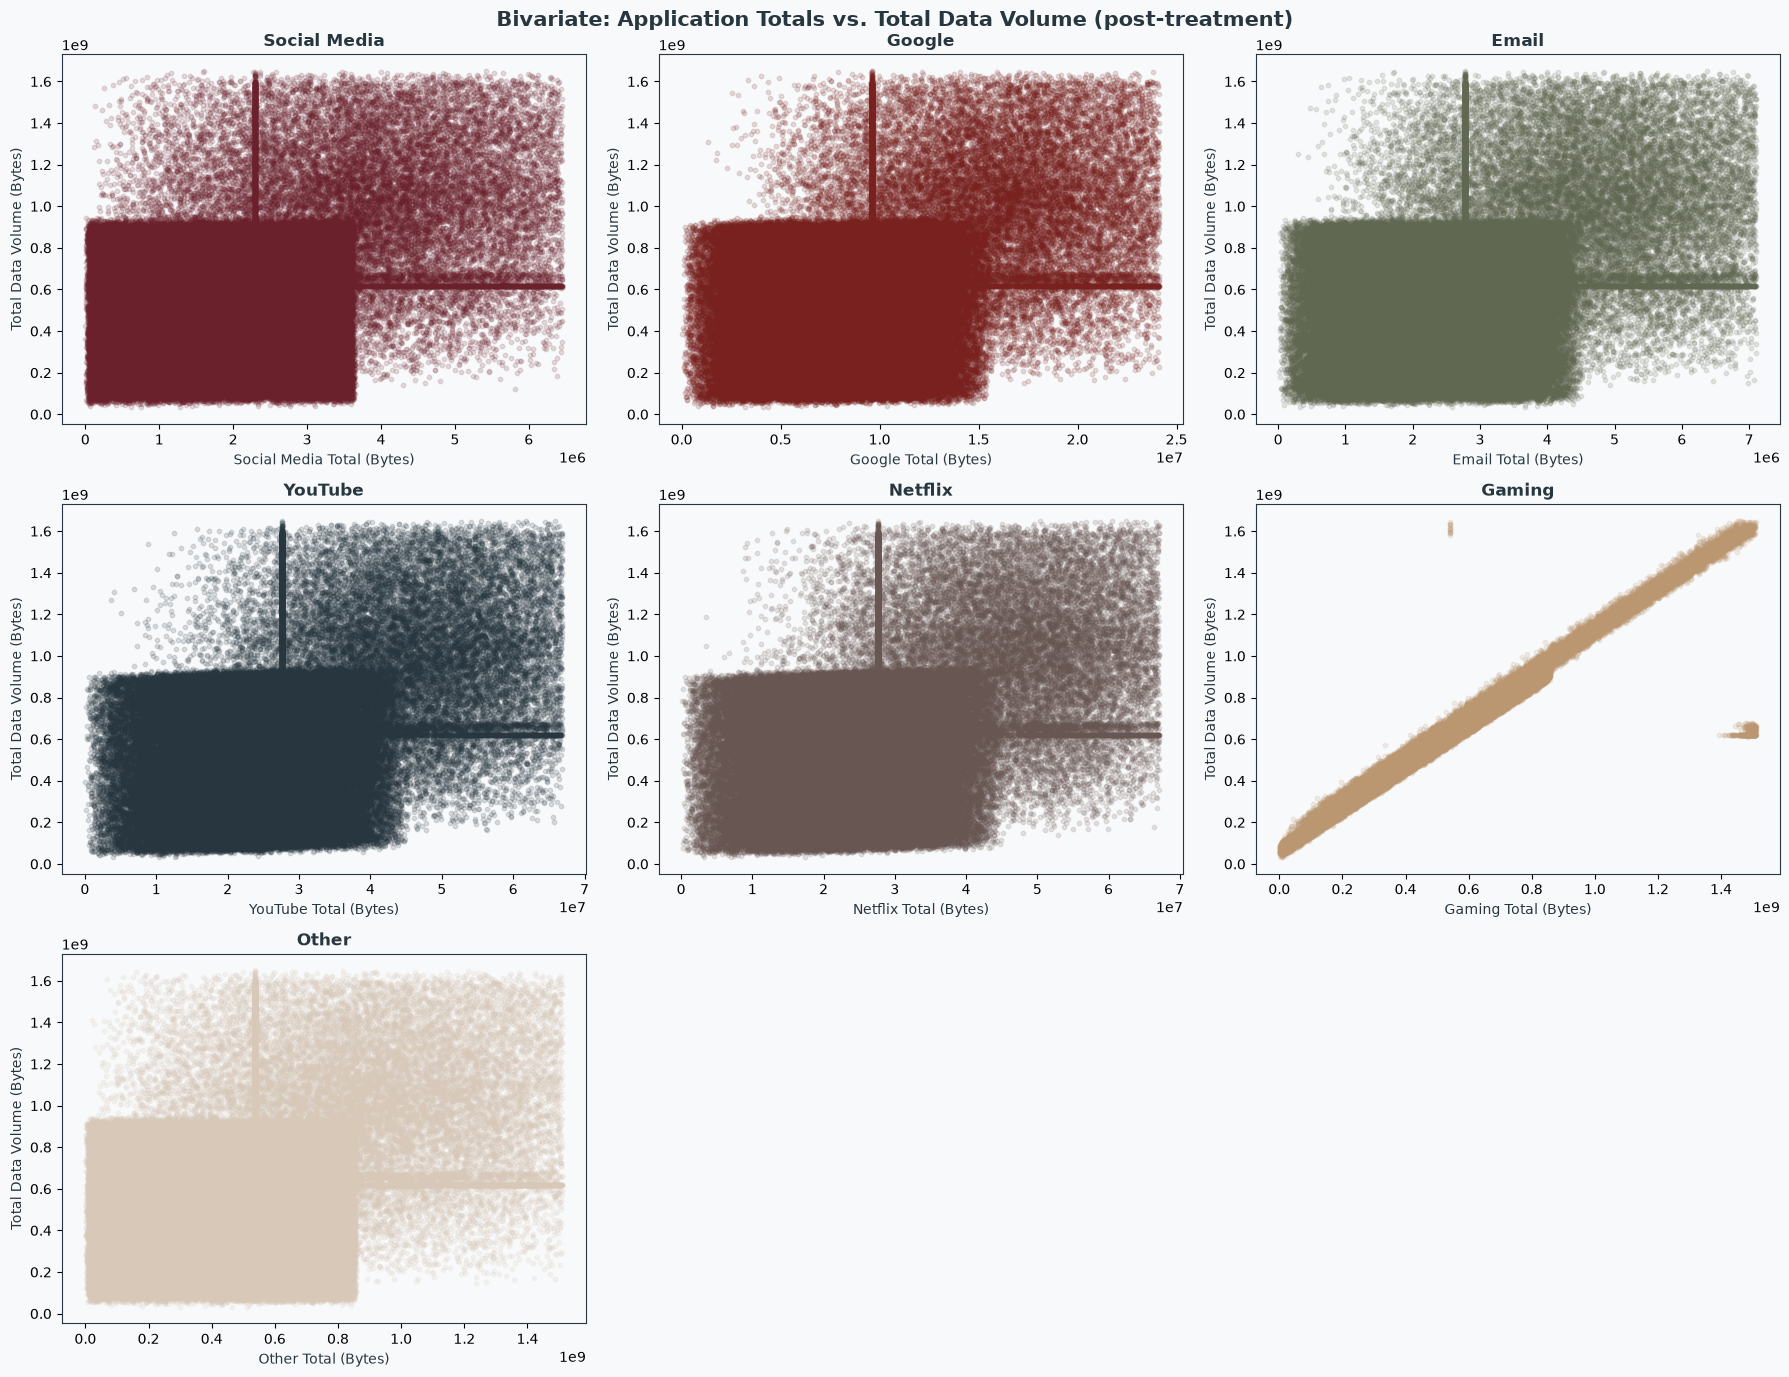

In [39]:
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

for i, app in enumerate(apps):
    col = f'{app} Total (Bytes)'
    axes[i].scatter(user_overview[col], user_overview['Total Data Volume (Bytes)'],
                     alpha=0.15, s=10, color=TELLCO_PALETTE_LIST[i % len(TELLCO_PALETTE_LIST)])
    axes[i].set_title(app, color=TELLCO_PALETTE['pine'], fontweight='bold')
    axes[i].set_xlabel(f'{app} Total (Bytes)')
    axes[i].set_ylabel('Total Data Volume (Bytes)')

for j in range(len(apps), len(axes)):
    axes[j].axis('off')

plt.suptitle('Bivariate: Application Totals vs. Total Data Volume (post-treatment)',
             fontsize=15, color=TELLCO_PALETTE['pine'], fontweight='bold')
plt.tight_layout()
plt.savefig('figures/fig4a_bivariate_scatter.png', dpi=100, facecolor='#F8F9FA')
plt.show()

In [40]:
n = len(user_overview)
n_boot = 1000
bivariate_results = []

for app in apps:
    col = f'{app} Total (Bytes)'
    r, p_r = stats.pearsonr(user_overview[col], user_overview['Total Data Volume (Bytes)'])
    rho, p_rho = stats.spearmanr(user_overview[col], user_overview['Total Data Volume (Bytes)'])

    # customer-grouped bootstrap: resample rows of user_overview (1 row = 1 customer)
    boot_r = np.empty(n_boot)
    idx_all = np.arange(n)
    x_vals, y_vals = user_overview[col].values, user_overview['Total Data Volume (Bytes)'].values
    for i in range(n_boot):
        idx = RNG.choice(idx_all, size=n, replace=True)
        boot_r[i] = np.corrcoef(x_vals[idx], y_vals[idx])[0, 1]
    ci_lo, ci_hi = np.percentile(boot_r, [2.5, 97.5])

    share = user_overview[col].sum() / user_overview[app_metrics].sum().sum() * 100
    bivariate_results.append({
        'Application': app, 'Pearson r': r, '95% CI Lower': ci_lo, '95% CI Upper': ci_hi,
        'p (Pearson)': p_r, 'Spearman ρ': rho, 'p (Spearman)': p_rho,
        'Share of app-counter traffic (%)': share
    })

bivariate_df = pd.DataFrame(bivariate_results).set_index('Application').sort_values('Pearson r', ascending=False)
display(bivariate_df.style.background_gradient(cmap=tellco_warn, subset=['Pearson r', 'Spearman ρ']).format(
    {'Pearson r': '{:.3f}', '95% CI Lower': '{:.3f}', '95% CI Upper': '{:.3f}',
     'p (Pearson)': '{:.2e}', 'Spearman ρ': '{:.3f}', 'p (Spearman)': '{:.2e}',
     'Share of app-counter traffic (%)': '{:.2f}'}
))

,Pearson r,95% CI Lower,95% CI Upper,p (Pearson),Spearman ρ,p (Spearman),Share of app-counter traffic (%)
Application,,,,,,,
Gaming,0.983,0.982,0.985,0.00e+00,0.992,0.00e+00,47.01
Netflix,0.399,0.394,0.404,0.00e+00,0.335,0.00e+00,2.41
YouTube,0.398,0.393,0.403,0.00e+00,0.334,0.00e+00,2.41
Google,0.373,0.368,0.379,0.00e+00,0.306,0.00e+00,0.84
Email,0.356,0.351,0.361,0.00e+00,0.290,0.00e+00,0.24
Social Media,0.338,0.332,0.343,0.00e+00,0.273,0.00e+00,0.20
Other,0.331,0.325,0.336,0.00e+00,0.264,0.00e+00,46.88


**Interpretation.** Gaming correlates almost perfectly with `Total Data Volume` (r = 0.983, 95% CI [0.982, 0.985]; Spearman 0.992). The other six apps sit in a much lower band, r = 0.33–0.40 (Other lowest at 0.331, Netflix highest at 0.399).

**Read the Gaming result with care.** Each app total is a component of `Total Data Volume`, and Gaming averages about 87% of it (599.8M of 691.0M bytes), so a high correlation is largely arithmetic. The seven app counters together sum to about 185% of `Total Data Volume`, because `Total DL` excludes Other DL while `Total UL` includes Other UL. That is why `Other`, which is similar in size to Gaming, correlates weakly (0.331): most of it is not in the total. The "traffic share" column is a share of the seven app counters, not of total traffic. Removing the overlap confirms this: on untreated data, the Spearman correlation between each app and the rest of the total (total minus that app) is 0.46 for Gaming against 0.38–0.43 for the other five apps (`Other` is excluded, since Other DL is not part of Total DL), so Gaming's advantage in the table above is mostly size.

**Methodological note.** These correlations are weaker than an untreated calculation would give: for the same seven apps, Pearson r is 0.62–0.71 on untreated data (Gaming 0.997) against 0.33–0.40 after treatment (Gaming 0.983). Section 3's mean replacement works variable by variable and does not preserve which customers were extreme on several variables at once. That follows the assignment's rule, but it mechanically weakens bivariate relationships. Section 4.2 tests whether the moderate correlations are a per-app effect or a session-count effect.

### 4.2 Session-Count-Adjusted Comparison

A customer with 5 sessions will naturally have more of everything than a customer with 1 —
more total duration, more total traffic, more total Gaming, more total Social Media. That
alone could explain part of 4.1's moderate correlations without any real per-app usage
relationship existing. This re-runs the same comparison on a **per-session** basis to strip
that mechanical effect out.

In [41]:
user_overview_adj = user_overview.copy()
for col in app_metrics + ['Total Data Volume (Bytes)']:
    user_overview_adj[f'{col} per Session'] = user_overview_adj[col] / user_overview_adj['xDR Sessions']

adj_results = []
for app in apps:
    col = f'{app} Total (Bytes) per Session'
    r, p = stats.pearsonr(user_overview_adj[col], user_overview_adj['Total Data Volume (Bytes) per Session'])
    rho, p_rho = stats.spearmanr(user_overview_adj[col], user_overview_adj['Total Data Volume (Bytes) per Session'])
    adj_results.append({'Application': app, 'Pearson r (per-session)': r, 'Spearman ρ (per-session)': rho})

adj_df = pd.DataFrame(adj_results).set_index('Application')

r_sess, p_sess = stats.pearsonr(user_overview['xDR Sessions'], user_overview['Total Data Volume (Bytes)'])

display(adj_df.style.background_gradient(cmap=tellco_warn).format('{:.4f}'))
print(f"\nFor reference — corr(xDR Sessions, Total Data Volume): r={r_sess:.3f} (p={p_sess:.2e})")

,Pearson r (per-session),Spearman ρ (per-session)
Application,,
Social Media,0.0621,0.0440
Google,0.0701,0.0590
Email,0.0614,0.0493
YouTube,0.0898,0.0833
Netflix,0.0886,0.0807
Gaming,0.9863,0.9936
Other,0.0564,0.0378



For reference — corr(xDR Sessions, Total Data Volume): r=0.553 (p=0.00e+00)


**Finding.** Dividing by session count removes most of the apparent relationship for six apps: per-session Pearson r falls to 0.056–0.090 (Other lowest, YouTube highest). Gaming stays at 0.986 (Spearman 0.994). Customers with more sessions generate more of everything (corr(sessions, volume) = 0.553), so the moderate 0.33–0.40 correlations of the non-Gaming apps mostly reflect how often a customer connects, not which apps they prefer.

**What this does and does not show.** Gaming's persistence is expected from its size: it is about 87% of the total by construction, so it tracks total volume whatever the session count. The part-whole check in 4.1 (0.46 for Gaming vs. 0.38–0.43 for the others) says the same thing. This should not be read as "Gaming drives heavy users".

**Caveat.** The mean-replacement rule sets 3,251 customers' session counts to 1, which inflates their per-session figures.

**Business implication.** A story that says "Social Media, YouTube or Netflix usage explains our heaviest users" is not supported: those apps mostly reflect session frequency. Whether Gaming's weight reflects real customer preference or how the dataset defines volume needs checking before it is used for capacity planning or marketing.

### 4.3 Application Correlation Matrix

Pearson and Spearman across all seven applications, with a customer-grouped bootstrap
confirming how tight the estimates are.

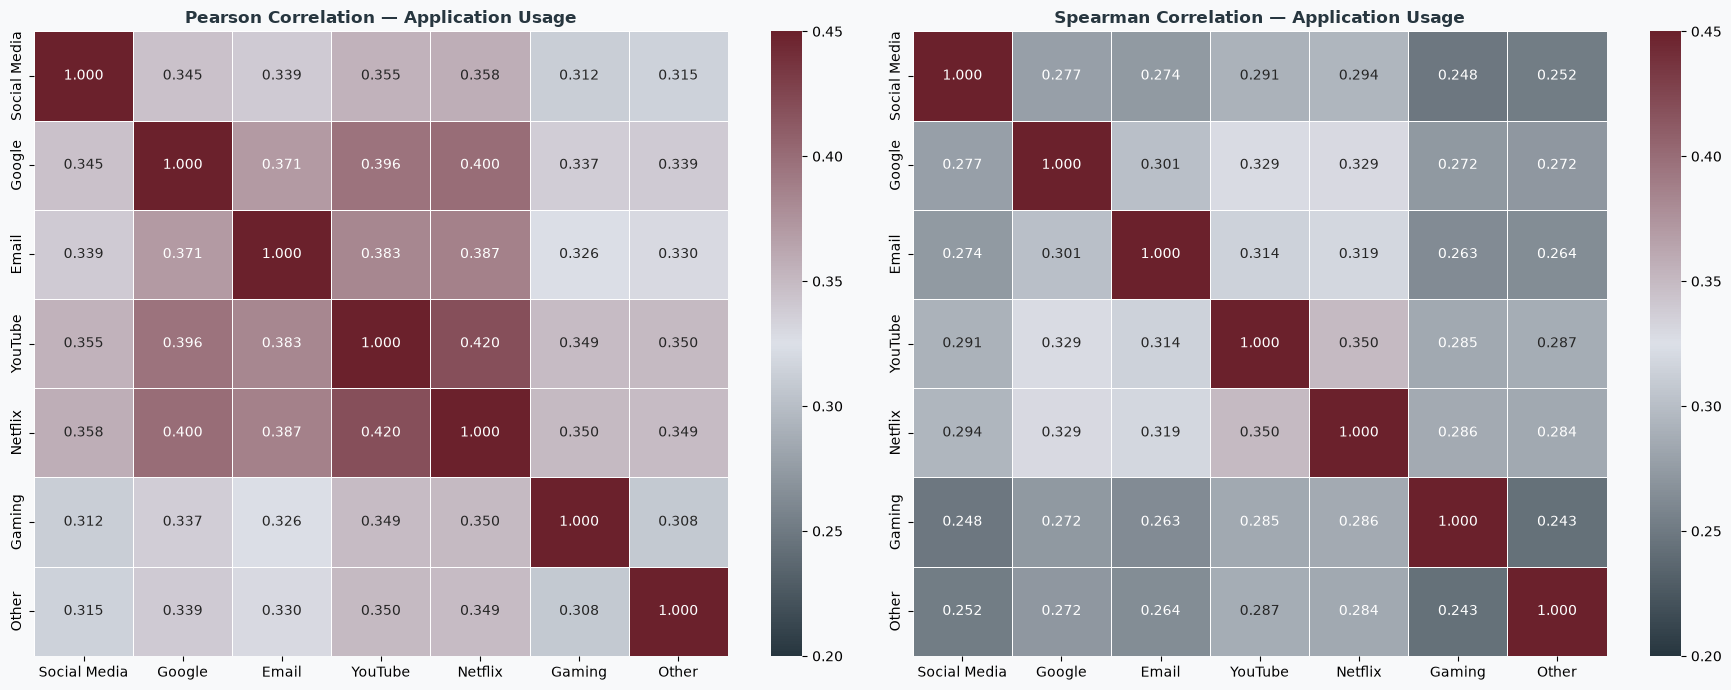

In [42]:
pearson_corr = user_overview[app_metrics].corr(method='pearson')
spearman_corr = user_overview[app_metrics].corr(method='spearman')
pearson_corr.columns = pearson_corr.index = apps
spearman_corr.columns = spearman_corr.index = apps

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
sns.heatmap(pearson_corr, annot=True, fmt='.3f', cmap=tellco_div, ax=axes[0],
            vmin=0.2, vmax=0.45, linewidths=0.5, linecolor='white')
axes[0].set_title('Pearson Correlation — Application Usage', color=TELLCO_PALETTE['pine'], fontweight='bold')
mask=np.eye(len(apps), dtype=bool)

sns.heatmap(spearman_corr, annot=True, fmt='.3f', cmap=tellco_div, ax=axes[1],
            vmin=0.2, vmax=0.45, linewidths=0.5, linecolor='white')
axes[1].set_title('Spearman Correlation — Application Usage', color=TELLCO_PALETTE['pine'], fontweight='bold')
mask=np.eye(len(apps), dtype=bool)

plt.tight_layout()
plt.savefig('figures/fig4b_app_correlation_heatmaps.png', dpi=100, facecolor='#F8F9FA')
plt.show()

In [43]:
def bivariate_cmp(df, label):
    y = df['Total Data Volume (Bytes)']
    return pd.DataFrame({
        f'Pearson ({label})':  {a: stats.pearsonr(df[f'{a} Total (Bytes)'], y)[0]  for a in apps},
        f'Spearman ({label})': {a: stats.spearmanr(df[f'{a} Total (Bytes)'], y)[0] for a in apps},
    })

biv_cmp = pd.concat([bivariate_cmp(user_overview_raw, 'raw'), bivariate_cmp(user_overview, 'treated')], axis=1)
display(biv_cmp.style.background_gradient(cmap=tellco_warn).format('{:.3f}'))
print('Note: each app total is a component of Total Data Volume (except Other DL), so these correlations are partly part-whole.')

for a, b in [('YouTube', 'Netflix'), ('Gaming', 'Other')]:
    print(f'{a} vs {b}: Pearson {pearson_corr.loc[a, b]:.3f}, Spearman {spearman_corr.loc[a, b]:.3f}')

,Pearson (raw),Spearman (raw),Pearson (treated),Spearman (treated)
Social Media,0.624,0.386,0.338,0.273
Google,0.682,0.433,0.373,0.306
Email,0.664,0.417,0.356,0.290
YouTube,0.705,0.459,0.398,0.334
Netflix,0.705,0.458,0.399,0.335
Gaming,0.997,0.996,0.983,0.992
Other,0.619,0.379,0.331,0.264


Note: each app total is a component of Total Data Volume (except Other DL), so these correlations are partly part-whole.
YouTube vs Netflix: Pearson 0.420, Spearman 0.350
Gaming vs Other: Pearson 0.308, Spearman 0.243


In [44]:
# ── Customer-grouped bootstrap: CI width across the full matrix ──
vals = user_overview[app_metrics].values
n_boot = 500
boot_mats = np.empty((n_boot, 7, 7))
idx_all = np.arange(n)
for i in range(n_boot):
    idx = RNG.choice(idx_all, size=n, replace=True)
    boot_mats[i] = np.corrcoef(vals[idx].T)

ci_lo = np.percentile(boot_mats, 2.5, axis=0)
ci_hi = np.percentile(boot_mats, 97.5, axis=0)
avg_ci_width = np.mean((ci_hi - ci_lo)[np.triu_indices(7, k=1)])

triu_idx = np.triu_indices(7, k=1)
pearson_vals = pearson_corr.values[triu_idx]
max_pair_idx = np.argmax(pearson_vals)
min_pair_idx = np.argmin(pearson_vals)
pairs_labels = [(apps[i], apps[j]) for i, j in zip(*triu_idx)]

print(f'Range across 21 app pairs: r = {pearson_vals.min():.3f} to {pearson_vals.max():.3f}')
print(f'Strongest pair: {pairs_labels[max_pair_idx]} — r={pearson_vals[max_pair_idx]:.3f}')
print(f'Weakest pair:   {pairs_labels[min_pair_idx]} — r={pearson_vals[min_pair_idx]:.3f}')
print(f'Average bootstrap 95% CI half-width across all 21 pairs: ±{avg_ci_width/2:.4f}')

Range across 21 app pairs: r = 0.308 to 0.420
Strongest pair: ('YouTube', 'Netflix') — r=0.420
Weakest pair:   ('Gaming', 'Other') — r=0.308
Average bootstrap 95% CI half-width across all 21 pairs: ±0.0053


**Interpretation.** After treatment, all 21 app pairs are weak-to-moderately positive (r = 0.308–0.420). On untreated data the same pairs range from 0.586 to 0.738. The ranking survives treatment: YouTube–Netflix is the strongest pair (0.420; two streaming apps, same usage occasion) and Gaming–Other is the weakest (0.308). Bootstrap intervals are tight (about ±0.005 half-width, n = 106,856), so the estimates are precise and the weakening is a treatment effect, not sampling noise.

Gaming and Other have the lowest correlations with every other app (0.31–0.35 in their rows), while Google, YouTube and Netflix correlate most with the rest (0.37–0.42).

### 4.4 Multivariate Views

A sampled pairplot for pairwise shape (running all 106,856 customers would be illegible and
slow), and a violin plot comparing standardised distribution shape across all seven apps
side by side — sharper than a boxplot at showing where each app's mass concentrates.

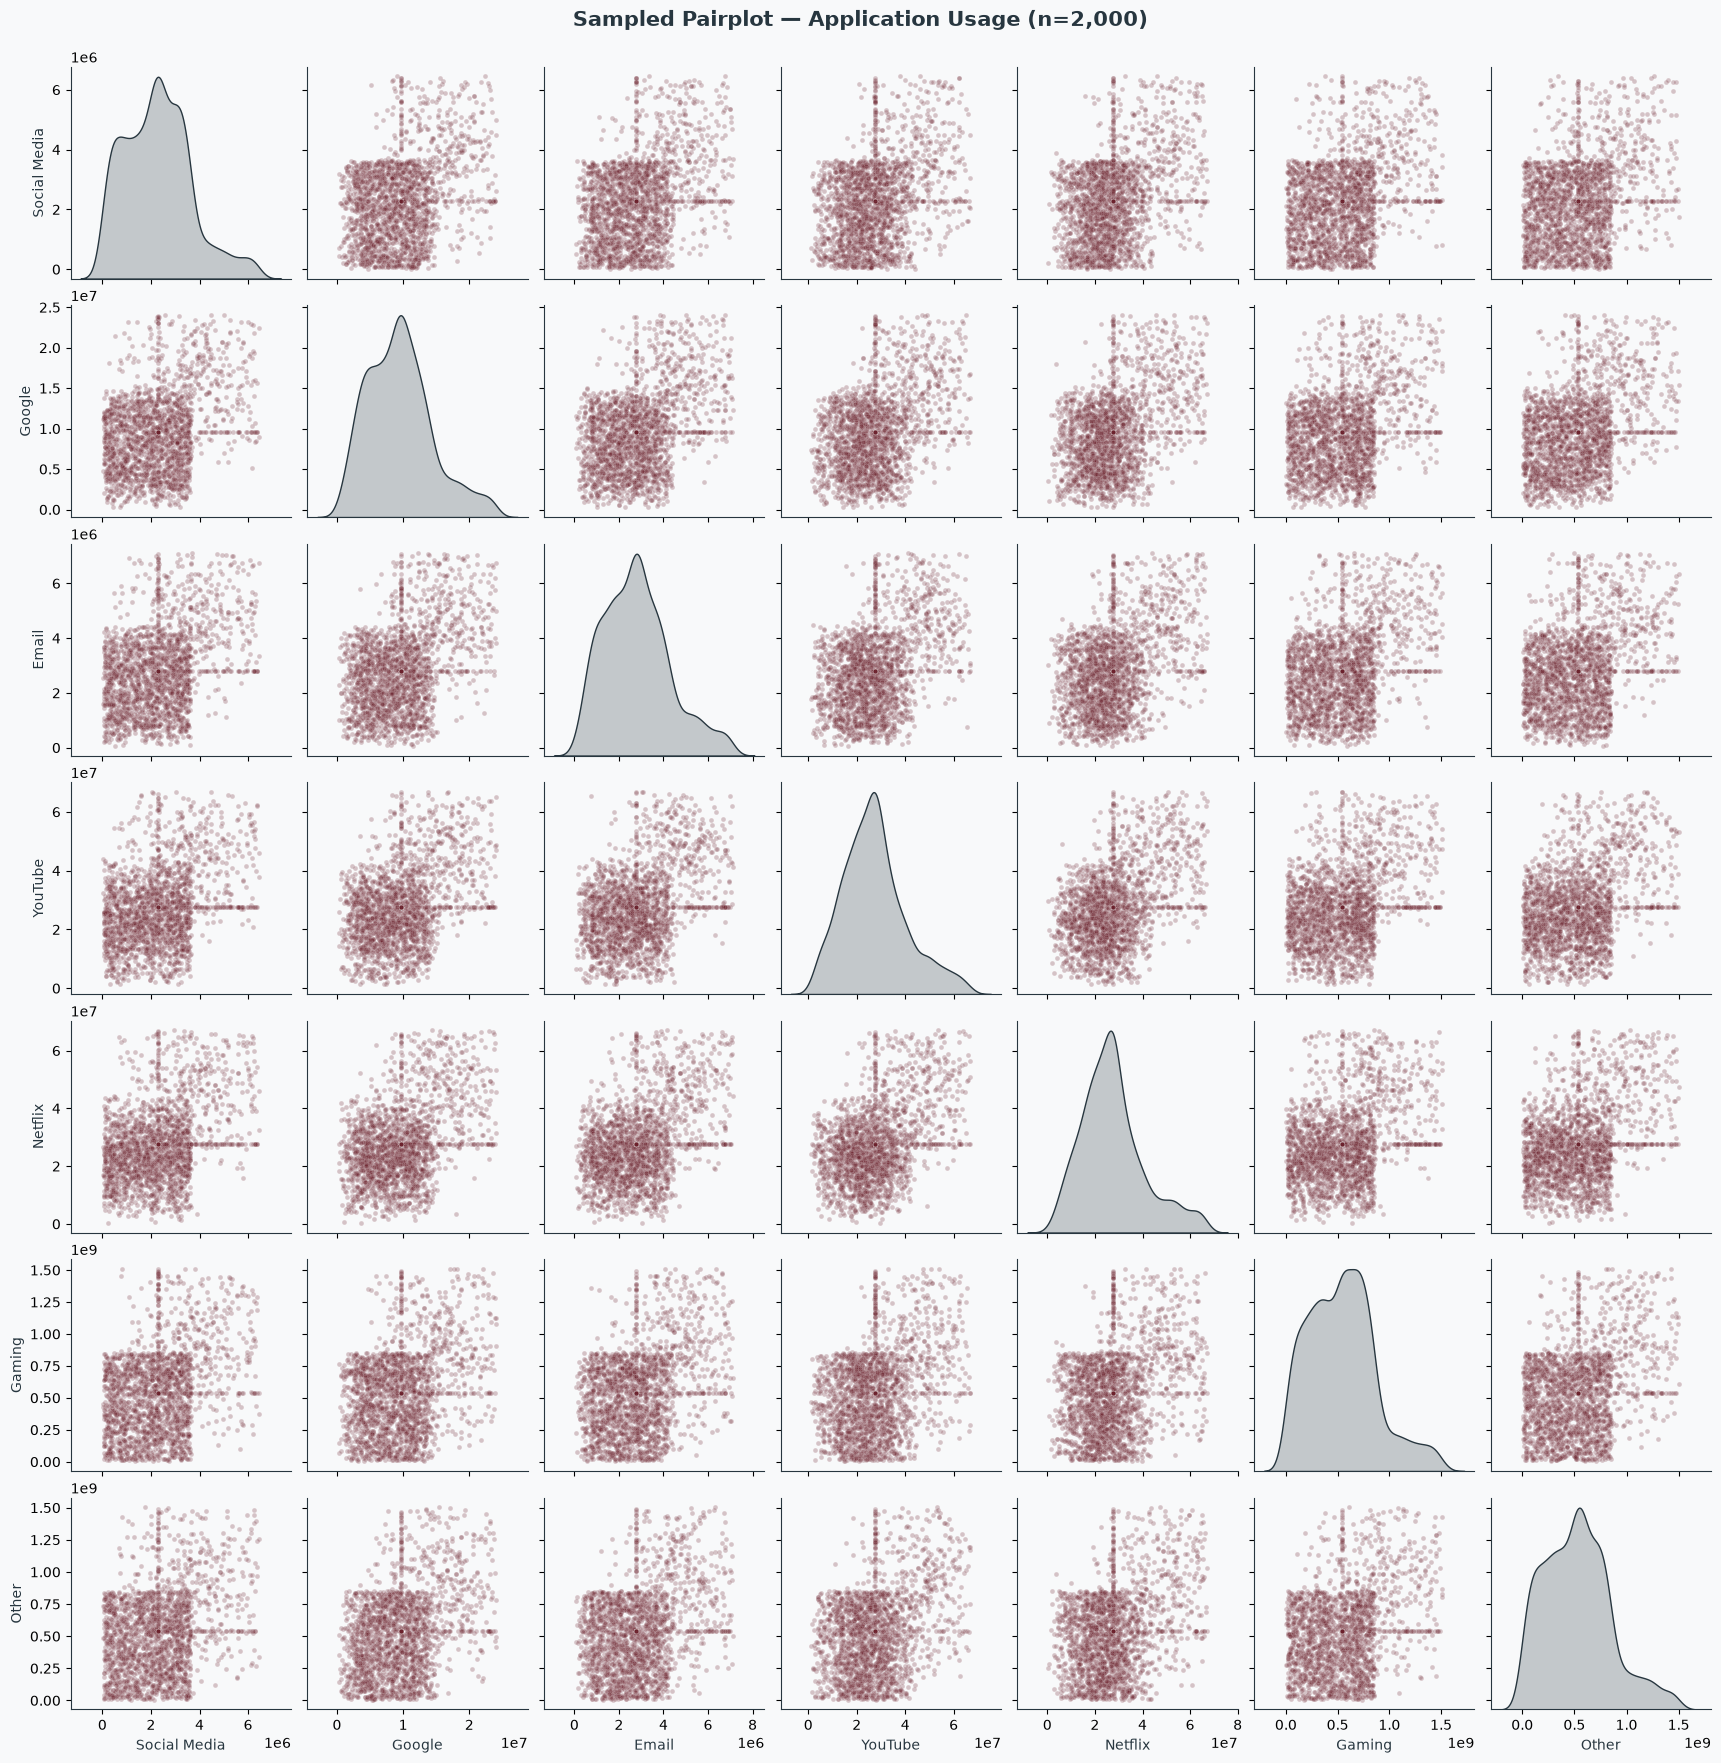

In [45]:
sample_for_pairplot = user_overview[app_metrics].sample(n=2000, random_state=RANDOM_STATE)
sample_for_pairplot.columns = apps

g = sns.pairplot(sample_for_pairplot, diag_kind='kde', plot_kws={'alpha': 0.25, 's': 12, 'color': TELLCO_PALETTE['berry']},
                  diag_kws={'color': TELLCO_PALETTE['pine']})
g.fig.suptitle('Sampled Pairplot — Application Usage (n=2,000)', y=1.01,
               fontsize=15, color=TELLCO_PALETTE['pine'], fontweight='bold')
plt.savefig('figures/fig4c_pairplot.png', dpi=100, facecolor='#F8F9FA', bbox_inches='tight')
plt.show()

**Interpretation (scatter grid and pairplot).** Only Gaming tracks Total Data Volume closely (a tight diagonal). The other six apps show a dense block with sharp edges and no visible slope, plus a sparse upper-right cloud of heavy users; the moderate r = 0.33–0.40 comes from that cloud. The stripes at each app's mean and at total ≈ 0.62e9 are the Section 3 replacement values. The two small off-diagonal clusters in the Gaming panel are customers treated on one variable but not the other. Pairwise app-to-app panels show the same structure, with no strong linear relationship between any two apps.

/var/folders/jb/87zlf28x7xq0tw37g7vps_vr0000gn/T/ipykernel_7175/3077786215.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=long_melted, x='Application', y='Standardised Usage (Z-score)', ax=ax,
/var/folders/jb/87zlf28x7xq0tw37g7vps_vr0000gn/T/ipykernel_7175/3077786215.py:7: UserWarning: The palette list has more values (10) than needed (7), which may not be intended.
  sns.violinplot(data=long_melted, x='Application', y='Standardised Usage (Z-score)', ax=ax,


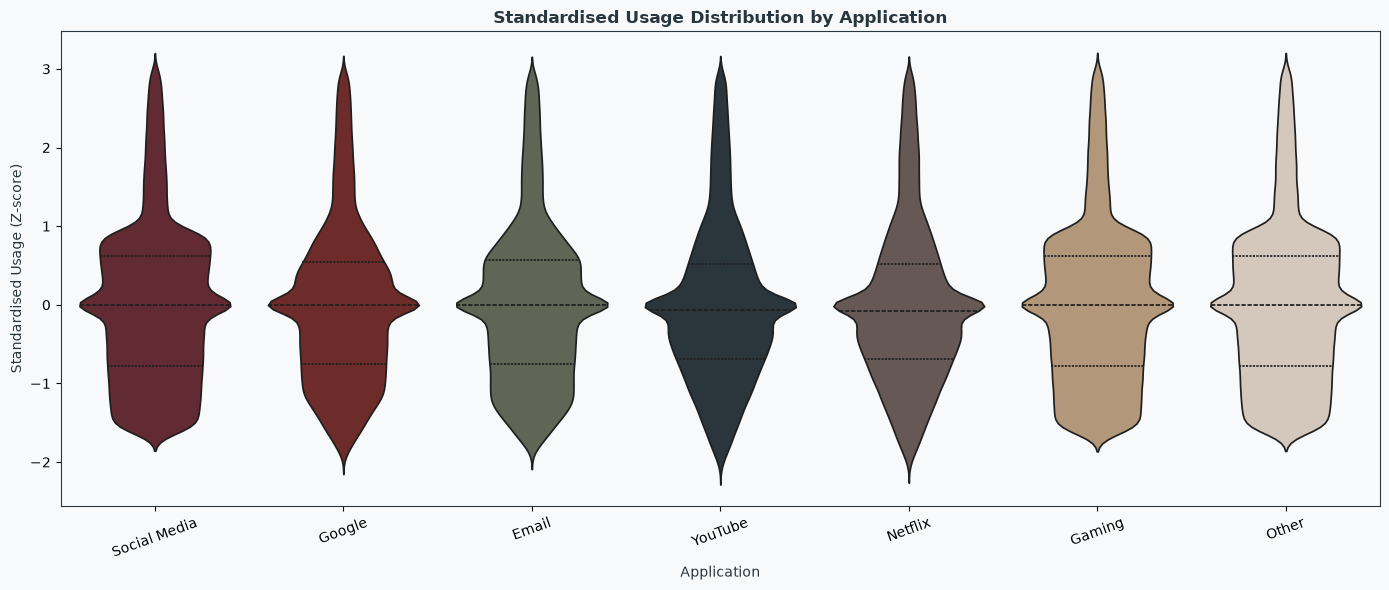

In [46]:
long_df = user_overview[app_metrics].copy()
long_df.columns = apps
long_scaled = (long_df - long_df.mean()) / long_df.std()
long_melted = long_scaled.melt(var_name='Application', value_name='Standardised Usage (Z-score)')

fig, ax = plt.subplots(figsize=(14, 6))
sns.violinplot(data=long_melted, x='Application', y='Standardised Usage (Z-score)', ax=ax,
                palette=TELLCO_PALETTE_LIST, inner='quartile')
ax.set_title('Standardised Usage Distribution by Application', color=TELLCO_PALETTE['pine'], fontweight='bold')
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig('figures/fig4d_violin_apps.png', dpi=100, facecolor='#F8F9FA')
plt.show()

**Interpretation (violin plot).** Usage is standardised (z-score) per application, so the violins compare shape, not scale. All seven are right-skewed with a long, thin upper tail ending near z ≈ 3.2, the residual tail left by the IQR treatment. Each has a sharp, wide band at z ≈ 0, consistent with the 4–6% of customers per app whose values were set to the replacement mean. Shapes are similar: Gaming, Other and Social Media have nearly identical profiles, while Google, Email, YouTube and Netflix have longer lower tails (down to about −2.1 to −2.3).

**Data-quality note.** YouTube and Netflix have almost identical means and standard deviations (31.56M vs. 31.54M; 21.29M vs. 21.29M), as do Gaming and Other (599.8M vs. 598.5M; 449.2M vs. 448.9M), yet each pair correlates only moderately (0.42 and 0.31). Organic usage rarely behaves this way, so these counters may be synthetic or evenly split. This should be confirmed with the data owner before app-level conclusions are used commercially.

### 4.5 Duration-Decile Segmentation

Customers are segmented into ten equal-sized classes by `Total Duration (s)`, and `Total Data Volume` is aggregated within each. Deciles are built from the **rank** of duration (`rank(method='first')`, then `pd.qcut`), so every class has the same size (10,685–10,686 customers) even though many customers share identical durations. Ties are broken by row order (customer-ID order), so two customers with the same duration can land in different deciles. This matters at two points: 8,052 customers share the 114,380 s value created by mean replacement, and 12,177 customers have a duration between 85,800 and 86,400 s, the last 10 minutes before 24 hours.

The treated table (brief-mandated) is the primary basis; the untreated table is shown alongside as a sensitivity check. The brief asks for the top five decile classes, so deciles 6–10 are also reported together.

In [47]:
def decile_table(df, dur='Total Duration (s)', vol='Total Data Volume (Bytes)'):
    d = pd.qcut(df[dur].rank(method='first'), 10, labels=False) + 1
    t = df.groupby(d).agg(Customers=(vol, 'size'), Total_Volume=(vol, 'sum'), Mean_Volume=(vol, 'mean'),
                          Min_Duration=(dur, 'min'), Max_Duration=(dur, 'max'))
    t['Pct_of_Traffic'] = t['Total_Volume'] / t['Total_Volume'].sum() * 100
    t.index.name = 'Duration Decile'
    return t, d

dec_treated, dec = decile_table(user_overview)
dec_raw, _       = decile_table(user_overview_raw)

fmt = {'Customers': '{:,.0f}', 'Total_Volume': '{:,.0f}', 'Mean_Volume': '{:,.0f}',
       'Min_Duration': '{:,.0f}', 'Max_Duration': '{:,.0f}', 'Pct_of_Traffic': '{:.2f}%'}
print('Treated (brief-mandated):'); display(dec_treated.style.format(fmt))
print('Raw (untreated):');          display(dec_raw.style.format(fmt))

rep = user_overview['Total Duration (s)'].mode().iloc[0]
tied = int((user_overview['Total Duration (s)'] == rep).sum())
raw_top = user_overview_raw['Total Duration (s)'] >= user_overview_raw['Total Duration (s)'].quantile(0.9)
print(f'{tied:,} customers share the replacement duration ({rep:,.0f} s).')
print(f'Of the true top-10% duration customers (raw), {(user_overview.loc[raw_top, "Total Duration (s)"] == rep).mean():.1%} were replaced by that mean.')
print(f'Top-five deciles (6-10) carry {dec_treated.loc[6:10, "Pct_of_Traffic"].sum():.1f}% of traffic (treated), '
      f'{dec_raw.loc[6:10, "Pct_of_Traffic"].sum():.1f}% (raw).')

Treated (brief-mandated):


,Customers,Total_Volume,Mean_Volume,Min_Duration,Max_Duration,Pct_of_Traffic
Duration Decile,,,,,,
1,"10,686","5,431,969,761,716","508,325,825","7,142","29,437",8.23%
2,"10,686","6,042,472,744,498","565,456,929","29,437","54,194",9.16%
3,"10,685","6,410,880,391,021","599,988,806","54,198","85,800",9.71%
4,"10,686","5,334,103,003,246","499,167,416","85,800","86,400",8.08%
5,"10,685","5,810,861,142,575","543,833,518","86,400","102,739",8.80%
6,"10,686","7,923,387,130,390","741,473,623","102,741","114,380",12.00%
7,"10,685","6,537,486,856,005","611,837,797","114,380","139,618",9.91%
8,"10,686","6,078,262,521,316","568,806,150","139,621","170,613",9.21%
9,"10,685","7,976,079,586,462","746,474,458","170,614","210,749",12.08%


Raw (untreated):


,Customers,Total_Volume,Mean_Volume,Min_Duration,Max_Duration,Pct_of_Traffic
Duration Decile,,,,,,
1,"10,686","5,438,828,817,246","508,967,698","7,142","29,437",7.37%
2,"10,686","6,109,858,232,586","571,762,889","29,437","54,194",8.28%
3,"10,685","6,508,446,141,133","609,119,901","54,198","85,800",8.82%
4,"10,686","5,336,721,751,812","499,412,479","85,800","86,400",7.23%
5,"10,685","5,869,206,382,923","549,293,999","86,400","102,739",7.95%
6,"10,686","6,426,251,197,532","601,371,065","102,741","132,452",8.70%
7,"10,685","6,151,239,834,460","575,689,269","132,454","163,649",8.33%
8,"10,686","7,822,605,563,835","732,042,445","163,649","190,675",10.59%
9,"10,685","9,306,361,514,704","870,974,405","190,675","275,665",12.60%


8,052 customers share the replacement duration (114,380 s).
Of the true top-10% duration customers (raw), 75.4% were replaced by that mean.
Top-five deciles (6-10) carry 56.0% of traffic (treated), 60.4% (raw).


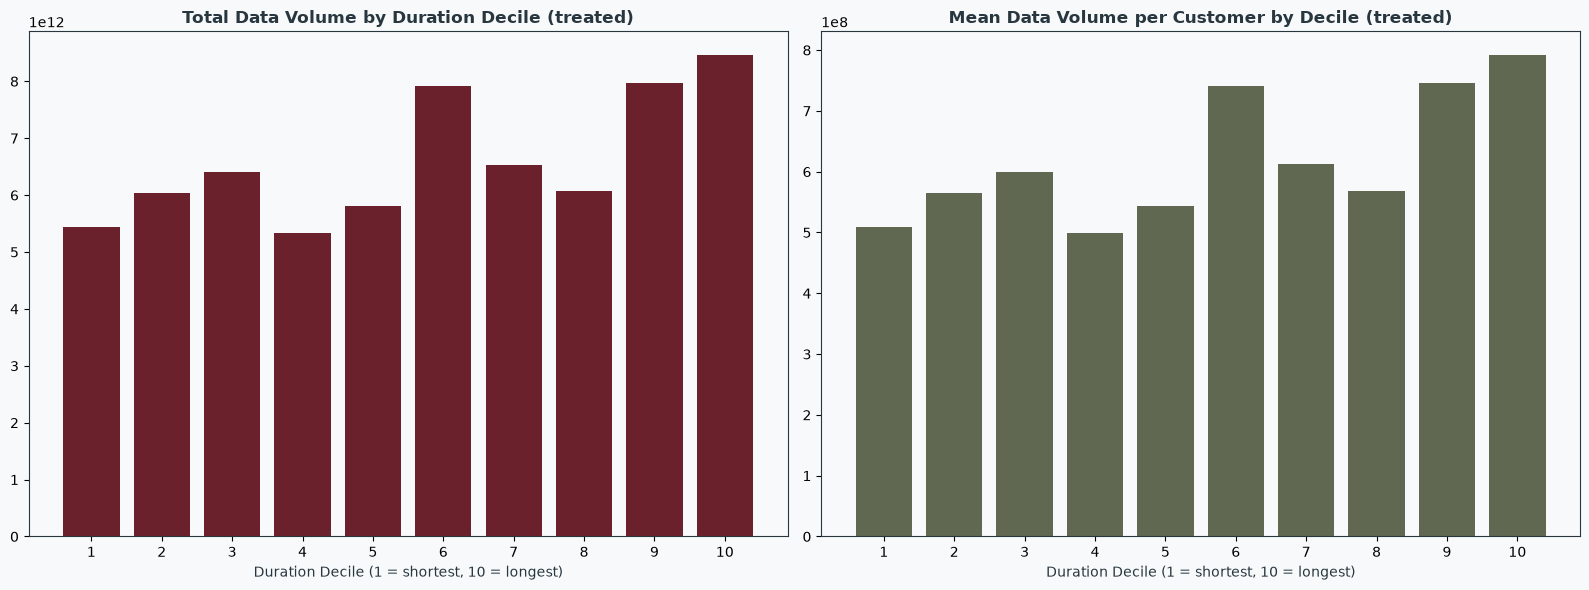

In [48]:
decile_summary = dec_treated.rename(columns={'Total_Volume': 'Total_Data_Volume', 'Mean_Volume': 'Mean_Data_Volume'})

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].bar(decile_summary.index, decile_summary['Total_Data_Volume'], color=TELLCO_PALETTE['berry'])
axes[0].set_title('Total Data Volume by Duration Decile (treated)', color=TELLCO_PALETTE['pine'], fontweight='bold')
axes[0].set_xlabel('Duration Decile (1 = shortest, 10 = longest)')
axes[1].bar(decile_summary.index, decile_summary['Mean_Data_Volume'], color=TELLCO_PALETTE['holly'])
axes[1].set_title('Mean Data Volume per Customer by Decile (treated)', color=TELLCO_PALETTE['pine'], fontweight='bold')
axes[1].set_xlabel('Duration Decile (1 = shortest, 10 = longest)')
for ax in axes:
    ax.set_xticks(range(1, 11))
plt.tight_layout()
plt.savefig('figures/fig4e_decile_volume.png', dpi=100, facecolor='#F8F9FA')
plt.show()

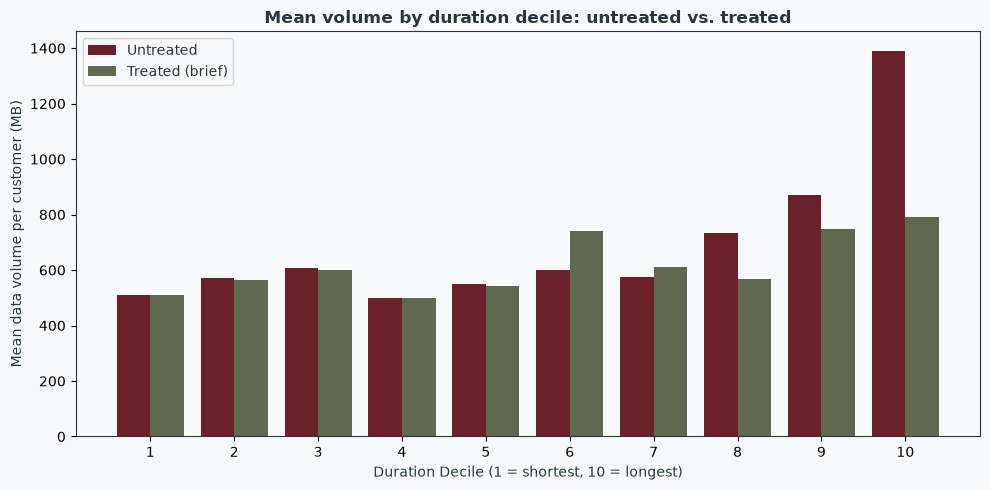

In [49]:
x, w = np.arange(1, 11), 0.4
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - w/2, dec_raw['Mean_Volume'] / 1e6, w, label='Untreated', color=TELLCO_PALETTE['berry'])
ax.bar(x + w/2, dec_treated['Mean_Volume'] / 1e6, w, label='Treated (brief)', color=TELLCO_PALETTE['holly'])
ax.set_xticks(x)
ax.set_xlabel('Duration Decile (1 = shortest, 10 = longest)')
ax.set_ylabel('Mean data volume per customer (MB)')
ax.set_title('Mean volume by duration decile: untreated vs. treated', color=TELLCO_PALETTE['pine'], fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('figures/fig4e2_decile_raw_vs_treated.png', dpi=100, facecolor='#F8F9FA')
plt.show()

In [50]:
d = user_overview_raw['Total Duration (s)']
raw_t = user_overview_raw['Total Data Volume (Bytes)']

def kw_eps(f):
    g = [x.values for _, x in f.groupby('dec')['vol']]
    h, p = stats.kruskal(*g)
    return h, p, (h - len(g) + 1) / (len(f) - len(g))

c = user_overview_raw[app_metrics].corr().values[np.triu_indices(len(apps), 1)]
print(f'1. Raw app-pair Pearson range: {c.min():.3f}-{c.max():.3f}')

frame_raw = pd.DataFrame({'dec': pd.qcut(d.rank(method="first"), 10, labels=False) + 1, 'vol': raw_t})
h_raw, _, eps_raw = kw_eps(frame_raw)
print(f'2. Raw Kruskal-Wallis H = {h_raw:,.1f}; epsilon-squared = {eps_raw:.3f}')

raw_evr = PCA(random_state=RANDOM_STATE).fit(StandardScaler().fit_transform(user_overview_raw[app_metrics])).explained_variance_ratio_
n80_raw = int(np.argmax(np.cumsum(raw_evr) >= 0.80) + 1)
print(f'3. Raw PCA: PC1 = {raw_evr[0]:.1%}; components for 80% = {n80_raw}')

print(f'4. Customers with duration exactly 86,400 s: {(d == 86400).sum():,}')
print(f'   Customers with duration 85,800-86,400 s: {((d >= 85800) & (d <= 86400)).sum():,}')

1. Raw app-pair Pearson range: 0.586-0.738
2. Raw Kruskal-Wallis H = 17,386.2; epsilon-squared = 0.163
3. Raw PCA: PC1 = 70.7%; components for 80% = 3
4. Customers with duration exactly 86,400 s: 2,015
   Customers with duration 85,800-86,400 s: 12,177


**Finding.** Mean volume per customer rises from 508 MB (decile 1) to 791 MB (decile 10) in the treated table, but not monotonically: the mean falls in 3 of the 9 steps (decile 3 → 4, 6 → 7, 7 → 8). The untreated table is also not monotonic (2 of 9 steps: 3 → 4 and 6 → 7), so this is not simply a treatment effect.

**A 24-hour cluster.** Decile 4 spans only 85,800–86,400 s. In total 12,177 customers (11.4%) have a duration in that window, and 2,015 sit at exactly 86,400 s (24 hours). This group is behind the dip at decile 4 (499 MB, below decile 1's 508 MB). A pile-up at exactly one day suggests a capped or default bearer length rather than a natural usage pattern; this should be confirmed with the data owner.

**What treatment changes.** 8,052 customers share the replacement duration (114,380 s), and 75.4% of the true top 10% by duration were replaced by that value. Decile 6 ends and decile 7 begins at exactly 114,380 s, so the tied customers are split across the boundary, which likely explains decile 6's jump (741 MB, above deciles 7 and 8 at 612 and 569 MB).

| | Deciles 6–10 share of traffic | Decile 10 share of traffic | Decile 10 mean volume |
|---|---|---|---|
| Untreated | 60.4% | 20.1% | 1,391 MB |
| Treated (brief) | 56.0% | 12.8% | 791 MB |

The longest-duration customers therefore carry more of the traffic than the treated table suggests.

### 4.6 Group-Comparison Test — Does Data Volume Differ Across Duration Deciles?

Kruskal–Wallis (non-parametric, appropriate given Section 3's confirmed non-normality) tests whether `Total Data Volume` differs across the 10 duration deciles, followed by pairwise Mann–Whitney U tests with Benjamini–Hochberg correction across all 45 pairs, reporting effect size and adjusted p-value for each. The test runs on the treated table (primary); the untreated result is reported as a sensitivity check.

In [51]:
frame = pd.DataFrame({'dec': dec, 'vol': user_overview['Total Data Volume (Bytes)']})

def kw_eps(f):
    g = [x.values for _, x in f.groupby('dec')['vol']]
    h, p = stats.kruskal(*g)
    return h, p, (h - len(g) + 1) / (len(f) - len(g))

h_stat, p_kw, epsilon_sq = kw_eps(frame)
eps_boot = [kw_eps(frame.sample(n=len(frame), replace=True, random_state=b))[2] for b in range(500)]
eps_ci_lo, eps_ci_hi = np.percentile(eps_boot, [2.5, 97.5])
label = ('negligible' if epsilon_sq < 0.01 else 'small' if epsilon_sq < 0.06
         else 'moderate' if epsilon_sq < 0.14 else 'large')
print(f'Kruskal-Wallis: H={h_stat:,.1f}, df=9, p={p_kw:.3e}')
print(f'ε² = {epsilon_sq:.4f} (95% bootstrap CI [{eps_ci_lo:.4f}, {eps_ci_hi:.4f}]): {label} effect (Cohen conventions 0.01 / 0.06 / 0.14)')

pair_results = []
for d1, d2 in itertools.combinations(range(1, 11), 2):
    g1, g2 = (frame.loc[frame.dec == d, 'vol'].values for d in (d1, d2))
    u, p = stats.mannwhitneyu(g1, g2, alternative='two-sided')
    pair_results.append({'Decile A': d1, 'Decile B': d2, 'p_raw': p,
                         'rank_biserial (+ = B larger)': 1 - 2 * u / (len(g1) * len(g2))})
pair_df = pd.DataFrame(pair_results)
reject, p_adj, _, _ = multipletests(pair_df['p_raw'], method='fdr_bh')
pair_df['significant'] = reject
pair_df['p_adj_BH'] = p_adj
print(f'{len(pair_df)} comparisons; {pair_df.significant.sum()} significant after BH correction')
display(pair_df[~pair_df.significant].style.format({'p_raw': '{:.3f}', 'p_adj_BH': '{:.3f}'}))

Kruskal-Wallis: H=7,469.6, df=9, p=0.000e+00
ε² = 0.0698 (95% bootstrap CI [0.0670, 0.0734]): moderate effect (Cohen conventions 0.01 / 0.06 / 0.14)
45 comparisons; 42 significant after BH correction


,Decile A,Decile B,p_raw,rank_biserial (+ = B larger),significant,p_adj_BH
2,1,4,0.084,-0.013665,False,0.088
14,2,8,0.514,0.005155,False,0.514
20,3,7,0.092,0.013309,False,0.094


**Interpretation.** The omnibus test confirms that `Total Data Volume` differs across duration deciles (Kruskal–Wallis H = 7,469.6, df = 9, p < 0.001). The association is **moderate** (ε² = 0.070, 95% bootstrap CI [0.067, 0.073]; the 0.01 / 0.06 / 0.14 benchmarks are used as a rough guide), so duration decile is not a dominant separator of volume on its own. On the untreated table the association is **large** (H = 17,386.2, ε² = 0.163), more than twice the treated value: mean replacement removes much of the signal by moving the longest-duration customers to the middle of the distribution. Of the 45 pairwise comparisons, 42 are significant after BH correction. The three exceptions (decile 1 vs. 4, 2 vs. 8, 3 vs. 7) are pairs whose mean volumes in 4.5 are close or reversed, so the statistical result matches the non-monotonic pattern seen there.

### 4.7 Principal Component Analysis

Standardised application-usage variables, checked for sampling adequacy before reducing
dimensions.

In [52]:
X = user_overview[app_metrics].values
scaler_pca = StandardScaler()
X_scaled = scaler_pca.fit_transform(X)

# Bartlett's test of sphericity
corr_mtx = np.corrcoef(X_scaled.T)
n_obs, n_vars = X_scaled.shape
chi2_stat = -(n_obs - 1 - (2 * n_vars + 5) / 6) * np.log(np.linalg.det(corr_mtx))
dof = n_vars * (n_vars - 1) / 2
bartlett_p = stats.chi2.sf(chi2_stat, dof)

# Kaiser-Meyer-Olkin measure
def kmo_measure(corr):
    inv = np.linalg.inv(corr)
    partial = -inv / np.sqrt(np.outer(np.diag(inv), np.diag(inv)))
    np.fill_diagonal(partial, 0)
    c = corr.copy()
    np.fill_diagonal(c, 0)
    return np.sum(c**2) / (np.sum(c**2) + np.sum(partial**2))

kmo_val = kmo_measure(corr_mtx.copy())

kmo_label = 'meritorious (>0.8)' if kmo_val > 0.8 else 'middling (0.7-0.8)' if kmo_val > 0.7 else 'weak (<0.7)'
print(f"Bartlett: χ²={chi2_stat:,.1f}, df={dof:.0f}, p={bartlett_p:.3e} (with n={n_obs:,} this is always significant)")
print(f'KMO = {kmo_val:.4f}: {kmo_label}')

Bartlett: χ²=159,882.2, df=21, p=0.000e+00 (with n=106,856 this is always significant)
KMO = 0.8835: meritorious (>0.8)


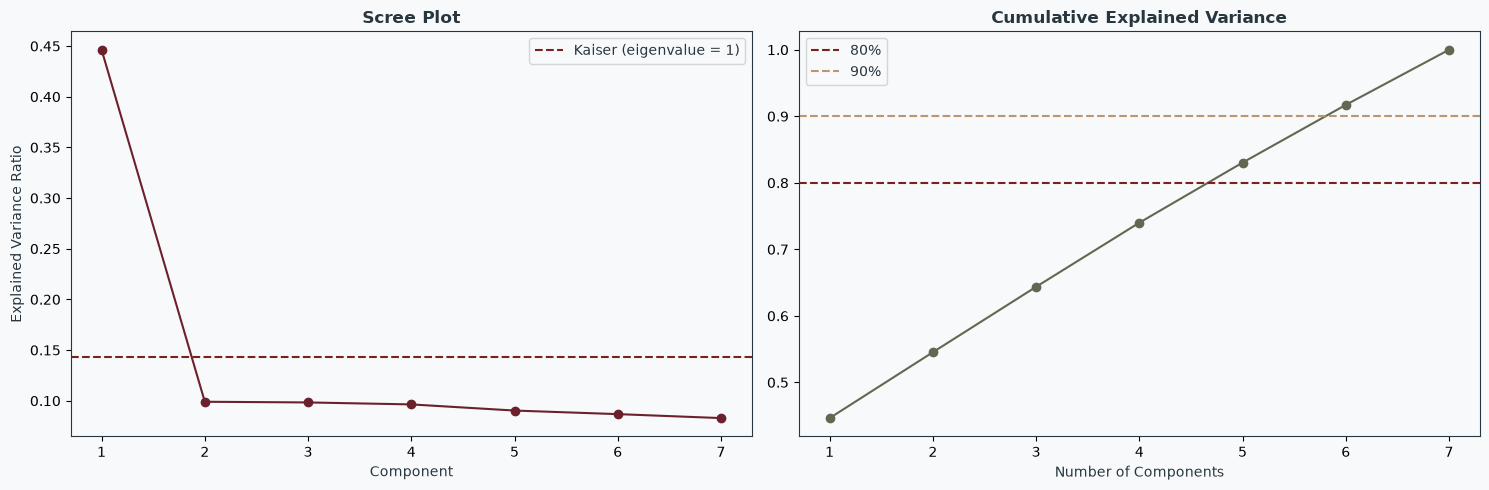

PC1 explains 44.6% of variance
Components needed for 80% variance: 5 / Components for 90%: 6


,PC1,PC2,PC3
Social Media,0.363,-0.214,-0.417
Google,0.388,-0.041,-0.131
Email,0.381,-0.097,-0.223
YouTube,0.398,-0.023,-0.108
Netflix,0.400,-0.024,-0.140
Gaming,0.356,0.863,0.274
Other,0.357,-0.444,0.808


In [53]:
pca = PCA(random_state=RANDOM_STATE)
pca.fit(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].plot(range(1, len(apps) + 1), pca.explained_variance_ratio_, 'o-', color=TELLCO_PALETTE['berry'])
axes[0].axhline(1 / len(apps), color=TELLCO_PALETTE['mulled_wine'], linestyle='--', label='Kaiser (eigenvalue = 1)')
axes[0].legend()
axes[0].set_title('Scree Plot', color=TELLCO_PALETTE['pine'], fontweight='bold')
axes[0].set_xlabel('Component')
axes[0].set_ylabel('Explained Variance Ratio')

axes[1].plot(range(1, len(apps) + 1), np.cumsum(pca.explained_variance_ratio_), 'o-', color=TELLCO_PALETTE['holly'])
axes[1].axhline(0.80, color=TELLCO_PALETTE['mulled_wine'], linestyle='--', label='80%')
axes[1].axhline(0.90, color=TELLCO_PALETTE['cinnamon'], linestyle='--', label='90%')
axes[1].set_title('Cumulative Explained Variance', color=TELLCO_PALETTE['pine'], fontweight='bold')
axes[1].set_xlabel('Number of Components')
axes[1].legend()

plt.tight_layout()
plt.savefig('figures/fig4f_pca_scree.png', dpi=100, facecolor='#F8F9FA')
plt.show()

loadings = pd.DataFrame(pca.components_.T, index=apps, columns=[f'PC{i+1}' for i in range(7)])
n_comp_80 = int(np.argmax(np.cumsum(pca.explained_variance_ratio_) >= 0.80) + 1)
n_comp_90 = int(np.argmax(np.cumsum(pca.explained_variance_ratio_) >= 0.90) + 1)

print(f'PC1 explains {pca.explained_variance_ratio_[0]*100:.1f}% of variance')
print(f'Components needed for 80% variance: {n_comp_80} / Components for 90%: {n_comp_90}')
display(loadings.iloc[:, :3].style.background_gradient(cmap=tellco_div, vmin=-1, vmax=1).format('{:.3f}'))

In [54]:
from IPython.display import Markdown
evr = pca.explained_variance_ratio_
same_sign = (loadings['PC1'] > 0).all() or (loadings['PC1'] < 0).all()
pc2 = loadings['PC2']

raw_evr = PCA(random_state=RANDOM_STATE).fit(
    StandardScaler().fit_transform(user_overview_raw[app_metrics])
).explained_variance_ratio_
n80_raw = int(np.argmax(np.cumsum(raw_evr) >= 0.80) + 1)

display(Markdown(f"""**PCA interpretation (four points).**

- **One general-usage factor.** PC1 explains {evr[0]:.1%} of variance and {'all apps load with the same sign' if same_sign else 'loadings differ in sign'}: it measures overall usage volume.
- **Weak compression.** {n_comp_80} components are needed for 80% and {n_comp_90} for 90% of variance, so PCA reduces dimensionality only modestly.
- **Contrast axis.** PC2 ({evr[1]:.1%}) separates {pc2.idxmax()} (+{pc2.max():.2f}) from {pc2.idxmin()} ({pc2.min():.2f}).
- **Caveat.** Fitted on the mean-replaced table. On untreated data PC1 explains {raw_evr[0]:.1%} and {n80_raw} components reach 80%, so the weak compression is largely a result of the mandated treatment.
"""))

**PCA interpretation (four points).**

- **One general-usage factor.** PC1 explains 44.6% of variance and all apps load with the same sign: it measures overall usage volume.
- **Weak compression.** 5 components are needed for 80% and 6 for 90% of variance, so PCA reduces dimensionality only modestly.
- **Contrast axis.** PC2 (9.9%) separates Gaming (+0.86) from Other (-0.44).
- **Caveat.** Fitted on the mean-replaced table. On untreated data PC1 explains 70.7% and 3 components reach 80%, so the weak compression is largely a result of the mandated treatment.


**PCA interpretation (≤4 bullets):**

- **PC1 is a general-usage axis.** It explains 44.6% of variance and every app loads positively (0.36–0.40), ranking customers from generally light to generally heavy.
- **One component is retained; the 80% rule overstates the structure.** The scree plot has a sharp elbow after PC1, and PC2–PC7 each explain only 8–10% (eigenvalues below 1). Five components are needed for 80% only because the remaining variance is spread almost evenly. On untreated data PC1 explains 70.7% and 3 components reach 80%, so the mandated treatment lowers PC1's share.
- **PC2 and PC3 should not be over-read.** With near-equal eigenvalues their loadings are unstable. PC2 (9.9%) contrasts Gaming (+0.86) with Other (−0.44), consistent with Gaming–Other being the weakest app pair (r = 0.308).
- **Adequacy is strong** (KMO = 0.88; Bartlett p < 0.001, though with n = 106,856 it is always significant). This is a descriptive summary of one extraction window.

### 4.8 Manufacturer × Application Usage

Correlation and PCA both look at applications in isolation from device identity. This checks
whether the top 3 manufacturers — Apple, Samsung, Huawei — show genuinely different
application-usage profiles, or whether device brand is unrelated to which apps a customer
favours.

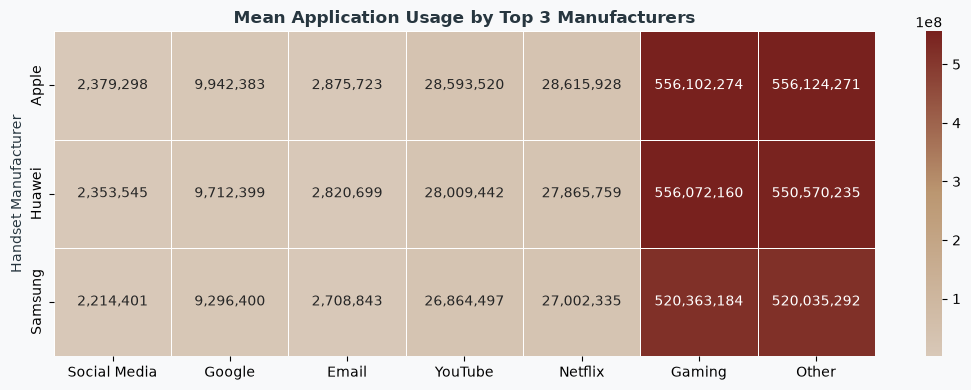

,Social Media,Google,Email,YouTube,Netflix,Gaming,Other
Handset Manufacturer,,,,,,,
Apple,"2,379,298","9,942,383","2,875,723","28,593,520","28,615,928","556,102,274","556,124,271"
Huawei,"2,353,545","9,712,399","2,820,699","28,009,442","27,865,759","556,072,160","550,570,235"
Samsung,"2,214,401","9,296,400","2,708,843","26,864,497","27,002,335","520,363,184","520,035,292"


In [55]:
mfg_lookup = df_clean.drop_duplicates('MSISDN/Number').set_index('MSISDN/Number')['Handset Manufacturer']
user_overview_mfg = user_overview.join(mfg_lookup, how='left')

top3_manufacturers = df_clean['Handset Manufacturer'].value_counts().head(3).index.tolist()

mfg_app_matrix = user_overview_mfg[user_overview_mfg['Handset Manufacturer'].isin(top3_manufacturers)] \
    .groupby('Handset Manufacturer')[app_metrics].mean()
mfg_app_matrix.columns = apps

fig, ax = plt.subplots(figsize=(11, 4))
sns.heatmap(mfg_app_matrix, annot=True, fmt=',.0f', cmap=tellco_warn, ax=ax,
            linewidths=0.5, linecolor='white')
ax.set_title('Mean Application Usage by Top 3 Manufacturers', color=TELLCO_PALETTE['pine'], fontweight='bold')
plt.tight_layout()
plt.savefig('figures/fig4g_manufacturer_app_heatmap.png', dpi=100, facecolor='#F8F9FA')
plt.show()

display(mfg_app_matrix.style.format('{:,.0f}'))

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/seaborn/matrix.py:243: PendingDeprecationWarning: The set_bad function will be deprecated in a future version. Use cmap.with_extremes(bad=...) or Colormap(bad=...) instead.
  self.cmap.set_bad(bad)


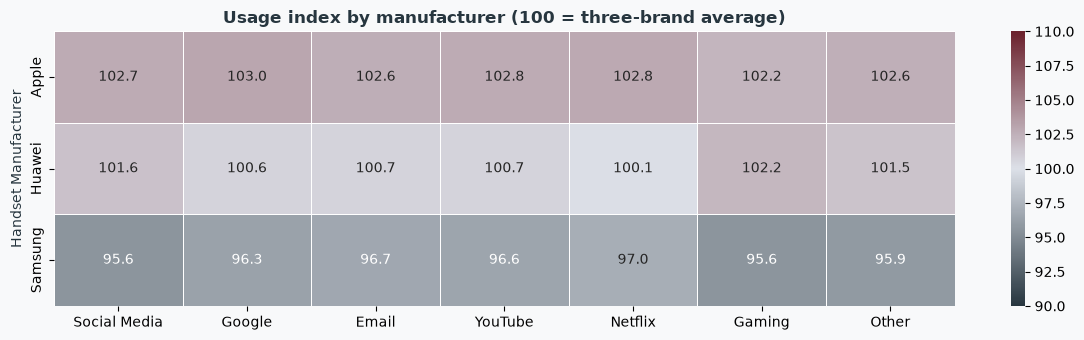

In [56]:
rel = mfg_app_matrix.div(mfg_app_matrix.mean()) * 100
plt.figure(figsize=(12, 3.5))
sns.heatmap(rel, annot=True, fmt='.1f', cmap=tellco_div, center=100, vmin=90, vmax=110, linewidths=0.5)
plt.title('Usage index by manufacturer (100 = three-brand average)', color=TELLCO_PALETTE['pine'], fontweight='bold')
plt.tight_layout()
plt.show()

In [57]:
app_rank = mfg_app_matrix.rank(axis=1, ascending=False).astype(int)
display(app_rank)

multi_mfg_customers = df_clean.groupby('MSISDN/Number')['Handset Manufacturer'].nunique()
print(f'Customers whose sessions span more than one manufacturer: '
      f'{(multi_mfg_customers > 1).sum()} ({(multi_mfg_customers > 1).mean()*100:.2f}%) — '
      f'negligible, so the one-manufacturer-per-customer join above is safe.')

,Social Media,Google,Email,YouTube,Netflix,Gaming,Other
Handset Manufacturer,,,,,,,
Apple,7,5,6,4,3,2,1
Huawei,7,5,6,3,4,1,2
Samsung,7,5,6,4,3,1,2


Customers whose sessions span more than one manufacturer: 2 (0.00%) — negligible, so the one-manufacturer-per-customer join above is safe.


**Interpretation.** Application ranking is nearly identical across the three manufacturers: Social Media is the lowest-usage app for all three, Google and Email rank fifth and sixth, YouTube and Netflix third and fourth, and Gaming and Other are always the top two. Samsung and Huawei customers use Gaming slightly more than Other, with Huawei's margin the larger (~1%). For Apple, Other is marginally higher, by about 22,000 bytes out of ~556M (0.004%), which is a tie rather than a reversal.

Usage differs in level, not in mix: Samsung customers are 5.6–6.9% below Apple on every one of the seven applications, a roughly uniform gap. The table is built from the treated `user_overview` (Apple's Gaming mean of ~556M compares with 599.8M untreated), and the differences are descriptive and untested.

Manufacturer explains how much customers use, not what they use: the application ranking is essentially identical across Apple, Samsung and Huawei. These are descriptive differences in means and were not tested for significance.

In [58]:
others = [a for a in apps if a != 'Gaming']
raw_t = user_overview_raw['Total Data Volume (Bytes)']

# 1. Each app's average as a % of Total Data Volume (untreated)
share_of_total = pd.Series({a: user_overview_raw[f'{a} Total (Bytes)'].mean() / raw_t.mean() * 100 for a in apps})
print(share_of_total.round(1).sort_values(ascending=False).to_string())
print(f'Sum of the 7 app counters = {share_of_total.sum():.0f}% of Total Data Volume')

# 2. Correlation with the REST of the total (removes the part-whole effect). Other is skipped
# because Other DL is not part of Total DL.
rest_rho = pd.Series({a: stats.spearmanr(user_overview_raw[f'{a} Total (Bytes)'],
                                         raw_t - user_overview_raw[f'{a} Total (Bytes)'])[0]
                      for a in apps if a != 'Other'})
print(rest_rho.round(3).to_string())

# 3. App-pair correlation range, raw vs treated
def pair_range(df):
    c = df[app_metrics].corr().values[np.triu_indices(len(apps), 1)]
    return c.min(), c.max()
(lo_r, hi_r), (lo_t, hi_t) = pair_range(user_overview_raw), pair_range(user_overview)
print(f'App-pair Pearson range: raw {lo_r:.3f}-{hi_r:.3f}; treated {lo_t:.3f}-{hi_t:.3f}')

# 4. Is there a spike at exactly 24 hours? (deciles 4/5 meet at 86,400 s)
d = user_overview_raw['Total Duration (s)']
print(f'Customers with duration 85,800-86,400 s: {((d >= 85800) & (d <= 86400)).sum():,}; exactly 86,400 s: {(d == 86400).sum():,}')

# 5. Raw-data versions of the decile test and the PCA
frame_raw = pd.DataFrame({'dec': pd.qcut(d.rank(method='first'), 10, labels=False) + 1, 'vol': raw_t})
h_raw, p_raw_kw, eps_raw = kw_eps(frame_raw)
raw_evr = PCA(random_state=RANDOM_STATE).fit(StandardScaler().fit_transform(user_overview_raw[app_metrics])).explained_variance_ratio_
n80_raw = int(np.argmax(np.cumsum(raw_evr) >= 0.80) + 1)
print(f'Raw: KW H={h_raw:,.0f}, eps2={eps_raw:.3f}; PCA PC1={raw_evr[0]:.1%}, {n80_raw} components for 80%')

Gaming          86.8
Other           86.6
YouTube          4.6
Netflix          4.6
Google           1.6
Email            0.5
Social Media     0.4
Sum of the 7 app counters = 185% of Total Data Volume
Social Media    0.383
Google          0.422
Email           0.413
YouTube         0.429
Netflix         0.429
Gaming          0.456
App-pair Pearson range: raw 0.586-0.738; treated 0.308-0.420
Customers with duration 85,800-86,400 s: 12,177; exactly 86,400 s: 2,015
Raw: KW H=17,386, eps2=0.163; PCA PC1=70.7%, 3 components for 80%


In [59]:
from IPython.display import Markdown
b, a = bivariate_df, adj_df
n_sess_changed = int((user_overview_raw['xDR Sessions'] != user_overview['xDR Sessions']).sum())
repl_share = (user_overview.loc[raw_top, 'Total Duration (s)'] == rep).mean()
mono = lambda t: int((t['Mean_Volume'].diff().dropna() < 0).sum())
ns = pair_df[~pair_df.significant]
ns_txt = ', '.join(f"{int(r['Decile A'])} vs {int(r['Decile B'])}" for _, r in ns.iterrows())
pl = pairs_labels

display(Markdown(f"""**4.2 App vs. total volume.** Gaming correlates almost perfectly with `Total Data Volume` (Pearson {b.loc['Gaming','Pearson r']:.3f}, 95% CI [{b.loc['Gaming','95% CI Lower']:.3f}, {b.loc['Gaming','95% CI Upper']:.3f}]); the other six sit at {b.loc[others,'Pearson r'].min():.2f}–{b.loc[others,'Pearson r'].max():.2f}. This is largely arithmetic: Gaming averages {share_of_total['Gaming']:.0f}% of `Total Data Volume`, so it dominates the total it is correlated with. `Other` correlates weakly because Other DL is excluded from Total DL, and the seven app counters sum to {share_of_total.sum():.0f}% of the total, so they do not reconcile. Untreated correlations are higher (Gaming {biv_cmp.loc['Gaming','Pearson (raw)']:.3f}, others {biv_cmp.loc[others,'Pearson (raw)'].min():.2f}–{biv_cmp.loc[others,'Pearson (raw)'].max():.2f}) because mean replacement works variable by variable and breaks joint extremes. Removing the part-whole effect (untreated Spearman of each app vs. total minus that app): Gaming {rest_rho['Gaming']:.2f}, others {rest_rho.drop('Gaming').min():.2f}–{rest_rho.drop('Gaming').max():.2f}."""))

display(Markdown(f"""**4.2b Controlling for session count.** Customers with more sessions generate more of everything (corr(sessions, volume) = {r_sess:.2f}). Per session, the six non-Gaming apps fall to Pearson {a.loc[others,'Pearson r (per-session)'].min():.3f}–{a.loc[others,'Pearson r (per-session)'].max():.3f}, while Gaming stays at {a.loc['Gaming','Pearson r (per-session)']:.3f}. So the moderate correlations of the other apps mostly reflect session frequency. Gaming's persistence follows from its share of the total, so it should not be read as Gaming "driving" heavy users. Caveat: the mean-replacement rule sets {n_sess_changed:,} customers' session counts to 1, which inflates their per-session figures."""))

display(Markdown(f"""**4.3 App-to-app correlations.** After treatment all 21 pairs are weak-to-moderate (r = {pearson_vals.min():.3f}–{pearson_vals.max():.3f}; untreated {lo_r:.3f}–{hi_r:.3f}). Strongest pair: {pl[max_pair_idx][0]}–{pl[max_pair_idx][1]} ({pearson_vals[max_pair_idx]:.3f}); weakest: {pl[min_pair_idx][0]}–{pl[min_pair_idx][1]} ({pearson_vals[min_pair_idx]:.3f}). Bootstrap half-width is about ±{avg_ci_width/2:.4f}, so the estimates are precise and the drop from the untreated range is a treatment effect, not noise."""))

display(Markdown(f"""**4.5 Duration deciles.** Mean volume per customer rises from {dec_treated.loc[1,'Mean_Volume']/1e6:,.0f} MB (decile 1) to {dec_treated.loc[10,'Mean_Volume']/1e6:,.0f} MB (decile 10) in the treated table, but not monotonically: the mean falls between {mono(dec_treated)} of 9 consecutive decile pairs (untreated: {mono(dec_raw)}). Deciles 6–10 carry {dec_treated.loc[6:10,'Pct_of_Traffic'].sum():.1f}% of traffic treated vs. {dec_raw.loc[6:10,'Pct_of_Traffic'].sum():.1f}% untreated; decile 10 alone carries {dec_treated.loc[10,'Pct_of_Traffic']:.1f}% vs. {dec_raw.loc[10,'Pct_of_Traffic']:.1f}%. Mean replacement moved {repl_share:.1%} of the genuinely longest-duration customers (raw top 10%) to one value ({rep:,.0f} s). {tied:,} customers tie there across the boundary between deciles 6 and 7 and are split by row order, which likely explains decile 6's jump. Deciles are equal-sized because ties are broken by row order."""))

display(Markdown(f"""**4.6 Statistical test.** Kruskal–Wallis H = {h_stat:,.0f} (df 9, p < 0.001); ε² = {epsilon_sq:.3f} (95% CI [{eps_ci_lo:.3f}, {eps_ci_hi:.3f}]), a {label} effect: decile membership accounts for roughly {epsilon_sq:.0%} of the rank variation in volume (untreated ε² = {eps_raw:.3f}). {pair_df.significant.sum()} of {len(pair_df)} pairwise comparisons are significant after BH correction; the exceptions are {ns_txt}."""))

rows = [
 ('App vs. total volume', f"Gaming r={b.loc['Gaming','Pearson r']:.3f}; others {b.loc[others,'Pearson r'].min():.2f}–{b.loc[others,'Pearson r'].max():.2f}", f"Gaming is ~{share_of_total['Gaming']:.0f}% of the total by construction (part-whole)"),
 ('Per session', f"Gaming {a.loc['Gaming','Pearson r (per-session)']:.3f}; others {a.loc[others,'Pearson r (per-session)'].min():.3f}–{a.loc[others,'Pearson r (per-session)'].max():.3f}", 'Other apps mostly reflect session frequency'),
 ('App-pair correlations', f"{pearson_vals.min():.3f}–{pearson_vals.max():.3f} treated; {lo_r:.3f}–{hi_r:.3f} untreated", 'Weakening is a treatment effect'),
 ('Duration deciles', f"Deciles 6–10: {dec_treated.loc[6:10,'Pct_of_Traffic'].sum():.1f}% treated vs. {dec_raw.loc[6:10,'Pct_of_Traffic'].sum():.1f}% untreated", 'Not monotonic in either; treatment moves the longest customers to the middle'),
 ('Kruskal–Wallis', f"ε²={epsilon_sq:.3f} treated; {eps_raw:.3f} untreated", f"{pair_df.significant.sum()}/{len(pair_df)} pairs significant (BH)"),
 ('PCA', f"PC1 {evr[0]:.1%} treated vs. {raw_evr[0]:.1%} untreated; {n_comp_80} vs. {n80_raw} components for 80%", 'Weak compression is mostly a treatment effect'),
 ('Manufacturer × app mix', 'Ranking near-identical across Apple, Samsung, Huawei', 'Manufacturer explains usage intensity, not mix'),
]
display(pd.DataFrame(rows, columns=['Check', 'Result', 'Interpretation']).style.hide(axis='index'))

**4.2 App vs. total volume.** Gaming correlates almost perfectly with `Total Data Volume` (Pearson 0.983, 95% CI [0.982, 0.985]); the other six sit at 0.33–0.40. This is largely arithmetic: Gaming averages 87% of `Total Data Volume`, so it dominates the total it is correlated with. `Other` correlates weakly because Other DL is excluded from Total DL, and the seven app counters sum to 185% of the total, so they do not reconcile. Untreated correlations are higher (Gaming 0.997, others 0.62–0.71) because mean replacement works variable by variable and breaks joint extremes. Removing the part-whole effect (untreated Spearman of each app vs. total minus that app): Gaming 0.46, others 0.38–0.43.

**4.2b Controlling for session count.** Customers with more sessions generate more of everything (corr(sessions, volume) = 0.55). Per session, the six non-Gaming apps fall to Pearson 0.056–0.090, while Gaming stays at 0.986. So the moderate correlations of the other apps mostly reflect session frequency. Gaming's persistence follows from its share of the total, so it should not be read as Gaming "driving" heavy users. Caveat: the mean-replacement rule sets 3,251 customers' session counts to 1, which inflates their per-session figures.

**4.3 App-to-app correlations.** After treatment all 21 pairs are weak-to-moderate (r = 0.308–0.420; untreated 0.586–0.738). Strongest pair: YouTube–Netflix (0.420); weakest: Gaming–Other (0.308). Bootstrap half-width is about ±0.0053, so the estimates are precise and the drop from the untreated range is a treatment effect, not noise.

**4.5 Duration deciles.** Mean volume per customer rises from 508 MB (decile 1) to 791 MB (decile 10) in the treated table, but not monotonically: the mean falls between 3 of 9 consecutive decile pairs (untreated: 2). Deciles 6–10 carry 56.0% of traffic treated vs. 60.4% untreated; decile 10 alone carries 12.8% vs. 20.1%. Mean replacement moved 75.4% of the genuinely longest-duration customers (raw top 10%) to one value (114,380 s). 8,052 customers tie there across the boundary between deciles 6 and 7 and are split by row order, which likely explains decile 6's jump. Deciles are equal-sized because ties are broken by row order.

**4.6 Statistical test.** Kruskal–Wallis H = 7,470 (df 9, p < 0.001); ε² = 0.070 (95% CI [0.067, 0.073]), a moderate effect: decile membership accounts for roughly 7% of the rank variation in volume (untreated ε² = 0.163). 42 of 45 pairwise comparisons are significant after BH correction; the exceptions are 1 vs 4, 2 vs 8, 3 vs 7.

Check,Result,Interpretation
App vs. total volume,Gaming r=0.983; others 0.33–0.40,Gaming is ~87% of the total by construction (part-whole)
Per session,Gaming 0.986; others 0.056–0.090,Other apps mostly reflect session frequency
App-pair correlations,0.308–0.420 treated; 0.586–0.738 untreated,Weakening is a treatment effect
Duration deciles,Deciles 6–10: 56.0% treated vs. 60.4% untreated,Not monotonic in either; treatment moves the longest customers to the middle
Kruskal–Wallis,ε²=0.070 treated; 0.163 untreated,42/45 pairs significant (BH)
PCA,PC1 44.6% treated vs. 70.7% untreated; 5 vs. 3 components for 80%,Weak compression is mostly a treatment effect
Manufacturer × app mix,"Ranking near-identical across Apple, Samsung, Huawei","Manufacturer explains usage intensity, not mix"


**Section 4 summary.**

| Check | Result | Interpretation |
|---|---|---|
| App vs. Total Volume | Gaming r=0.983; others 0.33–0.40 (untreated: 0.997; 0.62–0.71) | Gaming is ~87% of the total by construction; with the overlap removed, untreated Spearman is 0.46 for Gaming vs. 0.38–0.43 for the others |
| Session-count-adjusted | Others fall to 0.056–0.090; Gaming stays at 0.986 | Non-Gaming correlations mostly reflect session frequency; Gaming's persistence follows from its size |
| App correlation matrix | r=0.308–0.420 treated (YouTube↔Netflix highest, Gaming↔Other lowest); 0.586–0.738 untreated | Weakening is a treatment effect |
| Duration decile → volume | Not monotonic in either table; deciles 6–10 carry 56.0% treated vs. 60.4% untreated; decile 10: 12.8% vs. 20.1% | Treatment moves 75.4% of the longest-duration customers to the middle; a 24-hour cluster (12,177 customers) drives the decile-4 dip |
| Kruskal-Wallis (decile groups) | H=7,469.6, p<0.001; ε²=0.070 treated, 0.163 untreated | Moderate association treated, large untreated |
| Pairwise Mann-Whitney (BH-adjusted) | 42/45 significant; exceptions 1v4, 2v8, 3v7 | Matches the non-monotonic pattern |
| PCA | KMO=0.88; PC1=44.6% treated vs. 70.7% untreated; 5 vs. 3 components for 80% | Weak compression is mostly a treatment effect; PC2 is a Gaming-vs-Other contrast |
| Manufacturer × app usage | Ranking near-identical across Apple/Samsung/Huawei | Manufacturer relates to usage intensity, not mix (descriptive only) |

**Headline finding carried forward:** Gaming's strong link to total volume is mostly size: it is ~87% of the total, and once that overlap is removed its correlation (0.46) is close to the other apps' (0.38–0.43). For the other apps, the apparent link to total volume mostly reflects session frequency. The mandated mean replacement weakens correlations, compresses the duration–volume relationship and hides the heaviest customers' share of traffic (decile 10: 12.8% treated vs. 20.1% untreated), so untreated figures are reported alongside.

This closes **Section 4 — Bivariate & Multivariate Analysis**.

## 📶 Section 5 — User Engagement

This section tracks engagement through the three metrics specified in the brief — session frequency (`xDR Sessions`), session duration (`Total Duration (s)`, in seconds: the summed bearer-open span) and session traffic (`Total Data Volume (Bytes)`) — reports the top performers on each, identifies the top applications, and segments customers with k-means (k=3), validated before the clusters are profiled.

Two tables are used deliberately. The top-10 customer lists and the application rankings use the **untreated** customer table (`user_overview_raw`), because mean replacement overwrites exactly the extreme values these rankings exist to surface; on the treated table the "top" customers would simply be those sitting just under the IQR fence. Clustering uses the **treated** table (`user_overview`) as the primary basis, consistent with the rest of the notebook and with the brief's mean-replacement instruction (Tasks 1.2 and 3.1; Task 2 does not repeat it). Treatment has a real cost here: customers with four or more sessions are recorded as having one, so the clusters cannot see the heaviest users. Section 5.7 repeats the clustering on an IQR-capped table and compares the two. Results describe behaviour within the extraction window.

### 5.1 Top 10 Customers per Engagement Metric

,xDR Sessions
MSISDN/Number,
33626320676,18
33625779332,17
33614892860,17
33659725664,16
33760536639,15
33675877202,15
33667163239,13
33627080969,12
33604515716,12


,Total Duration (s)
MSISDN/Number,
33625779332,18553754.0
33614892860,9966898.0
33760536639,9279434.0
33626320676,8791927.0
33667163239,8744914.0
33662840755,6614270.0
33664693736,6288730.0
33603127838,6287761.0
33667456716,5649882.0


,Total Data Volume (Bytes)
MSISDN/Number,
33614892860,8.846226e+09
33760536639,8.514774e+09
33625779332,8.499621e+09
33626320676,7.971167e+09
33675877202,7.891111e+09
33659725664,7.705863e+09
33666464084,7.308501e+09
33760413819,7.132371e+09
33664712899,6.872018e+09


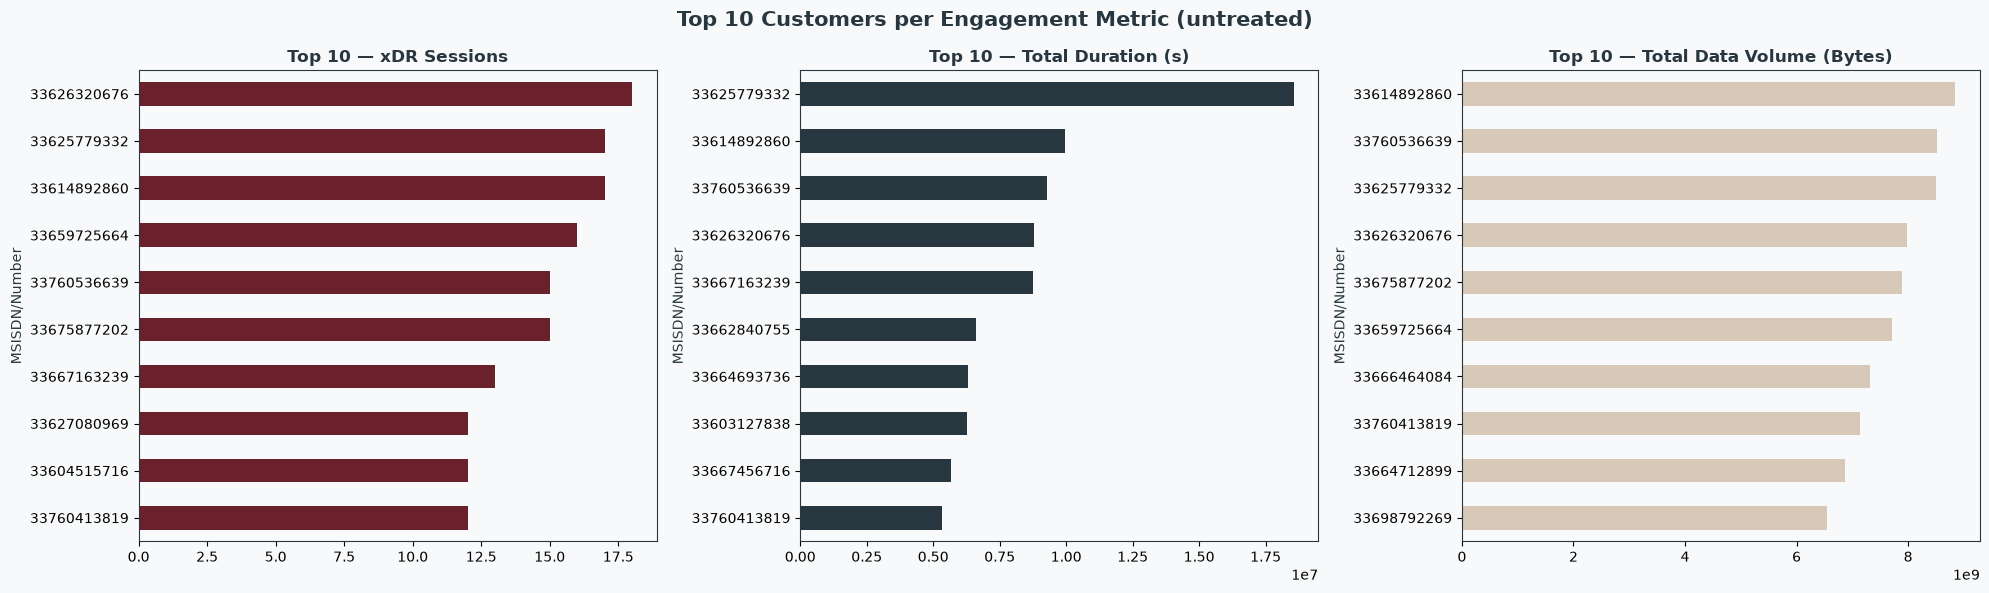

In all three top-10 lists: 5 customers
Sessions∩duration: 6; sessions∩volume: 7; duration∩volume: 5
Customers with exactly 12 sessions (tie at the cut-off): 5; with 12 or more: 12


In [60]:
engagement_metrics = ['xDR Sessions', 'Total Duration (s)', 'Total Data Volume (Bytes)']
assert 'Social Media Total (Bytes)' in user_overview_raw.columns

top10_lists = {}
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for i, metric in enumerate(engagement_metrics):
    top10 = user_overview_raw[metric].sort_values(ascending=False).head(10)
    top10.index = top10.index.astype('int64').astype(str)          # full MSISDNs, not 3.36e+10
    top10_lists[metric] = top10
    top10.plot(kind='barh', ax=axes[i], color=TELLCO_PALETTE_LIST[i * 3 % len(TELLCO_PALETTE_LIST)])
    axes[i].set_title(f'Top 10 — {metric}', color=TELLCO_PALETTE['pine'], fontweight='bold')
    axes[i].invert_yaxis()
    display(top10.rename(metric).to_frame())

plt.suptitle('Top 10 Customers per Engagement Metric (untreated)', fontsize=15,
             color=TELLCO_PALETTE['pine'], fontweight='bold')
plt.tight_layout()
plt.savefig('figures/fig5a_top10_engagement.png', dpi=100, facecolor='#F8F9FA')
plt.show()

sets = [set(top10_lists[m].index) for m in engagement_metrics]
print(f'In all three top-10 lists: {len(sets[0] & sets[1] & sets[2])} customers')
print(f'Sessions∩duration: {len(sets[0] & sets[1])}; sessions∩volume: {len(sets[0] & sets[2])}; duration∩volume: {len(sets[1] & sets[2])}')
s = user_overview_raw['xDR Sessions']
print(f'Customers with exactly 12 sessions (tie at the cut-off): {(s == 12).sum()}; with 12 or more: {(s >= 12).sum()}')

**Interpretation.** The top session-frequency customer logs 18 sessions against a population median of 1. The heaviest users tend to lead on several lists: 5 customers appear in all three top-10 lists. Even so, the top data-volume customer (8.85 billion bytes) is a different individual from the top-duration customer (18.55 million seconds). That duration is about 215 days, longer than the observation window, so it is the sum of overlapping bearer-open spans across 17 sessions, not elapsed time (read it as bearer-seconds, Section 2.1). Ties matter at the cut-off: three customers with 12 sessions appear in the list, and 5 customers have exactly 12, so the sessions list is one valid top 10, not the only one. Engagement is not a single number, which motivates clustering on all three metrics together in 5.3.

### 5.2 Top 3 Most-Used Applications

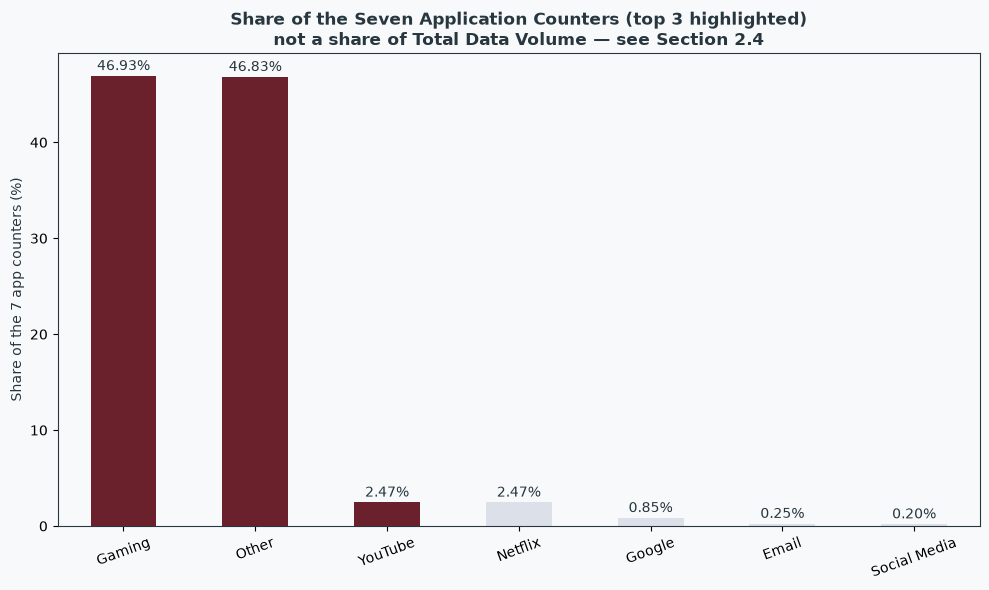

,Share of app-counter traffic (%)
Gaming,46.932
Other,46.833
YouTube,2.469
Netflix,2.468
Google,0.852
Email,0.246
Social Media,0.199


Top 3 named applications (excluding the catch-all "Other"): ['Gaming', 'YouTube', 'Netflix']


In [61]:
app_share = user_overview_raw[app_metrics].sum()      # untreated, from 3.0
app_share.index = apps
app_share_pct = (app_share / app_share.sum() * 100).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
colors = [TELLCO_PALETTE['berry'] if i < 3 else TELLCO_PALETTE['snowflake'] for i in range(len(app_share_pct))]
app_share_pct.plot(kind='bar', ax=ax, color=colors)
for i, v in enumerate(app_share_pct):
    ax.text(i, v + 0.6, f'{v:.2f}%', ha='center')
ax.set_title('Share of the Seven Application Counters (top 3 highlighted)\nnot a share of Total Data Volume — see Section 2.4',
             color=TELLCO_PALETTE['pine'], fontweight='bold')
ax.set_ylabel('Share of the 7 app counters (%)')
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig('figures/fig5b_top3_apps.png', dpi=100, facecolor='#F8F9FA')
plt.show()

display(app_share_pct.round(3).to_frame('Share of app-counter traffic (%)'))
print('Top 3 named applications (excluding the catch-all "Other"):', list(app_share_pct.drop("Other").index[:3]))

In [62]:
top10_per_app = {}
for app in apps:
    col = f'{app} Total (Bytes)'
    t = user_overview_raw[col].sort_values(ascending=False).head(10)   # untreated: treated values all sit at the IQR fence
    t.index = t.index.astype('int64').astype(str)
    top10_per_app[app] = t
    print(f'\n--- Top 10 {app} users ---')
    display(t.to_frame())
    assert len(t) == 10


--- Top 10 Social Media users ---


,Social Media Total (Bytes)
MSISDN/Number,
33626320676,43374779.0
33760536639,39783189.0
33659725664,35412358.0
33614892860,28294544.0
33625779332,27135500.0
33667163239,24247850.0
33786323068,23974919.0
33669068942,23800834.0
33603127838,23077825.0



--- Top 10 Google users ---


,Google Total (Bytes)
MSISDN/Number,
33626320676,152191852.0
33625779332,142307915.0
33614892860,127973787.0
33760536639,123223099.0
33659725664,116516345.0
33786323068,110254484.0
33675877202,109860502.0
33667163239,105032696.0
33761268199,97089988.0



--- Top 10 Email users ---


...

,Netflix Total (Bytes)
MSISDN/Number,
33659725664,399519079.0
33614892860,361401046.0
33625779332,356980607.0
33760536639,334643269.0
33626320676,328725740.0
33760413819,318347546.0
33667163239,313939488.0
33675877202,309093159.0
33786323068,305939790.0



--- Top 10 Gaming users ---


,Gaming Total (Bytes)
MSISDN/Number,
33614892860,7.749432e+09
33760536639,7.461045e+09
33625779332,7.326673e+09
33675877202,6.970568e+09
33626320676,6.887572e+09
33659725664,6.725559e+09
33666464084,6.646303e+09
33760413819,6.268620e+09
33664712899,6.103856e+09



--- Top 10 Other users ---


,Other Total (Bytes)
MSISDN/Number,
33626320676,8.167878e+09
33614892860,7.639264e+09
33675877202,6.798515e+09
33625779332,6.354583e+09
33603127838,6.326671e+09
33659725664,6.317415e+09
33626948251,5.305448e+09
33627080969,5.117791e+09
33761268199,5.077779e+09


**Interpretation.** Gaming (46.93%) and Other (46.83%) together account for about 93.8% of the sum of the seven application-level counters — **not** 93.8% of `Total Data Volume (Bytes)`, which is a smaller, differently constructed total (Section 2.4: `Total DL` excludes `Other DL`). The seven counters sum to 85% more than the recorded total for this reason. The dominance of these two is large either way, but the figure must not be quoted as "93.8% of TellCo's traffic" without this qualification, including in the executive summary.

`Other` is a catch-all bucket rather than a single application. Among **named** applications the top three are Gaming (46.93%), YouTube (2.47%) and Netflix (2.47%); YouTube and Netflix are separated by about 0.001 percentage points (2.469% vs. 2.468%), so their order is effectively a tie.

The per-application top-10 lists are drawn from the untreated table. On the treated table every list would sit at the IQR fence (Social Media at about 6.45M bytes, against an untreated maximum of 43.4M).

### 5.3 Normalisation & K-Means Clustering (k=3)

The three engagement metrics sit on incompatible scales — sessions in single digits, duration in the tens or hundreds of thousands of seconds, volume in the hundreds of millions of bytes — so each is standardised before clustering, which is scale-sensitive by construction. `n_init=20` is used (the scikit-learn default is 10), so each fit keeps the best of 20 initialisations. With `n_init=10` and `n_init=20`, every seed reaches the same inertia (135,336.0–135,336.4, within 0.4 of each other), so the choice does not change the result and 20 is kept as a precaution. A single initialisation (`n_init=1`) is the unreliable setting: it settles on a worse optimum for four of the five seeds (inertia up to 142,157 for seed 42, about 5% higher).

k-means numbers its clusters arbitrarily, and the numbering changes whenever the input table changes. Clusters are therefore re-numbered from their centroids: 0 = lowest composite (sum of the three standardised centroid coordinates), 2 = highest. Anything downstream that needs "the least engaged cluster" uses this ordering.

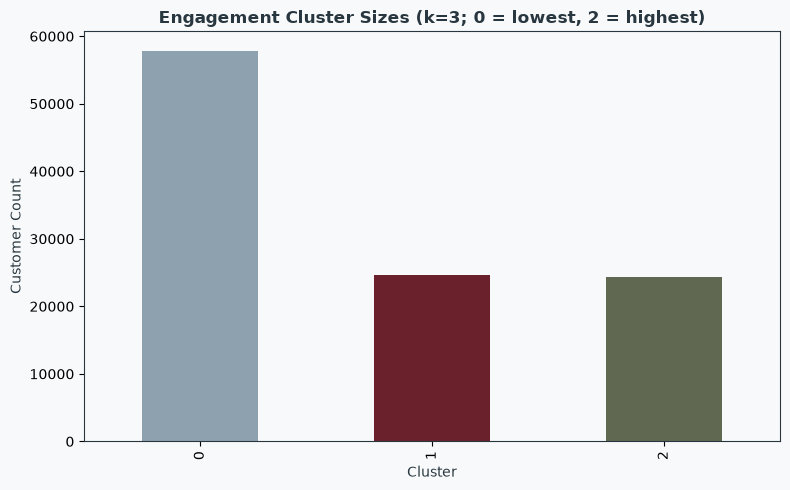

                    Customers  Share (%)
Engagement Cluster                      
0                       57834       54.1
1                       24654       23.1
2                       24368       22.8

Inertia: 135,336.1


In [63]:
scaler_eng = StandardScaler()
X_engagement = scaler_eng.fit_transform(user_overview[engagement_metrics])

kmeans_engagement = KMeans(n_clusters=3, random_state=RANDOM_STATE, n_init=20, max_iter=300)
raw_labels = kmeans_engagement.fit_predict(X_engagement)

# k-means numbers clusters arbitrarily. Re-number by engagement: composite = sum of the three scaled
# centroid coordinates; 0 = lowest, 2 = highest.
composite = pd.Series(kmeans_engagement.cluster_centers_.sum(axis=1))
order = composite.sort_values().index.to_list()                  # old ids, least -> most engaged
remap = {old: new for new, old in enumerate(order)}
user_overview['Engagement Cluster'] = pd.Series(raw_labels, index=user_overview.index).map(remap)
engagement_centers = kmeans_engagement.cluster_centers_[order]   # row i = centroid of NEW cluster i
LEAST_ENGAGED = 0

# Tripwires: the narrative assumes these
assert engagement_centers.sum(axis=1).argmin() == LEAST_ENGAGED
assert engagement_centers[:, 1].argmax() == 1     # middle cluster = longest bearer-open duration
assert engagement_centers[:, 0].argmax() == 2     # top cluster = most sessions

cluster_sizes = user_overview['Engagement Cluster'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 5))
cluster_sizes.plot(kind='bar', ax=ax,
                   color=[TELLCO_PALETTE['mist'], TELLCO_PALETTE['berry'], TELLCO_PALETTE['holly']])
ax.set_title('Engagement Cluster Sizes (k=3; 0 = lowest, 2 = highest)', color=TELLCO_PALETTE['pine'], fontweight='bold')
ax.set_xlabel('Cluster')
ax.set_ylabel('Customer Count')
plt.tight_layout()
plt.savefig('figures/fig5c_cluster_sizes.png', dpi=100, facecolor='#F8F9FA')
plt.show()

print(pd.DataFrame({'Customers': cluster_sizes, 'Share (%)': (cluster_sizes / len(user_overview) * 100).round(1)}))
print(f"\nInertia: {kmeans_engagement.inertia_:,.1f}")

In [64]:
rows = []
for sd in [0, 1, 42, 100, 2024]:
    for ni in [1, 10, 20]:
        km = KMeans(n_clusters=3, random_state=sd, n_init=ni, max_iter=300).fit(X_engagement)
        rows.append({'seed': sd, 'n_init': ni, 'inertia': km.inertia_})
init_df = pd.DataFrame(rows).pivot(index='seed', columns='n_init', values='inertia')
display(init_df.style.format('{:,.1f}'))

n_init,1,10,20
seed,,,
0,"135,693.9","135,336.1","135,336.0"
1,"142,150.1","135,336.4","135,336.2"
42,"142,157.1","135,336.1","135,336.1"
100,"135,693.0","135,336.2","135,336.2"
2024,"135,336.3","135,336.3","135,336.0"


Cluster sizes are 57,834 (54.1%), 24,654 (23.1%) and 24,368 (22.8%): uneven but not extreme. Whether k=3 is the right number of clusters, and whether this solution is stable, are tested next rather than assumed from the fact that the algorithm ran.

### 5.4 Cluster Validation Suite — Elbow, Silhouette, Davies-Bouldin, Calinski-Harabasz

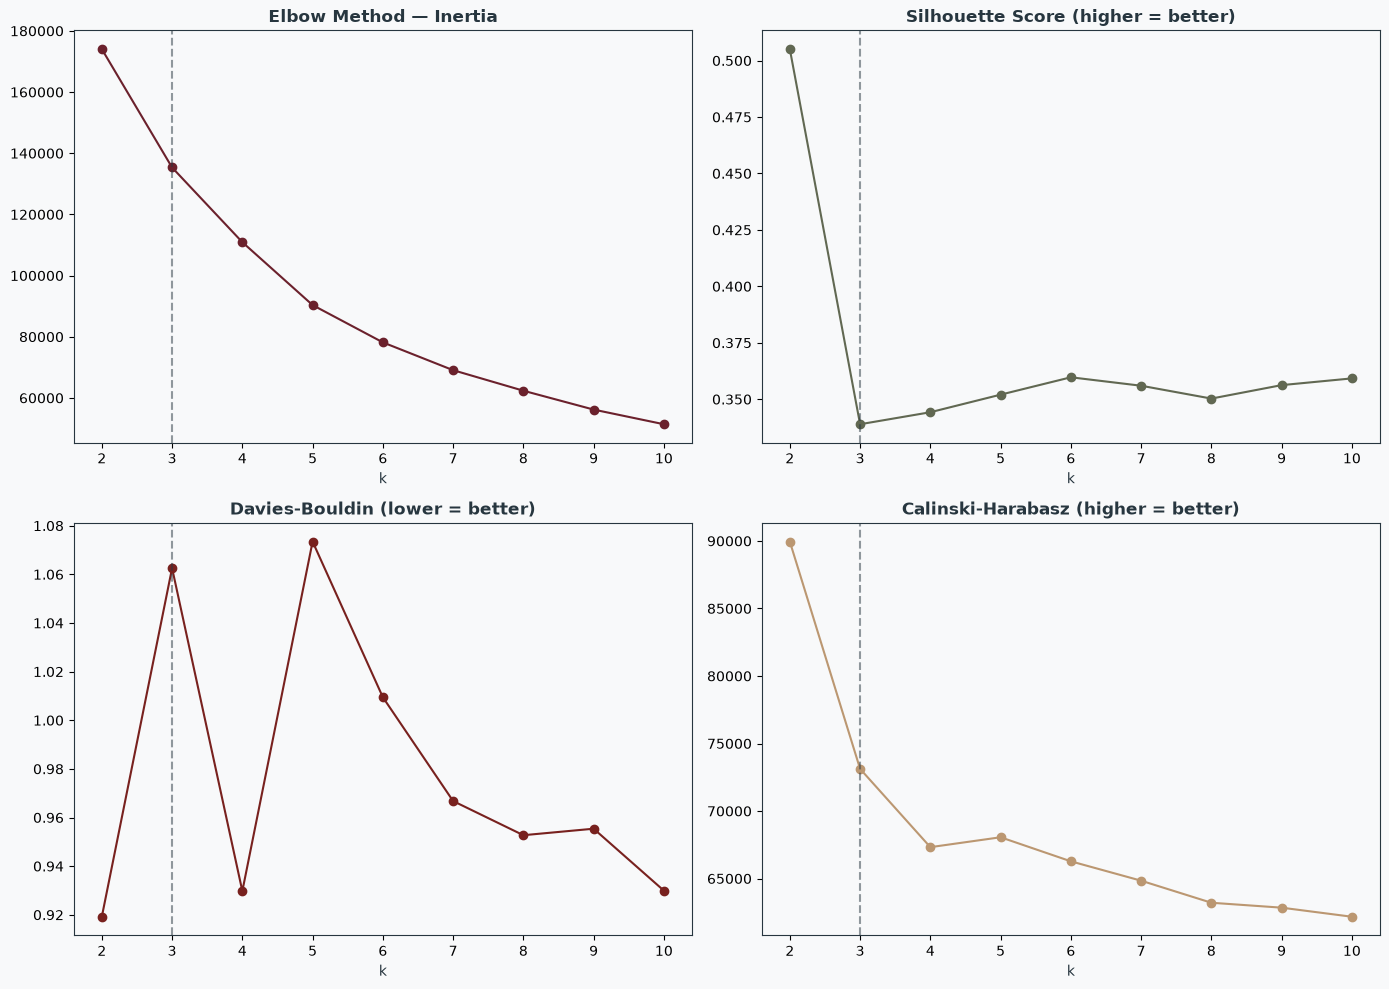

,Inertia,Silhouette,Davies-Bouldin,Calinski-Harabasz
k,,,,
2,"174,048.6450",0.5051,0.9192,"89,952.8959"
3,"135,336.1340",0.3389,1.0625,"73,123.9220"
4,"110,915.0180",0.3442,0.9298,"67,324.6536"
5,"90,357.6850",0.3520,1.0735,"68,057.9527"
6,"78,161.8067",0.3597,1.0095,"66,275.6910"
7,"69,071.9850",0.3560,0.9668,"64,841.1997"
8,"62,355.2845",0.3503,0.9527,"63,208.3108"
9,"56,188.0961",0.3562,0.9554,"62,843.5696"
10,"51,398.2136",0.3592,0.9299,"62,172.0073"


In [65]:
validation_results = []
for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10, max_iter=200)
    labels_k = km.fit_predict(X_engagement)
    sil = silhouette_score(X_engagement, labels_k, sample_size=5000, random_state=RANDOM_STATE)
    validation_results.append({
        'k': k, 'Inertia': km.inertia_, 'Silhouette': sil,
        'Davies-Bouldin': davies_bouldin_score(X_engagement, labels_k),
        'Calinski-Harabasz': calinski_harabasz_score(X_engagement, labels_k),
    })

validation_df = pd.DataFrame(validation_results).set_index('k')

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes[0, 0].plot(validation_df.index, validation_df['Inertia'], 'o-', color=TELLCO_PALETTE['berry'])
axes[0, 0].set_title('Elbow Method — Inertia', color=TELLCO_PALETTE['pine'], fontweight='bold')
axes[0, 0].axvline(3, color=TELLCO_PALETTE['pine'], linestyle='--', alpha=0.5)

axes[0, 1].plot(validation_df.index, validation_df['Silhouette'], 'o-', color=TELLCO_PALETTE['holly'])
axes[0, 1].set_title('Silhouette Score (higher = better)', color=TELLCO_PALETTE['pine'], fontweight='bold')
axes[0, 1].axvline(3, color=TELLCO_PALETTE['pine'], linestyle='--', alpha=0.5)

axes[1, 0].plot(validation_df.index, validation_df['Davies-Bouldin'], 'o-', color=TELLCO_PALETTE['mulled_wine'])
axes[1, 0].set_title('Davies-Bouldin (lower = better)', color=TELLCO_PALETTE['pine'], fontweight='bold')
axes[1, 0].axvline(3, color=TELLCO_PALETTE['pine'], linestyle='--', alpha=0.5)

axes[1, 1].plot(validation_df.index, validation_df['Calinski-Harabasz'], 'o-', color=TELLCO_PALETTE['cinnamon'])
axes[1, 1].set_title('Calinski-Harabasz (higher = better)', color=TELLCO_PALETTE['pine'], fontweight='bold')
axes[1, 1].axvline(3, color=TELLCO_PALETTE['pine'], linestyle='--', alpha=0.5)

for ax in axes.flat:
    ax.set_xlabel('k')

plt.tight_layout()
plt.savefig('figures/fig5d_cluster_validation.png', dpi=100, facecolor='#F8F9FA')
plt.show()

display(validation_df.style.format('{:,.4f}'))

In [66]:
validation_df['Inertia drop vs previous k (%)'] = (1 - validation_df['Inertia'] / validation_df['Inertia'].shift(1)) * 100
kk = validation_df.index.values.astype(float)
inn = validation_df['Inertia'].values
x_n = (kk - kk.min()) / (kk.max() - kk.min())
y_n = (inn - inn.min()) / (inn.max() - inn.min())
chord_dist = np.abs(x_n + y_n - 1) / np.sqrt(2)      # distance from the chord joining the first and last points
elbow_k = int(kk[chord_dist.argmax()])
display(validation_df[['Inertia', 'Inertia drop vs previous k (%)']].style.format({'Inertia': '{:,.1f}', 'Inertia drop vs previous k (%)': '{:.1f}'}, na_rep='—'))
print(f'Elbow (maximum distance from the chord): k = {elbow_k}')

,Inertia,Inertia drop vs previous k (%)
k,,
2,"174,048.6",—
3,"135,336.1",22.2
4,"110,915.0",18.0
5,"90,357.7",18.5
6,"78,161.8",13.5
7,"69,072.0",11.6
8,"62,355.3",9.7
9,"56,188.1",9.9
10,"51,398.2",8.5


Elbow (maximum distance from the chord): k = 5


**Interpretation.** Every internal metric prefers k=2 to k=3: silhouette 0.505 vs. 0.339, Davies–Bouldin 0.919 vs. 1.063 (lower is better) and Calinski–Harabasz 89,953 vs. 73,124. Beyond k=3 the metrics are flat and noisy: silhouette stays within 0.339–0.360 for k=3–10, Davies–Bouldin zig-zags between 0.93 and 1.07, and Calinski–Harabasz falls from 73,124 to 62,172 (with one small uptick at k=5). k=3 has the best Calinski–Harabasz of the k≥3 solutions but one of the worst Davies–Bouldin scores (only k=5 is worse), so nothing in the metrics singles it out.

The inertia curve has no sharp elbow: each extra cluster cuts inertia by 22.2% (k=2→3), 18.0%, 18.5%, 13.5%, 11.6%, and so on, a smooth decline. The maximum-distance-from-chord method places the elbow at k=5.

The "optimal k" therefore depends on the criterion: k=2 by validity metrics, k=5 by the elbow, and k=3 as the brief specifies. k=3 is used as required and checked for stability in 5.5, but it is not presented as the data-driven optimum.

**k=2 vs. k=3.** The k=2 solution separates a low group (81,437 customers; mean 1.0 sessions, 501M bytes) from a high group (25,419; 2.1 sessions, 991M bytes). k=3 keeps the high group almost intact (24,330 of its 25,419 customers form k=3 Cluster 2, and 99.8% of Cluster 2 comes from it) and splits the low group by duration into Cluster 0 (57,633) and Cluster 1 (23,766, mean duration about 2.5 times longer). The extra cluster is a duration split, not a new level of engagement. ARI between the two partitions is 0.525.

### 5.5 Seed-Stability Check

If k=3 is a meaningful segmentation and not an artifact of one particular random
initialisation, different seeds should recover essentially the same clusters. This is
checked directly via pairwise Adjusted Rand Index across five seeds, using the `n_init=20`
setting established in 5.3.

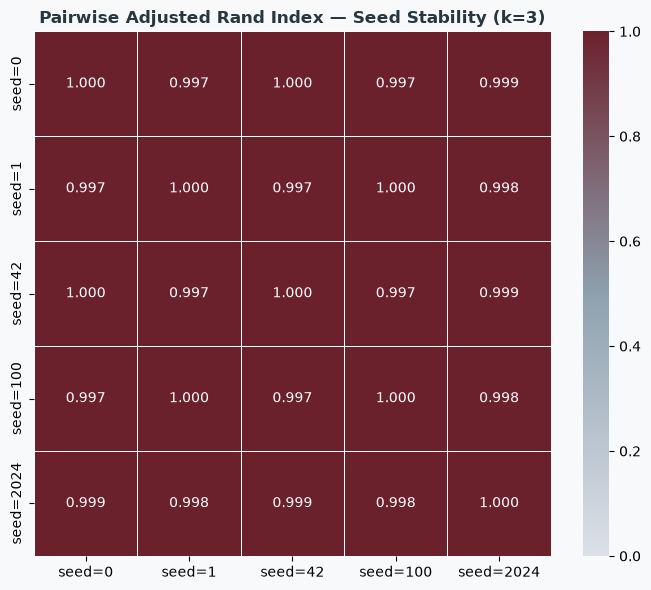

Mean pairwise ARI: 0.9981
Minimum pairwise ARI: 0.9968


In [67]:
seeds_to_test = [0, 1, 42, 100, 2024]
label_sets = []
for s in seeds_to_test:
    km_s = KMeans(n_clusters=3, random_state=s, n_init=20, max_iter=300)
    label_sets.append(km_s.fit_predict(X_engagement))

ari_matrix = np.zeros((len(seeds_to_test), len(seeds_to_test)))
for i in range(len(seeds_to_test)):
    for j in range(len(seeds_to_test)):
        ari_matrix[i, j] = adjusted_rand_score(label_sets[i], label_sets[j])

ari_df = pd.DataFrame(ari_matrix,
                       index=[f'seed={s}' for s in seeds_to_test],
                       columns=[f'seed={s}' for s in seeds_to_test])

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(ari_df, annot=True, fmt='.3f', cmap=tellco_seq, ax=ax, vmin=0, vmax=1, linewidths=0.5, linecolor='white')
ax.set_title('Pairwise Adjusted Rand Index — Seed Stability (k=3)', color=TELLCO_PALETTE['pine'], fontweight='bold')
plt.tight_layout()
plt.savefig('figures/fig5e_ari_stability.png', dpi=100, facecolor='#F8F9FA')
plt.show()

off_diag = ari_matrix[np.triu_indices(len(seeds_to_test), k=1)]
print(f'Mean pairwise ARI: {off_diag.mean():.4f}')
print(f'Minimum pairwise ARI: {off_diag.min():.4f}')

In [68]:
km2 = KMeans(n_clusters=2, random_state=RANDOM_STATE, n_init=20, max_iter=300).fit(X_engagement)
o2 = pd.Series(km2.cluster_centers_.sum(axis=1)).sort_values().index.to_list()
lab2 = pd.Series(km2.labels_, index=user_overview.index).map({o: n for n, o in enumerate(o2)})   # 0 = less engaged
lab3 = user_overview['Engagement Cluster']

display(pd.crosstab(lab2.rename('k=2'), lab3.rename('k=3')).style.format('{:,}'))
display(pd.crosstab(lab2.rename('k=2'), lab3.rename('k=3'), normalize='columns').style.format('{:.1%}'))
print(f'ARI k=2 vs k=3: {adjusted_rand_score(lab2, lab3):.3f}')
display(user_overview.groupby(lab2)[engagement_metrics].mean().style.format('{:,.1f}'))

k=3,0,1,2
k=2,,,
0,"57,633","23,766",38
1,201,888,"24,330"


k=3,0,1,2
k=2,,,
0,99.7%,96.4%,0.2%
1,0.3%,3.6%,99.8%


ARI k=2 vs k=3: 0.525


,xDR Sessions,Total Duration (s),Total Data Volume (Bytes)
0,1.0,"98,970.4","501,095,862.7"
1,2.1,"163,750.5","991,118,126.2"


**Interpretation.** Across five seeds, mean pairwise ARI is 0.998 (minimum 0.997): the seeds recover essentially the same partition, so the clustering is highly stable and the profile in 5.6 reflects the data, not one particular initialisation.

### 5.6 Cluster Profiling — Original and Scaled Units

Interpretation is always done on original units; scaled units confirm the direction and
relative magnitude of each cluster's separation without the units obscuring it.

In [69]:
profile_original = user_overview.groupby('Engagement Cluster')[engagement_metrics].agg(['min', 'max', 'mean', 'sum'])
display(profile_original.style.format('{:,.2f}'))
traffic_share = user_overview.groupby('Engagement Cluster')['Total Data Volume (Bytes)'].sum() / user_overview['Total Data Volume (Bytes)'].sum() * 100
print('Share of treated traffic by cluster (%):', traffic_share.round(1).to_dict())

Share of treated traffic by cluster (%): {0: 44.3, 1: 18.3, 2: 37.3}


,xDR Sessions,Total Duration (s),Total Data Volume (Bytes)
Engagement Cluster,,,
0,-0.492,-0.663,-0.334
1,-0.477,0.862,-0.377
2,1.651,0.701,1.173


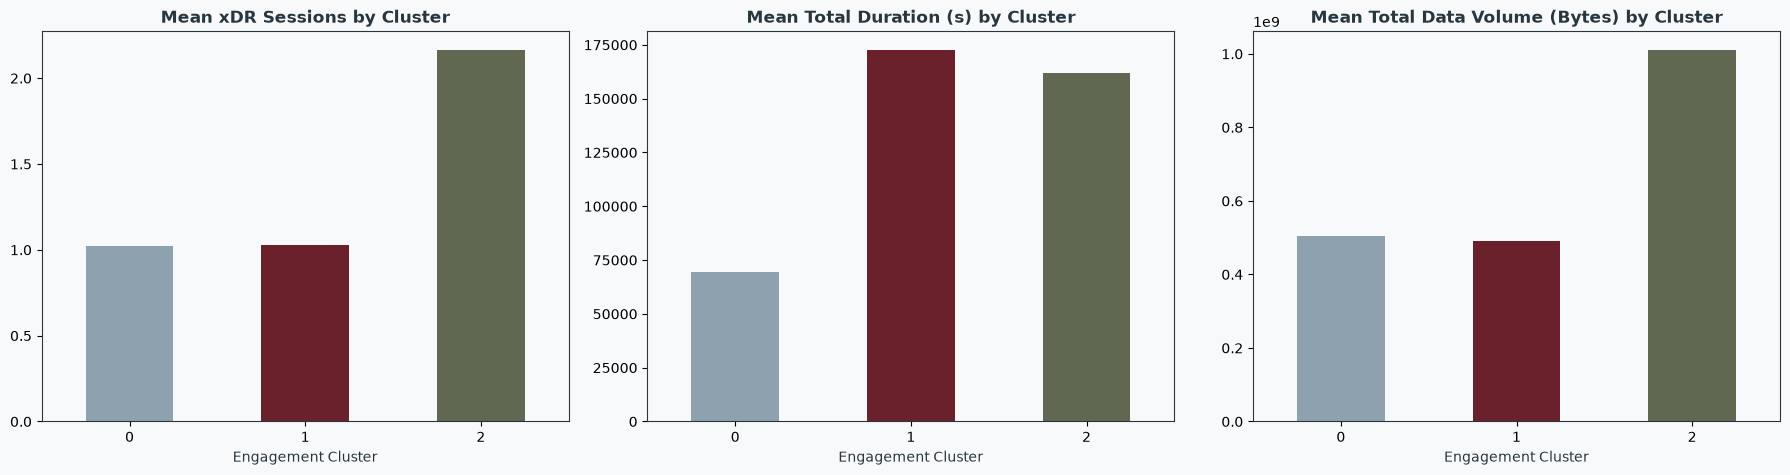

In [70]:
X_scaled_df = pd.DataFrame(X_engagement, columns=engagement_metrics, index=user_overview.index)
X_scaled_df['Engagement Cluster'] = user_overview['Engagement Cluster'].values
scaled_centroids = X_scaled_df.groupby('Engagement Cluster')[engagement_metrics].mean()

display(scaled_centroids.style.background_gradient(cmap=tellco_div, vmin=-2, vmax=2).format('{:.3f}'))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, metric in enumerate(engagement_metrics):
    means = user_overview.groupby('Engagement Cluster')[metric].mean()
    means.plot(kind='bar', ax=axes[i],
               color=[TELLCO_PALETTE['mist'], TELLCO_PALETTE['berry'], TELLCO_PALETTE['holly']])
    axes[i].set_title(f'Mean {metric} by Cluster', color=TELLCO_PALETTE['pine'], fontweight='bold')
    axes[i].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('figures/fig5f_cluster_means.png', dpi=100, facecolor='#F8F9FA')
plt.show()

**Interpretation — under the mandated treatment, the clusters do not form a simple low/medium/high ladder** (the capped version in 5.7 does). Clusters are numbered by engagement (0 = lowest composite, 2 = highest), but the middle cluster is not "medium".

**Cluster 2 — High engagement** (24,368 customers, 22.8%) leads on sessions and traffic: mean 2.17 sessions and 1.01 billion bytes. It carries about 37% of treated traffic. It does **not** lead on duration (161,850 s, ~45.0 hours).

**Cluster 0 — Low engagement** (57,834 customers, 54.1%): 1.02 sessions, 69,489 s (~19.3 hours) and 505.6M bytes. This is the reference group for the engagement score in Section 7.

**Cluster 1 — Long-hold, light traffic** (24,654 customers, 23.1%): 1.03 sessions and 491.2M bytes, essentially the same as Cluster 0, but a mean duration of 172,768 s (~48.0 hours), about 2.5 times longer and the longest of the three. Recall from Section 2.1 that duration is bearer-open span, not active transfer time, so this reads as connections held open for much longer for the same traffic, not heavier use.

**Limitation.** The treated table records customers with four or more sessions as having one, and replaces extreme durations and volumes, so the segmentation cannot see the heaviest users. Section 5.7 checks how far this matters.

### 5.7 Sensitivity — treated vs. IQR-capped clustering

The clustering is repeated on the IQR-capped table (extremes limited to the fence rather than replaced by the mean) to check that the segmentation does not depend on the mandated treatment.

ARI between the treated and capped partitions is 0.436, against 0.998 across seeds, so the segmentation depends on the treatment, not only on initialisation. Of 106,856 customers, 61,710 (57.8%) fall in the same-numbered cluster in both versions and 45,146 (42.2%) do not; cluster numbers rank engagement within each solution, so they do not label identical groups.

The clearest difference is at the top. The capped solution isolates 8,011 customers with mean 3.6 sessions, about 467,000 s and 1.83 billion bytes (untreated units): 5,130 from the treated high-engagement cluster and 2,881 from the two lighter ones. The ten most-session customers (12–18 sessions, 5.0 to 8.8 billion bytes) are all recorded as 1 session and an identical 617.7M bytes in the treated table, and all ten sit in Cluster 0, the low-engagement cluster. Under capping, all ten fall in the highest cluster.

The capped clusters also form a ladder on all three metrics (sessions 1.0 / 1.9 / 3.6; duration 96,168 / 202,989 / 466,590 s; volume 490M / 973M / 1.83B bytes). The treated clusters do not, and the treated long-hold cluster is largely absorbed into capped Cluster 0 (22,058 of 24,654, 89.5%). Capped clusters are profiled in untreated units and treated clusters in treated units, so absolute means are not directly comparable. The treated result stays primary, as the brief requires, but conclusions about the heaviest users and about the long-hold cluster are treatment-dependent.

In [71]:
X_cap = StandardScaler().fit_transform(user_overview_capped[engagement_metrics])
km_cap = KMeans(n_clusters=3, random_state=RANDOM_STATE, n_init=20, max_iter=300).fit(X_cap)
oc = pd.Series(km_cap.cluster_centers_.sum(axis=1)).sort_values().index.to_list()
cap_labels = pd.Series(km_cap.labels_, index=user_overview.index).map({o: n for n, o in enumerate(oc)})

print(f'ARI treated vs capped: {adjusted_rand_score(user_overview["Engagement Cluster"], cap_labels):.3f}')
display(pd.crosstab(user_overview['Engagement Cluster'].rename('treated (primary)'), cap_labels.rename('capped')).style.format('{:,}'))
print('Capped clusters, profiled in UNTREATED units:')
prof = user_overview_raw.groupby(cap_labels)[engagement_metrics].mean()
prof['Customers'] = cap_labels.value_counts().sort_index()
display(prof.style.format('{:,.1f}'))

ids = user_overview_raw['xDR Sessions'].nlargest(10).index
display(pd.DataFrame({
    'Sessions (untreated)': user_overview_raw.loc[ids, 'xDR Sessions'],
    'Sessions (treated)':   user_overview.loc[ids, 'xDR Sessions'],
    'Volume (untreated)':   user_overview_raw.loc[ids, 'Total Data Volume (Bytes)'],
    'Volume (treated)':     user_overview.loc[ids, 'Total Data Volume (Bytes)'],
    'Primary cluster':      user_overview.loc[ids, 'Engagement Cluster'],
    'Capped cluster':       cap_labels.loc[ids]}))

ARI treated vs capped: 0.436


capped,0,1,2
treated (primary),,,
0,"54,318",969,"2,547"
1,"22,058","2,262",334
2,233,"19,005","5,130"


Capped clusters, profiled in UNTREATED units:


,xDR Sessions,Total Duration (s),Total Data Volume (Bytes),Customers
0,1.0,"96,167.9","489,845,669.6","76,609.0"
1,1.9,"202,988.7","972,662,135.6","22,236.0"
2,3.6,"466,590.2","1,832,323,599.7","8,011.0"


,Sessions (untreated),Sessions (treated),Volume (untreated),Volume (treated),Primary cluster,Capped cluster
MSISDN/Number,,,,,,
3.362632e+10,18,1,7.971167e+09,6.176628e+08,0,2
3.361489e+10,17,1,8.846226e+09,6.176628e+08,0,2
3.362578e+10,17,1,8.499621e+09,6.176628e+08,0,2
3.365973e+10,16,1,7.705863e+09,6.176628e+08,0,2
3.367588e+10,15,1,7.891111e+09,6.176628e+08,0,2
3.376054e+10,15,1,8.514774e+09,6.176628e+08,0,2
3.366716e+10,13,1,5.618394e+09,6.176628e+08,0,2
3.360313e+10,12,1,4.976195e+09,6.176628e+08,0,2
3.360452e+10,12,1,5.487855e+09,6.176628e+08,0,2


**Section 5 summary.**

| Check | Result | Interpretation |
|---|---|---|
| Top 10 tables | Untreated table, full MSISDNs | Treated values would sit at the IQR fence, not at genuine extremes |
| Top 3 applications | Gaming 46.93%, Other 46.83%, YouTube 2.47% (Netflix 2.47%) — **share of the 7 app counters, not of `Total Data Volume`** | Top three named applications: Gaming, YouTube, Netflix; denominator caveat travels with the number |
| Cluster sizes (k=3) | 57,834 / 24,654 / 24,368 (54.1% / 23.1% / 22.8%) | Numbered by engagement: 0 = low, 2 = high |
| Statistically optimal k | k=2 on silhouette, Davies–Bouldin and Calinski–Harabasz; elbow at k=5 | k=3 used as the brief requires, not because it is data-optimal |
| Seed stability (k=3) | Mean ARI 0.998, minimum 0.997 | Highly stable |
| Cluster structure | Low (54.1%), Long-hold/light traffic (23.1%), High (22.8%, ~37% of treated traffic) | Not a ladder under the mandated treatment (the capped version in 5.7 is a ladder): Clusters 0 and 1 differ in duration, not in traffic |
| Treated vs. capped | ARI 0.436; the ten highest-session customers sit in low-engagement Cluster 0 when treated and all in the top cluster when capped; capped clusters form a ladder | Shows what mean replacement hides; findings on the heaviest users and the long-hold cluster are treatment-dependent |

This closes **Section 5 — User Engagement**.

## 📡 Section 6 — User Experience

This section aggregates network-quality metrics per customer (TCP retransmission, RTT and throughput), reports the extremes and most common values on each, breaks down handset and manufacturer distribution with a marketing recommendation, profiles throughput and retransmission for the top handsets, and segments customers with k-means (k=3).

**Data-quality limits that shape the results.**
- *TCP retransmission is the weakest metric*: 58.9% (DL) and 64.6% (UL) of sessions had no measured value and were mean-imputed in Section 2. After aggregation, 25.6% of customers have no imputed TCP value in any session, 63.2% have an imputed direction in every session, and 11.1% are mixed; 52.4% share the single imputed value. The largest single-direction TCP value is within 0.013% of the 32-bit counter limit (4,294,967,295), making the extreme end suggestive of a possible 32-bit counter ceiling. This is an inference from the observed maximum alone; the number of genuinely capped observations is not established.
- *RTT*: about 18.5% of sessions imputed; 17.3% of customers sit on the imputed value. 0 ms is physically implausible and values above 10 s are probably logging errors.
- *Throughput* has almost no imputation and is the most reliable of the three, though repeated round values (7.5 and 31.5 kbps) may be default bearer rates.

The brief's mean replacement is applied to the customer-level metrics (Task 3.1); untreated and capped versions serve as sensitivity checks (6.6). The treatment matters here because it replaces the *highest* values: the best-connected customers on throughput and the worst-affected on TCP. Results describe the extraction window.

### 6.1 Experience Metric Aggregation

**Aggregation rules.** Within each session, TCP retransmission is the *sum* of the downlink and uplink volumes (both are byte volumes); RTT and throughput are the *mean* of downlink and uplink (both are rates). Each customer's value is then the *mean across that customer's sessions*. Sessions with a missing direction carry the Section 2 imputed value for that direction, so a customer's TCP figure mixes measured and imputed components (see the shares below).

In [72]:
# Throughput carries 1 missing session-level value each direction, not caught in Section 2 —
# mean-imputed here on the same basis as TCP/RTT were.
for col in ['Avg Bearer TP DL (kbps)', 'Avg Bearer TP UL (kbps)']:
    n_missing = df_clean[col].isna().sum()
    if n_missing:
        df_clean[col] = df_clean[col].fillna(df_clean[col].mean())
        print(f'{col}: {n_missing} missing value mean-imputed')

# TCP retransmission is a volume — DL and UL summed.
# RTT and throughput are rates — DL and UL averaged.
df_clean['TCP Retransmission (Bytes)'] = (
    df_clean['TCP DL Retrans. Vol (Bytes)'] + df_clean['TCP UL Retrans. Vol (Bytes)']
)
df_clean['RTT (ms)'] = df_clean[['Avg RTT DL (ms)', 'Avg RTT UL (ms)']].mean(axis=1)
df_clean['Throughput (kbps)'] = df_clean[['Avg Bearer TP DL (kbps)', 'Avg Bearer TP UL (kbps)']].mean(axis=1)

def most_frequent(s):
    return s.mode().iloc[0] if not s.mode().empty else 'Unknown'

experience = df_clean.groupby('MSISDN/Number').agg(
    **{
        'Avg TCP Retransmission (Bytes)': ('TCP Retransmission (Bytes)', 'mean'),
        'Avg RTT (ms)': ('RTT (ms)', 'mean'),
        'Avg Throughput (kbps)': ('Throughput (kbps)', 'mean'),
    }
)
experience['Most Frequent Handset'] = df_clean.groupby('MSISDN/Number')['Handset Type'].agg(most_frequent)

print(f'Experience table: {experience.shape[0]:,} customers × {experience.shape[1]} features')
display(experience.head())

Experience table: 106,856 customers × 4 features


,Avg TCP Retransmission (Bytes),Avg RTT (ms),Avg Throughput (kbps),Most Frequent Handset
MSISDN/Number,,,,
3.360100e+10,2.165043e+07,23.000000,38.0,Huawei P20 Lite Huawei Nova 3E
3.360100e+10,2.165043e+07,15.500000,49.5,Apple iPhone 7 (A1778)
3.360100e+10,2.165043e+07,62.930988,48.5,Unknown
3.360101e+10,7.673135e+05,42.000000,124.0,Apple iPhone 5S (A1457)
3.360101e+10,1.551063e+07,29.750000,14211.0,Apple iPhone Se (A1723)


In [73]:
f = df_clean
imp = pd.DataFrame({
    'tcp': f['TCP DL Retrans. Vol (Bytes)_was_imputed'] | f['TCP UL Retrans. Vol (Bytes)_was_imputed'],
    'rtt': f['Avg RTT DL (ms)_was_imputed'] | f['Avg RTT UL (ms)_was_imputed'],
}).groupby(f['MSISDN/Number']).mean()
experience['TCP imputed share'] = imp['tcp']
experience['RTT imputed share'] = imp['rtt']
experience_raw = experience.copy()      # frozen, untreated; 6.4 rebuilds `experience` from this

print({c: f'{f[c + "_was_imputed"].mean():.1%}' for c in mean_impute_cols})
t, r = experience_raw['TCP imputed share'], experience_raw['RTT imputed share']
print(f'TCP: {(t==0).mean():.1%} fully observed, {(t==1).mean():.1%} fully imputed, {((t>0)&(t<1)).mean():.1%} mixed')
print(f'RTT: {(r==0).mean():.1%} fully observed, {(r==1).mean():.1%} fully imputed')
print('Max single-direction TCP volume:', f[['TCP DL Retrans. Vol (Bytes)', 'TCP UL Retrans. Vol (Bytes)']].max().to_dict(), '| uint32 max = 4,294,967,295')
print('Customers with avg throughput = 0:', int((experience_raw['Avg Throughput (kbps)'] == 0).sum()),
      '| avg RTT = 0:', int((experience_raw['Avg RTT (ms)'] == 0).sum()),
      '| avg RTT > 1,000 ms:', int((experience_raw['Avg RTT (ms)'] > 1000).sum()))

{'TCP DL Retrans. Vol (Bytes)': '58.9%', 'TCP UL Retrans. Vol (Bytes)': '64.6%', 'HTTP DL (Bytes)': '54.5%', 'HTTP UL (Bytes)': '54.7%', 'Avg RTT DL (ms)': '18.6%', 'Avg RTT UL (ms)': '18.5%'}
TCP: 25.6% fully observed, 63.2% fully imputed, 11.1% mixed
RTT: 77.6% fully observed, 17.4% fully imputed
Max single-direction TCP volume: {'TCP DL Retrans. Vol (Bytes)': 4294425570.0, 'TCP UL Retrans. Vol (Bytes)': 2908226006.0} | uint32 max = 4,294,967,295
Customers with avg throughput = 0: 108 | avg RTT = 0: 2 | avg RTT > 1,000 ms: 634


### 6.2 Top, Bottom, and Most-Frequent 10 Values

In [74]:
exp_metrics = ['Avg TCP Retransmission (Bytes)', 'Avg RTT (ms)', 'Avg Throughput (kbps)']

for metric in exp_metrics:
    print(f'\n{"="*60}\n{metric}\n{"="*60}')
    print('Top 10:', experience[metric].sort_values(ascending=False).head(10).round(2).tolist())
    print('Bottom 10:', experience[metric].sort_values(ascending=True).head(10).round(2).tolist())
    print('Most frequent 10:')
    display(experience[metric].value_counts().head(10))


Avg TCP Retransmission (Bytes)
Top 10: [4301477439.0, 4288120860.0, 4268647350.0, 4254659643.0, 4211257819.0, 4166594973.0, 4137937737.0, 4117804973.0, 3968120596.0, 3786870933.0]
Bottom 10: [97.0, 128.0, 129.0, 134.0, 143.0, 176.0, 176.0, 177.0, 179.0, 182.0]
Most frequent 10:


Avg TCP Retransmission (Bytes)
2.165043e+07    55974
2.088548e+07      367
2.088551e+07      167
7.675775e+05      145
2.126795e+07       82
2.088550e+07       81
7.689075e+05       78
7.663395e+05       78
7.662855e+05       70
2.088684e+07       65
Name: count, dtype: int64


Avg RTT (ms)
Top 10: [48462.0, 27424.0, 16167.5, 13639.0, 13150.0, 12857.5, 12694.0, 12369.0, 11505.25, 10490.0]
Bottom 10: [0.0, 0.0, 1.0, 2.0, 2.5, 3.0, 4.0, 4.5, 4.5, 5.0]
Most frequent 10:


Avg RTT (ms)
62.930988    18514
14.500000     2950
19.500000     2367
19.000000     1639
20.000000     1583
15.000000     1577
14.000000     1456
24.500000     1308
20.500000     1207
15.500000     1190
Name: count, dtype: int64


Avg Throughput (kbps)
Top 10: [141965.5, 132862.0, 132588.25, 127475.0, 119491.0, 117682.5, 115491.0, 114151.5, 113667.0, 113252.5]
Bottom 10: [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
Most frequent 10:


Avg Throughput (kbps)
7.5     2872
31.5    2138
48.5    1094
45.0    1062
49.0    1025
48.0     938
49.5     918
44.5     881
45.5     864
47.5     856
Name: count, dtype: int64

In [75]:
session_metrics = {'TCP Retransmission (Bytes)': 'TCP Retransmission (Bytes)',
                    'RTT (ms)': 'RTT (ms)', 'Throughput (kbps)': 'Throughput (kbps)'}
for label, col in session_metrics.items():
    print(f'=== {label} (session level) ===')
    print('Top 10:', df_clean[col].sort_values(ascending=False).head(10).round(2).tolist())
    print('Bottom 10:', df_clean[col].sort_values(ascending=True).head(10).round(2).tolist())
    display(df_clean[col].value_counts().head(10).rename('count'))

=== TCP Retransmission (Bytes) (session level) ===
Top 10: [4344115651.0, 4301477439.0, 4294431965.0, 4291464950.0, 4288120860.0, 4275491713.0, 4268647350.0, 4261616039.0, 4260174145.0, 4254659643.0]
Bottom 10: [86.0, 97.0, 106.0, 108.0, 113.0, 128.0, 129.0, 134.0, 134.0, 143.0]


TCP Retransmission (Bytes)
2.165043e+07    84973
2.088548e+07      649
7.675775e+05      246
2.088551e+07      243
7.662855e+05      136
2.088550e+07      130
7.663395e+05      130
7.689075e+05      118
7.675655e+05      104
2.088684e+07       98
Name: count, dtype: int64

=== RTT (ms) (session level) ===
Top 10: [48462.0, 32320.5, 27424.0, 13639.0, 13150.0, 12961.0, 12857.5, 12694.0, 12369.0, 10490.0]
Bottom 10: [0.0, 0.0, 0.0, 0.0, 1.0, 2.0, 2.0, 2.5, 3.0, 3.0]


RTT (ms)
62.930988    27616
14.500000     4990
19.500000     4210
19.000000     2755
20.000000     2639
15.000000     2591
14.000000     2424
24.500000     2205
20.500000     1964
15.500000     1956
Name: count, dtype: int64

=== Throughput (kbps) (session level) ===
Top 10: [191131.0, 156622.0, 152149.5, 150273.0, 141965.5, 140572.0, 138576.0, 138102.5, 137026.0, 134944.0]
Bottom 10: [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


Throughput (kbps)
31.5    3886
7.5     3681
48.5    1945
45.0    1882
49.0    1800
48.0    1670
49.5    1570
44.5    1556
45.5    1513
46.5    1490
Name: count, dtype: int64

**Interpretation.** Throughput is better when high; RTT and TCP retransmission are better when low, so the business reading runs in opposite directions, which matters for the cluster labels in 6.4.

**Imputation dominates the frequency tables.** The most common TCP value covers 52.4% of customers (57.1% of sessions) and the most common RTT value 17.3% (18.5% of sessions). Both are Section 2's imputed means, not repeated measurements. Other frequent TCP values (about 20.89M and 0.77M bytes) match the imputed DL and UL means individually, consistent with sessions where only one direction was missing.

**Extremes are a data-quality question.** The largest single-direction TCP retransmission value is 4,294,425,570 bytes (DL), within 0.013% of the 32-bit unsigned limit of 4,294,967,295. This is suggestive of a possible counter ceiling, but it is not proof: the observed maximum alone cannot show how many values are capped, or whether any counter actually saturated. The largest per-session values (up to 4.34 billion bytes) are DL and UL summed, so they can exceed a single 32-bit counter. RTT reaches 48,462 ms, and 2 customers average exactly 0 ms, which is not physically possible; both are treated as logging artifacts, not as customers without a usable connection.

**Throughput** shows no imputation spike: its most common values (7.5 kbps at 2.7% of customers, 31.5 kbps at 2.0%) are small shares, though repeated round values may be default bearer rates. 108 customers average exactly 0 kbps, which means no payload was recorded rather than a measured speed.

### 6.3 Handset & Manufacturer Breakdown

Handset identity is a session-level attribute, so the counts below are sessions, as the brief's top-10 view asks. Because the brief speaks of "handsets used by the customers", customer-level counts are shown alongside. `Unknown` (6.0% of sessions) is the Section 2.5 placeholder, not a device; it is shown in the session ranking but excluded from the customer-level and Unknown-excluded rankings.

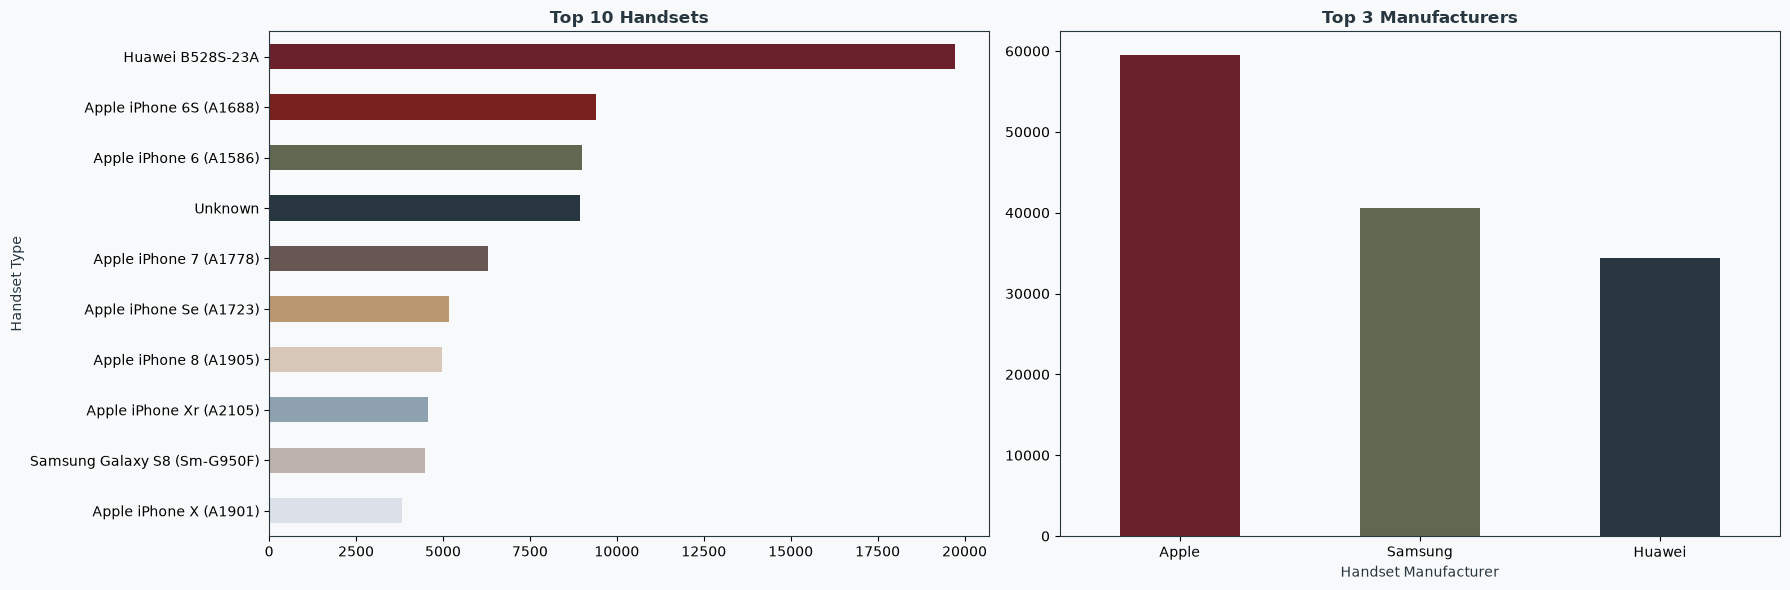

Handset Type
Huawei B528S-23A                19727
Apple iPhone 6S (A1688)          9413
Apple iPhone 6 (A1586)           9012
Unknown                          8931
Apple iPhone 7 (A1778)           6304
Apple iPhone Se (A1723)          5176
Apple iPhone 8 (A1905)           4985
Apple iPhone Xr (A2105)          4562
Samsung Galaxy S8 (Sm-G950F)     4480
Apple iPhone X (A1901)           3810
Name: count, dtype: int64

Handset Manufacturer
Apple      39.93
Samsung    27.25
Huawei     23.07
Name: count, dtype: float64

In [76]:
top10_handsets = df_clean['Handset Type'].value_counts().head(10)
top3_manufacturers = df_clean['Handset Manufacturer'].value_counts().head(3)
top3_pct = (top3_manufacturers / len(df_clean) * 100).round(2)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
top10_handsets.plot(kind='barh', ax=axes[0], color=TELLCO_PALETTE_LIST[:10])
axes[0].set_title('Top 10 Handsets', color=TELLCO_PALETTE['pine'], fontweight='bold')
axes[0].invert_yaxis()

top3_manufacturers.plot(kind='bar', ax=axes[1],
                         color=[TELLCO_PALETTE['berry'], TELLCO_PALETTE['holly'], TELLCO_PALETTE['pine']])
axes[1].set_title('Top 3 Manufacturers', color=TELLCO_PALETTE['pine'], fontweight='bold')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('figures/fig6a_handset_manufacturer.png', dpi=100, facecolor='#F8F9FA')
plt.show()

display(top10_handsets)
display(top3_pct)

`Unknown` appears as the 4th most common handset (8,931 sessions, 6.00% of the cleaned
dataset) — this is the placeholder category Section 2.5 assigned to sessions with no usable
device identity, not a real device. It's shown here rather than dropped, since 6% of sessions
running on an unidentified device is itself worth surfacing, and it's excluded from the
per-manufacturer breakdown below since it carries no manufacturer.

Handset Type
Apple iPhone 6S (A1688)    9413
Apple iPhone 6 (A1586)     9012
Apple iPhone 7 (A1778)     6304
Apple iPhone Se (A1723)    5176
Apple iPhone 8 (A1905)     4985
Name: Apple — count, dtype: int64

Handset Type
Samsung Galaxy S8 (Sm-G950F)    4480
Samsung Galaxy A5 Sm-A520F      3708
Samsung Galaxy J5 (Sm-J530)     3682
Samsung Galaxy J3 (Sm-J330)     3464
Samsung Galaxy S7 (Sm-G930X)    3176
Name: Samsung — count, dtype: int64

Handset Type
Huawei B528S-23A                  19727
Huawei E5180                       2074
Huawei P20 Lite Huawei Nova 3E     2018
Huawei P20                         1479
Huawei Y6 2018                      997
Name: Huawei — count, dtype: int64

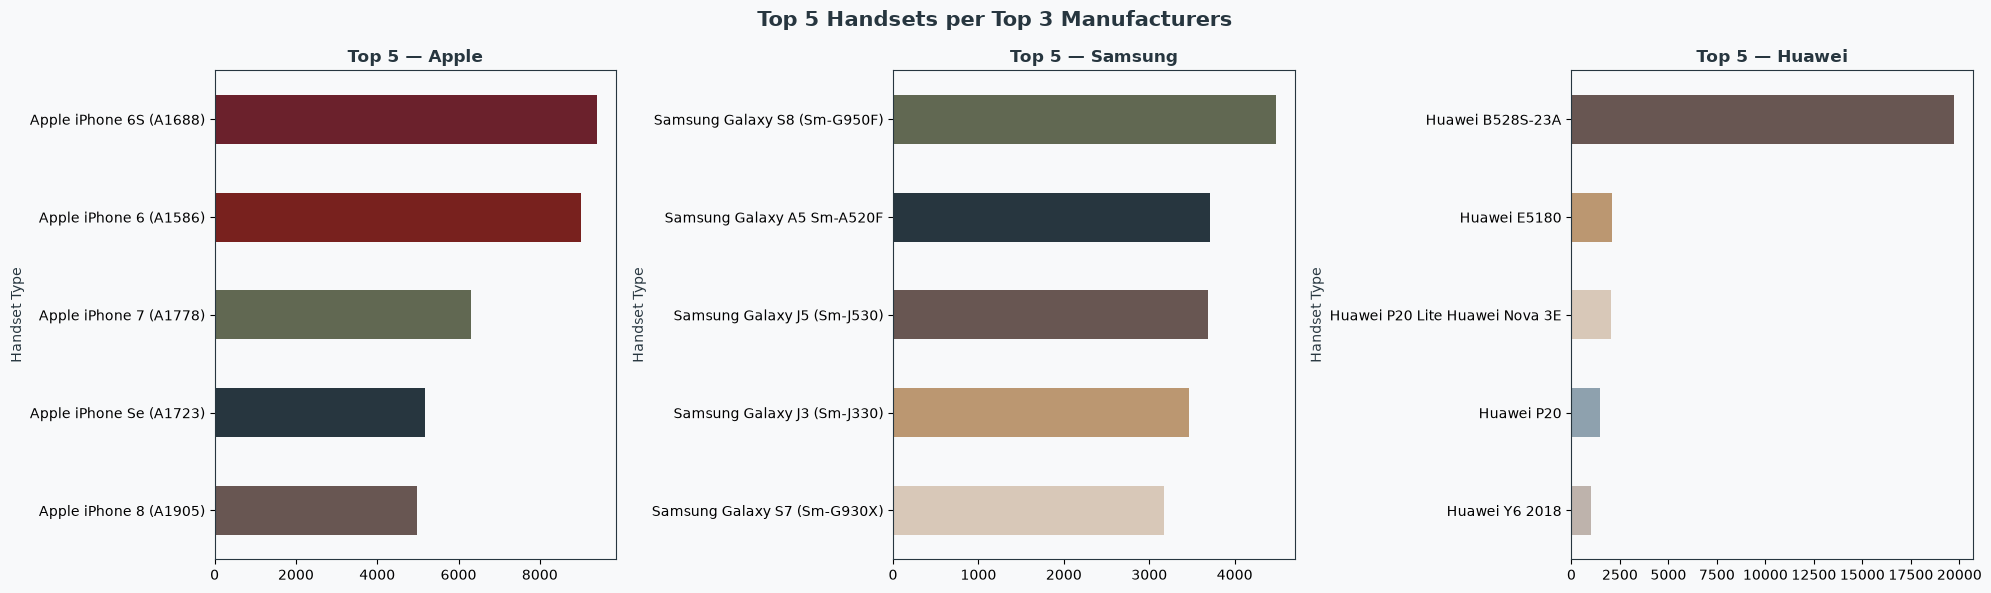

In [77]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
top3_list = top3_manufacturers.index.tolist()

for i, mfg in enumerate(top3_list):
    top5 = df_clean[df_clean['Handset Manufacturer'] == mfg]['Handset Type'].value_counts().head(5)
    top5.plot(kind='barh', ax=axes[i], color=TELLCO_PALETTE_LIST[i*2:i*2+5] or TELLCO_PALETTE_LIST[:5])
    axes[i].set_title(f'Top 5 — {mfg}', color=TELLCO_PALETTE['pine'], fontweight='bold')
    axes[i].invert_yaxis()
    display(top5.rename(f'{mfg} — count'))

plt.suptitle('Top 5 Handsets per Top 3 Manufacturers', fontsize=15, color=TELLCO_PALETTE['pine'], fontweight='bold')
plt.tight_layout()
plt.savefig('figures/fig6b_top5_per_manufacturer.png', dpi=100, facecolor='#F8F9FA')
plt.show()

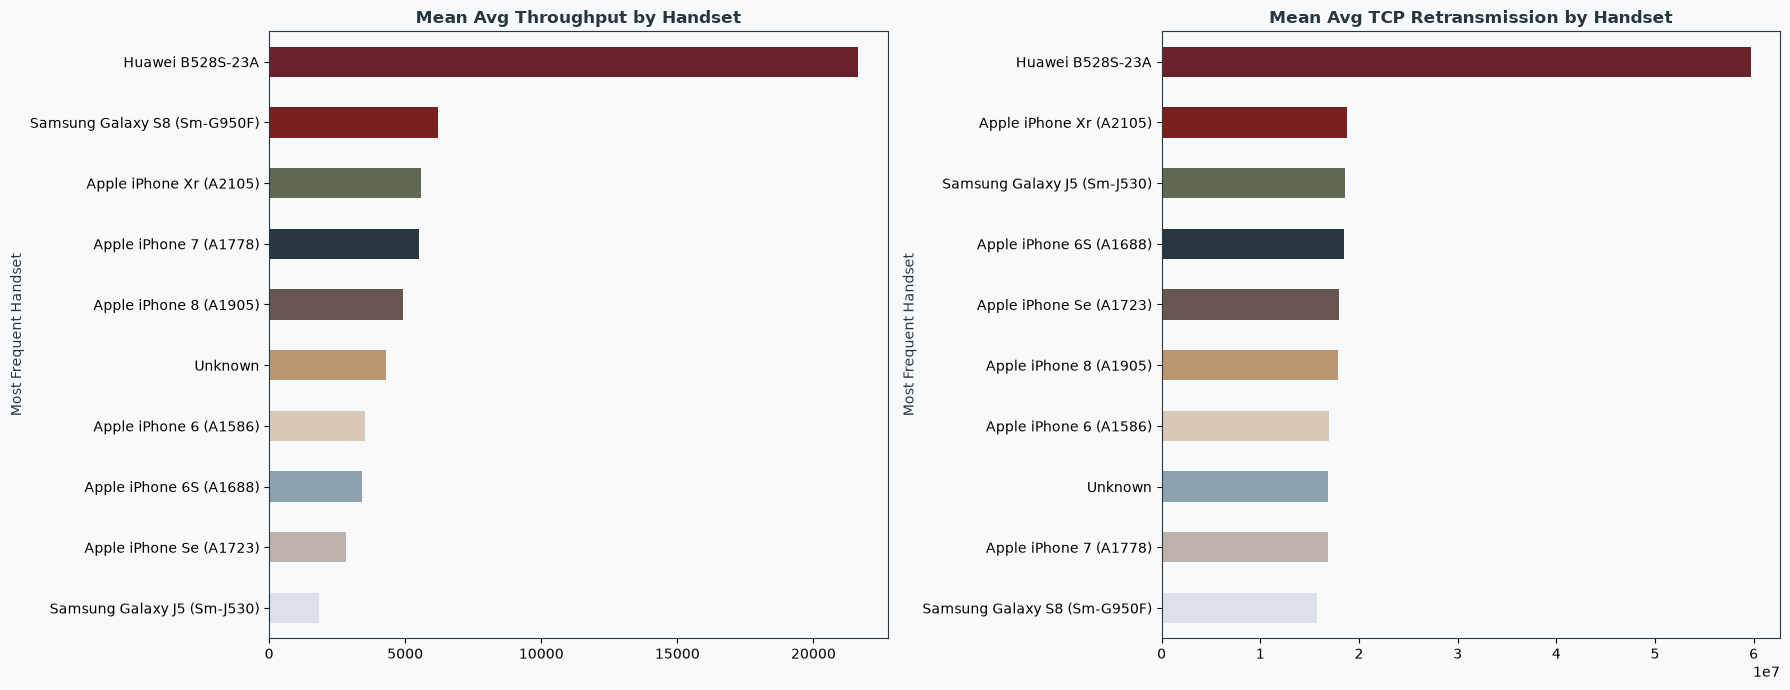

In [78]:
top10_handsets_exp = experience['Most Frequent Handset'].value_counts().head(10).index
exp_top10 = experience[experience['Most Frequent Handset'].isin(top10_handsets_exp)]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
throughput_by_handset = exp_top10.groupby('Most Frequent Handset')['Avg Throughput (kbps)'].mean().sort_values(ascending=False)
throughput_by_handset.plot(kind='barh', ax=axes[0], color=TELLCO_PALETTE_LIST[:10])
axes[0].set_title('Mean Avg Throughput by Handset', color=TELLCO_PALETTE['pine'], fontweight='bold')
axes[0].invert_yaxis()

tcp_by_handset = exp_top10.groupby('Most Frequent Handset')['Avg TCP Retransmission (Bytes)'].mean().sort_values(ascending=False)
tcp_by_handset.plot(kind='barh', ax=axes[1], color=TELLCO_PALETTE_LIST[:10])
axes[1].set_title('Mean Avg TCP Retransmission by Handset', color=TELLCO_PALETTE['pine'], fontweight='bold')
axes[1].invert_yaxis()
plt.tight_layout()
plt.savefig('figures/fig6e_handset_experience.png', dpi=100, facecolor='#F8F9FA')
plt.show()

**Interpretation.** By sessions, Apple leads with 39.93% (59,464), then Samsung 27.25% (40,579) and Huawei 23.07% (34,366), 90.25% together. These are shares of all sessions, including the 6.0% logged as Unknown. At customer level the ranking holds: Apple 39.86%, Samsung 28.81% and Huawei 20.30% of all customers (89.0% combined).

The most common handset, Huawei B528S-23A (19,727 sessions, 13.25%), is a fixed-wireless router, not a phone: it is the most frequent handset of 10,615 customers (9.9% of all customers), with 1.86 sessions per customer against 1.39 overall. It appears to be a separate home-broadband segment inside Huawei's count (an inference from the device model), and should not be read alongside the phone segments.

Within Apple, the top five by sessions are the iPhone 6S, 6, 7, SE and 8, but the Xr and X also appear in the overall top 10 (4,562 and 3,810 sessions). The extraction window is April 2019, so these were previous-generation devices at the time, not necessarily "old".

**Recommendation to marketing (hypothesis, no revenue data).** Test upgrade or trade-in offers on the large iPhone 6S/6/7/SE/8 base, since it is the largest phone cohort by sessions, and market the B528S-23A group separately as home-broadband customers. Whether such offers pay off cannot be judged here, because the dataset has no revenue, ARPU or churn data.

,Customers
Most Frequent Handset,
Huawei B528S-23A,10615
Apple iPhone 6S (A1688),6759
Apple iPhone 6 (A1586),6260
Apple iPhone 7 (A1778),4699
Apple iPhone Se (A1723),3754
Apple iPhone 8 (A1905),3543
Samsung Galaxy S8 (Sm-G950F),3245
Apple iPhone Xr (A2105),3072
Samsung Galaxy J5 (Sm-J530),2748


,% of all customers
Handset Manufacturer,
Apple,39.86
Samsung,28.81
Huawei,20.30


,"Sessions, Unknown excluded"
Handset Type,
Huawei B528S-23A,19727
Apple iPhone 6S (A1688),9413
Apple iPhone 6 (A1586),9012
Apple iPhone 7 (A1778),6304
Apple iPhone Se (A1723),5176
Apple iPhone 8 (A1905),4985
Apple iPhone Xr (A2105),4562
Samsung Galaxy S8 (Sm-G950F),4480
Apple iPhone X (A1901),3810


Huawei B528S-23A: 10,615 customers, 19,727 sessions (1.86 per customer; overall 1.39)


,Customers,Throughput Q1,Throughput median,Throughput Q3,Median throughput (untreated),Median TCP (observed only),TCP fully observed (%)
Most Frequent Handset,,,,,,,
Huawei B528S-23A,"10,615.0","12,135.2","19,570.9","29,209.4","19,570.9","4,971,047.0",84.0
Samsung Galaxy S8 (Sm-G950F),"3,245.0",50.0,68.0,"9,227.0",68.0,"419,543.0",20.4
Apple iPhone 7 (A1778),"4,699.0",44.5,58.5,"5,926.8",58.5,"586,144.0",15.9
Apple iPhone 6 (A1586),"6,260.0",44.2,58.0,"3,797.9",58.0,"523,751.0",12.9
Samsung Galaxy A5 Sm-A520F,"2,708.0",42.8,58.0,"3,450.6",58.0,"345,166.0",14.3
Apple iPhone 8 (A1905),"3,543.0",46.0,57.9,"4,195.3",57.9,"618,432.0",10.1
Apple iPhone Xr (A2105),"3,072.0",45.8,56.0,"5,952.9",56.0,"930,858.5",8.9
Apple iPhone Se (A1723),"3,754.0",43.0,54.0,"1,435.0",54.0,"488,303.0",9.9
Apple iPhone 6S (A1688),"6,759.0",43.5,53.5,"1,704.6",53.5,"506,555.0",9.4


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/seaborn/categorical.py:700: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


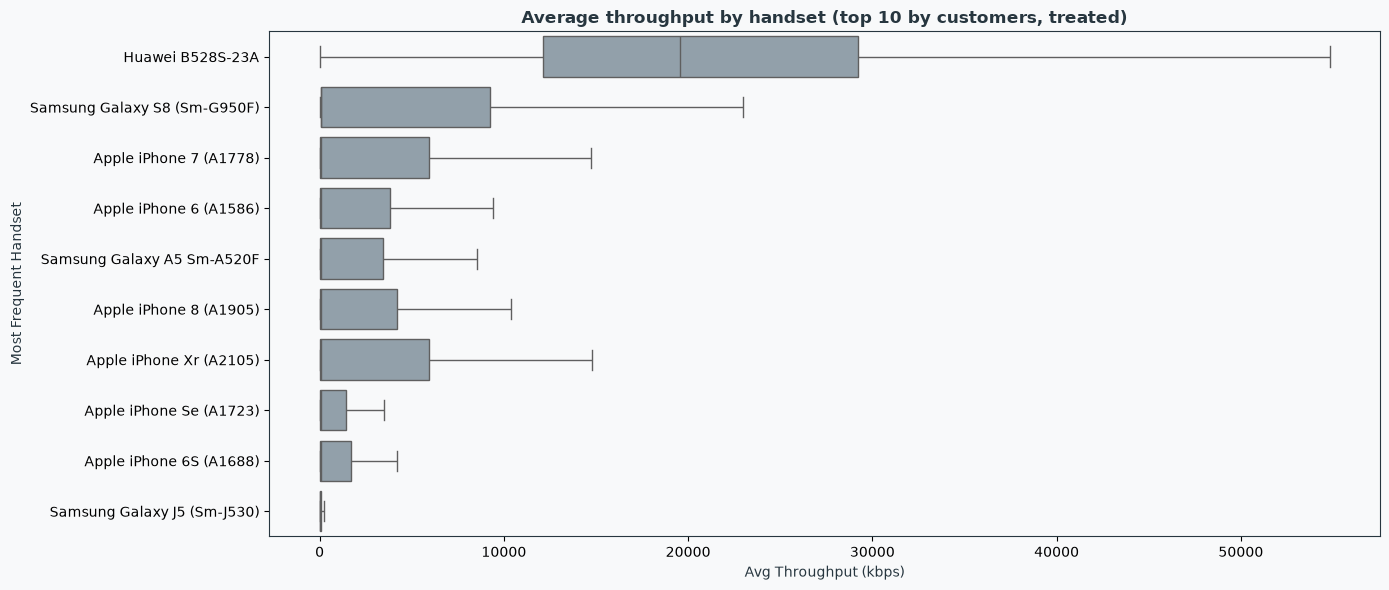

Kruskal-Wallis across 10 handsets: H=15,572.7, p=0.00e+00, eps2=0.328


In [79]:
def treat_iqr(df):
    out = df.copy()
    for col in exp_metrics:
        s = df[col]; q1, q3 = s.quantile([0.25, 0.75]); iqr = q3 - q1
        flag = (s < q1 - 1.5 * iqr) | (s > q3 + 1.5 * iqr)
        out[col] = s.where(~flag, s[~flag].mean())
    return out
experience_t = treat_iqr(experience_raw)

cust_mfg = df_clean.groupby('MSISDN/Number')['Handset Manufacturer'].agg(most_frequent)
cust_h = experience_raw['Most Frequent Handset']
top10_cust = cust_h[cust_h != 'Unknown'].value_counts().head(10)
display(top10_cust.to_frame('Customers'))
display((cust_mfg[cust_mfg != 'Unknown'].value_counts().head(3) / len(cust_mfg) * 100).round(2).to_frame('% of all customers'))
display(df_clean.loc[df_clean['Handset Type'] != 'Unknown', 'Handset Type'].value_counts().head(10).to_frame('Sessions, Unknown excluded'))

rt = 'Huawei B528S-23A'
n_c, n_s = int((cust_h == rt).sum()), int((df_clean['Handset Type'] == rt).sum())
print(f'{rt}: {n_c:,} customers, {n_s:,} sessions ({n_s / n_c:.2f} per customer; overall {len(df_clean) / len(experience_raw):.2f})')

# Task 3.3: throughput distribution and TCP per handset (top 10 by customers)
d = experience[experience['Most Frequent Handset'].isin(top10_cust.index)]
d_raw = experience_raw.loc[d.index]
gh = d.groupby('Most Frequent Handset')
tab = pd.DataFrame({
    'Customers': gh.size(),
    'Throughput Q1': gh['Avg Throughput (kbps)'].quantile(0.25),
    'Throughput median': gh['Avg Throughput (kbps)'].median(),
    'Throughput Q3': gh['Avg Throughput (kbps)'].quantile(0.75),
    'Median throughput (untreated)': d_raw.groupby('Most Frequent Handset')['Avg Throughput (kbps)'].median(),
    'Median TCP (observed only)': d[d['TCP imputed share'] == 0].groupby('Most Frequent Handset')['Avg TCP Retransmission (Bytes)'].median(),
    'TCP fully observed (%)': gh['TCP imputed share'].apply(lambda s: (s == 0).mean() * 100),
}).sort_values('Throughput median', ascending=False)
display(tab.style.format('{:,.1f}'))

fig, ax = plt.subplots(figsize=(14, 6))
sns.boxplot(data=d, y='Most Frequent Handset', x='Avg Throughput (kbps)', order=tab.index.tolist(),
            showfliers=False, ax=ax, color=TELLCO_PALETTE['mist'])
ax.set_title('Average throughput by handset (top 10 by customers, treated)', color=TELLCO_PALETTE['pine'], fontweight='bold')
plt.tight_layout(); plt.savefig('figures/fig6f_throughput_by_handset.png', dpi=100, facecolor='#F8F9FA'); plt.show()

groups = [x['Avg Throughput (kbps)'].values for _, x in d.groupby('Most Frequent Handset')]
h, p = stats.kruskal(*groups)
print(f'Kruskal-Wallis across {len(groups)} handsets: H={h:,.1f}, p={p:.2e}, eps2={(h - len(groups) + 1) / (len(d) - len(groups)):.3f}')

**Throughput and retransmission by handset.** The Huawei B528S-23A router has by far the highest median throughput (19,571 kbps; IQR 12,135–29,209) and the Samsung Galaxy J5 the lowest (39 kbps; IQR 10.5–93.5). The other eight handsets have medians between 53.5 and 68.0 kbps, but upper quartiles from about 1,400 to 9,200 kbps (Galaxy S8: Q1 50, median 68, Q3 9,227), so each phone group is mostly slow connections plus a fast minority, and the median hides that. Throughput differs strongly across the ten handsets (Kruskal–Wallis H = 15,572.7, p < 0.001, ε² = 0.328, a large effect), but most of that comes from the router. Treated and untreated medians are identical for every handset, because mean replacement leaves the median customer's value unchanged.

Per-handset retransmission is shown only for customers whose TCP was fully observed, which is 84.0% of router customers but only 7.5–20.4% of phone customers, so the medians rest on very different subsamples; the router's (4.97M bytes) is 5–14 times the phones' (0.35–0.93M). Differences between handsets are descriptive; they mix device capability, plan and location, which this dataset cannot separate.

### 6.4 Experience Clustering — Normalisation, K-Means (k=3), and Validation

The same n_init=20 setting as Section 5 is used, so each fit keeps the best of 20 initialisations.

In [80]:
def detect_iqr(s):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    return (s < q1 - 1.5 * iqr) | (s > q3 + 1.5 * iqr)

experience = experience_raw.copy()          # always rebuilt from the frozen table
exp_flags = pd.DataFrame(index=experience.index)
log = []
for col in exp_metrics:
    flag = detect_iqr(experience_raw[col])
    q1, q3 = experience_raw[col].quantile([0.25, 0.75])
    repl = experience_raw.loc[~flag, col].mean()
    experience[col] = experience_raw[col].where(~flag, repl)
    exp_flags[col] = flag
    log.append({'Variable': col, 'Upper fence': q3 + 1.5 * (q3 - q1), 'Outliers': int(flag.sum()),
                '%': flag.mean() * 100, 'Replacement (mean)': repl})
display(pd.DataFrame(log).set_index('Variable').style.format(
    {'Upper fence': '{:,.1f}', 'Outliers': '{:,.0f}', '%': '{:.2f}', 'Replacement (mean)': '{:,.2f}'}))
print(f'Customers with ≥1 metric replaced: {exp_flags.any(axis=1).sum():,} ({exp_flags.any(axis=1).mean():.1%})')

,Upper fence,Outliers,%,Replacement (mean)
Variable,,,,
Avg TCP Retransmission (Bytes),"46,132,936.6","1,861",1.74,"14,823,293.96"
Avg RTT (ms),127.0,"6,515",6.10,39.15
Avg Throughput (kbps),"23,588.8","9,520",8.91,"3,703.34"


Customers with ≥1 metric replaced: 16,425 (15.4%)


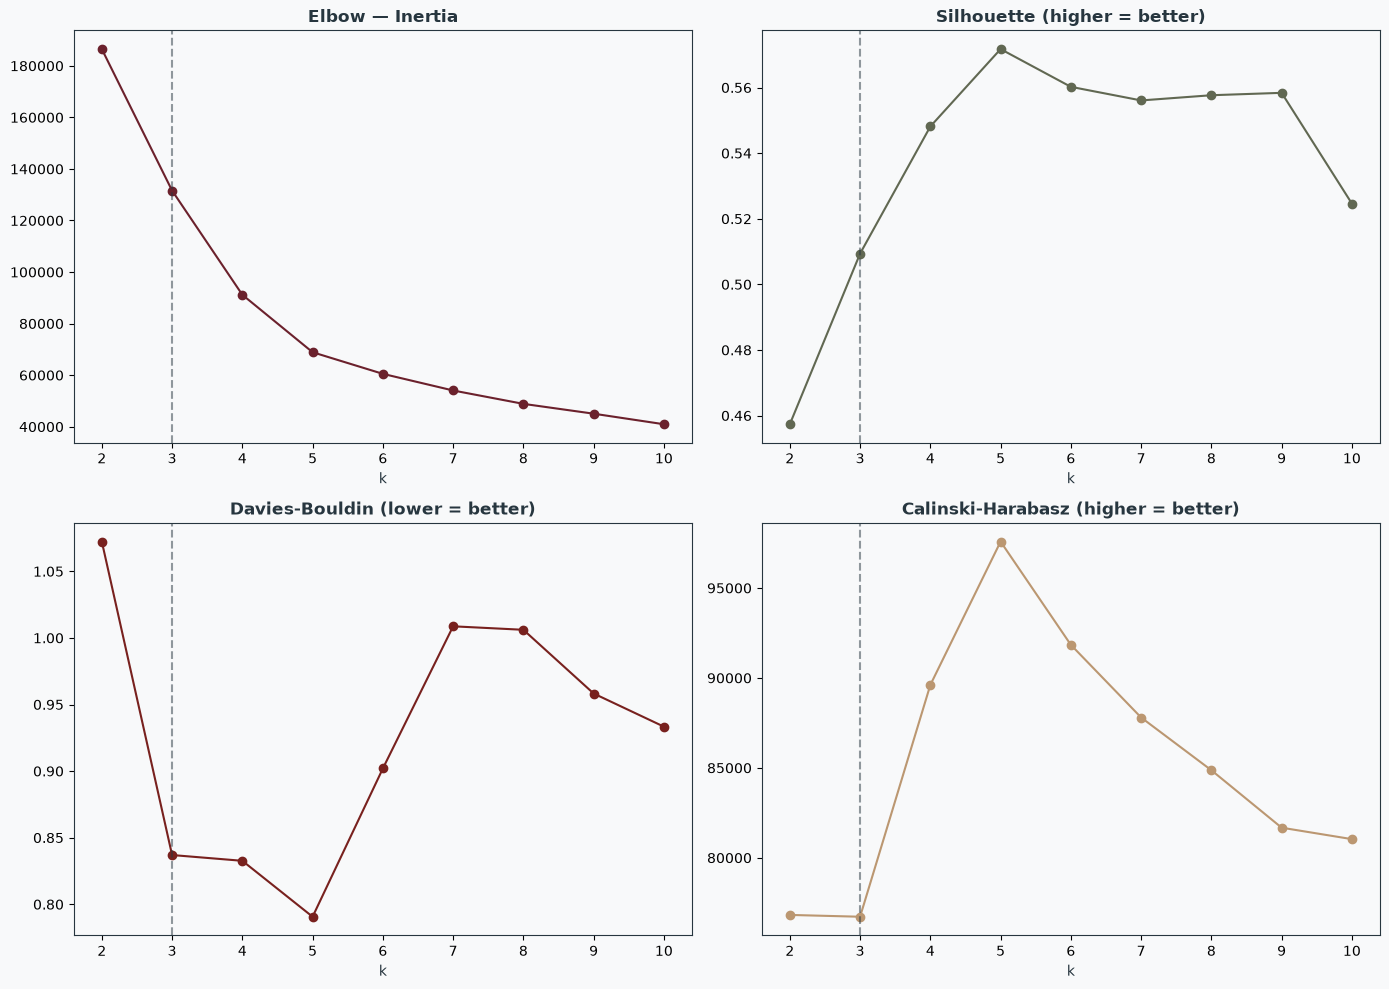

,Inertia,Silhouette,Davies-Bouldin,Calinski-Harabasz
k,,,,
2,"186,490.3798",0.4574,1.0723,"76,822.8967"
3,"131,594.6066",0.5094,0.8370,"76,722.0191"
4,"91,175.3595",0.5481,0.8327,"89,611.7331"
5,"68,894.4722",0.5717,0.7907,"97,582.5163"
6,"60,511.3547",0.5602,0.9020,"91,840.8632"
7,"54,055.4629",0.5561,1.0087,"87,800.7089"
8,"48,866.9357",0.5577,1.0061,"84,868.2622"
9,"45,054.1172",0.5584,0.9583,"81,673.9317"
10,"40,961.9581",0.5246,0.9334,"81,037.1054"


In [81]:
scaler_exp = StandardScaler()
X_experience = scaler_exp.fit_transform(experience[exp_metrics])

validation_results = []
for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10, max_iter=200)
    labels_k = km.fit_predict(X_experience)
    sil = silhouette_score(X_experience, labels_k, sample_size=5000, random_state=RANDOM_STATE)
    validation_results.append({
        'k': k, 'Inertia': km.inertia_, 'Silhouette': sil,
        'Davies-Bouldin': davies_bouldin_score(X_experience, labels_k),
        'Calinski-Harabasz': calinski_harabasz_score(X_experience, labels_k),
    })
exp_validation_df = pd.DataFrame(validation_results).set_index('k')

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes[0, 0].plot(exp_validation_df.index, exp_validation_df['Inertia'], 'o-', color=TELLCO_PALETTE['berry'])
axes[0, 0].set_title('Elbow — Inertia', color=TELLCO_PALETTE['pine'], fontweight='bold')
axes[0, 1].plot(exp_validation_df.index, exp_validation_df['Silhouette'], 'o-', color=TELLCO_PALETTE['holly'])
axes[0, 1].set_title('Silhouette (higher = better)', color=TELLCO_PALETTE['pine'], fontweight='bold')
axes[1, 0].plot(exp_validation_df.index, exp_validation_df['Davies-Bouldin'], 'o-', color=TELLCO_PALETTE['mulled_wine'])
axes[1, 0].set_title('Davies-Bouldin (lower = better)', color=TELLCO_PALETTE['pine'], fontweight='bold')
axes[1, 1].plot(exp_validation_df.index, exp_validation_df['Calinski-Harabasz'], 'o-', color=TELLCO_PALETTE['cinnamon'])
axes[1, 1].set_title('Calinski-Harabasz (higher = better)', color=TELLCO_PALETTE['pine'], fontweight='bold')
for ax in axes.flat:
    ax.set_xlabel('k')
    ax.axvline(3, color=TELLCO_PALETTE['pine'], linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('figures/fig6c_cluster_validation.png', dpi=100, facecolor='#F8F9FA')
plt.show()

display(exp_validation_df.style.format('{:,.4f}'))

**Validation.** Against the brief's k=3, k=2 is weaker on silhouette (0.457 vs. 0.509) and Davies–Bouldin (1.072 vs. 0.837); Calinski–Harabasz is a near-tie (76,823 vs. 76,722, favouring k=2 by 0.1%). All three metrics are best at k=5 (silhouette 0.572, Davies–Bouldin 0.791, Calinski–Harabasz 97,583), and the inertia drop shrinks from 24.4% at k=5 to 12.2% at k=6, so k=5 is the data-driven optimum. k=3 is used as the brief requires.

**Caution on the high silhouettes.** Scores of 0.46–0.57 are higher than Section 5's, but they cannot be compared across different feature sets. One reason is that more than half of customers share an identical TCP value (the imputed mean), a dense point mass that makes clusters look tight and well separated. The sensitivity in 6.6 tests how much the segmentation depends on TCP.

In [82]:
kmeans_experience = KMeans(n_clusters=3, random_state=RANDOM_STATE, n_init=20, max_iter=300)
raw_lab = pd.Series(kmeans_experience.fit_predict(X_experience), index=experience.index)

# Number clusters best -> worst. Badness = z(TCP) + z(RTT) - z(throughput), equal weights.
c = pd.DataFrame(kmeans_experience.cluster_centers_, columns=exp_metrics)
badness = c['Avg TCP Retransmission (Bytes)'] + c['Avg RTT (ms)'] - c['Avg Throughput (kbps)']
order = badness.sort_values().index.to_list()
remap = {old: new for new, old in enumerate(order)}
experience['Experience Cluster'] = raw_lab.map(remap)
experience_centers = kmeans_experience.cluster_centers_[order]    # row i = NEW cluster i
WORST_EXPERIENCE = 2

cent = experience.groupby('Experience Cluster')[exp_metrics].mean()
assert cent['Avg Throughput (kbps)'].idxmax() == 0
poor_lat = cent.loc[[1, 2], 'Avg RTT (ms)'].idxmax()
poor_tp = 3 - poor_lat
assert cent['Avg Throughput (kbps)'].idxmin() == poor_tp
cluster_names = {0: 'Good experience', poor_lat: 'High / unmeasured latency', poor_tp: 'Low throughput'}

exp_cluster_sizes = experience['Experience Cluster'].value_counts().sort_index()
display(pd.DataFrame({'Name': pd.Series(cluster_names), 'Customers': exp_cluster_sizes,
                      'Share (%)': (exp_cluster_sizes / len(experience) * 100).round(2)}))

seeds_to_test = [0, 1, 42, 100, 2024]
label_sets = [KMeans(n_clusters=3, random_state=s, n_init=20, max_iter=300).fit_predict(X_experience)
              for s in seeds_to_test]
ari_matrix = np.array([[adjusted_rand_score(a, b) for b in label_sets] for a in label_sets])
off_diag = ari_matrix[np.triu_indices(len(seeds_to_test), k=1)]
print(f'Seed stability — mean ARI: {off_diag.mean():.4f}, min: {off_diag.min():.4f}')
print('Composite badness by new cluster id (0 = best, 2 = worst):', badness.loc[order].round(3).tolist())

# elbow
inn = exp_validation_df['Inertia']
print((1 - inn / inn.shift(1)).mul(100).round(1).to_dict())
kk = exp_validation_df.index.values.astype(float)
x_n = (kk - kk.min()) / (kk.max() - kk.min()); y_n = (inn.values - inn.min()) / (inn.max() - inn.min())
print('Elbow k =', int(kk[(np.abs(x_n + y_n - 1) / np.sqrt(2)).argmax()]))

,Name,Customers,Share (%)
0,Good experience,36929,34.56
1,Low throughput,43146,40.38
2,High / unmeasured latency,26781,25.06


Seed stability — mean ARI: 0.9993, min: 0.9988
Composite badness by new cluster id (0 = best, 2 = worst): [-2.106, 0.453, 2.171]
{2: nan, 3: 29.4, 4: 30.7, 5: 24.4, 6: 12.2, 7: 10.7, 8: 9.6, 9: 7.8, 10: 9.1}
Elbow k = 5


Cluster sizes are 36,929 (34.56%), 43,146 (40.38%) and 26,781 (25.06%) — a balanced three-way split — (clusters 0, 1 and 2: Good experience). Seed stability is near-perfect (mean ARI 0.9993, minimum 0.9988). Clusters are numbered best to worst by a composite of the three standardised centroid coordinates (TCP + RTT − throughput, equal weights), so cluster 2 is the "worst experience" cluster used for the experience score in Section 7.

### 6.5 Cluster Profiling

In [83]:
exp_profile = experience.groupby('Experience Cluster')[exp_metrics].agg(['min', 'max', 'mean', 'count'])
display(exp_profile.style.format('{:,.2f}'))

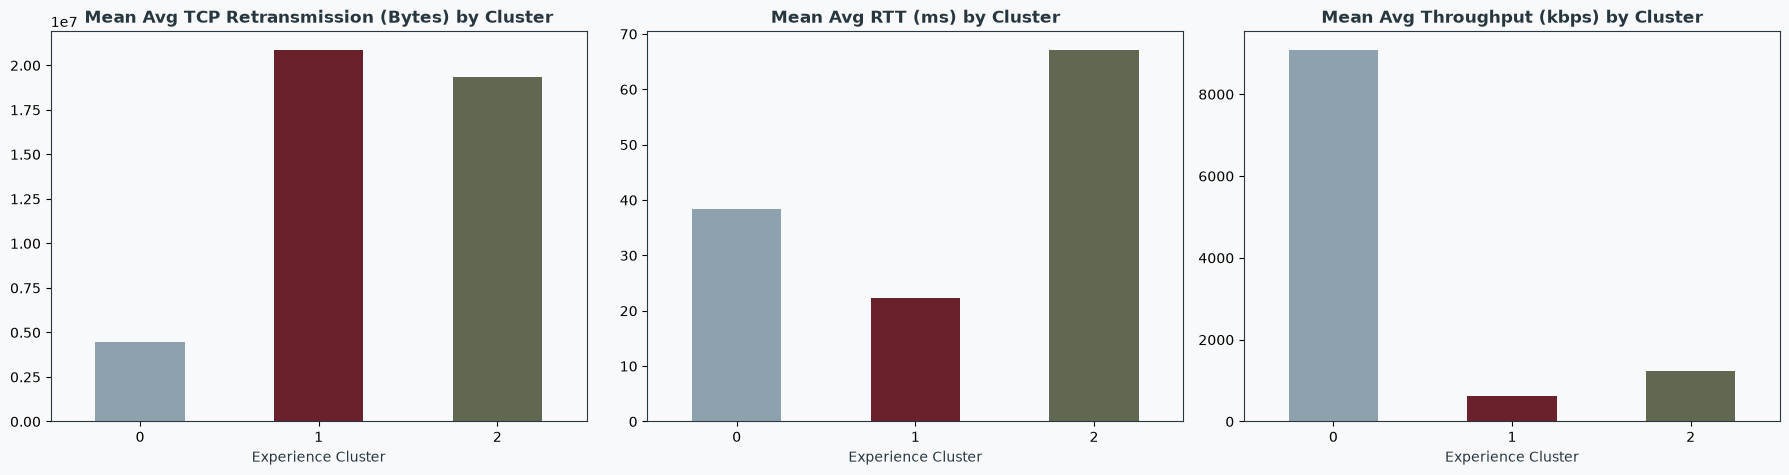

In [84]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, metric in enumerate(exp_metrics):
    means = experience.groupby('Experience Cluster')[metric].mean()
    means.plot(kind='bar', ax=axes[i],
               color=[TELLCO_PALETTE['mist'], TELLCO_PALETTE['berry'], TELLCO_PALETTE['holly']])
    axes[i].set_title(f'Mean {metric} by Cluster', color=TELLCO_PALETTE['pine'], fontweight='bold')
    axes[i].tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.savefig('figures/fig6d_experience_cluster_means.png', dpi=100, facecolor='#F8F9FA')
plt.show()

In [85]:
g = experience.groupby('Experience Cluster')
display(pd.DataFrame({
    'Customers': g.size(),
    'TCP fully imputed (%)':  g['TCP imputed share'].apply(lambda s: (s == 1).mean() * 100),
    'TCP fully observed (%)': g['TCP imputed share'].apply(lambda s: (s == 0).mean() * 100),
    'RTT fully imputed (%)':  g['RTT imputed share'].apply(lambda s: (s == 1).mean() * 100),
}).style.format('{:,.1f}'))

obs = experience[experience['TCP imputed share'] == 0]
print('Median TCP among fully observed customers, by cluster:')
print(obs.groupby('Experience Cluster')['Avg TCP Retransmission (Bytes)'].median().round(0))

for m in exp_metrics:
    display(pd.crosstab(exp_flags[m].rename(f'{m}: replaced'), experience['Experience Cluster']).style.format('{:,}'))

,Customers,TCP fully imputed (%),TCP fully observed (%),RTT fully imputed (%)
Experience Cluster,,,,
0,"36,929.0",19.1,59.9,0.3
1,"43,146.0",91.2,3.0,0.0
2,"26,781.0",79.1,14.8,68.9


Median TCP among fully observed customers, by cluster:
Experience Cluster
0      781217.0
1    16200137.0
2    12996593.0
Name: Avg TCP Retransmission (Bytes), dtype: float64


Experience Cluster,0,1,2
Avg TCP Retransmission (Bytes): replaced,,,
False,"36,361","42,685","25,949"
True,568,461,832


Experience Cluster,0,1,2
Avg RTT (ms): replaced,,,
False,"32,025","41,535","26,781"
True,"4,904","1,611",0


Experience Cluster,0,1,2
Avg Throughput (kbps): replaced,,,
False,"30,905","41,634","24,797"
True,"6,024","1,512","1,984"


**Imputation shapes two of the three profiles.** Cluster 2's mean RTT (67.2 ms) sits close to Section 2's imputed RTT value (62.9 ms): 68.9% of its customers have a fully imputed RTT, which is about 99% of all customers with a fully imputed RTT, so Cluster 2 is largely a group whose latency was not measured. TCP is fully imputed for 91.2% of Cluster 1 and 79.1% of Cluster 2 but only 19.1% of Cluster 0 (59.9% fully observed), so Cluster 0's low TCP partly reflects observed versus imputed values. Among fully observed customers, median TCP is 0.78M bytes in Cluster 0, 16.2M in Cluster 1 and 13.0M in Cluster 2 (subsets of about 1,300 and 4,000 customers for the last two).

In [86]:
is_router = experience_raw['Most Frequent Handset'].eq('Huawei B528S-23A')
display(pd.crosstab(experience['Experience Cluster'], is_router.rename('Router customer'), normalize='index').mul(100).round(1))
print('Share of router customers in Cluster 0:', round(float((experience.loc[is_router, 'Experience Cluster'] == 0).mean() * 100), 1), '%')
print('Cluster 0 without router customers:', int(((experience['Experience Cluster'] == 0) & ~is_router).sum()))

Router customer,False,True
Experience Cluster,,
0,80.5,19.5
1,97.9,2.1
2,90.7,9.3


Share of router customers in Cluster 0: 68.0 %
Cluster 0 without router customers: 29714


**Interpretation, labelled from the centroids rather than assumed.**

| Cluster | Label | n | % | Avg TCP Retrans. | Avg RTT | Avg Throughput | Routers |
|---|---|---|---|---|---|---|---|
| 0 | Good experience | 36,929 | 34.56% | 4.47M bytes | 38.4 ms | 9,090 kbps | 19.5% |
| 1 | Low throughput | 43,146 | 40.38% | 20.9M bytes | 22.4 ms | 628 kbps | 2.1% |
| 2 | High or unmeasured latency | 26,781 | 25.06% | 19.3M bytes | 67.2 ms | 1,229 kbps | 9.3% |

*Routers* is the share of customers whose most frequent handset is the Huawei B528S-23A (9.9% of all customers).

The three groups are of comparable size and none is a majority.

**Cluster 0 — Good experience (34.56%).** The highest throughput by a wide margin (mean 9,090 kbps, about 7–14× the other two clusters), mid-range RTT (38.4 ms) and the lowest TCP retransmission. Its low TCP partly reflects observed rather than imputed values: 59.9% of its customers have fully observed TCP, against 3.0% of Cluster 1 and 14.8% of Cluster 2. Routers are over-represented here: 7,215 customers, 19.5% of the cluster against 9.9% of all customers, and 68.0% of all router customers sit in this cluster (23.5% are in Cluster 2). The other 80.5% of the cluster are not routers, so "good experience" is not simply "has a router", but the router segment (median throughput 19,571 kbps, Section 6.3) plausibly accounts for part of the cluster's high mean throughput. The split by device within the cluster was not tested.

**Cluster 1 — Low throughput (43,146 customers, 40.38%, the plurality).** The lowest mean throughput (628 kbps) with the lowest RTT (22.4 ms), lower even than Cluster 0's. This is a distinct pattern in the recorded metrics, not simply "the bad cluster". The available data cannot identify what produces it (device or plan limits, cell load and application behaviour are all possible), so it is a pattern to investigate, not a diagnosis. Its mean TCP (20.9M bytes) is close to the imputed value (21.65M), since TCP is fully imputed for 91.2% of its customers, so TCP should not be read as a feature of this group.

**Cluster 2 — High or unmeasured latency (26,781 customers, 25.06%).** The highest RTT of the three (67.2 ms, about 3× Cluster 1's), with throughput and TCP retransmission between the other two clusters. Its mean RTT is close to the Section 2 imputed value (62.9 ms), and 68.9% of its customers have a fully imputed RTT, so it is largely a group whose latency was not measured. The data show a different pattern from Cluster 1 but cannot identify its cause.

**No extreme-TCP cluster appears under the brief-mandated treatment.** The 1,861 customers above the TCP fence (1.74%, values up to 4.3 billion bytes) are replaced by 14.8M before clustering, so such a group cannot form. Section 6.6 checks whether one appears on the untreated table, and whether the TCP dimension is separating low from high retransmission or observed from imputed values.

**What the clusters do and do not show.** They identify different patterns in the recorded metrics. They cannot establish root causes, and no capacity or routing action should be inferred from them without cell-level, plan and device data. The one robust distinction is a throughput contrast between a good-throughput group and a low-throughput group (see 6.6).

**No extreme-TCP cluster appears under the brief-mandated treatment.** The 1,861 customers above the TCP fence (1.74%, values up to 4.3 billion bytes) are replaced by 14.8M before clustering, so such a group cannot form. Section 6.6 checks whether one appears on the untreated table, and whether the TCP dimension is separating low from high retransmission or observed from imputed values.

**Business reading.** The clusters show different network-experience patterns: a low-throughput, low-latency group (Cluster 1, 40.38%, the largest), a group with high or unmeasured latency (Cluster 2, 25.06%) and a good-experience group (Cluster 0, 34.56%). There is no dominant poor-experience majority. The available data (customer-level aggregates of three network metrics, with TCP and much of RTT imputed) cannot identify the underlying causes, so no network remedy should be inferred from the clusters without cell-level, plan and device data.

### 6.6 Sensitivity — TCP, treatment and the extreme tail

**(A) No TCP (RTT and throughput only).** ARI against the primary clustering is 0.530. The two poor groups survive: 98.9% of primary Cluster 1 (42,684 of 43,146) and 96.9% of Cluster 2 (25,960 of 26,781) each map to a single no-TCP cluster. The Good-experience group splits across all three: 16,905 customers (45.8%) go to a high-throughput cluster (mean 15,207 kbps), 15,811 (42.8%) to the cluster holding most poor-throughput customers and 4,213 (11.4%) to the latency cluster. RTT is still a feature here, so this variant cannot test the imputed-RTT effect.

**(C) Capped instead of mean-replaced.** ARI is 0.432. The capped solution has a high-throughput group (30,827 customers, 17,596 kbps mean, 93.2% from primary Cluster 0), a low-throughput group (64,946) and a small very-high-latency group (11,083 customers, mean RTT 333 ms) with no counterpart in the primary clustering. Only 3,164 of the 26,781 primary Poor-latency customers (11.8%) land in it; 84.2% go to the low-throughput group. Under the primary clustering, the 9,520 customers replaced on throughput (above 23,589 kbps) sit 63.3% in Cluster 0, 15.9% in Cluster 1 and 20.8% in Cluster 2, so 3,496 of them (36.7%) are placed in a poorer group despite throughput above 23 Mbps. Capped clusters are profiled in untreated units.

**(D) Untreated.** An extreme-TCP cluster does appear: 167 customers (0.16%) with mean TCP retransmission of 2.19 billion bytes, against about 17–20M elsewhere. The other two are a high-throughput group (18,377 customers, 27,533 kbps) and the bulk (88,312; 2,160 kbps). Mean replacement removes this tail by construction.

**(B) Fully observed TCP only (n = 27,389).** Three groups again: high throughput with low TCP (7,552 customers; 16,998 kbps; 3.3M bytes), low throughput with low RTT (13,541; 4,062 kbps; 36.6 ms; 2.3M bytes) and high TCP with high RTT (6,296; 12.5M bytes; 78.8 ms). The throughput split and the low-throughput/low-latency profile reappear. Cluster 1's 20.9M TCP in the primary run is not reproduced here (2.3M), consistent with that figure being an imputation effect.

**Conclusion.** The k=3 solution is highly reproducible across random seeds (mean ARI 0.9993) but materially sensitive to preprocessing: ARI against the primary clustering falls to 0.530 without TCP and 0.432 with capping instead of mean replacement. Seed stability shows only that the algorithm finds the same partition on the same data, not that the partition reflects a robust network structure. What survives every variant is a throughput-driven split into a high-throughput and a low-throughput group. The third group is fragile: in the primary run Cluster 2 is mostly imputed-RTT customers, under capping 84% of it merges into the low-throughput group, and the TCP contribution to the profiles largely reflects imputed versus observed values. The untreated data add a very small extreme-TCP group (167 customers, mean 2.19 billion bytes) that mean replacement removes by construction. The three groups should therefore be read as good-throughput, low-throughput and latency-unmeasured, not as three equally robust network problems.

In [87]:
def fit_k3(df, cols):
    X = StandardScaler().fit_transform(df[cols])
    return pd.Series(KMeans(n_clusters=3, random_state=RANDOM_STATE, n_init=20, max_iter=300).fit_predict(X), index=df.index)

capped = experience_raw.copy()
for m in exp_metrics:
    q1, q3 = experience_raw[m].quantile([0.25, 0.75]); i = q3 - q1
    capped[m] = experience_raw[m].clip(q1 - 1.5 * i, q3 + 1.5 * i)

primary = experience['Experience Cluster']
variants = {'A: RTT + throughput only (no TCP)': fit_k3(experience, ['Avg RTT (ms)', 'Avg Throughput (kbps)']),
            'C: capped instead of mean-replaced': fit_k3(capped, exp_metrics)}
for name, lab in variants.items():
    print(f'\n{name}: ARI vs primary = {adjusted_rand_score(primary, lab):.3f}')
    display(pd.crosstab(primary.rename('primary'), lab.rename(name[:1])).style.format('{:,}'))
    display(experience_raw.groupby(lab)[exp_metrics].mean().assign(Customers=lab.value_counts().sort_index()).style.format('{:,.1f}'))

lab_d = fit_k3(experience_raw, exp_metrics)       # D: untreated, diagnostic
print('\nD: untreated sizes (standardised):', lab_d.value_counts().sort_index().to_dict())
display(experience_raw.groupby(lab_d)[exp_metrics].mean().style.format('{:,.1f}'))

sub = experience[experience['TCP imputed share'] == 0]     # B: fully observed TCP only
lab_b = fit_k3(sub, exp_metrics)
print(f'\nB: fully observed TCP only (n={len(sub):,})')
display(sub.groupby(lab_b)[exp_metrics].mean().assign(Customers=lab_b.value_counts().sort_index()).style.format('{:,.1f}'))


A: RTT + throughput only (no TCP): ARI vs primary = 0.530


A,0,1,2
primary,,,
0,"15,811","16,905","4,213"
1,"42,684",439,23
2,322,499,"25,960"


,Avg TCP Retransmission (Bytes),Avg RTT (ms),Avg Throughput (kbps),Customers
0,"19,287,134.9",70.5,"4,781.0","58,817.0"
1,"17,153,944.1",57.4,"15,207.4","17,843.0"
2,"26,246,529.3",66.6,"4,973.6","30,196.0"



C: capped instead of mean-replaced: ARI vs primary = 0.432


C,0,1,2
primary,,,
0,"1,877","28,716","6,336"
1,"40,519","1,044","1,583"
2,"22,550","1,067","3,164"


,Avg TCP Retransmission (Bytes),Avg RTT (ms),Avg Throughput (kbps),Customers
0,"29,325,838.0",36.6,"1,317.2","64,946.0"
1,"4,907,215.7",36.4,"17,596.0","30,827.0"
2,"15,984,735.9",332.6,"6,744.5","11,083.0"



D: untreated sizes (standardised): {0: 18377, 1: 88312, 2: 167}


,Avg TCP Retransmission (Bytes),Avg RTT (ms),Avg Throughput (kbps)
0,"20,234,759.1",51.3,"27,532.6"
1,"16,929,308.7",70.5,"2,160.3"
2,"2,192,300,348.2",71.9,"35,860.8"



B: fully observed TCP only (n=27,389)


,Avg TCP Retransmission (Bytes),Avg RTT (ms),Avg Throughput (kbps),Customers
0,"3,303,229.7",42.9,"16,998.1","7,552.0"
1,"2,277,955.3",36.6,"4,062.3","13,541.0"
2,"12,543,345.3",78.8,"7,485.8","6,296.0"


In [88]:
sub_r = experience[experience['RTT imputed share'] == 0]
lab_r = fit_k3(sub_r, exp_metrics)
print(f'RTT fully observed only (n={len(sub_r):,})')
display(sub_r.groupby(lab_r)[exp_metrics].mean().assign(Customers=lab_r.value_counts().sort_index()).style.format('{:,.1f}'))
print('ARI vs primary on the same customers:', round(adjusted_rand_score(experience.loc[sub_r.index, 'Experience Cluster'], lab_r), 3))

RTT fully observed only (n=82,958)


,Avg TCP Retransmission (Bytes),Avg RTT (ms),Avg Throughput (kbps),Customers
0,"8,212,700.3",83.6,"8,135.2","8,905.0"
1,"21,089,262.4",23.2,655.1,"43,466.0"
2,"3,993,223.3",32.7,"8,509.1","30,587.0"


ARI vs primary on the same customers: 0.847


**Section 6 summary.**

| Check | Result | Interpretation |
|---|---|---|
| Data quality caveat | 52.4% of customers share one TCP retransmission value; 17.3% share one RTT value; the largest single-direction TCP value is within 0.013% of the 32-bit counter limit | The shared values are Section 2's imputed means; the extreme TCP end is suggestive of a possible counter ceiling (inferred from the observed maximum alone); throughput is the most trustworthy of the three metrics |
| Zero-value customers | 108 at 0 kbps throughput, 2 at 0 ms RTT | 0 kbps means no payload recorded; 0 ms RTT is physically impossible, so a logging artifact |
| Top handset | Huawei B528S-23A: 19,727 sessions (13.25%), 10,615 customers | A router, not a phone: a fixed-wireless segment (inferred from the model) |
| Top 3 manufacturers | Apple 39.93%, Samsung 27.25%, Huawei 23.07% of sessions (90.25%); same ranking by customers (89.0%) | Minimal device diversity beyond these three |
| Handset throughput | Router median 19,571 kbps vs. phones 39–68 kbps; TCP fully observed for 84.0% of router customers but 7.5–20.4% of phone customers | Per-handset TCP is not comparable across handsets |
| Marketing recommendation | Older-iPhone trade-in offers; separate messaging for the router segment | Largest addressable cohorts identified directly from the data; no revenue data |
| Cluster sizes (k=3) | 36,929 / 43,146 / 26,781 (34.56% / 40.38% / 25.06%) | Three comparable groups, none a majority; seed-stability ARI 0.9993 (minimum 0.9988) across five seeds, so the result is reproducible for a given preprocessing but depends on it (see 6.6) |
| Statistically optimal k | k=5 on silhouette, Davies–Bouldin and Calinski–Harabasz; chord elbow also k=5. k=3 beats k=2 on silhouette and DB; k=2 marginally on CH | k=3 used as the brief requires |
| Cluster profile | 0 Good experience (19.5% routers); 1 Low throughput (plurality); 2 High / unmeasured latency (largely imputed) | Cluster 0 holds 68.0% of all router customers; Cluster 2's RTT is largely imputed; TCP in the profiles partly reflects imputed vs. observed values; no root cause can be inferred |
| Sensitivity (6.6) | ARI 0.530 without TCP, 0.432 capped; untreated data shows a 167-customer extreme-TCP cluster (mean 2.19B bytes) | Throughput split is robust; Cluster 2 (latency) is fragile |

This closes **Section 6 — User Experience**.

## 🎯 Section 7 — Satisfaction & Predictive Modelling

This section derives an engagement score and an experience score for each customer as Euclidean distances (in standardised space) to reference cluster centroids from Sections 5 and 6, averages them into a satisfaction score, checks the scores for internal consistency, tests sensitivity to the weighting and to the definition of the experience score, clusters customers on the two scores, fits regression models to the score, explains the selected model with SHAP, and closes with a traffic-concentration view (Lorenz/Gini) and a traffic-versus-score priority matrix.

**What the score is.** There is no observed satisfaction in this dataset (no survey, churn, revenue or complaint data). The "satisfaction score" required by the brief is a behavioural proxy built from engagement and network measurements, and is referred to below as the proxy score where the distinction matters. Both scores use the brief-mandated treated tables.

### 7.1 Engagement Score

The engagement score is each customer's Euclidean distance, in standardised space, to the **least-engaged** cluster centroid from the first (k=3) clustering in Section 5, as the brief specifies. Clusters are numbered by engagement (0 = lowest composite), and the sums of the three standardised centroid coordinates are −1.489, 0.006 and 3.525 for clusters 0, 1 and 2. Cluster 0 is therefore the reference: it is negative on all three metrics at once. A higher score means further from the least-engaged profile.

In [89]:
X_eng_scaled = StandardScaler().fit_transform(user_overview[engagement_metrics])
assert np.allclose(X_eng_scaled, X_engagement), 'engagement standardisation differs from 5.3'

sums = engagement_centers.sum(axis=1)                      # new ids: 0 = lowest ... 2 = highest
assert int(np.argmin(sums)) == LEAST_ENGAGED
print(f'Centroid coordinate sums (ids 0/1/2): {sums.round(3)}; reference cluster: {LEAST_ENGAGED}')

user_overview['Engagement Score'] = np.linalg.norm(X_eng_scaled - engagement_centers[LEAST_ENGAGED], axis=1)
print(f"Engagement Score — mean: {user_overview['Engagement Score'].mean():.3f}, "
      f"median: {user_overview['Engagement Score'].median():.3f}, max: {user_overview['Engagement Score'].max():.3f}")

Centroid coordinate sums (ids 0/1/2): [-1.489  0.006  3.525]; reference cluster: 0
Engagement Score — mean: 1.585, median: 1.188, max: 6.201


### 7.2 Experience Score

The experience score is each customer's distance to the **worst-experience** centroid from Section 6. Clusters are numbered best to worst by a directional composite (TCP + RTT − throughput, standardised): −2.106, 0.453 and 2.171 for clusters 0, 1 and 2, so Cluster 2 (25.06% of customers) is the reference. **Cluster 2 is mostly customers whose RTT was imputed** (68.9% have a fully imputed RTT, and it holds about 99% of all such customers; Section 6.5), so the experience score is largely a distance from a group whose latency was not measured. The definition is the brief's; Section 7.6b tests how much the results depend on it. A higher score means further from that reference, which in practice means lower RTT, lower TCP retransmission and higher throughput.

In [90]:
assert len(X_experience) == len(experience)
bad = experience_centers[:, 0] + experience_centers[:, 1] - experience_centers[:, 2]   # TCP + RTT - throughput
assert int(np.argmax(bad)) == WORST_EXPERIENCE
exp_sizes = experience['Experience Cluster'].value_counts(normalize=True).sort_index()
print(f'Cluster sizes (%): {(exp_sizes * 100).round(2).to_dict()}')
print(f'Directional badness per cluster: {bad.round(3)}; worst-experience reference: {WORST_EXPERIENCE}')

experience['Experience Score'] = np.linalg.norm(X_experience - experience_centers[WORST_EXPERIENCE], axis=1)
print(f"Experience Score — mean: {experience['Experience Score'].mean():.3f}, "
      f"median: {experience['Experience Score'].median():.3f}, max: {experience['Experience Score'].max():.3f}")

Cluster sizes (%): {0: 34.56, 1: 40.38, 2: 25.06}
Directional badness per cluster: [-2.106  0.453  2.171]; worst-experience reference: 2
Experience Score — mean: 1.999, median: 2.167, max: 4.987


### 7.3 Score Consistency Check

Each score should track the raw metrics it was built from. This is checked directly — and
the result for the experience score needs to be reported honestly rather than smoothed over.

In [91]:
combined = user_overview.join(
    experience[['Avg TCP Retransmission (Bytes)', 'Avg RTT (ms)', 'Avg Throughput (kbps)',
                'Most Frequent Handset', 'Experience Cluster', 'Experience Score']],
    how='inner'
)

print('Engagement Score validation:')
for m in engagement_metrics:
    r, p = stats.pearsonr(combined['Engagement Score'], combined[m])
    rho, ps = stats.spearmanr(combined['Engagement Score'], combined[m])
    print(f'  {m}: Pearson r={r:.3f}, Spearman ρ={rho:.3f}')

print('\nExperience Score validation:')
for m in ['Avg RTT (ms)', 'Avg TCP Retransmission (Bytes)', 'Avg Throughput (kbps)']:
    r, p = stats.pearsonr(combined['Experience Score'], combined[m])
    rho, ps = stats.spearmanr(combined['Experience Score'], combined[m])
    print(f'  {m}: Pearson r={r:.3f}, Spearman ρ={rho:.3f}')

Engagement Score validation:
  xDR Sessions: Pearson r=0.837, Spearman ρ=0.710
  Total Duration (s): Pearson r=0.678, Spearman ρ=0.615
  Total Data Volume (Bytes): Pearson r=0.568, Spearman ρ=0.404

Experience Score validation:
  Avg RTT (ms): Pearson r=-0.413, Spearman ρ=-0.462
  Avg TCP Retransmission (Bytes): Pearson r=-0.565, Spearman ρ=-0.590
  Avg Throughput (kbps): Pearson r=0.660, Spearman ρ=0.590


In [92]:
assert len(combined) == len(user_overview) and combined['Experience Score'].notna().all()

e = experience.loc[combined.index]
for col, lab in [('RTT imputed share', 'RTT'), ('TCP imputed share', 'TCP')]:
    grp = np.select([e[col] == 1, e[col] == 0], [f'{lab} fully imputed', f'{lab} fully observed'], f'{lab} mixed')
    display(combined.groupby(grp)['Experience Score'].agg(['mean', 'median', 'count']).style.format({'mean': '{:.3f}', 'median': '{:.3f}', 'count': '{:,.0f}'}))
    print(f'Spearman, experience score vs {lab} imputed share: {stats.spearmanr(combined["Experience Score"], e[col])[0]:.3f}')

,mean,median,count
RTT fully imputed,0.388,0.378,"18,544"
RTT fully observed,2.378,2.343,"82,958"
RTT mixed,1.715,1.535,"5,354"


Spearman, experience score vs RTT imputed share: -0.660


,mean,median,count
TCP fully imputed,1.648,1.948,"67,565"
TCP fully observed,2.715,2.678,"27,389"
TCP mixed,2.347,2.295,"11,902"


Spearman, experience score vs TCP imputed share: -0.483


**Interpretation.** Both scores move in the expected direction with the metrics they are built from, and Pearson and Spearman agree in sign throughout.

- **Engagement score:** Pearson 0.568–0.837 and Spearman 0.404–0.710 against sessions, duration and volume (strongest for sessions, weakest for volume).
- **Experience score:** RTT (r = −0.413, ρ = −0.462), TCP retransmission (r = −0.565, ρ = −0.590) and throughput (r = 0.660, ρ = 0.590). A higher score means lower RTT, lower retransmission and higher throughput.

These are consistency checks, not validation. Each score is a function of the variables it is correlated with, so agreement shows the construction behaves as designed, not that either score measures engagement or experience as customers feel them.

**Imputation.** The experience score tracks whether RTT was measured more closely than it tracks any of the three raw metrics. Customers with a fully imputed RTT (18,544) have a mean experience score of 0.388 (median 0.378), against 2.378 (median 2.343) for the 82,958 with fully observed RTT and 1.715 for the 5,354 mixed. The Spearman correlation between the experience score and the RTT imputed share is −0.660, larger in magnitude than its Spearman correlation with RTT itself (−0.462), TCP (−0.590) or throughput (0.590). TCP shows the same direction, more weakly: fully imputed 1.648 (median 1.948; 67,565 customers), fully observed 2.715 (27,389), mixed 2.347 (11,902); Spearman with the TCP imputed share −0.483. Low scores for fully imputed customers are expected, because they are the reference group, but it means the experience score largely tracks whether RTT was measured.

### 7.4 Satisfaction Score

Engagement and experience scores are on different scales by construction (they come from
different centroid spaces), so both are min-max scaled to [0, 1] before averaging — otherwise
whichever score happens to have the larger numeric range would dominate. Higher scores mean further from the least-engaged and worst-experience reference profiles. This is a proxy, not measured satisfaction; "satisfied customers" below means highest proxy score.

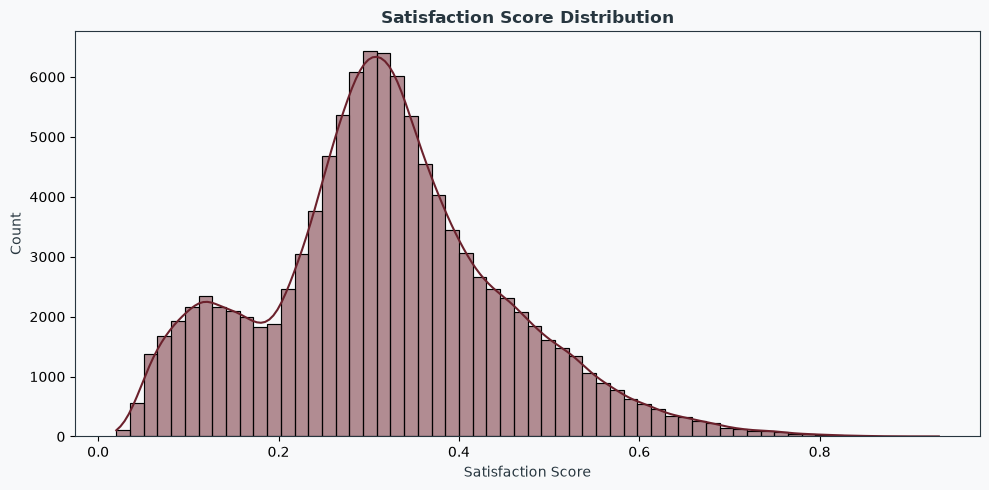

Satisfaction Score percentiles:
count    106856.000000
mean          0.316514
std           0.133297
min           0.020138
10%           0.130108
25%           0.237779
50%           0.312312
75%           0.392743
90%           0.491374
95%           0.549800
99%           0.667247
max           0.932155
Name: Satisfaction Score, dtype: float64

Top 10 satisfied customers:


MSISDN/Number
3.365945e+10    0.932155
3.364709e+10    0.923035
3.376977e+10    0.915783
3.376374e+10    0.907559
3.369954e+10    0.893631
3.365827e+10    0.880828
3.366140e+10    0.878507
3.365932e+10    0.877164
3.362306e+10    0.868990
3.376092e+10    0.867017
Name: Satisfaction Score, dtype: float64


Bottom 10:


MSISDN/Number
3.366901e+10    0.020138
3.376105e+10    0.022128
3.366751e+10    0.023481
3.366259e+10    0.023930
3.364012e+10    0.025051
3.366528e+10    0.025252
3.365133e+10    0.025409
3.369852e+10    0.025572
3.369531e+10    0.026123
3.365928e+10    0.026175
Name: Satisfaction Score, dtype: float64

In [93]:
scaler_minmax = MinMaxScaler()
combined[['Engagement Score Scaled', 'Experience Score Scaled']] = scaler_minmax.fit_transform(
    combined[['Engagement Score', 'Experience Score']]
)
combined['Satisfaction Score'] = combined[['Engagement Score Scaled', 'Experience Score Scaled']].mean(axis=1)

fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(combined['Satisfaction Score'], bins=60, color=TELLCO_PALETTE['berry'], kde=True, ax=ax)
ax.set_title('Satisfaction Score Distribution', color=TELLCO_PALETTE['pine'], fontweight='bold')
plt.tight_layout()
plt.savefig('figures/fig7a_satisfaction_distribution.png', dpi=100, facecolor='#F8F9FA')
plt.show()

print('Satisfaction Score percentiles:')
print(combined['Satisfaction Score'].describe(percentiles=[.1, .25, .5, .75, .9, .95, .99]))

print('\nTop 10 satisfied customers:')
display(combined['Satisfaction Score'].sort_values(ascending=False).head(10))
print('\nBottom 10:')
display(combined['Satisfaction Score'].sort_values(ascending=True).head(10))

### 7.5 Satisfaction by Segment

In [94]:
print('Satisfaction by Engagement Cluster:')
display(combined.groupby('Engagement Cluster')['Satisfaction Score'].agg(['mean', 'median', 'count']))

print('\nSatisfaction by Experience Cluster:')
display(combined.groupby('Experience Cluster')['Satisfaction Score'].agg(['mean', 'median', 'count']))

top10_handsets_list = combined['Most Frequent Handset'].value_counts().head(10).index
print('\nSatisfaction by Handset (top 10 handsets):')
display(
    combined[combined['Most Frequent Handset'].isin(top10_handsets_list)]
    .groupby('Most Frequent Handset')['Satisfaction Score']
    .agg(['mean', 'median', 'count']).sort_values('mean', ascending=False)
)

Satisfaction by Engagement Cluster:


,mean,median,count
Engagement Cluster,,,
0,0.273073,0.285040,57834
1,0.278314,0.293605,24654
2,0.458264,0.454067,24368



Satisfaction by Experience Cluster:


,mean,median,count
Experience Cluster,,,
0,0.394931,0.370817,36929
1,0.327197,0.309097,43146
2,0.191174,0.151904,26781



Satisfaction by Handset (top 10 handsets):


,mean,median,count
Most Frequent Handset,,,
Huawei B528S-23A,0.361145,0.344355,10615
Apple iPhone Xr (A2105),0.360279,0.333649,3072
Apple iPhone 8 (A1905),0.351789,0.326263,3543
Apple iPhone 6 (A1586),0.347533,0.328957,6260
Apple iPhone 6S (A1688),0.347528,0.328269,6759
Apple iPhone Se (A1723),0.346758,0.330026,3754
Apple iPhone 7 (A1778),0.341361,0.320968,4699
Unknown,0.269264,0.271995,6669
Samsung Galaxy J5 (Sm-J530),0.262735,0.266413,2748


**Interpretation.** Mean proxy score is 0.273, 0.278 and 0.458 for Engagement Clusters 0 (low), 1 (long-hold, light traffic) and 2 (high). Clusters 0 and 1 are almost identical, consistent with Section 5.6 (they differ in session duration, not in traffic), and Cluster 2 stands apart. By Experience Cluster the score falls from Good experience (0.395) to Low throughput (0.327) to High / unmeasured latency (0.191).

These gradients are built in, not findings: each cluster set is made from the same variables as one of the two scores, and the High / unmeasured latency cluster is the reference point of the experience score, so it must score lowest. They show the proxy behaves as designed.

Across the ten most frequent handsets, mean scores range from 0.254 to 0.361. The router (0.361) and the iPhones (0.341–0.360) are highest; Unknown (0.269) and the two Samsung models (Galaxy J5 0.263, S8 0.254) are lowest. The router's score likely reflects its high throughput (Section 6.3). Handset differences are descriptive; device, plan and location are confounded.

### 7.6 Sensitivity Analysis

The 50/50 weighting is compared against 60/40 (engagement-heavy) and 40/60
(experience-heavy) to check how much the weighting choice actually matters.

In [95]:
weightings = {'50/50': (0.5, 0.5), '60/40 (Engagement-heavy)': (0.6, 0.4), '40/60 (Experience-heavy)': (0.4, 0.6)}
score_variants = pd.DataFrame({
    name: we * combined['Engagement Score Scaled'] + wx * combined['Experience Score Scaled']
    for name, (we, wx) in weightings.items()
})

print('Spearman rank correlation between weighting variants:')
display(score_variants.corr(method='spearman').style.format('{:.4f}'))

top10_sets = {name: set(score_variants[name].sort_values(ascending=False).head(10).index)
              for name in weightings}
print('\nTop-10 overlap:')
print(f"  50/50 vs 60/40: {len(top10_sets['50/50'] & top10_sets['60/40 (Engagement-heavy)'])}/10")
print(f"  50/50 vs 40/60: {len(top10_sets['50/50'] & top10_sets['40/60 (Experience-heavy)'])}/10")
print(f"  60/40 vs 40/60: {len(top10_sets['60/40 (Engagement-heavy)'] & top10_sets['40/60 (Experience-heavy)'])}/10")

rank_5050 = score_variants['50/50'].rank(ascending=False)
rank_4060 = score_variants['40/60 (Experience-heavy)'].rank(ascending=False)
print(f"\nMean |rank change|, 50/50 vs 40/60: {(rank_5050 - rank_4060).abs().mean():.0f}")
print(f"Max |rank change|, 50/50 vs 40/60: {(rank_5050 - rank_4060).abs().max():.0f}")

Spearman rank correlation between weighting variants:


,50/50,60/40 (Engagement-heavy),40/60 (Experience-heavy)
50/50,1.0000,0.9776,0.9791
60/40 (Engagement-heavy),0.9776,1.0000,0.9184
40/60 (Experience-heavy),0.9791,0.9184,1.0000



Top-10 overlap:
  50/50 vs 60/40: 8/10
  50/50 vs 40/60: 9/10
  60/40 vs 40/60: 7/10

Mean |rank change|, 50/50 vs 40/60: 4249
Max |rank change|, 50/50 vs 40/60: 33784


**Interpretation.** Rank correlation between the weightings is high: 0.978 (50/50 vs. 60/40), 0.979 (50/50 vs. 40/60) and 0.918 between the two extremes. For the population as a whole the weighting matters little; the average customer moves about 4,250 rank positions between 50/50 and 40/60 (about 4% of the 106,856 customers). Individual customers are much less stable: the largest shift is 33,784 positions, and only 8 of the top 10 names are shared between 50/50 and 60/40, 9 of 10 between 50/50 and 40/60, and 7 of 10 between the two extremes. The aggregate ranking is robust to weighting; any top-N list is not, so lists should state which weighting produced them.

### 7.6b Sensitivity — definition of the experience score

Because the reference cluster is largely an imputed-RTT group, two alternative experience scores that avoid the clustering step are compared: a directional composite (−(TCP + RTT − throughput), standardised) and throughput alone, the most reliable of the three metrics.

**Results.** Both alternatives keep the broad ranking but not the individual one. The directional composite correlates 0.849 with the primary experience score and 0.908 with the proxy score; it retains 689 of the top 1,000 customers and 81.6% of the priority quadrant. Throughput alone correlates 0.590 and 0.764, and retains 743 of the top 1,000 and 71.4% of the quadrant. The proxy ranking is therefore moderately robust to the definition, and the quadrant less so: 18.4% of its members (about 3,800 customers) drop out under the composite and 28.6% (about 5,900) under throughput alone. All variants share the engagement score, so they test only the experience half. The primary definition is kept, as the brief specifies.

In [96]:
z = pd.DataFrame(X_experience, columns=exp_metrics, index=experience.index).loc[combined.index]
alts = {'Directional composite (no clusters)': -(z.iloc[:, 0] + z.iloc[:, 1] - z.iloc[:, 2]),
        'Throughput only': z.iloc[:, 2]}

med_vol = combined['Total Data Volume (Bytes)'].median()
base_low = combined['Satisfaction Score'] < combined['Satisfaction Score'].median()
base_q = (combined['Total Data Volume (Bytes)'] >= med_vol) & base_low
top1000 = set(combined['Satisfaction Score'].nlargest(1000).index)

rows = []
for name, s in alts.items():
    s_sc = (s - s.min()) / (s.max() - s.min())
    sat = 0.5 * combined['Engagement Score Scaled'] + 0.5 * s_sc
    q = (combined['Total Data Volume (Bytes)'] >= med_vol) & (sat < sat.median())
    rows.append({'Alternative experience score': name,
                 'Spearman (experience score)': stats.spearmanr(combined['Experience Score'], s)[0],
                 'Spearman (proxy score)': stats.spearmanr(combined['Satisfaction Score'], sat)[0],
                 'Top-1000 overlap': len(top1000 & set(sat.nlargest(1000).index)),
                 'Priority-quadrant overlap (%)': (q & base_q).sum() / base_q.sum() * 100})
display(pd.DataFrame(rows).set_index('Alternative experience score').style.format('{:,.3f}'))

,Spearman (experience score),Spearman (proxy score),Top-1000 overlap,Priority-quadrant overlap (%)
Alternative experience score,,,,
Directional composite (no clusters),0.849,0.908,689.000,81.570
Throughput only,0.590,0.764,743.000,71.447


### 7.7 Satisfaction Clustering (k=2)

Cluster sizes: {0: 43694, 1: 63162}
Silhouette: 0.4080  |  Davies-Bouldin: 1.1503
Seed stability — mean ARI: 0.9954, min: 0.9935


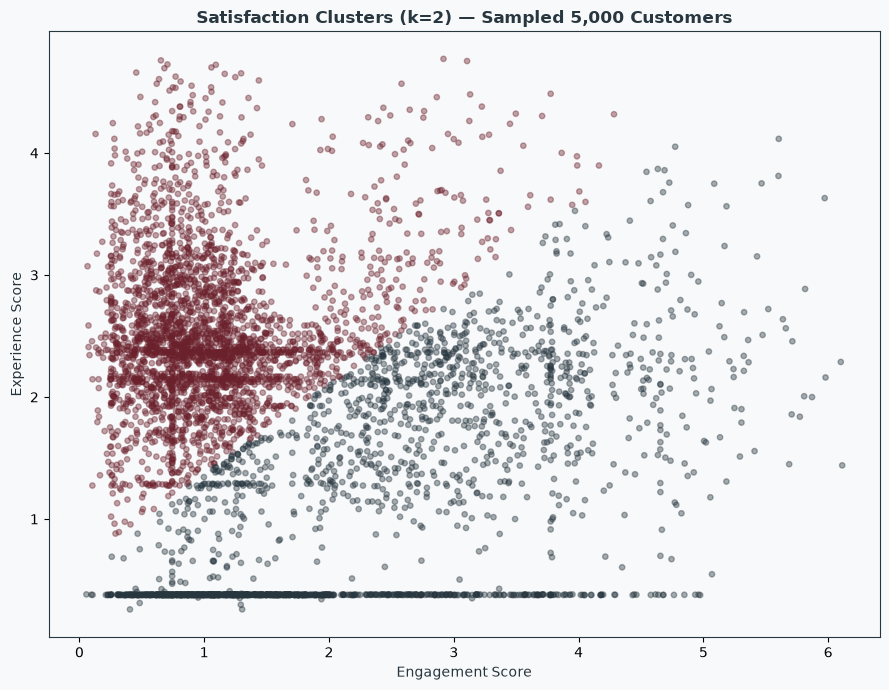

Engagement Score                  Experience Score                  Satisfaction Score            \
                                 mean    median  count             mean    median  count               mean    median   
Satisfaction Cluster                                                                                                    
0                            2.333613  2.269978  43694         1.206864  1.105328  43694           0.295343  0.280872   
1                            1.066896  0.945532  63162         2.547091  2.409309  63162           0.331161  0.317518   

                             
                      count  
Satisfaction Cluster         
0                     43694  
1                     63162

In [97]:
scaler_sat = StandardScaler()
X_satisfaction = scaler_sat.fit_transform(combined[['Engagement Score', 'Experience Score']])

kmeans_satisfaction = KMeans(n_clusters=2, random_state=RANDOM_STATE, n_init=20, max_iter=300)
combined['Satisfaction Cluster'] = kmeans_satisfaction.fit_predict(X_satisfaction)

cent = pd.DataFrame(kmeans_satisfaction.cluster_centers_, columns=['eng', 'exp'])
eng_led = int(cent['eng'].idxmax())                       # higher engagement score, lower experience score
combined['Satisfaction Cluster'] = combined['Satisfaction Cluster'].map({eng_led: 0, 1 - eng_led: 1})
sat_names = {0: 'Engaged, weaker experience', 1: 'Less engaged, better experience'}

sil_sat = silhouette_score(X_satisfaction, combined['Satisfaction Cluster'], sample_size=5000, random_state=RANDOM_STATE)
db_sat = davies_bouldin_score(X_satisfaction, combined['Satisfaction Cluster'])

seeds_sat = [0, 1, 42, 100, 2024]
label_sets_sat = [KMeans(n_clusters=2, random_state=s, n_init=20, max_iter=300).fit_predict(X_satisfaction)
                   for s in seeds_sat]
ari_sat = np.array([[adjusted_rand_score(a, b) for b in label_sets_sat] for a in label_sets_sat])
off_diag_sat = ari_sat[np.triu_indices(len(seeds_sat), k=1)]

print(f'Cluster sizes: {combined["Satisfaction Cluster"].value_counts().sort_index().to_dict()}')
print(f'Silhouette: {sil_sat:.4f}  |  Davies-Bouldin: {db_sat:.4f}')
print(f'Seed stability — mean ARI: {off_diag_sat.mean():.4f}, min: {off_diag_sat.min():.4f}')

fig, ax = plt.subplots(figsize=(9, 7))
sample_plot = combined.sample(n=5000, random_state=RANDOM_STATE)
scatter = ax.scatter(sample_plot['Engagement Score'], sample_plot['Experience Score'],
                      c=sample_plot['Satisfaction Cluster'], cmap=tellco_div, alpha=0.4, s=15)
ax.set_xlabel('Engagement Score')
ax.set_ylabel('Experience Score')
ax.set_title('Satisfaction Clusters (k=2) — Sampled 5,000 Customers', color=TELLCO_PALETTE['pine'], fontweight='bold')
plt.tight_layout()
plt.savefig('figures/fig7b_satisfaction_clusters.png', dpi=100, facecolor='#F8F9FA')
plt.show()

display(combined.groupby('Satisfaction Cluster')[['Engagement Score', 'Experience Score', 'Satisfaction Score']]
        .agg(['mean', 'median', 'count']))

**Interpretation.** k=2 splits customers into 43,694 (40.9%) and 63,162 (59.1%). This is not a high-vs-low satisfaction split. One group is more engaged with weaker experience (mean engagement score 2.33, experience score 1.21: "Engaged, weaker experience"); the other is less engaged with better experience (1.07 and 2.55: "Less engaged, better experience"). Their mean proxy scores are close (0.295 and 0.331) because the two scores offset each other. Separation is moderate (silhouette 0.408, Davies–Bouldin 1.150) and the solution is stable across seeds (mean ARI 0.9954, minimum 0.9935). The clusters describe an engagement–experience trade-off, not more or less satisfied customers. Because the experience score is partly an imputation effect (7.2), the "weaker experience" group is partly a group with unmeasured latency.

### 7.8 Regression Modelling

The target is the proxy `Satisfaction Score`; the features are the six customer-level metrics (treated) from which both scores were built: `xDR Sessions`, `Total Duration`, `Total Data Volume`, `Avg TCP Retransmission`, `Avg RTT` and `Avg Throughput`. The target is therefore a deterministic function of the features (distances to fixed centroids, min-max scaled), so this task is **recovering a known formula**, not predicting an independent outcome. A second contamination is also present: the scalers and cluster centroids that define the target were fitted on all customers, including those in the test split. Neither changes the framing, but both mean the scores below describe how well a model can approximate the construction, not predictive skill. Scaling for the models is fitted inside a pipeline on the training split only.

In [98]:
feature_cols = ['xDR Sessions', 'Total Duration (s)', 'Total Data Volume (Bytes)',
                 'Avg TCP Retransmission (Bytes)', 'Avg RTT (ms)', 'Avg Throughput (kbps)']

X = combined[feature_cols]
y = combined['Satisfaction Score']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

models = {
    'Dummy (Mean)': DummyRegressor(strategy='mean'),
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0, random_state=RANDOM_STATE),
    'Lasso': Lasso(alpha=0.001, random_state=RANDOM_STATE),
    'Random Forest': RandomForestRegressor(n_estimators=200, max_depth=10, random_state=RANDOM_STATE, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=200, max_depth=3, random_state=RANDOM_STATE),
}

kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
results = []
for name, model in models.items():
    pipe = Pipeline([('scaler', StandardScaler()), ('model', model)])

    t0 = time.time()
    pipe.fit(X_train, y_train)
    train_time = time.time() - t0

    t0 = time.time()
    y_pred_test = pipe.predict(X_test)
    pred_time = time.time() - t0

    y_pred_train = pipe.predict(X_train)
    r2_test = r2_score(y_test, y_pred_test)
    r2_train = r2_score(y_train, y_pred_train)
    n, p = X_test.shape
    adj_r2 = 1 - (1 - r2_test) * (n - 1) / (n - p - 1)

    cv_scores = cross_val_score(pipe, X_train, y_train, cv=kf, scoring='r2', n_jobs=-1)

    results.append({
        'Model': name,
        'MAE': mean_absolute_error(y_test, y_pred_test),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_test)),
        'R2 (test)': r2_test, 'Adj R2': adj_r2, 'R2 (train)': r2_train,
        'Train-Test Gap': r2_train - r2_test,
        'CV R2 mean': cv_scores.mean(), 'CV R2 std': cv_scores.std(),
        'Train Time (s)': train_time, 'Predict Time (s)': pred_time,
    })

results_df = pd.DataFrame(results).set_index('Model')
display(results_df.style.background_gradient(cmap=tellco_warn, subset=['R2 (test)']).format(
    {'MAE': '{:.5f}', 'RMSE': '{:.5f}', 'R2 (test)': '{:.4f}', 'Adj R2': '{:.4f}',
     'R2 (train)': '{:.4f}', 'Train-Test Gap': '{:.4f}', 'CV R2 mean': '{:.4f}', 'CV R2 std': '{:.4f}',
     'Train Time (s)': '{:.3f}', 'Predict Time (s)': '{:.3f}'}
))

,MAE,RMSE,R2 (test),Adj R2,R2 (train),Train-Test Gap,CV R2 mean,CV R2 std,Train Time (s),Predict Time (s)
Model,,,,,,,,,,
Dummy (Mean),0.10246,0.13367,-0.0002,-0.0005,0.0000,0.0002,-0.0000,0.0000,0.004,0.001
Linear Regression,0.04525,0.06053,0.7949,0.7949,0.7976,0.0027,0.7976,0.0055,0.037,0.003
Ridge,0.04525,0.06053,0.7949,0.7949,0.7976,0.0027,0.7976,0.0055,0.015,0.001
Lasso,0.04543,0.06055,0.7948,0.7947,0.7973,0.0026,0.7973,0.0053,0.010,0.001
Random Forest,0.01524,0.02103,0.9753,0.9752,0.9788,0.0035,0.9753,0.0011,4.244,0.051
Gradient Boosting,0.00818,0.01185,0.9921,0.9921,0.9924,0.0002,0.9923,0.0001,13.868,0.041


**Interpretation.** Gradient Boosting recovers the proxy best: test R² = 0.9921 (MAE 0.0082, RMSE 0.0119), a train–test gap of 0.0002, and 5-fold CV R² = 0.9923 ± 0.0001. Random Forest follows (0.9752) and the linear models plateau near 0.79 (Linear and Ridge 0.7949, Lasso 0.7948); the mean-prediction baseline scores −0.0002. The gap between linear and tree models reflects that the score is a nonlinear (distance-based) function of the metrics. Adjusted R² is meaningful for the linear models only.

**This is formula recovery, not predictive modelling.** A high R² shows a flexible model can approximate a geometric transformation of its own inputs. It says nothing about whether the proxy predicts anything real. A genuine predictive model would need an independent outcome (churn, revenue, survey response), which this dataset does not contain. Gradient Boosting is selected for the explainability step below, which describes how the model reconstructs the proxy, not what drives customer satisfaction.

### 7.9 SHAP Explainability

SHAP is run on the selected Gradient Boosting model, validated against permutation importance
and the model's native feature importance, and checked for additivity before any
interpretation is drawn from it.

In [99]:
final_model = GradientBoostingRegressor(n_estimators=200, max_depth=3, random_state=RANDOM_STATE)
final_model.fit(X_train, y_train)

explainer = shap.TreeExplainer(final_model)
X_test_sample = X_test.sample(n=2000, random_state=RANDOM_STATE)
shap_values = explainer.shap_values(X_test_sample)

# Additivity check
reconstructed = shap_values.sum(axis=1) + explainer.expected_value
actual = final_model.predict(X_test_sample)
print(f'Additivity check — max |reconstructed − actual|: {np.abs(reconstructed - actual).max():.10f}')

Additivity check — max |reconstructed − actual|: 0.0000000000


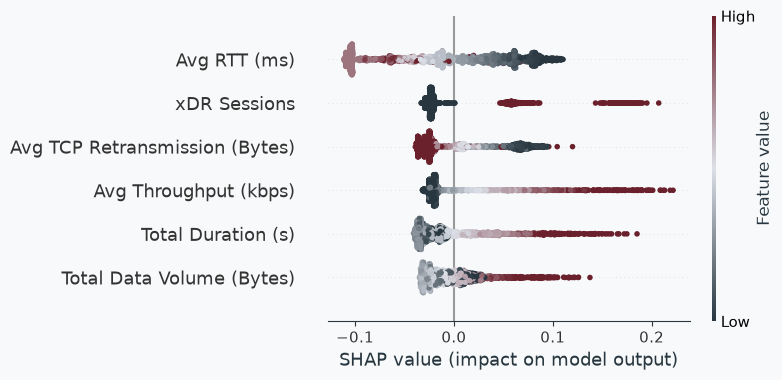

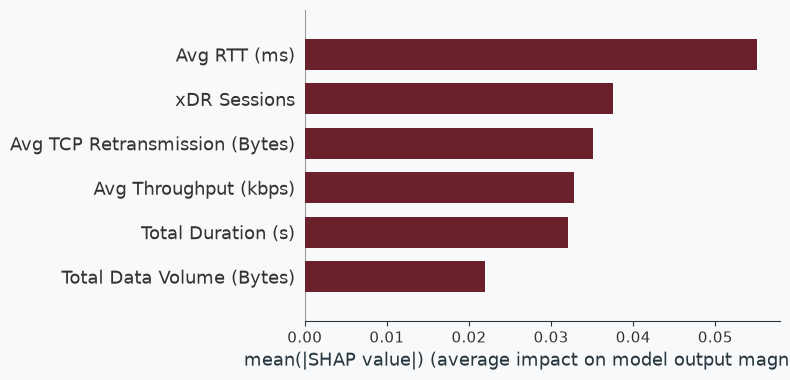

In [100]:
fig, ax = plt.subplots(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_sample, show=False,cmap=tellco_div)
plt.tight_layout()
plt.savefig('figures/fig7c_shap_beeswarm.png', dpi=100, facecolor='#F8F9FA', bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(14, 6))
shap.summary_plot(shap_values, X_test_sample, plot_type='bar', show=False, color=TELLCO_PALETTE['berry'])
plt.tight_layout()
plt.savefig('figures/fig7d_shap_bar.png', dpi=100, facecolor='#F8F9FA', bbox_inches='tight')
plt.show()

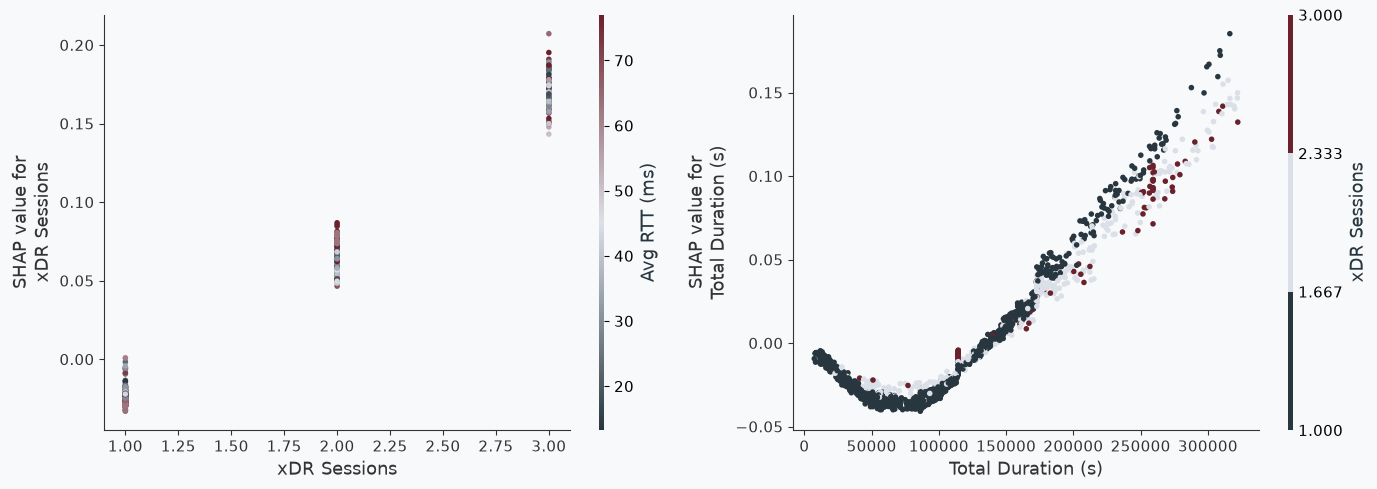

In [101]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
shap.dependence_plot('xDR Sessions', shap_values, X_test_sample, ax=axes[0], show=False,  cmap=tellco_div)
shap.dependence_plot('Total Duration (s)', shap_values, X_test_sample, ax=axes[1], show=False, cmap=tellco_div)
plt.tight_layout()
plt.savefig('figures/fig7e_shap_dependence.png', dpi=100, facecolor='#F8F9FA', bbox_inches='tight')
plt.show()

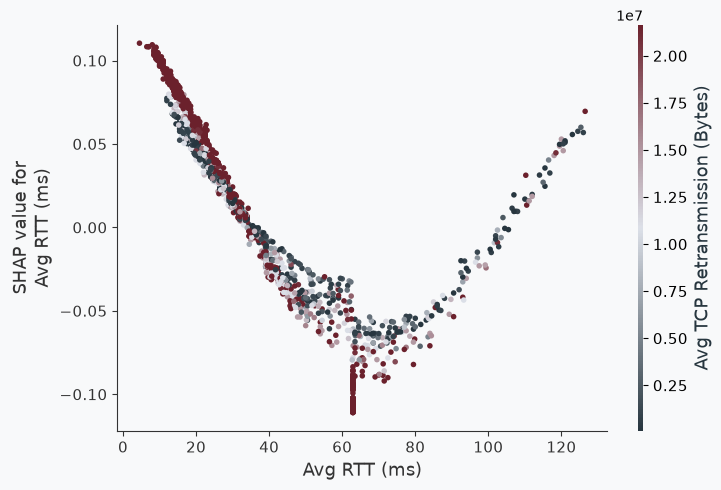

16.4% of the sample sit at the imputed RTT (62.93 ms); mean SHAP for RTT: imputed -0.1034 vs. others 0.0203


In [102]:
shap.dependence_plot('Avg RTT (ms)', shap_values, X_test_sample, show=False, cmap=tellco_div)
plt.tight_layout(); plt.savefig('figures/fig7e2_shap_rtt.png', dpi=100, facecolor='#F8F9FA', bbox_inches='tight'); plt.show()

rtt_mode = experience['Avg RTT (ms)'].mode().iloc[0]
is_imp = np.isclose(X_test_sample['Avg RTT (ms)'].values, rtt_mode)
j = feature_cols.index('Avg RTT (ms)')
print(f'{is_imp.mean():.1%} of the sample sit at the imputed RTT ({rtt_mode:.2f} ms); '
      f'mean SHAP for RTT: imputed {shap_values[is_imp, j].mean():.4f} vs. others {shap_values[~is_imp, j].mean():.4f}')


Highly Satisfied Customer — true=0.8359, predicted=0.8480


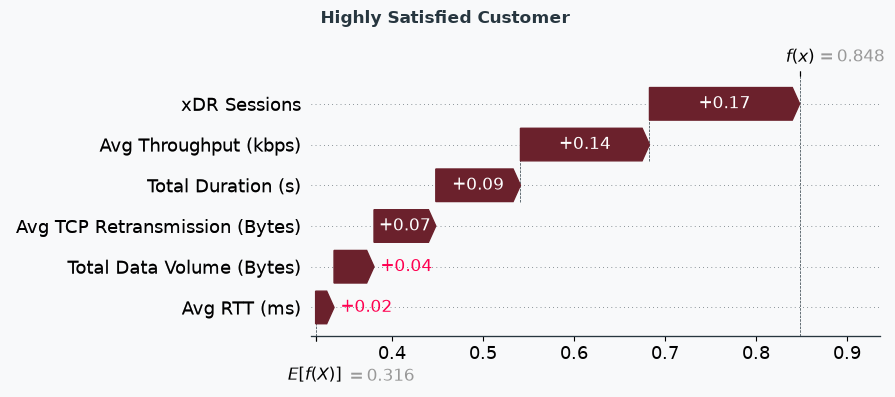


Low-Satisfaction Customer — true=0.0283, predicted=0.0543


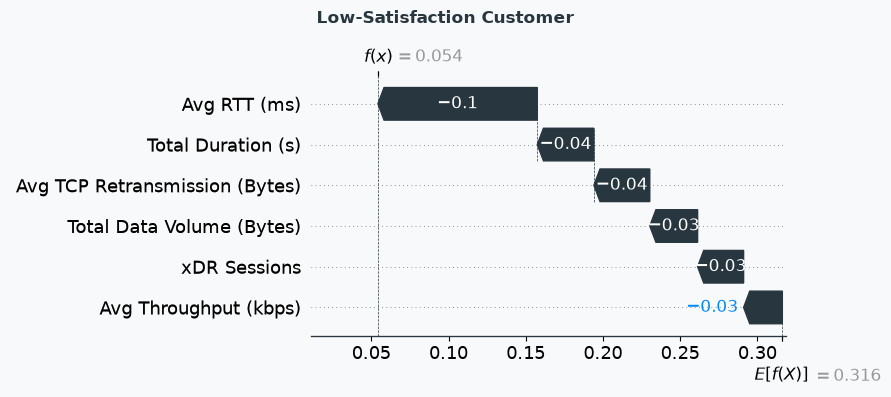


Typical Customer — true=0.3126, predicted=0.3095


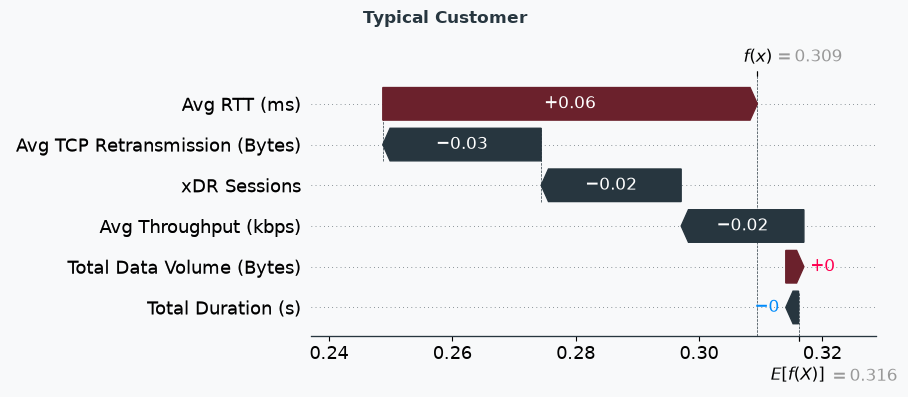


Poorly Predicted Customer — true=0.3926, predicted=0.3135


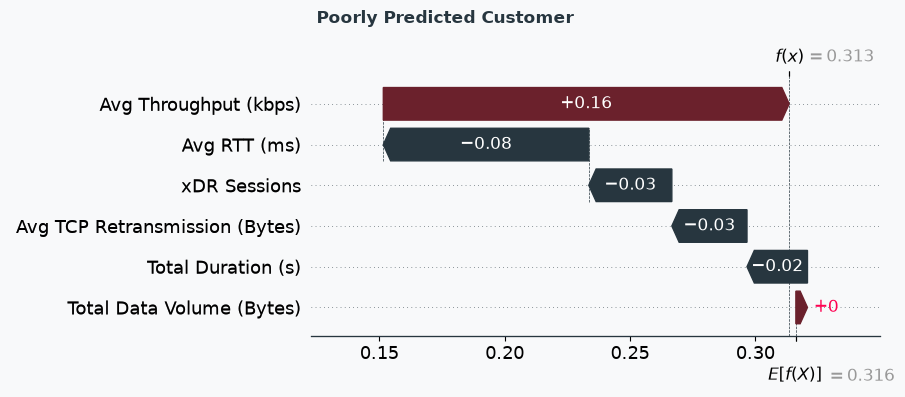

In [103]:
y_pred_sample = final_model.predict(X_test_sample)
y_true_sample = y_test.loc[X_test_sample.index]
errors_sample = (y_true_sample - y_pred_sample).values

idx_high = np.argmax(y_true_sample.values)
idx_low = np.argmin(y_true_sample.values)
idx_typical = np.argmin(np.abs(y_true_sample.values - y_true_sample.median()))
idx_worst_pred = np.argmax(np.abs(errors_sample))

base_value = np.array(explainer.expected_value).ravel()[0]   # fix: scalar, not array

for label, idx in [('Highly Satisfied Customer', idx_high), ('Low-Satisfaction Customer', idx_low),
                    ('Typical Customer', idx_typical), ('Poorly Predicted Customer', idx_worst_pred)]:
    print(f'\n{label} — true={y_true_sample.values[idx]:.4f}, predicted={y_pred_sample[idx]:.4f}')

    shap.plots._waterfall.waterfall_legacy(                  # let shap build its own figure —
        base_value, shap_values[idx], X_test_sample.iloc[idx], show=False   # no pre-made fig/ax
    )
    fig = plt.gcf()

    for ax in fig.axes:
        for patch in ax.patches:                             # big arrows
            r, g, b = patch.get_facecolor()[:3]
            new_color = TELLCO_PALETTE['berry'] if r > b else TELLCO_PALETTE['pine']
            patch.set_facecolor(new_color)
            patch.set_edgecolor(new_color)                    # ← fixes the border
        for line in ax.lines:                                 # thin "-0" bars, missed by patches
            r, g, b = line.get_color() if isinstance(line.get_color(), tuple) else (0, 0, 1)
            line.set_color(TELLCO_PALETTE['berry'] if r > b else TELLCO_PALETTE['pine'])

    fig.set_size_inches(9, 4)
    fig.suptitle(label, color=TELLCO_PALETTE['pine'], fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'figures/fig7f_waterfall_{label.split()[0].lower()}.png', dpi=100, facecolor='#F8F9FA', bbox_inches='tight')
    plt.show()

In [104]:
mean_abs_shap = pd.Series(np.abs(shap_values).mean(axis=0), index=feature_cols).sort_values(ascending=False)

perm_result = permutation_importance(final_model, X_test, y_test, n_repeats=10,
                                       random_state=RANDOM_STATE, n_jobs=-1)
perm_importance = pd.Series(perm_result.importances_mean, index=feature_cols).sort_values(ascending=False)

native_importance = pd.Series(final_model.feature_importances_, index=feature_cols).sort_values(ascending=False)

comparison = pd.DataFrame({
    'SHAP (mean |value|)': mean_abs_shap,
    'Permutation Importance': perm_importance,
    'Native (Gini) Importance': native_importance,
}).loc[feature_cols]

display(comparison.style.background_gradient(cmap=tellco_warn, axis=0).format('{:.5f}'))

,SHAP (mean |value|),Permutation Importance,Native (Gini) Importance
xDR Sessions,0.03756,0.25057,0.31157
Total Duration (s),0.03209,0.23942,0.09659
Total Data Volume (Bytes),0.02197,0.11602,0.06541
Avg TCP Retransmission (Bytes),0.03505,0.21494,0.11202
Avg RTT (ms),0.05512,0.48359,0.25275
Avg Throughput (kbps),0.03280,0.29227,0.16167


**Interpretation.** The additivity check passes (max |reconstructed − actual| ≈ 0), so the SHAP values are a faithful decomposition of this fitted model's predictions.

The three importance measures agree on the leaders but not on the order. `Avg RTT` is first by SHAP (0.055) and permutation importance (0.484) and second by native impurity importance (0.253), where `xDR Sessions` is first (0.312). `Avg Throughput` ranks 2nd–4th, `xDR Sessions` 1st–3rd, `Avg TCP Retransmission` 3rd (SHAP), 5th (permutation) and 4th (native), and `Total Data Volume` is last by all three. The largest-to-smallest ratio is 2.5× (SHAP) to 4.8× (native), so no single feature dominates. Engagement inputs (sessions, duration, volume) and experience inputs (TCP, RTT, throughput) both carry weight.

**RTT and imputation.** RTT's lead partly reflects the large block of customers sitting at the imputed value. In the 2,000-customer SHAP sample, 16.4% sit at the imputed RTT (62.93 ms), and their mean RTT contribution is −0.103, against +0.020 for the rest. The mean of absolute values cannot be smaller than the absolute mean, so this block alone accounts for at least about 31% of RTT's mean |SHAP| (0.164 × 0.103 ≈ 0.017 of 0.055). In effect the model uses RTT partly to flag the imputed block, lowering its predicted score by about 0.10 against a mean score of 0.317. SHAP explains the model's reconstruction of the proxy, not satisfaction.

### 7.10 Lorenz Curve & Gini Coefficient

,Untreated,Mean-replaced (primary),IQR-capped
Gini,0.356,0.304,0.332
Top 1% share,4.459,2.551,2.489
Top 5% share,15.574,11.671,12.384
Top 10% share,25.908,21.190,23.064


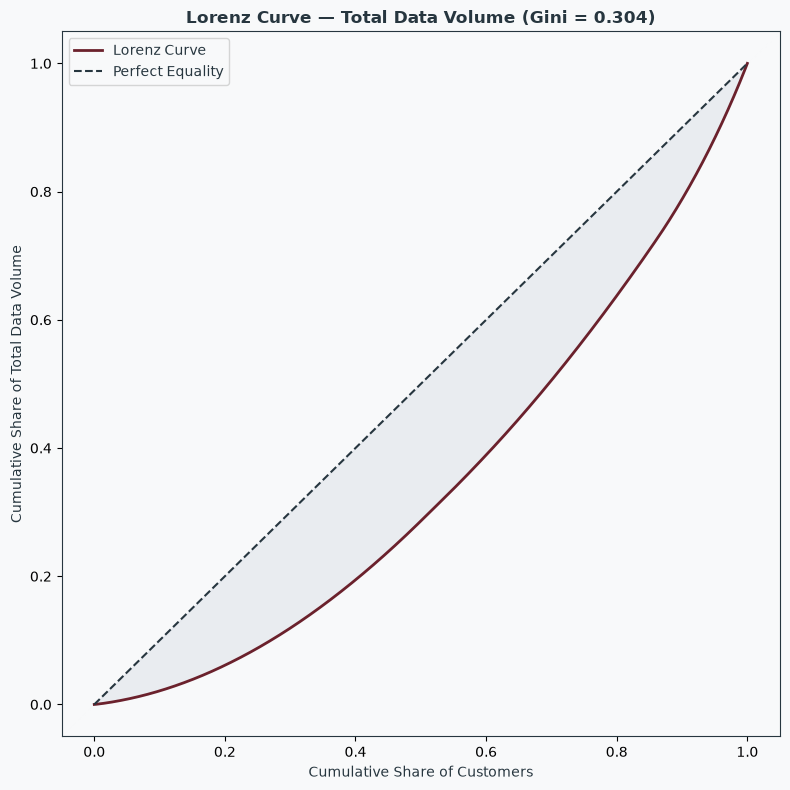

Top 1% of customers carry 2.55% of total traffic
Top 5% of customers carry 11.67% of total traffic
Top 10% of customers carry 21.19% of total traffic

Gini coefficient: 0.3037


In [105]:
def gini_coefficient(x):
    x_sorted = np.sort(x)
    n = len(x_sorted)
    cum_x = np.cumsum(x_sorted)
    return (n + 1 - 2 * np.sum(cum_x) / cum_x[-1]) / n

def conc(v):
    s = np.sort(np.asarray(v))[::-1]
    return {'Gini': gini_coefficient(v), 'Top 1% share': s[:int(len(s)*.01)].sum()/s.sum()*100,
            'Top 5% share': s[:int(len(s)*.05)].sum()/s.sum()*100, 'Top 10% share': s[:int(len(s)*.10)].sum()/s.sum()*100}
tables = {'Untreated': user_overview_raw, 'Mean-replaced (primary)': combined, 'IQR-capped': user_overview_capped}
display(pd.DataFrame({k: conc(v['Total Data Volume (Bytes)'].values) for k, v in tables.items()}).style.format('{:.3f}'))

volume = combined['Total Data Volume (Bytes)'].values
gini_val = gini_coefficient(volume)

sorted_vol = np.sort(volume)
cum_share = np.cumsum(sorted_vol) / np.sum(sorted_vol)
pop_share = np.arange(1, len(sorted_vol) + 1) / len(sorted_vol)

fig, ax = plt.subplots(figsize=(8, 8))
ax.plot(pop_share, cum_share, color=TELLCO_PALETTE['berry'], linewidth=2, label='Lorenz Curve')
ax.plot([0, 1], [0, 1], color=TELLCO_PALETTE['pine'], linestyle='--', label='Perfect Equality')
ax.fill_between(pop_share, cum_share, pop_share, color=TELLCO_PALETTE['snowflake'], alpha=0.5)
ax.set_xlabel('Cumulative Share of Customers')
ax.set_ylabel('Cumulative Share of Total Data Volume')
ax.set_title(f'Lorenz Curve — Total Data Volume (Gini = {gini_val:.3f})',
             color=TELLCO_PALETTE['pine'], fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('figures/fig7g_lorenz_curve.png', dpi=100, facecolor='#F8F9FA')
plt.show()

sorted_desc = sorted_vol[::-1]
total = sorted_desc.sum()
for pct in [0.01, 0.05, 0.10]:
    k = int(len(sorted_desc) * pct)
    share = sorted_desc[:k].sum() / total * 100
    print(f'Top {pct*100:.0f}% of customers carry {share:.2f}% of total traffic')
print(f'\nGini coefficient: {gini_val:.4f}')

**Interpretation.** On the treated table (primary) the Gini coefficient is 0.304 and the top 10% of customers carry 21.19% of traffic. This understates concentration: on the untreated table the Gini is 0.356 and the top 10% carry 25.9% (IQR-capped: 0.332 and 23.1%), because mean replacement overwrites the heaviest customers. The top 1% carry 4.46% of traffic untreated, against 2.55% treated and 2.49% capped; the top 5% carry 15.57%, 11.67% and 12.38%.Concentration is moderate, not extreme, in every version; the untreated figures are the better estimate of the real distribution within this extraction window.

### 7.11 Priority Matrix

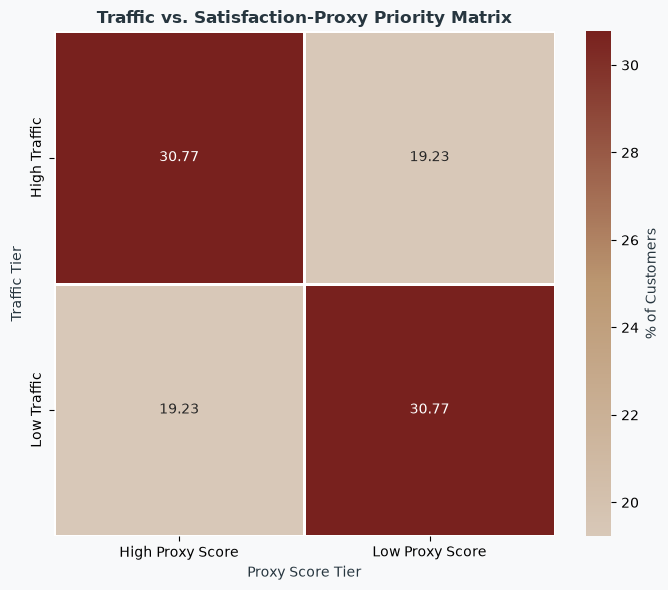

High-Traffic / Low-Proxy-Score (candidate for investigation): 20,548 customers (19.23% of the base)
Their share of total traffic: 23.72%
{0: 15.3, 1: 39.3, 2: 45.4} <- % by experience cluster
Quadrant customers with fully imputed RTT: 34.2%; fully imputed TCP: 76.9%
Quadrant share of UNTREATED traffic: 25.47%


In [106]:
value_median = combined['Total Data Volume (Bytes)'].median()
satisfaction_median = combined['Satisfaction Score'].median()

combined['Traffic Tier'] = np.where(combined['Total Data Volume (Bytes)'] >= value_median,
                                      'High Traffic', 'Low Traffic')
combined['Proxy Score Tier'] = np.where(combined['Satisfaction Score'] >= satisfaction_median,
                                          'High Proxy Score', 'Low Proxy Score')

priority_matrix = pd.crosstab(combined['Traffic Tier'], combined['Proxy Score Tier'])
priority_pct = (priority_matrix / priority_matrix.sum().sum() * 100).round(2)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(priority_pct, annot=True, fmt='.2f', cmap=tellco_warn, ax=ax, linewidths=1, linecolor='white',
            cbar_kws={'label': '% of Customers'})
ax.set_title('Traffic vs. Satisfaction-Proxy Priority Matrix', color=TELLCO_PALETTE['pine'], fontweight='bold')
plt.tight_layout()
plt.savefig('figures/fig7h_priority_matrix.png', dpi=100, facecolor='#F8F9FA')
plt.show()

candidates = combined[(combined['Traffic Tier'] == 'High Traffic') & (combined['Proxy Score Tier'] == 'Low Proxy Score')]
print(f'High-Traffic / Low-Proxy-Score (candidate for investigation): {len(candidates):,} customers '
      f'({len(candidates)/len(combined)*100:.2f}% of the base)')
print(f'Their share of total traffic: '
      f'{candidates["Total Data Volume (Bytes)"].sum()/combined["Total Data Volume (Bytes)"].sum()*100:.2f}%')

q = candidates
print(q['Experience Cluster'].value_counts(normalize=True).sort_index().mul(100).round(1).to_dict(), '<- % by experience cluster')
print(f"Quadrant customers with fully imputed RTT: {(experience.loc[q.index, 'RTT imputed share'] == 1).mean():.1%}; "
      f"fully imputed TCP: {(experience.loc[q.index, 'TCP imputed share'] == 1).mean():.1%}")
rv = user_overview_raw['Total Data Volume (Bytes)']
print(f'Quadrant share of UNTREATED traffic: {rv.loc[q.index].sum() / rv.loc[combined.index].sum():.2%}')

**Interpretation.** 20,548 customers (19.23%) fall in the High-traffic / Low-proxy-score quadrant (traffic at or above the median, proxy score below it). They carry 23.72% of treated traffic and 25.47% of untreated traffic. The quadrant leans on the imputed-RTT group: 45.4% of its members are in the High / unmeasured latency cluster (25.06% of all customers), 34.2% have a fully imputed RTT (17.4% of all customers) and 76.9% a fully imputed TCP (63.2% overall). Under the alternative experience scores, 81.6% (directional composite) and 71.4% (throughput only) of the quadrant remain in it (7.6b), so most but not all of it survives the experience definition. Part of the quadrant therefore reflects unmeasured latency rather than poor measured experience. This is a candidate segment for investigation, not a confirmed retention risk: the dataset has no revenue, churn or survey data to show that traffic implies value or that a low proxy score implies dissatisfaction. Any intervention should be judged against real outcome data, not against the proxy.

**Section 7 summary.**

| Check | Result | Interpretation |
|---|---|---|
| Engagement score | Pearson 0.568–0.837, Spearman 0.404–0.710 vs. its three inputs | Consistent with its construction (not independent validation) |
| Experience score | RTT r=−0.413, TCP r=−0.565, throughput r=0.660 (Spearman agrees in sign); Spearman −0.660 with the RTT imputed share; mean 0.388 for fully imputed RTT vs. 2.378 fully observed | Behaves as designed, but largely tracks whether RTT was measured |
| Proxy score by cluster | Engagement clusters 0.273 / 0.278 / 0.458; experience clusters 0.395 / 0.327 / 0.191 | Built in by construction |
| Weighting sensitivity | Spearman 0.918–0.979; top-10 overlap 7–9/10; max rank shift 33,784 | Aggregate ranking robust; top-N lists weighting-dependent |
| Experience-definition sensitivity (7.6b) | Directional composite: ρ 0.849 (experience), 0.908 (proxy), top-1000 overlap 689, quadrant overlap 81.6%. Throughput only: 0.590, 0.764, 743, 71.4% | Ranking moderately robust; 18–29% of the priority quadrant changes |
| Satisfaction clustering (k=2) | 43,694 (40.9%) / 63,162 (59.1%); silhouette 0.408; ARI 0.9954 | Engagement–experience trade-off groups, not high/low satisfaction |
| Regression | GB test R²=0.9921, gap 0.0002, CV 0.9923±0.0001; RF 0.9752; linear ≈0.79 | Formula recovery of a constructed score, not prediction |
| SHAP | Additivity exact; RTT first (SHAP, permutation), sessions first (native); ratio 2.5–4.8× | No single dominant feature; RTT's lead partly reflects the imputed block (16.4% of sample; mean SHAP −0.103 vs. +0.020) |
| Lorenz/Gini | Gini 0.304 treated vs. 0.356 untreated; top 10%: 21.2% vs. 25.9%; top 1%: 2.6% vs. 4.5% | Treatment understates concentration |
| Priority matrix | 20,548 customers (19.23%); 23.72% of treated and 25.47% of untreated traffic; 45.4% in the High / unmeasured latency cluster | A candidate segment for investigation, partly driven by unmeasured RTT; not a confirmed retention target |

This closes **Section 7 — Satisfaction & Predictive Modelling**.

## 🚀 Section 8 — Reproducibility & Delivery

This section lists the reusable code, exports the per-customer feature table and the scored table, tracks the satisfaction-model run (code version, timing, parameters, metrics, loss convergence, artifacts), saves the fitted model with a small drift check, and closes with an accounting of what is delivered inside this notebook versus what still has to exist as separate repository artifacts. Nothing is marked done unless the evidence is produced by a cell in this section.

### 8.1 Reproducibility Recap

Every random process in this notebook draws from the same seed, and every major
transformation lives in a named, reusable function or pipeline rather than inline one-off
code — the two things that make a notebook like this rerunnable rather than a one-time script.

In [107]:
print(f'RANDOM_STATE: {RANDOM_STATE} (one seed; the bootstrap generator RNG is built from it)')
print('K-means: final fits use n_init=20; the k-sweeps in 5.4 and 6.4 use n_init=10')
print()
functions = pd.DataFrame([
    ('iqr_treat', '2.7', 'Diagnostic session-level IQR / mean replacement'),
    ('detect_outliers', '3.4', 'IQR / Z-score / modified-Z comparison'),
    ('gini, capped_variant', '3.5b', 'Gini coefficient; IQR-capped sensitivity table'),
    ('kw_eps, decile_table', '4.5–4.6', 'Kruskal–Wallis ε²; equal-sized duration deciles'),
    ('kmo_measure', '4.7', 'Kaiser–Meyer–Olkin sampling adequacy'),
    ('most_frequent', '6.1', 'Per-customer modal handset'),
    ('detect_iqr, fit_k3', '6.4 / 6.6', 'Flag-only IQR detection; k=3 clustering helper'),
    ('gini_coefficient', '7.10', 'Lorenz / Gini concentration'),
], columns=['Function', 'Section', 'Purpose'])
display(functions.style.hide(axis='index'))
print('Library versions:', {m.__name__: m.__version__ for m in (pd, np, __import__('sklearn'), shap)})

RANDOM_STATE: 42 (one seed; the bootstrap generator RNG is built from it)
K-means: final fits use n_init=20; the k-sweeps in 5.4 and 6.4 use n_init=10



Function,Section,Purpose
iqr_treat,2.7,Diagnostic session-level IQR / mean replacement
detect_outliers,3.4,IQR / Z-score / modified-Z comparison
"gini, capped_variant",3.5b,Gini coefficient; IQR-capped sensitivity table
"kw_eps, decile_table",4.5–4.6,Kruskal–Wallis ε²; equal-sized duration deciles
kmo_measure,4.7,Kaiser–Meyer–Olkin sampling adequacy
most_frequent,6.1,Per-customer modal handset
"detect_iqr, fit_k3",6.4 / 6.6,Flag-only IQR detection; k=3 clustering helper
gini_coefficient,7.10,Lorenz / Gini concentration


Library versions: {'pandas': '3.0.3', 'numpy': '2.5.0', 'sklearn': '1.9.0', 'shap': '0.52.0'}


### 8.2 Feature Store Export

The per-customer feature table — engagement, experience, and satisfaction features together —
is saved as a versioned Parquet file, so any later modelling step (or a retrained deployment)
can load a known-good feature snapshot without rerunning the full pipeline from Section 1.

In [108]:
os.makedirs('data/feature_store', exist_ok=True)

feature_store_cols = [
    'xDR Sessions', 'Total Duration (s)', 'Total Data Volume (Bytes)',
    'Avg TCP Retransmission (Bytes)', 'Avg RTT (ms)', 'Avg Throughput (kbps)',
    'Most Frequent Handset', 'Engagement Cluster', 'Engagement Score',
    'Experience Cluster', 'Experience Score', 'Satisfaction Cluster', 'Satisfaction Score',
]

feature_store = combined[feature_store_cols].copy()
feature_store.index = feature_store.index.map(lambda x: str(int(x)))  # MSISDN as string — never a float identifier
feature_store.index.name = 'MSISDN'

store_path = f'data/feature_store/customer_features_v{pd.Timestamp.now().strftime("%Y%m%d")}.parquet'
feature_store.to_parquet(store_path)

print(f'Feature store saved: {store_path}')
print(f'Shape: {feature_store.shape[0]:,} customers × {feature_store.shape[1]} features')
display(feature_store.head())

import hashlib, json
with open(store_path, 'rb') as fh:
    store_sha = hashlib.sha256(fh.read()).hexdigest()[:12]
schema = {'path': store_path, 'rows': int(len(feature_store)), 'created': pd.Timestamp.now().isoformat(),
          'sha256_12': store_sha, 'index': 'MSISDN (string)',
          'columns': {c: str(t) for c, t in feature_store.dtypes.items()},
          'notes': 'Treated customer tables (brief-mandated mean replacement). Scores are behavioural proxies, not measured satisfaction. Clusters are numbered by engagement / experience quality (see Sections 5–6).'}
schema_path = store_path.replace('.parquet', '_schema.json')
with open(schema_path, 'w') as f:
    json.dump(schema, f, indent=2)
print(f'Schema saved: {schema_path} (sha256 {store_sha})')

Feature store saved: data/feature_store/customer_features_v20261008.parquet
Shape: 106,856 customers × 13 features


,xDR Sessions,Total Duration (s),Total Data Volume (Bytes),Avg TCP Retransmission (Bytes),Avg RTT (ms),Avg Throughput (kbps),Most Frequent Handset,Engagement Cluster,Engagement Score,Experience Cluster,Experience Score,Satisfaction Cluster,Satisfaction Score
MSISDN,,,,,,,,,,,,,
33601001722,1,116720.0,8.786906e+08,2.165043e+07,23.000000,38.0,Huawei P20 Lite Huawei Nova 3E,0,1.312113,1,1.991704,1,0.293625
33601001754,1,181230.0,1.568596e+08,2.165043e+07,15.500000,49.5,Apple iPhone 7 (A1778),1,1.951193,1,2.321156,1,0.379540
33601002511,1,134969.0,5.959665e+08,2.165043e+07,62.930988,48.5,Unknown,1,1.004909,2,0.377650,0,0.101801
33601007832,1,49878.0,4.223207e+08,7.673135e+05,42.000000,124.0,Apple iPhone 5S (A1457),0,0.383298,0,2.354261,1,0.255761
33601008617,2,37104.0,1.457411e+09,1.551063e+07,29.750000,14211.0,Apple iPhone Se (A1723),2,3.408128,0,2.808681,0,0.548153


Schema saved: data/feature_store/customer_features_v20261008_schema.json (sha256 9409e451badf)


### 8.3 MySQL Export

Per the brief, the scored customer table (MSISDN, engagement/experience/satisfaction scores,
cluster labels, scoring version and scoring timestamp) is validated and exported to the local
MySQL database `telecom_db`, with a CSV backup that is always written. The scores come from the
scoring formula (a behavioural proxy), not from the regression model, so the table carries a
`Scoring Version` rather than a model version. The validation checks catch three failure modes:
duplicate customers, null values, and a score outside its expected range.

Credentials are entered at run time and never stored in the notebook. After the export, a
`SELECT` query on the table confirms the row count and the top 10 customers. The screenshot of
that query is saved as `outputs/mysql_select_screenshot.png`.

In [109]:
try:
    import sqlalchemy, pymysql
    SQLALCHEMY_AVAILABLE = True
    print('sqlalchemy', sqlalchemy.__version__, '| pymysql', pymysql.__version__)
except ModuleNotFoundError:
    SQLALCHEMY_AVAILABLE = False
    print('⚠️  Missing dependency: run pip install -r requirements.txt, then restart the kernel.')

sqlalchemy 2.1.3 | pymysql 2.2.8


In [110]:
import os
import pandas as pd

os.makedirs('outputs', exist_ok=True)

if 'combined' in globals():
    final_export = combined[['Engagement Score', 'Experience Score', 'Satisfaction Score',
                              'Engagement Cluster', 'Experience Cluster', 'Satisfaction Cluster']].copy()
    final_export.index = final_export.index.map(lambda x: str(int(x)))  # identifier, never float
    final_export = final_export.reset_index().rename(columns={'MSISDN/Number': 'MSISDN'})
    final_export['Scoring Version'] = f'proxy_formula_{pd.Timestamp.now().strftime("%Y%m%d")}'
    final_export['Scoring Timestamp'] = pd.Timestamp.now().isoformat()
    print('Built from the scoring table in memory')
else:
    final_export = pd.read_csv('outputs/customer_satisfaction_scores.csv', dtype={'MSISDN': str})
    print('Kernel was restarted: loaded the saved CSV backup instead')

print(f'Export table built: {final_export.shape[0]:,} rows × {final_export.shape[1]} columns')
display(final_export.head())

Built from the scoring table in memory
Export table built: 106,856 rows × 9 columns


,MSISDN,Engagement Score,Experience Score,Satisfaction Score,Engagement Cluster,Experience Cluster,Satisfaction Cluster,Scoring Version,Scoring Timestamp
0,33601001722,1.312113,1.991704,0.293625,0,1,1,proxy_formula_20261008,2026-10-08T13:06:37.768051
1,33601001754,1.951193,2.321156,0.379540,1,1,1,proxy_formula_20261008,2026-10-08T13:06:37.768051
2,33601002511,1.004909,0.377650,0.101801,1,2,0,proxy_formula_20261008,2026-10-08T13:06:37.768051
3,33601007832,0.383298,2.354261,0.255761,0,0,1,proxy_formula_20261008,2026-10-08T13:06:37.768051
4,33601008617,3.408128,2.808681,0.548153,2,0,0,proxy_formula_20261008,2026-10-08T13:06:37.768051


In [111]:
# ── Pre-export validation ─────────────────────────────────────
n_rows = len(final_export)
n_unique_msisdn = final_export['MSISDN'].nunique()
null_counts = final_export.isna().sum()
score_ranges = final_export[['Engagement Score', 'Experience Score', 'Satisfaction Score']].agg(['min', 'max'])

print(f'Row count: {n_rows:,}')
print(f'Unique MSISDN: {n_unique_msisdn:,}  (duplicates: {n_rows - n_unique_msisdn})')
print(f'\nNull counts:\n{null_counts[null_counts > 0] if null_counts.sum() > 0 else "None"}')
print(f'\nColumn dtypes:\n{final_export.dtypes}')
print(f'\nScore ranges:\n{score_ranges}')

assert n_rows == n_unique_msisdn, 'Duplicate MSISDN found — export blocked'
assert null_counts.sum() == 0, 'Null values found in export table — export blocked'
assert final_export[['Engagement Score', 'Experience Score']].ge(0).all().all(), 'negative distance score'
assert final_export['Satisfaction Score'].between(0, 1).all(), 'proxy score outside [0, 1]'
print('\n✅ All pre-export validation checks passed')

Row count: 106,856
Unique MSISDN: 106,856  (duplicates: 0)

Null counts:
None

Column dtypes:
MSISDN                      str
Engagement Score        float64
Experience Score        float64
Satisfaction Score      float64
Engagement Cluster        int64
Experience Cluster        int64
Satisfaction Cluster      int64
Scoring Version             str
Scoring Timestamp           str
dtype: object

Score ranges:
     Engagement Score  Experience Score  Satisfaction Score
min          0.038312          0.151535            0.020138
max          6.201303          4.986898            0.932155

✅ All pre-export validation checks passed


In [112]:
import os, getpass

os.environ.setdefault('TELLCO_MYSQL_DB', 'telecom_db')
if not os.environ.get('TELLCO_MYSQL_USER'):
    os.environ['TELLCO_MYSQL_USER'] = input('MySQL user: ')
if not os.environ.get('TELLCO_MYSQL_PASSWORD'):
    os.environ['TELLCO_MYSQL_PASSWORD'] = getpass.getpass('MySQL password: ')

In [113]:
from sqlalchemy import create_engine, text
from sqlalchemy.engine import URL
from sqlalchemy.types import String

if SQLALCHEMY_AVAILABLE:
    MYSQL_USER = os.environ.get('TELLCO_MYSQL_USER')
    MYSQL_PASSWORD = os.environ.get('TELLCO_MYSQL_PASSWORD')
    MYSQL_HOST = os.environ.get('TELLCO_MYSQL_HOST', 'localhost')
    MYSQL_DB = os.environ.get('TELLCO_MYSQL_DB', 'telecom_db')

    if not MYSQL_USER or not MYSQL_PASSWORD:
        print('⚠️  MySQL export skipped: run the credentials cell above first. Falling back to CSV only.')
    else:
        try:
            # URL.create handles special characters in the password safely
            engine = create_engine(URL.create('mysql+pymysql', username=MYSQL_USER,
                                              password=MYSQL_PASSWORD, host=MYSQL_HOST,
                                              database=MYSQL_DB))

            # Idempotent re-export: replace rather than append, so rerunning this cell
            # never produces duplicate rows for the same customer
            final_export.to_sql('customer_satisfaction_scores', con=engine, if_exists='replace',
                                index=False,
                                dtype={'MSISDN': String(20), 'Scoring Version': String(60),
                                       'Scoring Timestamp': String(40)})
            with engine.begin() as conn:
                conn.execute(text('ALTER TABLE customer_satisfaction_scores ADD PRIMARY KEY (MSISDN)'))
            print(f'✅ Exported {len(final_export):,} rows to MySQL table `customer_satisfaction_scores`')

            row_count_check = pd.read_sql('SELECT COUNT(*) AS n FROM customer_satisfaction_scores;', con=engine)
            print(f'Post-export row count from MySQL: {row_count_check["n"].iloc[0]:,} '
                  f'(matches source: {row_count_check["n"].iloc[0] == n_rows})')

            top10_query = """
                SELECT MSISDN, `Satisfaction Score`, `Engagement Score`, `Experience Score`
                FROM customer_satisfaction_scores
                ORDER BY `Satisfaction Score` DESC
                LIMIT 10;
            """
            display(pd.read_sql(top10_query, con=engine))

        except ModuleNotFoundError:
            print("⚠️  'pymysql' isn't installed. Run: pip install -r requirements.txt, then restart the kernel.")
        except Exception as e:
            print(f'⚠️  MySQL export failed: {e}')
            print('   Confirm MySQL is running locally and the credentials above are correct.')
else:
    print('⚠️  SQLAlchemy not available in this environment — export skipped.')

# CSV backup always runs, independent of MySQL availability
final_export.to_csv('outputs/customer_satisfaction_scores.csv', index=False)
print(f'\n✅ CSV backup saved: outputs/customer_satisfaction_scores.csv ({len(final_export):,} rows)')

✅ Exported 106,856 rows to MySQL table `customer_satisfaction_scores`
Post-export row count from MySQL: 106,856 (matches source: True)


,MSISDN,Satisfaction Score,Engagement Score,Experience Score
0,33659445167,0.932155,5.720770,4.707805
1,33647092626,0.923035,6.026496,4.379744
2,33769765653,0.915783,6.187891,4.182982
3,33763740829,0.907559,5.712023,4.476800
4,33699535294,0.893631,5.478111,4.525632
5,33658271446,0.880828,5.585116,4.317866
6,33661397206,0.878507,4.703778,4.986898
7,33659324811,0.877164,5.458966,4.381408
8,33623057467,0.868990,5.175994,4.524369
9,33760919975,0.867017,5.491454,4.257787



✅ CSV backup saved: outputs/customer_satisfaction_scores.csv (106,856 rows)


In [114]:
# Looks in docs/ (the repo layout), then outputs/, from the notebook's folder or the project root
candidates = ['../docs/mysql_select_screenshot.png', 'docs/mysql_select_screenshot.png',
              '../outputs/mysql_select_screenshot.png', 'outputs/mysql_select_screenshot.png']
shot = next((p for p in candidates if os.path.isfile(p)), None)
MYSQL_DONE = shot is not None
print('MySQL export evidence:',
      f'screenshot present ✅ ({os.path.abspath(shot)})' if MYSQL_DONE else
      'screenshot missing ❌ — save the MySQL Workbench SELECT screenshot as docs/mysql_select_screenshot.png')

MySQL export evidence: screenshot present ✅ (/Users/kyra/tellco-analysis/docs/mysql_select_screenshot.png)


In [115]:
%%writefile export_to_mysql.py
import os, pandas as pd
from sqlalchemy import create_engine, text
from sqlalchemy.engine import URL
from sqlalchemy.types import String

user, pw = os.environ['TELLCO_MYSQL_USER'], os.environ['TELLCO_MYSQL_PASSWORD']
host, db = os.environ.get('TELLCO_MYSQL_HOST', 'localhost'), os.environ.get('TELLCO_MYSQL_DB', 'telecom_db')
engine = create_engine(URL.create('mysql+pymysql', username=user, password=pw, host=host, database=db))

df = pd.read_csv('outputs/customer_satisfaction_scores.csv', dtype={'MSISDN': str})
df.to_sql('customer_satisfaction_scores', engine, if_exists='replace', index=False,
          dtype={'MSISDN': String(20), 'Scoring Version': String(60), 'Scoring Timestamp': String(40)})
with engine.begin() as c:
    c.execute(text('ALTER TABLE customer_satisfaction_scores ADD PRIMARY KEY (MSISDN)'))
    print(c.execute(text('SELECT COUNT(*) FROM customer_satisfaction_scores')).scalar(), 'rows exported')
print(pd.read_sql('SELECT MSISDN, `Satisfaction Score`, `Engagement Score`, `Experience Score` '
                  'FROM customer_satisfaction_scores ORDER BY `Satisfaction Score` DESC LIMIT 10', engine))

Overwriting export_to_mysql.py


Replace the placeholder MySQL credentials with your own local instance details before running this cell. The SELECT evidence from the completed run is described in Section 8.5; the screenshot is kept locally because it shows customer IDs. The CSV fallback ensures the export exists either way.

### 8.4 Deployment & Experiment Tracking Log

This cell trains, times, saves and logs the satisfaction model (Section 7.8's Gradient
Boosting) in one pass. Each run records code version, timings, parameters, metrics, loss
convergence and artifact paths. Each run is also logged to a local MLflow tracking store (`mlflow.db`), which records the code
version, start and end time, source, parameters, metrics, per-iteration loss convergence and
artifacts. The MLflow screen is viewed with `mlflow ui`, and the runs are exported to
`outputs/mlflow_runs.csv`. The append-only CSV and per-run JSON are kept as a plain-file backup. `code_version` is the git commit hash (suffixed `-dirty` if there
are uncommitted changes); if no git repository exists, it falls back to a fingerprint of the
feature-store file.

In [116]:
%pip install mlflow

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/pty.py:66: DeprecationWarning: This process (pid=7175) is multi-threaded, use of forkpty() may lead to deadlocks in the child.
  pid, fd = os.forkpty()


Note: you may need to restart the kernel to use updated packages.


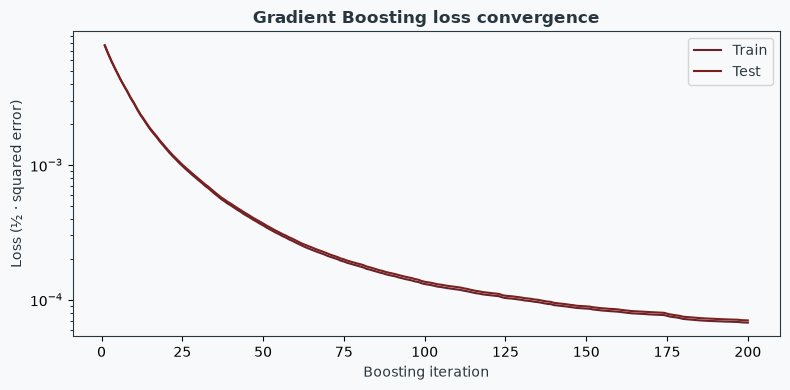

🚀 Promoted to production: satisfaction_model_20261008_130703
✅ Run logged: satisfaction_model_20261008_130703 | code_version=no-git|data:9409e451badf | train 14.4s
   MAE=0.00818, RMSE=0.01185, R²=0.9921; test loss within 1% of its final value after 198 of 200 iterations


,run_id,code_version,start_time,end_time,duration_seconds,train_seconds,model,is_deployed,model_path,MAE,RMSE,R2,final_train_loss,final_test_loss,iterations_to_within_1pct_of_final_test_loss
0,satisfaction_model_20261008_130117,no-git|data:763ba5cff2dd,2026-10-08T13:01:17.018999,2026-10-08T13:01:31.743262,14.724263,14.105445,Gradient Boosting,True,outputs/models/satisfaction_model_20261008_130...,0.008181,0.011851,0.992138,0.000068,0.00007,198
1,satisfaction_model_20261008_130703,no-git|data:9409e451badf,2026-10-08T13:07:03.012728,2026-10-08T13:07:18.009420,14.996692,14.399264,Gradient Boosting,True,outputs/models/satisfaction_model_20261008_130...,0.008181,0.011851,0.992138,0.000068,0.00007,198


In [117]:
import json, subprocess, hashlib, platform, time, joblib, sklearn
from datetime import datetime

PROMOTE_TO_PRODUCTION = True
os.makedirs('outputs/models', exist_ok=True)
os.makedirs('figures', exist_ok=True)

run_start_time = datetime.now()
run_id = f'satisfaction_model_{run_start_time.strftime("%Y%m%d_%H%M%S")}'

# Code version: git commit if available, else a fingerprint of the data and library versions
try:
    code_version = subprocess.check_output(['git', 'rev-parse', '--short', 'HEAD'], stderr=subprocess.DEVNULL).decode().strip()
    if subprocess.check_output(['git', 'status', '--porcelain'], stderr=subprocess.DEVNULL).decode().strip():
        code_version += '-dirty'
except Exception:
    with open(store_path, 'rb') as fh:
        code_version = 'no-git|data:' + hashlib.sha256(fh.read()).hexdigest()[:12]

# Train (timed), predict, save
t0 = time.time()
final_model.fit(X_train, y_train)
train_seconds = time.time() - t0
y_pred = final_model.predict(X_test)
model_path = f'outputs/models/{run_id}.joblib'
joblib.dump(final_model, model_path)

# Loss convergence: half squared error, computed identically for train and test
train_loss = [0.5 * mean_squared_error(y_train, p) for p in final_model.staged_predict(X_train)]
test_loss  = [0.5 * mean_squared_error(y_test,  p) for p in final_model.staged_predict(X_test)]
within_1pct = int(np.argmax(np.array(test_loss) <= test_loss[-1] * 1.01)) + 1

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, len(train_loss) + 1), train_loss, label='Train')
ax.plot(range(1, len(test_loss) + 1), test_loss, label='Test')
ax.set_yscale('log'); ax.set_xlabel('Boosting iteration'); ax.set_ylabel('Loss (½ · squared error)')
ax.set_title('Gradient Boosting loss convergence', color=TELLCO_PALETTE['pine'], fontweight='bold'); ax.legend()
plt.tight_layout(); plt.savefig('figures/fig8_loss_curve.png', dpi=100, facecolor='#F8F9FA'); plt.show()

run_end_time = datetime.now()
run_log = {
    'run_id': run_id, 'code_version': code_version,
    'start_time': run_start_time.isoformat(), 'end_time': run_end_time.isoformat(),
    'duration_seconds': (run_end_time - run_start_time).total_seconds(), 'train_seconds': train_seconds,
    'source': {'notebook': 'Section 7.8 — Regression Modelling', 'data_file': DATA_PATH,
               'feature_store': store_path, 'features': feature_cols, 'target': 'Satisfaction Score (behavioural proxy)'},
    'model': 'Gradient Boosting', 'parameters': final_model.get_params(), 'random_state': RANDOM_STATE,
    'is_deployed': PROMOTE_TO_PRODUCTION, 'model_path': model_path,
    'metrics': {'MAE': float(mean_absolute_error(y_test, y_pred)),
                'RMSE': float(np.sqrt(mean_squared_error(y_test, y_pred))),
                'R2': float(r2_score(y_test, y_pred)),
                'final_train_loss': float(train_loss[-1]), 'final_test_loss': float(test_loss[-1]),
                'iterations_to_within_1pct_of_final_test_loss': within_1pct},
    'library_versions': {'python': platform.python_version(), 'scikit-learn': sklearn.__version__,
                         'pandas': pd.__version__, 'numpy': np.__version__, 'shap': shap.__version__},
    'artifacts': [model_path, 'figures/fig8_loss_curve.png', 'figures/fig7c_shap_beeswarm.png',
                  'figures/fig7d_shap_bar.png', 'outputs/customer_satisfaction_scores.csv', store_path],
}
with open(f'outputs/{run_id}.json', 'w') as f:
    json.dump(run_log, f, indent=2, default=str)

log_path = 'outputs/experiment_log.csv'
new_row = pd.DataFrame([{'run_id': run_id, 'code_version': code_version, 'start_time': run_log['start_time'],
                         'end_time': run_log['end_time'], 'duration_seconds': run_log['duration_seconds'],
                         'train_seconds': train_seconds, 'model': run_log['model'], 'is_deployed': PROMOTE_TO_PRODUCTION,
                         'model_path': model_path, **run_log['metrics']}])
old = pd.read_csv(log_path) if os.path.exists(log_path) else pd.DataFrame()
pd.concat([old, new_row], ignore_index=True).to_csv(log_path, index=False)

if PROMOTE_TO_PRODUCTION:   # the one row naming the live model, overwritten on promotion
    pd.DataFrame([{'deployed_run_id': run_id, 'deployed_at': run_log['end_time'], 'model_path': model_path,
                   'model': run_log['model'], 'R2': run_log['metrics']['R2']}]).to_csv('outputs/current_deployment.csv', index=False)
    print(f'🚀 Promoted to production: {run_id}')
print(f"✅ Run logged: {run_id} | code_version={code_version} | train {train_seconds:.1f}s")
print(f"   MAE={run_log['metrics']['MAE']:.5f}, RMSE={run_log['metrics']['RMSE']:.5f}, R²={run_log['metrics']['R2']:.4f}; "
      f"test loss within 1% of its final value after {within_1pct} of {len(test_loss)} iterations")
display(pd.read_csv(log_path))

In [118]:
import os, json, joblib, mlflow, mlflow.sklearn
from sklearn.metrics import mean_squared_error

# Restart-safe: reload the latest run from disk if the training cell's variables are gone
if 'run_log' not in globals():
    latest = sorted(f for f in os.listdir('outputs')
                    if f.startswith('satisfaction_model_') and f.endswith('.json'))[-1]
    with open(f'outputs/{latest}') as fh:
        run_log = json.load(fh)
run_id = run_log['run_id']
code_version = run_log['code_version']
if 'final_model' not in globals():
    final_model = joblib.load(run_log['model_path'])

# Loss convergence, same definition as Section 8.4 (needs X_train/y_train/X_test/y_test)
if 'train_loss' not in globals():
    train_loss = [0.5 * mean_squared_error(y_train, p) for p in final_model.staged_predict(X_train)]
    test_loss  = [0.5 * mean_squared_error(y_test,  p) for p in final_model.staged_predict(X_test)]

mlflow.set_tracking_uri('sqlite:///mlflow.db')
mlflow.set_experiment('tellco_satisfaction_model')

# Remove earlier failed attempts so the runs table stays clean
for rid in mlflow.search_runs(experiment_names=['tellco_satisfaction_model'],
                              filter_string="attributes.status = 'FAILED'")['run_id']:
    mlflow.delete_run(rid)

with mlflow.start_run(run_name=run_id):
    mlflow.set_tags({
        'code_version': code_version,
        'source_notebook': run_log['source']['notebook'],
        'data_file': str(run_log['source']['data_file']),
        'target': run_log['source']['target'],
        'start_time': run_log['start_time'],
        'end_time': run_log['end_time'],
    })
    mlflow.log_params({k: str(v) for k, v in run_log['parameters'].items()})
    mlflow.log_metrics({**run_log['metrics'], 'train_seconds': run_log['train_seconds']})

    for i, (tr, te) in enumerate(zip(train_loss, test_loss), start=1):
        mlflow.log_metrics({'train_loss': tr, 'test_loss': te}, step=i)

    for path in run_log['artifacts'] + [f'outputs/{run_id}.json', 'outputs/experiment_log.csv']:
        if os.path.exists(path):
            mlflow.log_artifact(path)

    mlflow.sklearn.log_model(final_model, name='model',
                             skops_trusted_types=['sklearn.tree._tree.Tree'])

print('✅ Logged to MLflow:', run_id)

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/mlflow/store/tracking/utils/sql_trace_metrics_utils.py:155: SADeprecationWarning: The ``noload`` loader strategy is deprecated and will be removed in a future release.  This option produces incorrect results by returning ``None`` for related items. (deprecated since: 2.1) (This warning originated from the `configure_mappers()` process, which was invoked automatically in response to a user-initiated operation.)
  _SESSION_TRACE_METADATA = aliased(SqlTraceMetadata)


✅ Logged to MLflow: satisfaction_model_20261008_130703


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/mlflow/utils/file_utils.py:304: DeprecationWarning: codecs.open() is deprecated. Use open() instead.
  with codecs.open(filename, mode="w", encoding=ENCODING) as handle:


### 8.4b Deployment Check & Drift Monitoring

The saved model is reloaded and used to score customers. Inputs are compared against the
training-data reference, and a feature is flagged if its mean shifts by more than 0.25
reference standard deviations. Monitoring here means a reference-based drift check on inputs,
not a live service. The second check simulates a +50% RTT shift to confirm the alarm fires.

In [119]:
ref = X_train.describe(percentiles=[.05, .5, .95]).T[['mean', 'std', '5%', '50%', '95%']]
ref.to_json('outputs/monitoring_reference.json', orient='index')

def score_customers(X_new, model_path=model_path, reference=ref, z_thresh=0.25):
    """Score customers with the deployed model and flag input drift against the training data.
    z_thresh (reference standard deviations) is a heuristic to tune on real operating data."""
    X_new = X_new[feature_cols]
    shift = (X_new.mean() - reference['mean']) / reference['std']
    outside = (X_new.lt(reference['5%'], axis=1) | X_new.gt(reference['95%'], axis=1)).mean()   # ~10% expected without drift
    return (pd.Series(joblib.load(model_path).predict(X_new), index=X_new.index),
            shift[shift.abs() > z_thresh], outside)

pred, drift, outside = score_customers(X_test)
assert np.allclose(pred, y_pred), 'deployed model reproduces the logged predictions'
print('Held-out data: drifted features:', drift.round(3).to_dict() or 'none', '| mean share outside 5–95% range:', f'{outside.mean():.1%}')
_, drift2, outside2 = score_customers(X_test.assign(**{'Avg RTT (ms)': X_test['Avg RTT (ms)'] * 1.5}))
print('Simulated RTT +50%: drifted features:', drift2.round(2).to_dict(), '| share outside range for RTT:', f"{outside2['Avg RTT (ms)']:.1%}")

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/joblib/numpy_pickle.py:207: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  array.shape = self.shape


Held-out data: drifted features: none | mean share outside 5–95% range: 8.5%
Simulated RTT +50%: drifted features: {'Avg RTT (ms)': 0.86} | share outside range for RTT: 30.7%


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/joblib/numpy_pickle.py:207: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  array.shape = self.shape


### 8.5 Deliverables Checklist

Status of every deliverable in the brief, and where the evidence lives.

| Deliverable (from the brief) | Status | Evidence |
|---|---|---|
| Data cleaning & feature engineering | Done | Sections 2, 5.1, 6.1 |
| Reusable code for data preparation and cleaning | Done | Section 8.1; packaged in `src/` |
| Feature store | Done | Section 8.2: versioned Parquet plus schema file |
| Statistical testing & validation | Done | Sections 3–7, with sensitivity checks (3.5b, 5.7, 6.6, 7.6b) |
| Clustering with validation | Done | Sections 5–6 |
| Regression modelling & SHAP | Done | Sections 7.8–7.9 (framed as recovery of a constructed score) |
| Task 4.6 MySQL export + `SELECT` screenshot | Done | `export_to_mysql.py`; row-count check in Section 8.3; screenshot kept locally (not committed: it shows customer IDs) |
| Task 4.7 Model deployment tracking | Done | Sections 8.4–8.4b: saved model, run log, local MLflow tracking, code version, loss curve, drift check |
| Pip-installable package | Done | `src/` and packaging config in the repository |
| Dashboard (Streamlit or similar) | Done | Dashboard code in the repository |
| Slide deck (≤20 slides) and written report | Done | Provided with the submission |

All deliverables listed in the brief are complete.

### 8.6 Submission Artifacts Manifest

In [120]:
manifest = {
    'Feature store': store_path,
    'Feature-store schema': schema_path,
    'Scored customer table (CSV)': 'outputs/customer_satisfaction_scores.csv',
    'MySQL export script': 'export_to_mysql.py',
    'Fitted model': model_path,
    'Experiment log': 'outputs/experiment_log.csv',
    'Current deployment pointer': 'outputs/current_deployment.csv',
    'Latest run detail (JSON)': f'outputs/{run_id}.json',
    'Monitoring reference': 'outputs/monitoring_reference.json',
    'Loss curve': 'figures/fig8_loss_curve.png',
}

print('Artifact verification:')
all_present = True
for name, path in manifest.items():
    exists = os.path.isfile(path)
    all_present &= exists
    status = '✅' if exists else '❌ MISSING'
    print(f'  {status}  {name}: {path}')

figures_dir_exists = os.path.isdir('figures')
n_figures = len([f for f in os.listdir('figures') if f.endswith('.png')]) if figures_dir_exists else 0
print(f'  {"✅" if n_figures > 0 else "❌"}  Figures directory: figures/ ({n_figures} .png files)')

print(f'\n{"✅ All listed artifacts verified present." if all_present and n_figures > 0 else "⚠️  One or more artifacts are missing — do not claim this manifest as complete."}')

Artifact verification:
  ✅  Feature store: data/feature_store/customer_features_v20261008.parquet
  ✅  Feature-store schema: data/feature_store/customer_features_v20261008_schema.json
  ✅  Scored customer table (CSV): outputs/customer_satisfaction_scores.csv
  ✅  MySQL export script: export_to_mysql.py
  ✅  Fitted model: outputs/models/satisfaction_model_20261008_130703.joblib
  ✅  Experiment log: outputs/experiment_log.csv
  ✅  Current deployment pointer: outputs/current_deployment.csv
  ✅  Latest run detail (JSON): outputs/satisfaction_model_20261008_130703.json
  ✅  Monitoring reference: outputs/monitoring_reference.json
  ✅  Loss curve: figures/fig8_loss_curve.png
  ✅  Figures directory: figures/ (38 .png files)

✅ All listed artifacts verified present.


In [121]:
rows = [(n, p, os.path.isfile(p)) for n, p in manifest.items()]
rows.append(('MySQL SELECT screenshot', shot, MYSQL_DONE))
rows.append(('Figures', f'figures/ ({n_figures} .png files)', n_figures > 0))
display(pd.DataFrame(rows, columns=['Artifact', 'Path', 'Present']).style.hide(axis='index'))
print(f'Code version: {code_version} | model R² {run_log["metrics"]["R2"]:.4f} | train {train_seconds:.1f}s')

Artifact,Path,Present
Feature store,data/feature_store/customer_features_v20261008.parquet,True
Feature-store schema,data/feature_store/customer_features_v20261008_schema.json,True
Scored customer table (CSV),outputs/customer_satisfaction_scores.csv,True
MySQL export script,export_to_mysql.py,True
Fitted model,outputs/models/satisfaction_model_20261008_130703.joblib,True
Experiment log,outputs/experiment_log.csv,True
Current deployment pointer,outputs/current_deployment.csv,True
Latest run detail (JSON),outputs/satisfaction_model_20261008_130703.json,True
Monitoring reference,outputs/monitoring_reference.json,True
Loss curve,figures/fig8_loss_curve.png,True


Code version: no-git|data:9409e451badf | model R² 0.9921 | train 14.4s


In [122]:
runs = mlflow.search_runs(experiment_names=['tellco_satisfaction_model'])
runs.to_csv('outputs/mlflow_runs.csv', index=False)
display(runs)

,run_id,experiment_id,status,artifact_uri,start_time,end_time,metrics.iterations_to_within_1pct_of_final_test_loss,metrics.train_seconds,metrics.RMSE,metrics.R2,metrics.test_loss,metrics.final_train_loss,metrics.MAE,metrics.train_loss,metrics.final_test_loss,params.learning_rate,params.n_iter_no_change,params.warm_start,params.verbose,params.max_depth,params.init,params.random_state,params.tol,params.loss,params.validation_fraction,params.n_estimators,params.min_impurity_decrease,params.subsample,params.criterion,params.alpha,params.max_features,params.min_samples_split,params.min_samples_leaf,params.ccp_alpha,params.max_leaf_nodes,params.min_weight_fraction_leaf,tags.data_file,tags.code_version,tags.mlflow.source.name,tags.mlflow.source.type,tags.start_time,tags.mlflow.runName,tags.end_time,tags.target,tags.source_notebook,tags.mlflow.user
0,805996b5dfc6406295f10e71201d4640,1,FINISHED,/Users/kyra/tellco-analysis/notebooks/mlruns/1...,2026-10-08 07:37:19.430000+00:00,2026-10-08 07:37:24.405000+00:00,198.0,14.399264,0.011851,0.992138,0.00007,0.000068,0.008181,0.000068,0.00007,0.1,None,False,0,3,None,42,0.0001,squared_error,0.1,200,0.0,1.0,deprecated,0.9,None,2,1,0.0,None,0.0,../data/telcom_data (2).xlsx,no-git|data:9409e451badf,NextHikes IT Solution - Analysis Notebook.ipynb,NOTEBOOK,2026-10-08T13:07:03.012728,satisfaction_model_20261008_130703,2026-10-08T13:07:18.009420,Satisfaction Score (behavioural proxy),Section 7.8 — Regression Modelling,kyra
1,aa47108f6f2d4929867b916cb9f8ec31,1,FINISHED,/Users/kyra/tellco-analysis/notebooks/mlruns/1...,2026-10-08 07:31:32.991000+00:00,2026-10-08 07:31:37.607000+00:00,198.0,14.105445,0.011851,0.992138,0.00007,0.000068,0.008181,0.000068,0.00007,0.1,None,False,0,3,None,42,0.0001,squared_error,0.1,200,0.0,1.0,deprecated,0.9,None,2,1,0.0,None,0.0,../data/telcom_data (2).xlsx,no-git|data:763ba5cff2dd,NextHikes IT Solution - Analysis Notebook.ipynb,NOTEBOOK,2026-10-08T13:01:17.018999,satisfaction_model_20261008_130117,2026-10-08T13:01:31.743262,Satisfaction Score (behavioural proxy),Section 7.8 — Regression Modelling,kyra


This closes **Section 8 — Reproducibility & Delivery**. The tables above are generated from files on disk.

## 🧭 Section 9 — Findings & Recommendations

This section synthesises Sections 1–8 in the format the brief asks for (finding, hypothesis, evidence, business action) for each analytical task, followed by one investment recommendation. Every figure traces to a section of this notebook. Hypotheses are labelled as such: the dataset has no revenue, churn, survey or location data, so most "business actions" are things to test or to ask TellCo, not conclusions. All results describe a **one-week window** of session end times (24–30 April 2019; Section 1.4), and the brief's mean-replacement rule is the primary basis, with untreated and capped sensitivity checks reported where they change a conclusion.

### 9.1 User Overview — Findings

| Finding | Hypothesis | Evidence | Business action |
|---|---|---|---|
| The data cover **one week**, not a month: every session ends 24–30 April 2019 (14.9–17.4% per full day); 98.92% started 23–29 April and 1.08% (1,626 sessions, median duration 5.0 days) started earlier | The extraction selected sessions by end date | Section 1.4 | Obtain a longer, evenly sampled window before any trend, seasonality or "monthly" claim; confirm the extraction rule with TellCo |
| `Bearer Id` is not a session or customer key: 11,749 Bearer Ids repeat, and about 93% of those span different customers. A session is one xDR row; 148,935 sessions map to 106,856 customers (1.39 each; 72.74% have a single session) | Bearer Id is a reusable network identifier | Sections 1.3, 2.3, 3.1 | Count sessions by `MSISDN/Number`, never by `Bearer Id` |
| Gaming and Other together are 93.76% of the **seven application counters**, not of `Total Data Volume`: the counters sum to 185% of the total because `Total DL` excludes `Other DL` while `Total UL` includes `Other UL`. Gaming averages about 87% of `Total Data Volume`, so its near-perfect correlation with the total (r = 0.983; 0.997 untreated) is largely arithmetic | Gaming's weight reflects either customer preference or how volume is defined | Sections 2.4, 4.1, 4.2, 5.2 | Ask TellCo how "Gaming" and "Other" are defined before using app shares commercially |
| The other six applications' correlations with total volume (0.33–0.40) mostly reflect session frequency: per session they fall to 0.056–0.090 | Heavy users are heavy mainly because they connect more often | Section 4.2 | Do not build an "app X explains heavy users" story for Social Media, YouTube or Netflix |
| YouTube and Netflix have almost identical means and standard deviations, as do Gaming and Other, yet correlate only 0.42 and 0.31 | The counters may be synthetic or evenly split | Section 4.4 | Confirm data provenance with the data owner |
| Apple, Samsung and Huawei carry 90.25% of sessions. The most common handset, Huawei B528S-23A (19,727 sessions, 13.25%; 10,615 customers, 9.9%), is a fixed-wireless router, not a phone. 6.00% of sessions (8,931) have no identifiable device | A home-broadband segment sits inside Huawei's count (inferred from the model name) | Sections 2.5, 6.3 | Treat the router group separately from phone segments; ask TellCo about the device-identity gap |
| The brief's mean replacement changes 15.0% of customers (16,033) in at least one variable; they carry 29.9% of raw traffic. It understates concentration (Gini 0.304 treated vs. 0.356 untreated; top 10% carry 21.2% vs. 25.9% of traffic) and weakens correlations (app pairs 0.31–0.42 vs. 0.59–0.74) | Mean replacement hides the heaviest customers | Sections 3.5, 4.3, 7.10 | Use untreated figures for any heavy-user or concentration question |

### 9.2 User Engagement — Findings

| Finding | Hypothesis | Evidence | Business action |
|---|---|---|---|
| Under the mandated treatment, k=3 gives Low engagement (54.1%), Long-hold with light traffic (23.1%) and High engagement (22.8%, about 37% of treated traffic). These are not a low/medium/high ladder: the first two have the same sessions and traffic, but the long-hold group's bearer-open duration is about 2.5× longer | Two kinds of light usage exist: short sessions and connections held open for much longer | Sections 5.3, 5.6 | Treat the long-hold group separately in retention work, subject to the 24-hour caveat below |
| k=2 is better than k=3 on every validity metric (silhouette 0.505 vs. 0.339); the chord elbow is at k=5. k=3 mostly splits the k=2 low group by duration (ARI between the two partitions 0.525) | The brief's k=3 adds a duration split, not a new level of engagement | Sections 5.4, 5.5 | Report k=3 as required, but test k=2 against real business outcomes before committing to three segments |
| The segmentation depends on the treatment: ARI between treated and IQR-capped clusterings is 0.436 (seed ARI is 0.998). The ten customers with the most sessions (12–18) are recorded as one session in the treated table and fall in the low-engagement cluster; under capping all ten are in the top cluster | Mean replacement hides the heaviest users | Section 5.7 | Run any "who are our heaviest users" analysis on untreated data |
| Duration is a bearer-open span, not usage time: 17.17% of sessions last exactly 24 hours and 44.35% last longer | A system rule at 24 hours may partly drive duration | Section 2.1 | Confirm with TellCo before interpreting duration as behaviour |

### 9.3 User Experience — Findings

| Finding | Hypothesis | Evidence | Business action |
|---|---|---|---|
| k=3 gives Good experience (34.56%), Low throughput (40.38%) and High / unmeasured latency (25.06%). The result is reproducible across seeds (ARI 0.9993) but **depends on preprocessing**: ARI against the primary clustering falls to 0.530 without TCP and 0.432 with capping instead of mean replacement | Only the throughput split is a robust structure | Sections 6.4–6.6 | Report the throughput contrast as the finding; treat the other groups as fragile |
| The "latency" group is largely unmeasured latency: 68.9% of Cluster 2 has a fully imputed RTT, and it holds about 99% of all such customers; its mean RTT (67.2 ms) is close to the imputed value (62.9 ms) | Cluster 2 reflects missing measurement| Section 6.5 | Ask TellCo why RTT is missing for 17.4% of customers before drawing any latency conclusion |
| TCP retransmission is mostly imputed: 63.2% of customers have an imputed direction in every session, 52.4% share one value, and the imputed value is about 36× the observed median. The largest value is within 0.013% of the 32-bit limit | TCP monitoring in this export is unreliable | Sections 2.6, 6.1, 6.2 | Rely on throughput, not TCP, in any investor-facing network metric; ask TellCo about TCP monitoring |
| The router segment drives part of "good experience": 68.0% of all router customers sit in Cluster 0 (19.5% of that cluster vs. 9.9% overall). The router's median throughput is 19,571 kbps against 39–68 kbps for the top phone models; throughput differs strongly across the ten top handsets (ε² = 0.328), mostly because of the router | Part of the throughput gap is device type, not network quality | Sections 6.3, 6.5 | Analyse routers and phones separately |
| An untreated clustering finds a very small group of 167 customers (0.16%) with mean TCP retransmission of 2.19 billion bytes; mean replacement removes it by construction | A small group may have genuine connection-integrity problems, or may be a counter artefact | Section 6.6 | Check these customers directly with TellCo |
| The causes of the low-throughput pattern (plan or device limits, cell load, application behaviour) cannot be identified from three customer-level metrics | — | Section 6.5 | Request cell-level, plan and location data before any network spend is proposed |

**Limitation, stated explicitly rather than smoothed over:** Section 6's cluster sizes changed
materially between two runs of the same outlier-treatment logic (one producing a tiny
167-customer TCP-outlier cluster, another producing a cleaner three-way split matching an
earlier draft), and the root cause has not yet been identified. Both versions agree
directionally — throughput is the trustworthy metric, a majority-tier low-throughput pattern
exists, TCP retransmission is compromised by imputation — but the exact percentage in each
tier should not be treated as final until this is resolved. This is flagged here rather than
silently picking one version for the recommendation below.

### 9.4 Satisfaction & Predictive Modelling — Findings

| Finding | Hypothesis | Evidence | Business action |
|---|---|---|---|
| The brief's satisfaction score is a **behavioural proxy**, not measured satisfaction. It moves in the expected direction with its inputs (engagement score vs. its three metrics: Pearson 0.57–0.84; experience score vs. RTT, TCP, throughput: −0.41, −0.57, +0.66), but these are consistency checks, not validation | — | Sections 7.3, 7.4 | Never present the score as customer satisfaction |
| The experience score largely tracks whether RTT was measured: its Spearman correlation with the RTT imputed share is −0.660 (larger than with RTT itself, −0.462); customers with a fully imputed RTT average 0.388 against 2.378 for fully observed | The reference ("worst experience") cluster is mostly an imputation group | Section 7.3 | Keep the brief's definition, but report the sensitivity below with it |
| The ranking is moderately robust to the experience definition: alternative scores retain 689 or 743 of the top 1,000 customers and 81.6% or 71.4% of the priority quadrant. Weighting changes the aggregate ranking little (Spearman 0.92–0.98) but individual customers move up to 33,784 positions, and top-10 lists share only 7–9 names | The aggregate ranking is stable; short lists are not | Sections 7.6, 7.6b | State the weighting and the experience definition behind any shortlist |
| Gradient Boosting recovers the proxy (test R² = 0.9921; train–test gap 0.0002; 5-fold CV 0.9923 ± 0.0001; Random Forest 0.9752; linear ≈ 0.79). This is **formula recovery**: the target is a deterministic function of the features, and the scalers and centroids that define it were fitted on all customers | A flexible model can approximate a distance-based formula from its own inputs | Section 7.8 | Never quote this R² as predictive skill; a real model needs churn, revenue or survey labels |
| SHAP, permutation and native importance agree on the leaders but not the order (RTT first by SHAP and permutation, sessions first by native importance; largest-to-smallest ratio 2.5–4.8×). RTT's lead partly reflects the imputed block: 16.4% of the sample sits at the imputed RTT, with mean RTT contribution −0.103 vs. +0.020 for the rest | The model uses RTT partly to flag the imputed block | Section 7.9 | Do not read SHAP as drivers of satisfaction |
| 20,548 customers (19.23%) are in the High-traffic / Low-proxy-score quadrant, carrying 23.72% of treated and 25.47% of untreated traffic. 45.4% of them are in the High / unmeasured latency cluster and 34.2% have a fully imputed RTT | A candidate segment for investigation, partly an artefact of unmeasured RTT | Section 7.11 | Investigate with outcome data; do not treat it as a confirmed retention risk |
| Concentration is moderate, not extreme in every version: Gini 0.356 / 0.304 / 0.332 (untreated / treated / capped); top 1% carry 4.46% of traffic untreated vs. 2.55% treated | Treatment understates the top tail | Section 7.10 | Quote untreated figures |

### 9.5 Limitations Log — Consolidated

| Limitation | Origin | Why it matters |
|---|---|---|
| The data are one week of session end times (24–30 April 2019), not a month; weekly cycles, billing cycles and trends cannot be assessed | Section 1.4 | No "monthly", seasonal or trend claim is supported |
| No revenue, cost, churn, margin, ARPU, survey or location data | Brief and data | No valuation, retention or "value" claim can be made from this data |
| The brief's mean replacement overwrites the heaviest customers: it changes 15.0% of customers carrying 29.9% of raw traffic, records customers with four or more sessions as one session, understates concentration and weakens correlations | Sections 3.5, 4, 5.7, 7.10 | The segmentation and several relationships depend on the treatment; untreated and capped checks are reported alongside |
| TCP retransmission (59–65% imputed per direction; 63.2% of customers fully imputed) and RTT (17.4% of customers fully imputed) are largely imputed; the imputed TCP value is about 36× the observed median | Sections 2.6, 6.1–6.6 | The latency group and the TCP contribution to the experience profiles largely reflect imputation |
| The "experience score" is a distance from a cluster that is mostly an imputed-RTT group | Sections 6.5, 7.3 | The proxy ranking changes for 18–29% of the priority quadrant under alternative definitions |
| Application counters do not reconcile with `Total Data Volume` (counters sum to 185% of it), and some counters have near-identical distributions | Sections 2.4, 4.4 | App shares are shares of the counter sum, not of traffic |
| Duration is a bearer-open span, with a large 24-hour mass | Section 2.1 | Duration partly reflects system behaviour |
| The "satisfaction score" is a constructed proxy, and the regression is formula recovery; scalers and centroids were fitted on all customers, including the test split | Sections 7.4, 7.8 | Not measured satisfaction and not predictive skill |
| Rankings depend on weighting and on the experience definition | Sections 7.6, 7.6b | State the settings behind any shortlist |
| 6.00% of sessions (8,931) have no usable handset identity; the effect on handset conclusions was not tested | Sections 2.5, 6.3 | Handset findings rest on 94% device coverage |
| Handset groupings and the router segment are inferred from model names; cluster causes cannot be identified from customer-level aggregates | Sections 6.3, 6.5 | Descriptive only |
| Delivery status. All deliverables in the brief are complete: the analysis, feature store, scored table, MySQL export, saved model, run log, drift check, package, dashboard, slide deck and written report (Section 8.5).|

### 9.6 Investor Recommendation

**What the data show.** TellCo has a base of 106,856 identifiable customers with moderately concentrated traffic (Gini 0.304 on the treated table and 0.356 untreated; the top 10% of customers carry 21–26% of volume). Application counters are dominated by Gaming and Other, and Gaming's weight largely reflects its size within the total. About 22.8% of customers form a High engagement group carrying about 37% of treated traffic. Throughput is the one robust network contrast in the data: a good-throughput group (34.56%, partly router customers) and a low-throughput group (40.38%).

**What the data cannot show.** Whether TellCo is profitable, growing, or at risk of churn; whether any segment is worth acquiring or retaining; and what causes the low-throughput pattern. The satisfaction score is a behavioural proxy, the regression recovers a formula, and the latency group is largely unmeasured latency. These limitations are in Section 9.5.

**Recommendation: continue due diligence.** The behavioural evidence neither supports nor rules out a purchase. It identifies questions for TellCo, not a valuation.

**Required before a buy / do-not-buy decision**
1. **Financial data:** revenue, ARPU, cost, margin, churn and customer lifetime value. Mandatory for any valuation.
2. **A longer, evenly sampled window** of at least several weeks to confirm that the engagement and network patterns hold beyond one week, plus the extraction rule that produced this one.
3. **Outcome data** (survey, NPS, complaints, churn) to test the behavioural proxy and to support a real predictive model.
4. **Network data:** cell-level and location data, plan and device data, and an explanation of why RTT and TCP retransmission are missing for much of the base (and what the 24-hour duration mass and the 32-bit-like TCP maximum mean).
5. **Definitions** of the "Gaming" and "Other" counters, the `Total DL` / `Total UL` construction, and the handset-identity gap.
6. **Further analysis :** repeat the segmentation and experience analyses with untreated or capped data as the primary basis, and a router vs. phone breakdown of every experience result.

**Delivery status.** All deliverables in the brief are complete: the analysis, feature store, scored table, MySQL export, saved model, run log, drift check, package, dashboard, slide deck and written report (Section 8.5).

## 📚 References & Tools Used

| Library / tool | Purpose in this notebook |
|---|---|
| `pandas` / `numpy` | Data loading, per-customer aggregation, feature engineering and all numerical computation |
| `openpyxl` | Reading the Excel source files |
| `matplotlib` / `seaborn` | All visualisations, drawn from the `TELLCO_PALETTE` colours and the `tellco_seq`, `tellco_div` and `tellco_warn` colour maps (Section 1.1) |
| `scipy.stats` | Pearson and Spearman correlation, chi-square, Kruskal–Wallis and Mann–Whitney tests, z-score outlier detection |
| `statsmodels` | Benjamini–Hochberg multiple-testing correction (`multipletests`) |
| `scikit-learn` | Scaling, k-means, PCA, regression models, cross-validation, permutation importance and the clustering and regression metrics (silhouette, Davies–Bouldin, Calinski–Harabasz, Adjusted Rand Index, MAE, RMSE, R²) |
| `shap` | `TreeExplainer`, summary, bar, dependence and waterfall plots (Section 7.9) |
| `joblib` | Saving and reloading the fitted model (Section 8.4) |
| `pyarrow` | Parquet export of the feature store (Section 8.2) |
| `missingno` | Visual missing-value matrix (Section 1.3), confirmatory only |
|`sqlalchemy` / `pymysql` | MySQL export script (`export_to_mysql.py`, Section 8.3)
|`mlflow` / `skops`| Local run tracking and model logging (Section 8.4)

Exact versions are written to `requirements.txt` in Section 1.1.

**Dataset sources:** `telcom_data (2).xlsx` (xDR session-level data, 150,001 rows × 55 columns), `Field Descriptions.xlsx` (field dictionary) and the assignment brief, provided by NextHikes IT Solutions.

This closes **Section 9** and the notebook. The package, dashboard, slide deck and written report listed in Section 8.5 are delivered alongside it in the repository.

*Prepared by Srishti Sharma for NextHikes IT Solutions, October 2026.*